# Two-lane literature-retrieval pipeline (OpenAlex + Semantic Scholar)

This notebook implements **Phase A**, **Phase B**, **Phase C**, **Phase D**, **Phase E**, and **Phase F** from `TWO_LANE_PIPELINE_IMPLEMENTATION_PLAN_FROM_REPORT.md`.

- **Phase A**: config surface, run artifacts under `runs/{run_id}/`, structured logging, and per-stage metrics.
- **Phase B**: LLM query planner that extracts **8–20 atomic bilingual facets** (EN+DE) with **strict JSON schema** output + caching.
- **Phase C**: LLM provider-specific query generators (OpenAlex + Semantic Scholar) with strict output validation + caching.
- **Phase D**: retrieval orchestrator: provider clients + pagination + retries + throttling + caching raw provider outputs.
- **Phase E**: normalize + cross-provider dedup + strict pool split (with_abstract vs without_abstract).
- **Phase F**: embeddings + Stage 1 metadata scoring + pruning + Stage 2 abstract MaxSim (with partial-match protection).

**Ground rules for this test version**

- Prefer loud, detailed errors (so we can fix fast) over silent failure.
- Each code cell ends with a compact, easy-to-verify summary.
- When an OpenAI call happens, the cell prints token usage + estimated cost.


## Step 0 — Edit your chapter inputs

Edit the next cell, then run the notebook top-to-bottom.

What to look for (high level):

- **Good**: `runs/<run_id>/` contains `query_plan.json`, `openalex_queries.json`, `semanticscholar_queries.json`, `openalex_raw.jsonl`, `semanticscholar_raw.jsonl`, `logs.jsonl`, `metrics.json`.
- **Bad**: missing env vars (e.g. `OPENAI_API_KEY`) or schema errors from the query planner / query builders.


In [2]:
# -----------------------------
# USER INPUTS (edit this cell)
# -----------------------------

chapter_title = "Entscheidungspsychologie im Kontext unsicherer Kaufentscheidungen im Webshop-Kontext"

chapter_spec_text = """
Entscheidungspsychologie im Kontext unsicherer Kaufentscheidungen (Heuristiken, Biases, Dual-Process-Ansätze) und deren 
Rolle bei „decision confidence“ bzw. Entscheidungssicherheit; (2) Choice Architecture / Digital Nudging im digitalen Kontext, 
also Gestaltungsprinzipien, Wirkmechanismen, Grenzen sowie Abgrenzung zu manipulativen Mustern (Transparenz, Nutzerautonomie, 
ethische Leitplanken); (3) wahrgenommenes Risiko/Unsicherheit im Online-Kauf (perceived risk, uncertainty, trust) speziell bei 
komplexen Produkten wie Consumer Electronics sowie Faktoren, die Unsicherheit reduzieren (Informationsdarstellung, 
Vergleichbarkeit, Erklärbarkeit, Qualitätssignale).
""".strip()

# Keep this stable unless you intentionally want to invalidate caches.
pipeline_version = "two_lane_v1"

# Set True to ignore cached query_plan.json and re-call the LLM.
FORCE_REBUILD_QUERY_PLAN = False

# Set True to ignore cached provider query JSONs (Phase C) and re-call the LLM.
FORCE_REBUILD_PROVIDER_QUERIES = False

# Set True to ignore cached raw retrieval artifacts (Phase D) and re-fetch providers.
FORCE_REBUILD_RETRIEVAL = False

# Keep only the top-N metadata-only candidates (per lane) to focus resources on papers with abstracts.
PRUNE_N1_NO_ABS = 300


def _fmt_int(x) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _truncate(text: str, max_len: int = 180) -> str:
    s = str(text or "")
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def print_section(title: str, width: int = 80, char: str = "=") -> None:
    line = char * width
    print(line)
    print(title)
    print(line)


def print_kv(d: dict, key_width: int = 26) -> None:
    for k, v in d.items():
        print(f"{str(k):<{key_width}} {v}")


print_section("User Inputs")
print_kv(
    {
        "chapter_title": _truncate(chapter_title),
        "chapter_spec_chars": _fmt_int(len(chapter_spec_text)),
        "pipeline_version": pipeline_version,
        "FORCE_REBUILD_QUERY_PLAN": FORCE_REBUILD_QUERY_PLAN,
        "FORCE_REBUILD_PROVIDER_QUERIES": FORCE_REBUILD_PROVIDER_QUERIES,
        "FORCE_REBUILD_RETRIEVAL": FORCE_REBUILD_RETRIEVAL,
        "PRUNE_N1_NO_ABS": PRUNE_N1_NO_ABS,
    }
)

print_section("User Inputs — Quick sanity")
try:
    import re

    spec = str(chapter_spec_text or "")
    words = re.findall(r"\w+", spec, flags=re.UNICODE)
    chapter_spec_words = len(words)

    non_ascii = sum(1 for ch in spec if ord(ch) > 127)
    pct_non_ascii = 100.0 * float(non_ascii) / float(max(1, len(spec)))

    _de_sw = {
        "und",
        "oder",
        "dass",
        "die",
        "der",
        "das",
        "den",
        "dem",
        "des",
        "ein",
        "eine",
        "einer",
        "eines",
        "im",
        "in",
        "mit",
        "auf",
        "für",
        "von",
        "zu",
        "als",
        "wird",
        "werden",
        "ist",
        "sind",
        "auch",
        "nicht",
        "wo",
        "welche",
        "welcher",
        "welches",
        "anschließend",
        "geprüft",
        "kapitel",
    }
    _en_sw = {
        "the",
        "and",
        "or",
        "that",
        "this",
        "these",
        "those",
        "in",
        "of",
        "to",
        "for",
        "with",
        "as",
        "is",
        "are",
        "was",
        "were",
        "chapter",
        "paper",
        "will",
        "can",
        "should",
        "also",
        "not",
    }

    toks = [w.casefold() for w in words]
    de_hits = sum(1 for t in toks if t in _de_sw)
    en_hits = sum(1 for t in toks if t in _en_sw)

    lang_hint = "mixed/unknown"
    if de_hits >= 5 and de_hits > en_hits * 1.2:
        lang_hint = "de"
    elif en_hits >= 5 and en_hits > de_hits * 1.2:
        lang_hint = "en"

    print_kv(
        {
            "chapter_spec_words": chapter_spec_words,
            "pct_non_ascii": f"{pct_non_ascii:.2f}%",
            "stopwords_de": de_hits,
            "stopwords_en": en_hits,
            "lang_hint": lang_hint,
            "FORCE_REBUILD_QUERY_PLAN": FORCE_REBUILD_QUERY_PLAN,
            "FORCE_REBUILD_PROVIDER_QUERIES": FORCE_REBUILD_PROVIDER_QUERIES,
            "FORCE_REBUILD_RETRIEVAL": FORCE_REBUILD_RETRIEVAL,
            "PRUNE_N1_NO_ABS": PRUNE_N1_NO_ABS,
        },
        key_width=26,
    )

    warnings = []
    if chapter_spec_words < 80 or chapter_spec_words > 450:
        warnings.append(
            f"chapter_spec_words looks unusual ({chapter_spec_words}); planner quality may degrade (expected ~80–450)."
        )
    if int(PRUNE_N1_NO_ABS) > 600:
        warnings.append(
            f"PRUNE_N1_NO_ABS={PRUNE_N1_NO_ABS} exceeds the default prune_n1=600; check Phase A.2 config."
        )

    if warnings:
        print()
        print("Warnings:")
        for w in warnings:
            print(f"- {w}")
except Exception as e:
    print(f"[WARN] quick sanity failed: {e}")



User Inputs
chapter_title              Entscheidungspsychologie im Kontext unsicherer Kaufentscheidungen im Webshop-Kontext
chapter_spec_chars         670
pipeline_version           two_lane_v1
FORCE_REBUILD_QUERY_PLAN   False
FORCE_REBUILD_PROVIDER_QUERIES False
FORCE_REBUILD_RETRIEVAL    False
PRUNE_N1_NO_ABS            300
User Inputs — Quick sanity
chapter_spec_words         66
pct_non_ascii              0.75%
stopwords_de               6
stopwords_en               1
lang_hint                  de
FORCE_REBUILD_QUERY_PLAN   False
FORCE_REBUILD_PROVIDER_QUERIES False
FORCE_REBUILD_RETRIEVAL    False
PRUNE_N1_NO_ABS            300

Warnings:
- chapter_spec_words looks unusual (66); planner quality may degrade (expected ~80–450).


---
# Phase A — Imports + env loading + setup
---


## Phase A.0 — Imports + env loading

In [3]:
# Phase A.0 — Imports + env loading

import os
import sys
import json
import os
import time
import math
import hashlib
import logging
import re
from typing import Any, Iterable, List, Optional
from pathlib import Path
from datetime import datetime, timezone

import importlib.metadata as importlib_metadata


def _fmt_int(x) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _truncate(text: Any, max_len: int = 120) -> str:
    s = str(text or "")
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def fmt_float(x: Any, nd: int = 3) -> str:
    try:
        return f"{float(x):.{int(nd)}f}"
    except Exception:
        return str(x)


def fmt_pct(n: Any, d: Any, nd: int = 1) -> str:
    try:
        dn = float(d)
    except Exception:
        return "n/a"
    if dn <= 0:
        return "n/a"
    try:
        return f"{(100.0 * float(n) / dn):.{int(nd)}f}%"
    except Exception:
        return "n/a"


def fmt_ms(ms: Any) -> str:
    try:
        v = float(ms)
    except Exception:
        return str(ms)
    if v < 1000:
        return f"{v:.0f}ms"
    return f"{(v / 1000.0):.2f}s"


def safe_len(x: Any) -> int:
    try:
        return int(len(x))
    except Exception:
        return 0


def pctile(xs: Iterable[Any], p: float) -> float:
    arr: List[float] = []
    for x in xs or []:
        try:
            arr.append(float(x))
        except Exception:
            continue
    if not arr:
        return 0.0
    arr.sort()
    if len(arr) == 1:
        return float(arr[0])

    pp = float(p)
    if pp <= 0:
        return float(arr[0])
    if pp >= 100:
        return float(arr[-1])

    k = (len(arr) - 1) * (pp / 100.0)
    f = int(math.floor(k))
    c = int(math.ceil(k))
    if f == c:
        return float(arr[f])
    d = k - f
    return float(arr[f] + (arr[c] - arr[f]) * d)


def print_section(title: str, width: int = 80, char: str = "=") -> None:
    line = char * width
    print(line)
    print(title)
    print(line)


def print_kv(d: dict, key_width: int = 26) -> None:
    for k, v in d.items():
        print(f"{str(k):<{key_width}} {v}")


def print_table(rows, *, columns, max_rows: int = 200, max_col_width: int = 60) -> None:
    rows = list(rows or [])
    if not rows:
        print("<empty>")
        return

    show = rows[:max_rows]
    cols = list(columns)

    def cell(row, col):
        v = row.get(col, "")
        if v is None:
            v = ""
        s = str(v)
        if len(s) > max_col_width:
            s = s[: max_col_width - 1] + "…"
        return s

    widths = {c: max(len(str(c)), max(len(cell(r, c)) for r in show)) for c in cols}
    header = " | ".join(f"{c:<{widths[c]}}" for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    print(header)
    print(sep)
    for r in show:
        print(" | ".join(f"{cell(r, c):<{widths[c]}}" for c in cols))

    if len(rows) > max_rows:
        print(f"... ({_fmt_int(len(rows) - max_rows)} more rows)")


def qc_row(check: str, status: str, value: Any, expected: str, why: str, fix: str) -> dict:
    return {
        "status": str(status or "").upper(),
        "check": str(check or ""),
        "value": _truncate(value, 80),
        "expected": str(expected or ""),
        "why": _truncate(why, 120),
        "fix": _truncate(fix, 120),
    }


def print_qc(checks: List[dict], *, max_col_width: int = 120) -> None:
    checks = list(checks or [])
    if not checks:
        print("<empty>")
        return

    def _sev(status: str) -> int:
        s = str(status or "").upper()
        if s == "FAIL":
            return 0
        if s == "WARN":
            return 1
        if s == "OK":
            return 2
        return 3

    checks_sorted = sorted(checks, key=lambda r: (_sev(r.get("status")), str(r.get("check") or "")))
    n_ok = sum(1 for r in checks_sorted if str(r.get("status")).upper() == "OK")
    n_warn = sum(1 for r in checks_sorted if str(r.get("status")).upper() == "WARN")
    n_fail = sum(1 for r in checks_sorted if str(r.get("status")).upper() == "FAIL")
    print(f"QC: OK={n_ok} WARN={n_warn} FAIL={n_fail}")

    print_table(
        checks_sorted,
        columns=["status", "check", "value", "expected", "why", "fix"],
        max_rows=500,
        max_col_width=int(max_col_width),
    )


def any_term_in_text(text: Any, terms: Iterable[Any]) -> bool:
    s = str(text or "").casefold()
    if not s:
        return False
    for t in terms or []:
        tt = str(t or "").strip()
        if not tt:
            continue
        if tt.casefold() in s:
            return True
    return False


def top_terms_hit(text: Any, terms: Iterable[Any], k: int = 5) -> List[str]:
    s = str(text or "").casefold()
    hits: List[str] = []
    if not s:
        return hits
    for t in terms or []:
        tt = str(t or "").strip()
        if not tt:
            continue
        if tt.casefold() in s:
            hits.append(tt)
            if len(hits) >= int(k):
                break
    return hits


def text_hit_rate(texts: Iterable[Any], terms: Iterable[Any]) -> float:
    arr = list(texts or [])
    if not arr:
        return 0.0
    hits = sum(1 for x in arr if any_term_in_text(x, terms))
    return float(hits) / float(len(arr))


def section_at_a_glance(stage: str, kv_dict: dict, qc_checks: List[dict], artifacts_dict: Optional[dict] = None) -> None:
    print_section(f"{stage} — At a glance")
    print_kv(kv_dict, key_width=24)
    print_section(f"{stage} — QC")
    print_qc(qc_checks)
    if artifacts_dict:
        print_section(f"{stage} — Artifacts")
        print_kv(artifacts_dict, key_width=28)


# -----------------------------
# Global reporting constants
# -----------------------------
TOP_N_PREVIEW = 12
TOP_N_ISSUES = 12
TOP_N_QUERIES = 12
TOP_N_SAMPLES = 8

FACETS_MIN = 8
FACETS_MAX = 20
ANCHORS_MIN = 3

QUERY_DUP_WARN = 0.10
QUERY_DUP_FAIL = 0.25

ZERO_Q_WARN = 0.20
ZERO_Q_FAIL = 0.50

DOMINANCE_WARN = 0.30
DOMINANCE_FAIL = 0.50

WITH_ABS_WARN = 0.70
WITH_ABS_FAIL = 0.50

YEAR_MISSING_WARN = 0.20
YEAR_MISSING_FAIL = 0.40

COST_WARN_USD = 0.25
COST_FAIL_USD = 0.50

TOPK_ANCHOR_WARN = 0.70
TOPK_ANCHOR_FAIL = 0.40

COVER_T_ABS = 0.30
COVER_T_NOABS = 0.35
REQUIRED_FACET_WEIGHT_MIN = 4


def _pkg_version(name: str) -> str:
    try:
        return importlib_metadata.version(name)
    except Exception:
        return "unknown"


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    markers = ["package.json", "pyproject.toml", ".git", "README.md"]
    for d in [start, *start.parents]:
        if any((d / m).exists() for m in markers):
            return d
    return start


def find_notebook_path(repo_root: Path, notebook_filename: str) -> Optional[Path]:
    matches = sorted(repo_root.rglob(notebook_filename))
    if not matches:
        return None
    if len(matches) == 1:
        return matches[0]

    for m in matches:
        if m.parent.name.lower() == "sources-v2":
            return m
    return matches[0]


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_FILENAME = "sources_two_lane.ipynb"

NOTEBOOK_PATH = find_notebook_path(REPO_ROOT, NOTEBOOK_FILENAME)
if NOTEBOOK_PATH is not None:
    NOTEBOOK_DIR = NOTEBOOK_PATH.parent.resolve()
else:
    fallback = REPO_ROOT / "sources-v2"
    NOTEBOOK_DIR = (fallback if fallback.exists() else Path.cwd()).resolve()

try:
    from dotenv import load_dotenv
except Exception as e:
    raise ImportError(
        "Missing dependency: python-dotenv. Install with: pip install python-dotenv"
    ) from e

# Load repo-root .env first (override=True so local project config wins),
# then load fastapi/.env as a fallback (override=False).
loaded_env_files = []
root_env = REPO_ROOT / ".env"
if root_env.exists():
    load_dotenv(dotenv_path=root_env, override=True)
    loaded_env_files.append(str(root_env))

fastapi_env = REPO_ROOT / "fastapi" / ".env"
if fastapi_env.exists():
    load_dotenv(dotenv_path=fastapi_env, override=False)
    loaded_env_files.append(str(fastapi_env))

REQUIRED_ENV_VARS = [
    "OPENAI_API_KEY",
    "OPENALEX_API_KEY",
    "SEMANTICSCHOLAR_API_KEY",
]
OPTIONAL_ENV_VARS = [
    "OPENALEX_EMAIL",
    "OPENALEX_MAILTO",
]

ALL_ENV_VARS = [*REQUIRED_ENV_VARS, *OPTIONAL_ENV_VARS]

env_present = {k: bool((os.getenv(k) or "").strip()) for k in ALL_ENV_VARS}

env_rows = [{"env_var": k, "status": "<set>" if env_present.get(k) else "<missing>"} for k in ALL_ENV_VARS]

qc = []
for k in REQUIRED_ENV_VARS:
    qc.append(
        qc_row(
            check=f"env:{k}",
            status="OK" if env_present.get(k) else "FAIL",
            value="<set>" if env_present.get(k) else "<missing>",
            expected="present",
            why="required for pipeline execution",
            fix="Set it in repo .env or OS environment variables.",
        )
    )

has_openalex_email = bool(env_present.get("OPENALEX_EMAIL") or env_present.get("OPENALEX_MAILTO"))
qc.append(
    qc_row(
        check="env:OPENALEX_EMAIL/MAILTO",
        status="OK" if has_openalex_email else "WARN",
        value="<set>" if has_openalex_email else "<missing>",
        expected="recommended",
        why="helps OpenAlex etiquette and may improve reliability",
        fix="Set OPENALEX_EMAIL or OPENALEX_MAILTO in .env",
    )
)

print_section("Phase A.0 — Environment")
print_kv(
    {
        "cwd": Path.cwd(),
        "repo_root": REPO_ROOT,
        "notebook_dir": NOTEBOOK_DIR,
        "dotenv_loaded": loaded_env_files if loaded_env_files else "<none found>",
    },
    key_width=14,
)

print_section("Phase A.0 — Versions")
print_kv(
    {
        "python": sys.version.split()[0],
        "openai": _pkg_version("openai"),
        "pydantic": _pkg_version("pydantic"),
        "python-dotenv": _pkg_version("python-dotenv"),
    },
    key_width=14,
)

print_section("Phase A.0 — QC")
print_qc(qc)

print_section("Phase A.0 — Env vars (presence only)")
print_table(env_rows, columns=["env_var", "status"], max_rows=50, max_col_width=40)


Phase A.0 — Environment
cwd            <projektverzeichnis>\sources-v2
repo_root      <projektverzeichnis>
notebook_dir   <projektverzeichnis>\sources-v2
dotenv_loaded  ['E:\\Datein\\Coding\\instantpaper\\.env', 'E:\\Datein\\Coding\\instantpaper\\fastapi\\.env']
Phase A.0 — Versions
python         3.11.14
openai         2.14.0
pydantic       2.12.5
python-dotenv  1.2.1
Phase A.0 — QC
QC: OK=3 WARN=1 FAIL=0
status | check                       | value     | expected    | why                                                  | fix                                             
-------+-----------------------------+-----------+-------------+------------------------------------------------------+-------------------------------------------------
WARN   | env:OPENALEX_EMAIL/MAILTO   | <missing> | recommended | helps OpenAlex etiquette and may improve reliability | Set OPENALEX_EMAIL or OPENALEX_MAILTO in .env   
OK     | env:OPENAI_API_KEY          | <set>     | present     | required for pipel

## Phase A.1 — Config + run artifacts + structured logging helpers

In [4]:
# Phase A.1 — Config + run artifacts + structured logging helpers

from typing import Any, Dict, Optional
from contextlib import contextmanager

from pydantic import BaseModel, Field
from pydantic.config import ConfigDict


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def stable_hash(*parts: str, length: int = 24) -> str:
    payload = "\n".join([(p or "").strip().replace("\r\n", "\n") for p in parts])
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:length]


def compute_run_id(chapter_title: str, chapter_spec_text: str, pipeline_version: str) -> str:
    return stable_hash(pipeline_version, chapter_title, chapter_spec_text, length=24)


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def _json_default(o: Any):
    if isinstance(o, Path):
        return str(o)
    raise TypeError(f"Object of type {type(o).__name__} is not JSON serializable")


def write_json(path: Path, obj: Any) -> None:
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=_json_default) + "\n",
        encoding="utf-8",
    )
    tmp.replace(path)


def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


def append_jsonl(path: Path, obj: Any) -> None:
    ensure_dir(path.parent)
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=_json_default) + "\n")


class PipelineConfig(BaseModel):
    """Single config surface for the two-lane pipeline (test version)."""

    model_config = ConfigDict(extra="forbid")

    # Identity
    pipeline_version: str = "two_lane_v1"
    runs_root: Path

    # OpenAI (Phase B)
    openai_api_key: Optional[str] = Field(default=None, repr=False)
    openai_model_planner: str = "gpt-5-mini"
    openai_reasoning_effort: str = "high"
    openai_timeout_s: float = 43200.0
    # Output budget (Phase B planner)
    openai_max_output_tokens_planner: int = 100000
    # Providers (later phases)
    openalex_base_url: str = "https://api.openalex.org"
    openalex_api_key: Optional[str] = Field(default=None, repr=False)
    openalex_email: Optional[str] = None
    openalex_timeout_s: float = 60.0
    openalex_rps: float = 10.0

    semanticscholar_base_url: str = "https://api.semanticscholar.org/graph/v1"
    semanticscholar_api_key: Optional[str] = Field(default=None, repr=False)
    semanticscholar_timeout_s: float = 60.0
    semanticscholar_rps: float = 1.0

    # Hard caps
    max_queries_per_provider: int = 50

    # Embeddings (later phases)
    embedding_model: str = "text-embedding-3-small"
    embedding_batch_size: int = 256

    # Pruning (later phases)
    prune_n1: int = 600
    prune_n1_without_abstract: int = 300

    # S2 neighbor booster (later phases)
    s2_neighbor_seed_count: int = 5
    s2_recs_limit_per_seed: int = 300

    # Rerank (later phases)
    rerank_top_k_pre: int = 40
    rerank_concurrency: int = 20

    # Match aggregation weights (later phases)
    match_weight_best: float = 0.55
    match_weight_top_m: float = 0.25
    match_weight_cov: float = 0.20
    match_m: int = 3

    # Scoring constants (later phases)
    scoring_t: float = 0.30
    scoring_t_noabs: float = 0.35

    # Authority time stratification (later phases)
    authority_classic_year_max: int = 2004
    authority_recent_year_window: int = 8
    authority_bucket_quotas: Dict[str, int] = Field(
        default_factory=lambda: {"classic": 8, "mid": 6, "recent": 6}
    )

    @classmethod
    def from_env(
        cls,
        *,
        repo_root: Path,
        notebook_dir: Optional[Path],
        pipeline_version: str,
    ) -> "PipelineConfig":
        base_dir = (notebook_dir or repo_root).resolve()
        return cls(
            pipeline_version=pipeline_version,
            runs_root=base_dir / "runs",
            openai_api_key=(os.getenv("OPENAI_API_KEY") or "").strip() or None,
            openalex_api_key=(os.getenv("OPENALEX_API_KEY") or "").strip() or None,
            openalex_email=(
                (os.getenv("OPENALEX_EMAIL") or "").strip()
                or (os.getenv("OPENALEX_MAILTO") or "").strip()
                or None
            ),
            semanticscholar_api_key=(os.getenv("SEMANTICSCHOLAR_API_KEY") or "").strip() or None,
        )

    def masked(self) -> Dict[str, Any]:
        d = self.model_dump(mode="python")
        for k in ["openai_api_key", "openalex_api_key", "semanticscholar_api_key"]:
            d[k] = "<set>" if d.get(k) else "<missing>"
        d["runs_root"] = str(d["runs_root"])
        return d


class RunArtifacts(BaseModel):
    model_config = ConfigDict(extra="forbid")

    query_plan_json: Path
    openalex_queries_json: Path
    semanticscholar_queries_json: Path

    openalex_raw_jsonl: Path
    semanticscholar_raw_jsonl: Path
    semanticscholar_recommendations_jsonl: Path

    candidates_normalized_jsonl: Path
    candidates_normalized_csv: Path

    embeddings_manifest_jsonl: Path
    embeddings_manifest_csv: Path
    embeddings_vectors_dir: Path

    rerank_results_jsonl: Path
    output_json: Path

    logs_jsonl: Path
    run_log: Path
    metrics_json: Path


class RunContext(BaseModel):
    model_config = ConfigDict(extra="forbid")

    repo_root: Path
    run_id: str
    run_dir: Path
    artifacts: RunArtifacts

    def create_artifact_skeleton(self, *, overwrite: bool = False) -> None:
        ensure_dir(self.run_dir)
        ensure_dir(self.artifacts.embeddings_vectors_dir)

        jsonl_files = [
            self.artifacts.openalex_raw_jsonl,
            self.artifacts.semanticscholar_raw_jsonl,
            self.artifacts.semanticscholar_recommendations_jsonl,
            self.artifacts.candidates_normalized_jsonl,
            self.artifacts.embeddings_manifest_jsonl,
            self.artifacts.rerank_results_jsonl,
            self.artifacts.logs_jsonl,
        ]
        for p in jsonl_files:
            ensure_dir(p.parent)
            p.touch(exist_ok=True)

        ensure_dir(self.artifacts.run_log.parent)
        self.artifacts.run_log.touch(exist_ok=True)

        csv_files = [
            self.artifacts.candidates_normalized_csv,
            self.artifacts.embeddings_manifest_csv,
        ]
        for p in csv_files:
            ensure_dir(p.parent)
            if overwrite or not p.exists():
                p.write_text("", encoding="utf-8")

        if overwrite or not self.artifacts.metrics_json.exists():
            write_json(
                self.artifacts.metrics_json,
                {
                    "run_id": self.run_id,
                    "created_at_utc": utc_now_iso(),
                    "stages": {},
                },
            )


def setup_run_logger(run_ctx: RunContext, *, level: int = logging.INFO) -> logging.Logger:
    ensure_dir(run_ctx.run_dir)

    logger = logging.getLogger("two_lane")
    logger.setLevel(level)
    logger.propagate = False

    # Idempotent re-runs in notebooks.
    for h in list(logger.handlers):
        logger.removeHandler(h)

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    sh = logging.StreamHandler(stream=sys.stdout)
    sh.setFormatter(fmt)
    fh = logging.FileHandler(run_ctx.artifacts.run_log, encoding="utf-8")
    fh.setFormatter(fmt)

    logger.addHandler(sh)
    logger.addHandler(fh)
    return logger


def log_event(run_ctx: RunContext, *, stage: str, event: str, **fields: Any) -> None:
    rec = {"ts": utc_now_iso(), "stage": stage, "event": event, **fields}
    append_jsonl(run_ctx.artifacts.logs_jsonl, rec)

    # Console output should stay readable. Keep the detailed request logs in logs.jsonl.
    lg = logging.getLogger("two_lane")
    level = logging.INFO
    if event in {"http_request", "cache_hit", "cache_write", "aggregate_rebuilt"}:
        level = logging.DEBUG
    if "error" in fields or event.endswith("_error") or event.endswith("_failed"):
        level = logging.ERROR

    lg.log(
        level,
        json.dumps(
            {k: v for k, v in rec.items() if k != "ts"},
            ensure_ascii=False,
            default=_json_default,
        ),
    )


def load_metrics(run_ctx: RunContext) -> Dict[str, Any]:
    try:
        return read_json(run_ctx.artifacts.metrics_json)
    except Exception:
        return {"run_id": run_ctx.run_id, "created_at_utc": utc_now_iso(), "stages": {}}


def save_metrics(run_ctx: RunContext, metrics: Dict[str, Any]) -> None:
    metrics = dict(metrics)
    metrics["updated_at_utc"] = utc_now_iso()
    write_json(run_ctx.artifacts.metrics_json, metrics)


@contextmanager
def stage_timer(run_ctx: RunContext, stage: str):
    t0 = time.time()
    yield
    dt = time.time() - t0
    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["last_duration_s"] = round(dt, 3)
    save_metrics(run_ctx, metrics)


## Phase A.2 — Create run directory + artifact skeleton (no provider calls)

2026-02-28 23:01:49,072 | INFO | {"stage": "phase_a", "event": "run_initialized", "run_id": "4af2666be828e5054ccf4d31", "run_dir": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\4af2666be828e5054ccf4d31"}
Phase A.2 — At a glance
run_id                   4af2666be828e5054ccf4d31
run_dir                  <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31
runs_root                <projektverzeichnis>\sources-v2\runs
pipeline_version         two_lane_v1
query_budget/provider    50
prune_n1(with_abs/no_abs) 600/300
scoring_t(abs/noabs)     0.30/0.35
embedding_model          text-embedding-3-small
Phase A.2 — QC
QC: OK=2 WARN=1 FAIL=0
status | check                       | value       | expected                     | why                                                                                                 | fix                                                                      
-------+-----------------------------+-------------+------------------------------+---

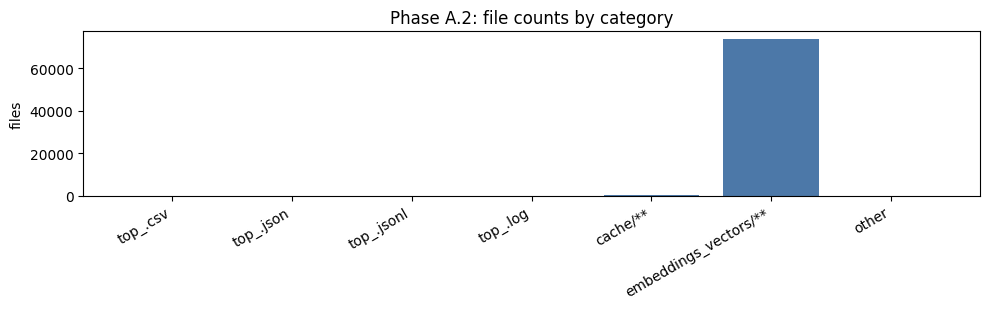

In [5]:
# Phase A.2 — Create run directory + artifact skeleton (no provider calls)

# Build config from env (runs are stored next to the notebook)
cfg = PipelineConfig.from_env(
    repo_root=REPO_ROOT,
    notebook_dir=NOTEBOOK_DIR,
    pipeline_version=pipeline_version,
)

# Apply notebook overrides (user inputs)
cfg = cfg.model_copy(update={'prune_n1_without_abstract': int(PRUNE_N1_NO_ABS)})

# Compute run_id from chapter inputs
run_id = compute_run_id(chapter_title, chapter_spec_text, cfg.pipeline_version)
run_dir = cfg.runs_root / run_id

artifacts = RunArtifacts(
    query_plan_json=run_dir / "query_plan.json",
    openalex_queries_json=run_dir / "openalex_queries.json",
    semanticscholar_queries_json=run_dir / "semanticscholar_queries.json",
    openalex_raw_jsonl=run_dir / "openalex_raw.jsonl",
    semanticscholar_raw_jsonl=run_dir / "semanticscholar_raw.jsonl",
    semanticscholar_recommendations_jsonl=run_dir / "semanticscholar_recommendations.jsonl",
    candidates_normalized_jsonl=run_dir / "candidates_normalized.jsonl",
    candidates_normalized_csv=run_dir / "candidates_normalized.csv",
    embeddings_manifest_jsonl=run_dir / "embeddings_manifest.jsonl",
    embeddings_manifest_csv=run_dir / "embeddings_manifest.csv",
    embeddings_vectors_dir=run_dir / "embeddings_vectors",
    rerank_results_jsonl=run_dir / "rerank_results.jsonl",
    output_json=run_dir / "output.json",
    logs_jsonl=run_dir / "logs.jsonl",
    run_log=run_dir / "run.log",
    metrics_json=run_dir / "metrics.json",
)

run_ctx = RunContext(repo_root=REPO_ROOT, run_id=run_id, run_dir=run_dir, artifacts=artifacts)

with stage_timer(run_ctx, "phase_a"):
    run_ctx.create_artifact_skeleton(overwrite=False)
    logger = setup_run_logger(run_ctx)
    log_event(run_ctx, stage="phase_a", event="run_initialized", run_id=run_id, run_dir=str(run_dir))

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault("phase_a", {})["initialized_at_utc"] = utc_now_iso()
    save_metrics(run_ctx, metrics)

# -----------------------------
# Reporting
# -----------------------------

expected_artifacts = {
    'query_plan.json': run_ctx.artifacts.query_plan_json,
    'openalex_queries.json': run_ctx.artifacts.openalex_queries_json,
    'semanticscholar_queries.json': run_ctx.artifacts.semanticscholar_queries_json,
    'openalex_raw.jsonl': run_ctx.artifacts.openalex_raw_jsonl,
    'semanticscholar_raw.jsonl': run_ctx.artifacts.semanticscholar_raw_jsonl,
    'semanticscholar_recommendations.jsonl': run_ctx.artifacts.semanticscholar_recommendations_jsonl,
    'candidates_normalized.jsonl': run_ctx.artifacts.candidates_normalized_jsonl,
    'candidates_normalized.csv': run_ctx.artifacts.candidates_normalized_csv,
    'embeddings_manifest.jsonl': run_ctx.artifacts.embeddings_manifest_jsonl,
    'embeddings_manifest.csv': run_ctx.artifacts.embeddings_manifest_csv,
    'embeddings_vectors_dir': run_ctx.artifacts.embeddings_vectors_dir,
    'rerank_results.jsonl': run_ctx.artifacts.rerank_results_jsonl,
    'output.json': run_ctx.artifacts.output_json,
    'logs.jsonl': run_ctx.artifacts.logs_jsonl,
    'run.log': run_ctx.artifacts.run_log,
    'metrics.json': run_ctx.artifacts.metrics_json,
}

missing_artifacts = []
for k, p in expected_artifacts.items():
    try:
        if not Path(p).exists():
            missing_artifacts.append(k)
    except Exception:
        missing_artifacts.append(k)

# Embedding vector count (warn if very large: suggests cache-driven / non-clean run)
vec_count = 0
try:
    vec_dir = Path(run_ctx.artifacts.embeddings_vectors_dir)
    if vec_dir.exists():
        vec_count = sum(1 for _ in vec_dir.rglob('*') if _.is_file())
except Exception:
    vec_count = 0

qc = []
qc.append(
    qc_row(
        check='artifact_skeleton',
        status='OK' if not missing_artifacts else 'FAIL',
        value=('missing: ' + ', '.join(missing_artifacts[:8])) if missing_artifacts else 'all present',
        expected='all expected artifacts exist',
        why='downstream stages rely on these paths',
        fix='Re-run Phase A.2 or check permissions/path issues',
    )
)
qc.append(
    qc_row(
        check='embeddings_vectors_files',
        status='WARN' if vec_count > 50000 else 'OK',
        value=_fmt_int(vec_count),
        expected='small for clean run',
        why='large vector cache suggests heavy reuse / not a clean run (fine, but interpret outputs accordingly)',
        fix='Optionally clear runs/<run_id>/embeddings_vectors for a clean measurement',
    )
)

# PRUNE sanity (now we can compare properly)
try:
    if int(cfg.prune_n1_without_abstract) > int(cfg.prune_n1):
        qc.append(
            qc_row(
                check='prune_n1_no_abs_vs_with_abs',
                status='WARN',
                value=f"{cfg.prune_n1_without_abstract} > {cfg.prune_n1}",
                expected='no_abs <= with_abs',
                why='metadata-only pool should typically be smaller (resource focus)',
                fix='Lower PRUNE_N1_NO_ABS (cell 0) or cfg.prune_n1_without_abstract',
            )
        )
    else:
        qc.append(
            qc_row(
                check='prune_n1_no_abs_vs_with_abs',
                status='OK',
                value=f"{cfg.prune_n1_without_abstract} <= {cfg.prune_n1}",
                expected='no_abs <= with_abs',
                why='keeps Stage2 work focused',
                fix='',
            )
        )
except Exception:
    pass

section_at_a_glance(
    'Phase A.2',
    {
        'run_id': run_id,
        'run_dir': run_dir,
        'runs_root': cfg.runs_root,
        'pipeline_version': cfg.pipeline_version,
        'query_budget/provider': cfg.max_queries_per_provider,
        'prune_n1(with_abs/no_abs)': f"{cfg.prune_n1}/{cfg.prune_n1_without_abstract}",
        'scoring_t(abs/noabs)': f"{cfg.scoring_t:.2f}/{cfg.scoring_t_noabs:.2f}",
        'embedding_model': cfg.embedding_model,
    },
    qc,
    {
        'query_plan.json': run_ctx.artifacts.query_plan_json,
        'openalex_queries.json': run_ctx.artifacts.openalex_queries_json,
        'semanticscholar_queries.json': run_ctx.artifacts.semanticscholar_queries_json,
        'metrics.json': run_ctx.artifacts.metrics_json,
    },
)

print_section('Phase A.2 — Config (critical)')
print_kv(
    {
        'pipeline_version': cfg.pipeline_version,
        'max_queries_per_provider': cfg.max_queries_per_provider,
        'openalex_rps': cfg.openalex_rps,
        's2_rps': cfg.semanticscholar_rps,
        'embedding_model': cfg.embedding_model,
        'embedding_batch_size': cfg.embedding_batch_size,
        'prune_n1_with_abs': cfg.prune_n1,
        'prune_n1_no_abs': cfg.prune_n1_without_abstract,
        'scoring_t': cfg.scoring_t,
        'scoring_t_noabs': cfg.scoring_t_noabs,
        'openai_model_planner': cfg.openai_model_planner,
    },
    key_width=28,
)

print_section('Phase A.2 — Config (full, masked)')
print_kv(cfg.masked(), key_width=32)

# -----------------------------
# Run dir inventory (summary)
# -----------------------------
import heapq


def _fmt_bytes(n: int) -> str:
    try:
        n = int(n)
    except Exception:
        return str(n)
    if n < 1024:
        return f"{n} B"
    if n < 1024 * 1024:
        return f"{n / 1024.0:.1f} KB"
    if n < 1024 * 1024 * 1024:
        return f"{n / (1024.0 * 1024.0):.2f} MB"
    return f"{n / (1024.0 * 1024.0 * 1024.0):.2f} GB"


def _fmt_mtime(ts: float) -> str:
    try:
        return datetime.fromtimestamp(float(ts), tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%SZ')
    except Exception:
        return ''


cats = {
    'top_.json': {'n': 0, 'bytes': 0},
    'top_.jsonl': {'n': 0, 'bytes': 0},
    'top_.csv': {'n': 0, 'bytes': 0},
    'top_.log': {'n': 0, 'bytes': 0},
    'cache/**': {'n': 0, 'bytes': 0},
    'embeddings_vectors/**': {'n': 0, 'bytes': 0},
    'other': {'n': 0, 'bytes': 0},
}

largest: List[tuple[int, str, float]] = []  # (size, relpath, mtime)
newest: List[tuple[float, str, int]] = []  # (mtime, relpath, size)

run_dir_path = Path(run_dir)
for p in run_dir_path.rglob('*'):
    if not p.is_file():
        continue
    try:
        st = p.stat()
    except Exception:
        continue

    size = int(st.st_size)
    mtime = float(st.st_mtime)
    try:
        rel = str(p.relative_to(run_dir_path))
    except Exception:
        rel = str(p)

    # category
    cat = 'other'
    try:
        if p.is_relative_to(run_dir_path / 'cache'):
            cat = 'cache/**'
        elif p.is_relative_to(Path(run_ctx.artifacts.embeddings_vectors_dir)):
            cat = 'embeddings_vectors/**'
        elif p.parent == run_dir_path and p.suffix.lower() in {'.json', '.jsonl', '.csv', '.log'}:
            cat = f"top_{p.suffix.lower()}"
    except Exception:
        pass

    if cat not in cats:
        cats[cat] = {'n': 0, 'bytes': 0}

    cats[cat]['n'] += 1
    cats[cat]['bytes'] += size

    # largest 10
    if len(largest) < 10:
        heapq.heappush(largest, (size, rel, mtime))
    else:
        heapq.heappushpop(largest, (size, rel, mtime))

    # newest 10
    if len(newest) < 10:
        heapq.heappush(newest, (mtime, rel, size))
    else:
        heapq.heappushpop(newest, (mtime, rel, size))

rows_cat = []
for cat, v in cats.items():
    rows_cat.append({'category': cat, 'files': _fmt_int(v['n']), 'size': _fmt_bytes(v['bytes'])})
rows_cat.sort(key=lambda r: (0 if r['category'].startswith('top_') else 1, r['category']))

print_section('Phase A.2 — Run dir inventory (summary)')
print_table(rows_cat, columns=['category', 'files', 'size'], max_rows=50, max_col_width=40)

largest_rows = [
    {'path': rel, 'size': _fmt_bytes(size), 'mtime_utc': _fmt_mtime(mtime)}
    for (size, rel, mtime) in sorted(largest, key=lambda t: t[0], reverse=True)
]
print_section('Phase A.2 — Largest files')
print_table(largest_rows, columns=['path', 'size', 'mtime_utc'], max_rows=20, max_col_width=120)

newest_rows = [
    {'path': rel, 'mtime_utc': _fmt_mtime(mtime), 'size': _fmt_bytes(size)}
    for (mtime, rel, size) in sorted(newest, key=lambda t: t[0], reverse=True)
]
print_section('Phase A.2 — Newest files')
print_table(newest_rows, columns=['path', 'mtime_utc', 'size'], max_rows=20, max_col_width=120)

# Optional plot: file counts by category
try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception:
    plt = None

if plt is not None:
    try:
        labels = [r['category'] for r in rows_cat]
        vals = [int(str(r['files']).replace(',', '')) if str(r['files']).replace(',', '').isdigit() else 0 for r in rows_cat]
        plt.figure(figsize=(10, 3.2))
        plt.bar(labels, vals, color='#4c78a8')
        plt.title('Phase A.2: file counts by category')
        plt.ylabel('files')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
    except Exception:
        pass


---
# Phase B — LLM query planner
--- 

## Phase B.1 — Data models (strict) for the Query Planner output

In [6]:
# Phase B.1 — Data models (strict) for the Query Planner output

from typing import List


class BilingualTerms(BaseModel):
    model_config = ConfigDict(extra="forbid")

    en: List[str] = Field(default_factory=list)
    de: List[str] = Field(default_factory=list)


class Facet(BaseModel):
    model_config = ConfigDict(extra="forbid")

    facet_id: str
    facet_label_en: str
    facet_label_de: str
    facet_type: str
    importance_weight: int = Field(ge=1, le=5)
    text_en: str
    text_de: str
    canonical_terms: BilingualTerms
    neighbor_terms: BilingualTerms
    exclusion_terms: BilingualTerms


class QueryPlan(BaseModel):
    model_config = ConfigDict(extra="forbid")

    topic_summary_en: str
    topic_summary_de: str
    primary_context_anchors: BilingualTerms
    facets: List[Facet]
    global_canonical_terms: BilingualTerms
    global_exclusions: BilingualTerms


class ChapterInput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    chapter_title: str
    chapter_spec_text: str
    pipeline_version: str

    def compute_run_id(self) -> str:
        return compute_run_id(self.chapter_title, self.chapter_spec_text, self.pipeline_version)


## Phase B.2 — OpenAI helpers: strict JSON schema outputs + token/cost tracking

In [7]:
# Phase B.2 — OpenAI helpers: strict JSON schema outputs + token/cost tracking

import json
import time
import re
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

from openai import OpenAI


# Model prices (USD per *1M tokens*) — verify periodically.
# NOTE: cached token pricing can differ; set the correct values for your account.
MODEL_PRICES_USD_PER_1M: Dict[str, Dict[str, float]] = {
    "gpt-5.2": {"input": 1.75, "cached": 1.75, "output": 14.00},
    "gpt-5-mini": {"input": 0.25, "cached": 0.25, "output": 2.00},
    "gpt-5-nano": {"input": 0.05, "cached": 0.05, "output": 0.40},
}


def resolve_pricing_key(model_name: str) -> Optional[str]:
    model_lower = (model_name or "").lower()
    normalized = {k.lower(): k for k in MODEL_PRICES_USD_PER_1M}

    if model_lower in normalized:
        return normalized[model_lower]

    # Strip trailing release suffix: -YYYY-MM-DD
    date_stripped = re.sub(r"-20\d{2}-\d{2}-\d{2}$", "", model_lower)
    if date_stripped in normalized:
        return normalized[date_stripped]

    # Prefix match: gpt-5.2-foo
    for k_lower, original in normalized.items():
        if model_lower.startswith(k_lower + "-"):
            return original

    return None


def extract_usage(response) -> Dict[str, int]:
    usage = getattr(response, "usage", None)
    if usage is None:
        return {
            "input_tokens": 0,
            "output_tokens": 0,
            "reasoning_tokens": 0,
            "cached_input_tokens": 0,
        }

    input_tokens = int(getattr(usage, "input_tokens", None) or getattr(usage, "prompt_tokens", None) or 0)
    output_tokens = int(getattr(usage, "output_tokens", None) or getattr(usage, "completion_tokens", None) or 0)

    cached_input_tokens = 0
    input_details = getattr(usage, "input_tokens_details", None) or getattr(usage, "prompt_tokens_details", None)
    if input_details is not None:
        cached_input_tokens = int(getattr(input_details, "cached_tokens", 0) or 0)

    reasoning_tokens = 0
    out_details = getattr(usage, "output_tokens_details", None) or getattr(usage, "completion_tokens_details", None)
    if out_details is not None:
        reasoning_tokens = int(getattr(out_details, "reasoning_tokens", 0) or 0)

    return {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "reasoning_tokens": reasoning_tokens,
        "cached_input_tokens": cached_input_tokens,
    }


def estimate_cost_usd(
    *,
    model_used: str,
    input_tokens: int,
    cached_input_tokens: int,
    output_tokens: int,
) -> Dict[str, Any]:
    key = resolve_pricing_key(model_used)
    if key is None:
        return {
            "pricing_key": None,
            "input_cost_usd": 0.0,
            "cached_input_cost_usd": 0.0,
            "output_cost_usd": 0.0,
            "total_cost_usd": 0.0,
            "note": f"No pricing found for model={model_used!r}; update MODEL_PRICES_USD_PER_1M.",
        }

    prices = MODEL_PRICES_USD_PER_1M[key]
    in_price = float(prices.get("input", 0.0) or 0.0)
    cached_price = float(prices.get("cached", in_price) or in_price)
    out_price = float(prices.get("output", 0.0) or 0.0)

    cached_input_tokens = max(0, min(int(cached_input_tokens or 0), int(input_tokens or 0)))
    billable_input_tokens = max(int(input_tokens or 0) - cached_input_tokens, 0)

    input_cost = (billable_input_tokens / 1_000_000) * in_price
    cached_cost = (cached_input_tokens / 1_000_000) * cached_price
    output_cost = (int(output_tokens or 0) / 1_000_000) * out_price

    return {
        "pricing_key": key,
        "price_per_million": {"input": in_price, "cached": cached_price, "output": out_price},
        "billable_input_tokens": billable_input_tokens,
        "input_cost_usd": float(input_cost),
        "cached_input_cost_usd": float(cached_cost),
        "output_cost_usd": float(output_cost),
        "total_cost_usd": float(input_cost + cached_cost + output_cost),
        "note": "output_tokens already includes reasoning_tokens; reasoning_tokens is shown for diagnostics only.",
    }


def _response_to_jsonable(response) -> Dict[str, Any]:
    if response is None:
        return {}

    if hasattr(response, "model_dump"):
        try:
            return response.model_dump(mode="json")
        except TypeError:
            return response.model_dump()
        except Exception:
            pass

    if hasattr(response, "to_dict"):
        try:
            return response.to_dict()
        except Exception:
            pass

    return {"repr": repr(response)}


def extract_output_text_or_refusal(response) -> Tuple[str, Optional[str]]:
    text = getattr(response, "output_text", None)
    if isinstance(text, str) and text.strip():
        return text, None

    parts = []
    refusal = None

    output_items = getattr(response, "output", None) or []
    for item in output_items:
        item_type = item.get("type") if isinstance(item, dict) else getattr(item, "type", None)
        if item_type != "message":
            continue

        content_items = item.get("content") if isinstance(item, dict) else getattr(item, "content", None)
        for c in content_items or []:
            c_type = c.get("type") if isinstance(c, dict) else getattr(c, "type", None)
            if c_type == "output_text":
                t = c.get("text") if isinstance(c, dict) else getattr(c, "text", None)
                if t:
                    parts.append(str(t))
            elif c_type == "refusal":
                r = c.get("refusal") if isinstance(c, dict) else getattr(c, "refusal", None)
                if r:
                    refusal = (str(refusal) + "\n" + str(r)) if refusal else str(r)

    joined = "\n".join([p for p in parts if str(p).strip()])
    return joined, refusal


def _step_down_reasoning_effort(effort: str) -> str:
    order = ["high", "medium", "low", "minimal"]
    e = (effort or "").strip().lower()
    if e not in order:
        return effort
    idx = order.index(e)
    return order[min(idx + 1, len(order) - 1)]


def _parse_max_output_tokens_limit(msg: str) -> Optional[int]:
    if not msg:
        return None

    patterns = [
        r"max_output_tokens\s*must\s*be\s*<=\s*(\d+)",
        r"max_output_tokens\s*must\s*be\s*less\s*than\s*or\s*equal\s*to\s*(\d+)",
        r"max_output_tokens.*?maximum\s*(?:is|of)\s*(\d+)",
        r"maximum\s*max_output_tokens\s*(?:is|of)\s*(\d+)",
    ]
    for pat in patterns:
        m = re.search(pat, msg, flags=re.IGNORECASE)
        if m:
            try:
                return int(m.group(1))
            except Exception:
                return None

    return None


def openai_json_schema_call(
    *,
    api_key: str,
    model: str,
    system_prompt: str,
    user_prompt: str,
    schema_name: str,
    schema: Dict[str, Any],
    reasoning_effort: str = "high",
    max_output_tokens: int = 8000,
    timeout_s: float = 120.0,
    debug_dir: Optional[Path] = None,
    debug_prefix: str = "openai",
) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    """Minimal helper: build prompt, send request, parse strict JSON, return usage + cost.

    Uses `background=True` + polling to avoid long-lived HTTP read timeouts.
    """

    if not api_key:
        raise ValueError("OPENAI_API_KEY is missing. Set it in your repo .env (or environment) before Phase B.")

    client = OpenAI(api_key=api_key)

    max_output_tokens = max(256, int(max_output_tokens or 0))
    overall_timeout_s = float(timeout_s or 120.0)

    http_timeout_create_s = float(min(max(30.0, overall_timeout_s), 600.0))
    http_timeout_poll_s = float(min(60.0, http_timeout_create_s))

    def _dump(*, response=None, raw_text=None, refusal=None, exc=None, call_meta=None):
        if debug_dir is None:
            return
        try:
            ensure_dir(debug_dir)
            (debug_dir / f"{debug_prefix}.system_prompt.txt").write_text(system_prompt, encoding="utf-8")
            (debug_dir / f"{debug_prefix}.user_prompt.txt").write_text(user_prompt, encoding="utf-8")
            if call_meta is not None:
                write_json(debug_dir / f"{debug_prefix}.call_meta.json", call_meta)
            if response is not None:
                write_json(debug_dir / f"{debug_prefix}.response.json", _response_to_jsonable(response))
            if raw_text is not None:
                (debug_dir / f"{debug_prefix}.output_text.txt").write_text(raw_text or "", encoding="utf-8")
            if refusal:
                (debug_dir / f"{debug_prefix}.refusal.txt").write_text(str(refusal), encoding="utf-8")
            if exc is not None:
                write_json(debug_dir / f"{debug_prefix}.exception.json", {"error": str(exc), "type": type(exc).__name__})
        except Exception:
            pass

    t0 = time.time()
    try:
        response = client.responses.create(
            model=model,
            input=[
                {"role": "system", "content": [{"type": "input_text", "text": system_prompt}]},
                {"role": "user", "content": [{"type": "input_text", "text": user_prompt}]},
            ],
            reasoning={"effort": reasoning_effort},
            max_output_tokens=max_output_tokens,
            text={
                "format": {
                    "type": "json_schema",
                    "name": schema_name,
                    "schema": schema,
                    "strict": True,
                }
            },
            background=True,
            timeout=http_timeout_create_s,
        )

        response_id = getattr(response, "id", None)
        terminal_statuses = {"completed", "incomplete", "failed", "cancelled", "canceled"}

        poll_t0 = time.time()
        poll_sleep_s = 1.0
        while getattr(response, "status", None) not in terminal_statuses:
            if (time.time() - poll_t0) > overall_timeout_s:
                raise TimeoutError(
                    f"OpenAI background response timed out after {int(overall_timeout_s)}s "
                    f"(last_status={getattr(response, 'status', None)!r}, response_id={response_id!r})."
                )
            time.sleep(poll_sleep_s)
            poll_sleep_s = min(poll_sleep_s * 1.5, 10.0)
            response = client.responses.retrieve(response_id, timeout=http_timeout_poll_s)

        dt = time.time() - t0

        model_used = getattr(response, "model", None) or model
        status = getattr(response, "status", None)
        incomplete_details = getattr(response, "incomplete_details", None)
        incomplete_reason = (
            incomplete_details.get("reason")
            if isinstance(incomplete_details, dict)
            else getattr(incomplete_details, "reason", None)
        )

        usage = extract_usage(response)
        raw_text, refusal = extract_output_text_or_refusal(response)

        call_meta = {
            "model_requested": model,
            "model_used": model_used,
            "response_id": response_id,
            "status": status,
            "incomplete_reason": incomplete_reason,
            "latency_s": round(dt, 3),
            "usage": usage,
            "reasoning_effort": reasoning_effort,
            "max_output_tokens": max_output_tokens,
            "timeout_s": overall_timeout_s,
            "http_timeout_create_s": http_timeout_create_s,
            "http_timeout_poll_s": http_timeout_poll_s,
        }

        _dump(response=response, raw_text=raw_text, refusal=refusal, call_meta=call_meta)

        if refusal and not (raw_text or "").strip():
            raise ValueError(f"OpenAI refused the request: {refusal}")

        if not (raw_text or "").strip():
            raise ValueError(
                "OpenAI response had no output_text. "
                f"status={status!r} incomplete_reason={incomplete_reason!r} "
                f"response_id={response_id!r} usage={usage}."
            )

        obj = json.loads(raw_text)

        cost = estimate_cost_usd(
            model_used=model_used,
            input_tokens=usage.get("input_tokens", 0),
            cached_input_tokens=usage.get("cached_input_tokens", 0),
            output_tokens=usage.get("output_tokens", 0),
        )

        meta = {
            "model_requested": model,
            "model_used": model_used,
            "response_id": response_id,
            "latency_s": round(dt, 3),
            "usage": usage,
            "cost_estimate": cost,
            "status": status,
            "incomplete_reason": incomplete_reason,
        }
        return obj, meta

    except Exception as e:
        _dump(exc=e)
        raise


    raise RuntimeError("openai_json_schema_call: exhausted attempts without returning")



## Phase B.3 — LLM Query Planner (facet extraction; atomic bilingual facets)

In [8]:
# Phase B.3 — LLM Query Planner (facet extraction; atomic bilingual facets)

import traceback
import re
from typing import Any, Dict, List, Optional, Tuple


QUERY_PLAN_JSON_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "required": [
        "topic_summary_en",
        "topic_summary_de",
        "primary_context_anchors",
        "facets",
        "global_canonical_terms",
        "global_exclusions",
    ],
    "properties": {
        "topic_summary_en": {"type": "string"},
        "topic_summary_de": {"type": "string"},
        "primary_context_anchors": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "global_canonical_terms": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "global_exclusions": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "facets": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": [
                    "facet_id",
                    "facet_label_en",
                    "facet_label_de",
                    "facet_type",
                    "importance_weight",
                    "text_en",
                    "text_de",
                    "canonical_terms",
                    "neighbor_terms",
                    "exclusion_terms",
                ],
                "properties": {
                    "facet_id": {"type": "string"},
                    "facet_label_en": {"type": "string"},
                    "facet_label_de": {"type": "string"},
                    "facet_type": {
                        "type": "string",
                        "enum": [
                            "background",
                            "theory",
                            "mechanism",
                            "methods",
                            "data",
                            "measurement",
                            "evaluation",
                            "case_context",
                            "debate",
                            "limitations",
                            "applications",
                        ],
                    },
                    "importance_weight": {"type": "integer", "minimum": 1, "maximum": 5},
                    "text_en": {"type": "string"},
                    "text_de": {"type": "string"},
                    "canonical_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                    "neighbor_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                    "exclusion_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                },
            },
        },
    },
}


PLANNER_SYSTEM_PROMPT = """You are a scientific literature search planner. Convert a chapter title and a ~200-word chapter specification into a bilingual (EN+DE) query plan for downstream APIs.
You must be deterministic and consistent across any domain.
Do NOT name specific papers, authors, or venues. Do NOT invent citations.
"""

PLANNER_USER_PROMPT_TEMPLATE = """CHAPTER_TITLE:
{{chapter_title}}

CHAPTER_SPEC (instructions):
{{chapter_spec_text}}

TASK:
Return a QueryPlan JSON object with these keys:

1) topic_summary_en: 2–3 sentences
2) topic_summary_de: 2–3 sentences (natural German)

3) primary_context_anchors:
   - en: 3–8 short anchors that uniquely pin the topic (prefer proper nouns, named constructs, standard period/organism/method names)
   - de: 3–8 short anchors (German equivalents + common English terms used in German literature)
   RULES:
   - Each anchor must be 1–6 words.
   - No generic research words: analysis, study, effects, mechanism, framework, model, system, approach, dynamics, development, review, overview
     German: Analyse, Studie, Effekte, Mechanismus, Rahmen, Modell, System, Ansatz, Dynamik, Entwicklung, Überblick
   - Avoid long narrative phrases. Avoid parentheses and commas inside anchors.

4) global_canonical_terms:
   - en: 12–30 terms/phrases (topic terms + synonyms + abbreviations)
   - de: 12–30 terms/phrases (German equivalents + common English loan terms)
   TERM HYGIENE (MANDATORY for ALL term lists):
   - Each term must be <= 4 words.
   - No explanatory text, no “e.g.” / “z. B.”.
   - No parentheses, no commas, no semicolons.
   - No “modern … jargon” type commentary; only tokens likely to appear in titles/abstracts.

5) global_exclusions:
   - en: 0–12 atomic confounder terms (<= 3 words each)
   - de: 0–12 atomic confounder terms (<= 3 words each)
   EXCLUSION RULES:
   - Only include exclusions that are likely to appear in unrelated literature and cause wrong-sense retrieval.
   - No punctuation except hyphen. No parentheses. No example phrases.

6) facets: 8–20 ATOMIC facets (one requirement each).
For each facet:
- facet_id: lower_snake_case, 3–6 words, stable
- facet_type: one of ["background","theory","mechanism","methods","data","measurement","evaluation","case_context","debate","limitations","applications"]
- importance_weight: integer 1..5 (5 = explicitly required, 4 = important support, 3 = common subtopic, 2 peripheral, 1 optional)
- facet_label_en: <= 8 words
- facet_label_de: <= 8 words
- text_en: 1–2 sentences
- text_de: 1–2 sentences
- canonical_terms.en/de: 6–18 terms each (must follow TERM HYGIENE)
- neighbor_terms.en/de: 4–12 terms each (must follow TERM HYGIENE)
- exclusion_terms.en/de: 0–6 terms each (must follow EXCLUSION RULES)

QUALITY RULES:
- Cover all explicit instructions in the chapter spec via facets (no gaps).
- Add 2–4 neighbor facets that are commonly necessary but not explicitly listed.
- Keep facets non-overlapping as much as possible.
- Prefer technical terms over vague words.
- If the topic is ambiguous, add exclusions to disambiguate.

OUTPUT:
Return ONLY valid JSON. No extra text.
"""


def planner_user_prompt(chapter_input: ChapterInput) -> str:
    s = PLANNER_USER_PROMPT_TEMPLATE
    s = s.replace("{{chapter_title}}", chapter_input.chapter_title.strip())
    s = s.replace("{{chapter_spec_text}}", chapter_input.chapter_spec_text.strip())
    return s


_BAD_EXCL_PAT = re.compile(r"(e\.g\.|z\.\s*b\.|,|\(|\)|;|:)", re.IGNORECASE)
_BAD_TERM_PAT = re.compile(r"(e\.g\.|z\.\s*b\.|\(|\)|,|;)", re.IGNORECASE)

_GENERIC_RESEARCH_WORDS = [
    "analysis",
    "study",
    "effects",
    "mechanism",
    "framework",
    "model",
    "system",
    "approach",
    "dynamics",
    "development",
    "review",
    "overview",
    "analyse",
    "studie",
    "effekte",
    "mechanismus",
    "rahmen",
    "modell",
    "system",
    "ansatz",
    "dynamik",
    "entwicklung",
    "überblick",
]
_GENERIC_RESEARCH_WORD_PAT = re.compile(r"\b(" + "|".join(re.escape(w) for w in _GENERIC_RESEARCH_WORDS) + r")\b", re.IGNORECASE)


def _word_count(text: str) -> int:
    return len([w for w in re.split(r"\s+", str(text or "").strip()) if w])


def _is_atomic_exclusion(term: str) -> bool:
    t = str(term or "").strip()
    if not t:
        return False
    if _BAD_EXCL_PAT.search(t):
        return False
    if len(t) > 40:
        return False
    if _word_count(t) > 3:
        return False
    if re.search(r"[^\w\s-]", t, flags=re.UNICODE):
        return False
    return True


def _is_hygienic_term(term: str, *, max_words: int) -> bool:
    t = str(term or "").strip()
    if not t:
        return False
    if _BAD_TERM_PAT.search(t):
        return False
    if _word_count(t) > int(max_words):
        return False
    return True


def diagnose_query_plan(plan: QueryPlan) -> Dict[str, Any]:
    issues: List[str] = []

    n_facets = len(plan.facets)
    if n_facets < 8 or n_facets > 20:
        issues.append(f"CRITICAL: facet count is {n_facets} (expected 8–20).")

    ids = [f.facet_id for f in plan.facets]
    dup_ids = sorted({x for x in ids if ids.count(x) > 1})
    if dup_ids:
        issues.append(f"CRITICAL: duplicate facet_id(s): {dup_ids}")

    bad_weights = [f.facet_id for f in plan.facets if not (1 <= f.importance_weight <= 5)]
    if bad_weights:
        issues.append(f"CRITICAL: facets with invalid importance_weight: {bad_weights}")

    # Primary context anchors
    for lang in ("en", "de"):
        anchors = getattr(plan.primary_context_anchors, lang, []) or []
        if len(anchors) < 3 or len(anchors) > 8:
            issues.append(f"CRITICAL: primary_context_anchors.{lang} has {len(anchors)} items (expected 3–8).")

        bad = []
        for a in anchors:
            aa = str(a or "").strip()
            if not aa:
                bad.append(a)
                continue
            if not _is_hygienic_term(aa, max_words=6):
                bad.append(aa)
                continue
            if _GENERIC_RESEARCH_WORD_PAT.search(aa):
                bad.append(aa)
                continue
        if bad:
            issues.append(f"CRITICAL: primary_context_anchors.{lang} contains invalid/generic anchors: {bad[:6]}")

    # Term hygiene checks
    def check_term_list(name: str, terms: List[str], *, max_words: int) -> None:
        bad_terms = [t for t in (terms or []) if not _is_hygienic_term(t, max_words=max_words)]
        if bad_terms:
            issues.append(f"CRITICAL: {name} contains non-hygienic terms: {bad_terms[:8]}")

    check_term_list("global_canonical_terms.en", plan.global_canonical_terms.en, max_words=4)
    check_term_list("global_canonical_terms.de", plan.global_canonical_terms.de, max_words=4)

    # Exclusion atomicity checks
    def check_exclusions(name: str, terms: List[str]) -> None:
        bad_terms = [t for t in (terms or []) if not _is_atomic_exclusion(t)]
        if bad_terms:
            issues.append(f"CRITICAL: {name} contains non-atomic exclusions: {bad_terms[:8]}")

    check_exclusions("global_exclusions.en", plan.global_exclusions.en)
    check_exclusions("global_exclusions.de", plan.global_exclusions.de)

    for f in plan.facets:
        check_term_list(f"facet[{f.facet_id}].canonical_terms.en", f.canonical_terms.en, max_words=4)
        check_term_list(f"facet[{f.facet_id}].canonical_terms.de", f.canonical_terms.de, max_words=4)
        check_term_list(f"facet[{f.facet_id}].neighbor_terms.en", f.neighbor_terms.en, max_words=4)
        check_term_list(f"facet[{f.facet_id}].neighbor_terms.de", f.neighbor_terms.de, max_words=4)
        check_exclusions(f"facet[{f.facet_id}].exclusion_terms.en", f.exclusion_terms.en)
        check_exclusions(f"facet[{f.facet_id}].exclusion_terms.de", f.exclusion_terms.de)

    # Very rough overlap heuristic: identical canonical term sets.
    canon_sets: Dict[Tuple[Tuple[str, ...], Tuple[str, ...]], str] = {}
    overlaps: List[Tuple[str, str]] = []
    for f in plan.facets:
        key = (
            tuple(sorted({t.strip().lower() for t in f.canonical_terms.en if str(t or "").strip()})),
            tuple(sorted({t.strip().lower() for t in f.canonical_terms.de if str(t or "").strip()})),
        )
        if key in canon_sets and key != ((), ()):
            overlaps.append((canon_sets[key], f.facet_id))
        else:
            canon_sets[key] = f.facet_id

    if overlaps:
        issues.append(f"Potential duplicate facets (identical canonical_terms): {overlaps[:5]}")

    critical = [x for x in issues if str(x).startswith("CRITICAL:")]
    return {"facet_count": n_facets, "issues": issues, "critical_issues": critical}


def _is_placeholder_cache(obj: Any) -> bool:
    if not isinstance(obj, dict):
        return False
    meta = obj.get("_meta")
    return isinstance(meta, dict) and meta.get("placeholder") is True


def plan_queries_llm(
    chapter_input: ChapterInput,
    *,
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[QueryPlan, Dict[str, Any]]:
    stage = "phase_b_query_planner"
    cache_path = run_ctx.artifacts.query_plan_json

    if cache_path.exists() and not force_rebuild:
        try:
            cached_obj = read_json(cache_path)
            if _is_placeholder_cache(cached_obj):
                log_event(run_ctx, stage=stage, event="cache_placeholder_ignored", path=str(cache_path))
            else:
                plan = QueryPlan.model_validate(cached_obj)
                meta = {
                    "cache_hit": True,
                    "usage": {
                        "input_tokens": 0,
                        "cached_input_tokens": 0,
                        "output_tokens": 0,
                        "reasoning_tokens": 0,
                    },
                    "cost_estimate": {"total_cost_usd": 0.0},
                    "diagnostics": diagnose_query_plan(plan),
                }
                log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path))
                return plan, meta
        except Exception as e:
            err = str(e)
            err_short = err if len(err) <= 800 else (err[:800] + "…")
            write_json(
                run_ctx.run_dir / "query_plan.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err_short)

    user_prompt = planner_user_prompt(chapter_input)

    max_attempts = 3
    last_err: Optional[Exception] = None
    obj: Dict[str, Any] = {}
    meta: Dict[str, Any] = {}
    plan: Optional[QueryPlan] = None

    with stage_timer(run_ctx, stage):
        for attempt in range(1, max_attempts + 1):
            debug_prefix = f"query_plan_attempt{attempt}"
            attempt_prompt = user_prompt
            if last_err is not None:
                attempt_prompt = (
                    user_prompt
                    + "\n\nLINT_FEEDBACK:\n- Previous attempt failed deterministic validation. Fix and regenerate.\n"
                    + f"- Error: {str(last_err)[:600]}\n"
                )

            try:
                obj, meta = openai_json_schema_call(
                    api_key=config.openai_api_key or "",
                    model=config.openai_model_planner,
                    system_prompt=PLANNER_SYSTEM_PROMPT,
                    user_prompt=attempt_prompt,
                    schema_name="query_plan",
                    schema=QUERY_PLAN_JSON_SCHEMA,
                    reasoning_effort=config.openai_reasoning_effort,
                    max_output_tokens=getattr(config, "openai_max_output_tokens_planner", 6000),
                    timeout_s=config.openai_timeout_s,
                    debug_dir=run_ctx.run_dir,
                    debug_prefix=debug_prefix,
                )
            except Exception as e:
                last_err = e
                dbg = {
                    "ts": utc_now_iso(),
                    "stage": stage,
                    "attempt": attempt,
                    "error": str(e),
                    "traceback": traceback.format_exc(),
                    "chapter_title": chapter_input.chapter_title,
                    "pipeline_version": chapter_input.pipeline_version,
                }
                write_json(run_ctx.run_dir / f"{debug_prefix}.error.json", dbg)
                log_event(run_ctx, stage=stage, event="openai_error", attempt=attempt, error=str(e)[:800])
                if attempt >= max_attempts:
                    raise
                continue

            attempt_raw_path = run_ctx.run_dir / f"{debug_prefix}.raw_output.json"
            attempt_meta_path = run_ctx.run_dir / f"{debug_prefix}.openai_meta.json"
            write_json(attempt_raw_path, obj)
            write_json(attempt_meta_path, meta)

            try:
                plan = QueryPlan.model_validate(obj)
                diag = diagnose_query_plan(plan)
                critical = diag.get("critical_issues") or []
                if critical:
                    raise ValueError("QueryPlan failed hygiene checks: " + "; ".join([str(x) for x in critical[:6]]))

                # Success: keep stable "latest" files.
                write_json(run_ctx.run_dir / "query_plan.raw_output.json", obj)
                write_json(run_ctx.run_dir / "query_plan.openai_meta.json", meta)
                break

            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="lint_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                    raw_path=str(attempt_raw_path),
                )
                if attempt >= max_attempts:
                    raise
                continue

    if plan is None:
        raise RuntimeError("QueryPlan generation failed unexpectedly (no plan).")

    write_json(cache_path, plan.model_dump(mode="json"))
    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        path=str(cache_path),
        model_used=meta.get("model_used"),
        usage=meta.get("usage"),
        cost=meta.get("cost_estimate"),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["openai"] = meta
    save_metrics(run_ctx, metrics)

    meta = dict(meta)
    meta["cache_hit"] = False
    meta["diagnostics"] = diagnose_query_plan(plan)
    return plan, meta



## Phase B.4 — Run the planner + inspect facets

Phase B.4 — At a glance
cache_hit                True
run_id                   4af2666be828e5054ccf4d31
run_dir                  <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31
query_plan.json          <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\query_plan.json
facets                   17
anchors(en/de)           8/8
Phase B.4 — QC
QC: OK=7 WARN=0 FAIL=0
status | check                      | value        | expected         | why                                                                             | fix                                                                 
-------+----------------------------+--------------+------------------+---------------------------------------------------------------------------------+---------------------------------------------------------------------
OK     | duplicate_facet_id         | none         | none             | duplicates break scoring alignment and coverage accounting                      | Fix planner

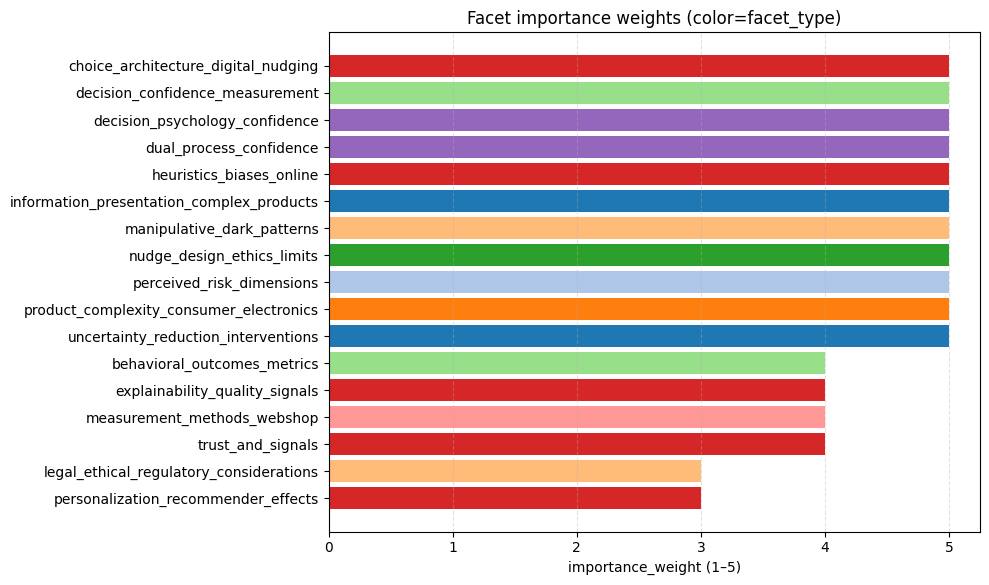

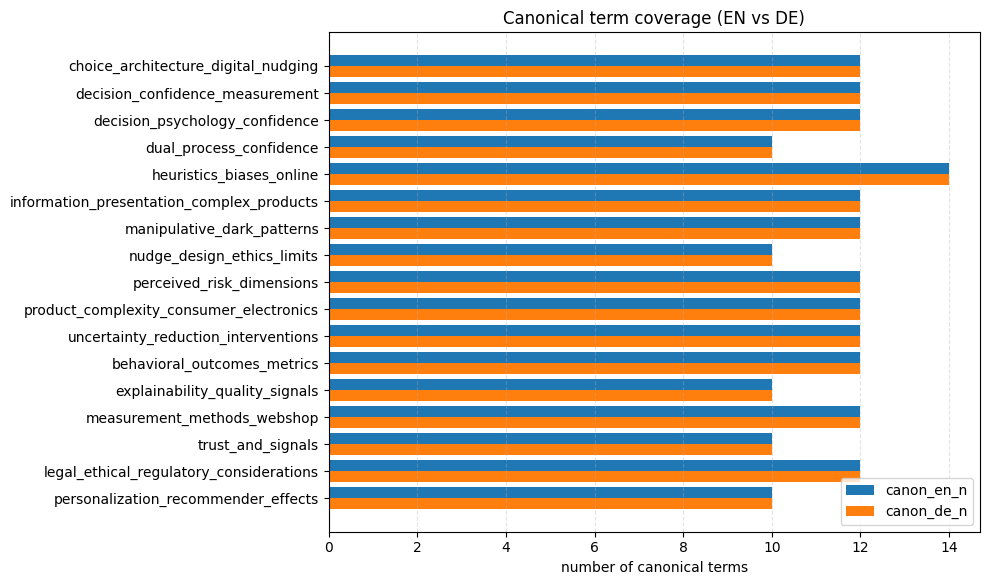

In [9]:
# Phase B.4 — Run the planner + inspect facets

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None
    print("[WARN] matplotlib not available; facet plot will be skipped. Install with: pip install matplotlib")


import textwrap


def _print_paragraph(text: str, width: int = 100) -> None:
    s = str(text or "").strip()
    if not s:
        print("<empty>")
        return
    print(textwrap.fill(s, width=width))


def _join_terms(terms, *, max_terms: int = 14, max_chars: int = 220) -> str:
    arr = [str(t).strip() for t in (terms or []) if str(t).strip()]
    s = ", ".join(arr[:max_terms])
    if len(arr) > max_terms:
        s = s + f", …(+{len(arr) - max_terms})"
    if len(s) > max_chars:
        s = s[: max_chars - 1] + "…"
    return s




chapter_input = ChapterInput(
    chapter_title=chapter_title,
    chapter_spec_text=chapter_spec_text,
    pipeline_version=pipeline_version,
)

expected_run_id = chapter_input.compute_run_id()
if expected_run_id != run_ctx.run_id:
    print_section("Phase B.4 — Warning")
    print_kv(
        {
            "msg": "run_id mismatch; rebuilding Phase A context with current inputs",
            "expected_run_id": expected_run_id,
            "current_run_id": run_ctx.run_id,
        },
        key_width=16,
    )

    run_id = expected_run_id
    run_dir = cfg.runs_root / run_id

    artifacts = artifacts.model_copy(
        update={
            "query_plan_json": run_dir / "query_plan.json",
            "openalex_queries_json": run_dir / "openalex_queries.json",
            "semanticscholar_queries_json": run_dir / "semanticscholar_queries.json",
            "openalex_raw_jsonl": run_dir / "openalex_raw.jsonl",
            "semanticscholar_raw_jsonl": run_dir / "semanticscholar_raw.jsonl",
            "semanticscholar_recommendations_jsonl": run_dir / "semanticscholar_recommendations.jsonl",
            "candidates_normalized_jsonl": run_dir / "candidates_normalized.jsonl",
            "candidates_normalized_csv": run_dir / "candidates_normalized.csv",
            "embeddings_manifest_jsonl": run_dir / "embeddings_manifest.jsonl",
            "embeddings_manifest_csv": run_dir / "embeddings_manifest.csv",
            "embeddings_vectors_dir": run_dir / "embeddings_vectors",
            "rerank_results_jsonl": run_dir / "rerank_results.jsonl",
            "output_json": run_dir / "output.json",
            "logs_jsonl": run_dir / "logs.jsonl",
            "run_log": run_dir / "run.log",
            "metrics_json": run_dir / "metrics.json",
        }
    )

    run_ctx = RunContext(repo_root=REPO_ROOT, run_id=run_id, run_dir=run_dir, artifacts=artifacts)
    run_ctx.create_artifact_skeleton(overwrite=False)
    logger = setup_run_logger(run_ctx)


plan, meta = plan_queries_llm(
    chapter_input,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_QUERY_PLAN,
)

diag = meta.get("diagnostics") or diagnose_query_plan(plan)

# -----------------------------
# Reporting (print-first)
# -----------------------------

facet_count = safe_len(getattr(plan, 'facets', []) or [])
anchors_en = safe_len(getattr(getattr(plan, 'primary_context_anchors', None), 'en', []) or [])
anchors_de = safe_len(getattr(getattr(plan, 'primary_context_anchors', None), 'de', []) or [])

# Build facet rows (verbose, but scannable)
facet_rows = []
for f in (getattr(plan, 'facets', []) or []):
    facet_rows.append(
        {
            'facet_id': f.facet_id,
            'weight': int(getattr(f, 'importance_weight', 0) or 0),
            'facet_type': str(getattr(f, 'facet_type', '') or ''),
            'label_en': _truncate(getattr(f, 'facet_label_en', '') or '', 70),
            'canon_en_n': safe_len(getattr(getattr(f, 'canonical_terms', None), 'en', []) or []),
            'canon_de_n': safe_len(getattr(getattr(f, 'canonical_terms', None), 'de', []) or []),
            'excl_en_n': safe_len(getattr(getattr(f, 'exclusion_terms', None), 'en', []) or []),
            'excl_de_n': safe_len(getattr(getattr(f, 'exclusion_terms', None), 'de', []) or []),
            'canon_en_terms_preview': _join_terms(getattr(getattr(f, 'canonical_terms', None), 'en', []) or [], max_terms=6, max_chars=180),
            'canon_de_terms_preview': _join_terms(getattr(getattr(f, 'canonical_terms', None), 'de', []) or [], max_terms=6, max_chars=180),
            'excl_en_preview': _join_terms(getattr(getattr(f, 'exclusion_terms', None), 'en', []) or [], max_terms=4, max_chars=140),
            'excl_de_preview': _join_terms(getattr(getattr(f, 'exclusion_terms', None), 'de', []) or [], max_terms=4, max_chars=140),
        }
    )

facet_ids = [r['facet_id'] for r in facet_rows]
dup_ids = sorted({x for x in facet_ids if facet_ids.count(x) > 1})

missing_canon = [
    r for r in facet_rows if int(r.get('canon_en_n') or 0) == 0 or int(r.get('canon_de_n') or 0) == 0
]
missing_ratio = float(len(missing_canon)) / float(max(1, facet_count))

weights = [int(r.get('weight') or 0) for r in facet_rows]
weight_variety = len(set(weights))

gex_en = safe_len(getattr(getattr(plan, 'global_exclusions', None), 'en', []) or [])
gex_de = safe_len(getattr(getattr(plan, 'global_exclusions', None), 'de', []) or [])

qc = []
qc.append(
    qc_row(
        check='facet_count',
        status='OK' if (FACETS_MIN <= facet_count <= FACETS_MAX) else 'FAIL',
        value=str(facet_count),
        expected=f'{FACETS_MIN}..{FACETS_MAX}',
        why='too few facets harms recall; too many hurts budget and partial-match protection',
        fix='Adjust planner prompt / chapter spec to encourage 8–20 atomic facets',
    )
)

# anchors
anchor_status = 'OK'
if anchors_en == 0 or anchors_de == 0:
    anchor_status = 'FAIL'
elif anchors_en < ANCHORS_MIN or anchors_de < ANCHORS_MIN:
    anchor_status = 'WARN'
qc.append(
    qc_row(
        check='primary_context_anchors',
        status=anchor_status,
        value=f'en={anchors_en}, de={anchors_de}',
        expected=f'>={ANCHORS_MIN} each',
        why='anchors keep provider queries context-bound and reduce off-topic pollution',
        fix='Refine chapter title/spec; ensure domain anchors appear explicitly',
    )
)

# missing canon
mc_status = 'OK'
if missing_ratio > 0.25:
    mc_status = 'FAIL'
elif missing_canon:
    mc_status = 'WARN'
qc.append(
    qc_row(
        check='missing_canonical_terms',
        status=mc_status,
        value=f"{len(missing_canon)}/{facet_count} ({missing_ratio*100:.1f}%)",
        expected='0 (or very few)',
        why='missing EN/DE terms reduces bilingual search quality and facet evidence',
        fix='Adjust planner prompt to always emit canon terms in both languages',
    )
)

qc.append(
    qc_row(
        check='duplicate_facet_id',
        status='FAIL' if dup_ids else 'OK',
        value=', '.join(dup_ids[:6]) if dup_ids else 'none',
        expected='none',
        why='duplicates break scoring alignment and coverage accounting',
        fix='Fix planner output schema / add validator to reject duplicates',
    )
)

qc.append(
    qc_row(
        check='weight_variety',
        status='WARN' if weight_variety <= 1 else 'OK',
        value=str(sorted(set(weights))),
        expected='multiple weights',
        why='flat weights reduce the ability to prioritize key facets',
        fix='Update chapter spec to emphasize priorities; adjust planner prompt',
    )
)

qc.append(
    qc_row(
        check='global_exclusions',
        status='WARN' if (gex_en == 0 and gex_de == 0) else 'OK',
        value=f'en={gex_en}, de={gex_de}',
        expected='non-empty',
        why='exclusions prevent common off-topic high-cite domains from dominating',
        fix='Add 3–8 atomic exclusions in planner prompt (EN+DE)',
    )
)

# diagnostics issues
issues = list((diag or {}).get('issues') or [])
qc.append(
    qc_row(
        check='planner_diagnostics_issues',
        status='WARN' if issues else 'OK',
        value=str(len(issues)),
        expected='0',
        why='issues often indicate schema drift or low-quality facet construction',
        fix='Inspect issues list and tighten planner prompt/schema',
    )
)

section_at_a_glance(
    'Phase B.4',
    {
        'cache_hit': meta.get('cache_hit'),
        'run_id': run_ctx.run_id,
        'run_dir': run_ctx.run_dir,
        'query_plan.json': run_ctx.artifacts.query_plan_json,
        'facets': facet_count,
        'anchors(en/de)': f"{anchors_en}/{anchors_de}",
    },
    qc,
    {'query_plan.json': run_ctx.artifacts.query_plan_json},
)

print_section('Topic Summary (EN)')
_print_paragraph(plan.topic_summary_en)

print_section('Topic Summary (DE)')
_print_paragraph(plan.topic_summary_de)

# OpenAI usage + cost
print_section('OpenAI Usage / Cost (planner)')
if meta.get('cache_hit'):
    print('cache hit — no new tokens billed')
else:
    usage = meta.get('usage') or {}
    cost = meta.get('cost_estimate') or {}

    input_tokens = int(usage.get('input_tokens') or 0)
    cached_input_tokens = int(usage.get('cached_input_tokens') or 0)
    billable_input_tokens = max(input_tokens - min(cached_input_tokens, input_tokens), 0)

    print_kv(
        {
            'model_used': meta.get('model_used'),
            'latency_s': meta.get('latency_s'),
            'input_tokens': _fmt_int(input_tokens),
            'cached_input_tokens': _fmt_int(cached_input_tokens),
            'billable_input_tokens': _fmt_int(billable_input_tokens),
            'output_tokens': _fmt_int(int(usage.get('output_tokens') or 0)),
            'reasoning_tokens': _fmt_int(int(usage.get('reasoning_tokens') or 0)),
            'cost_usd': f"{float(cost.get('total_cost_usd') or 0.0):.6f}",
        },
        key_width=20,
    )

if issues:
    print_section('Facet Diagnostics — Issues (top)')
    for x in issues[:TOP_N_ISSUES]:
        print(f"- {x}")

# Facet overview by type
print_section('Facets — Overview (by facet_type)')
agg: dict[str, dict[str, float]] = {}
for r in facet_rows:
    ft = str(r.get('facet_type') or '')
    a = agg.setdefault(ft, {'n': 0, 'w_sum': 0.0, 'w5': 0})
    a['n'] += 1
    a['w_sum'] += float(r.get('weight') or 0)
    if int(r.get('weight') or 0) == 5:
        a['w5'] += 1

rows_over = []
for ft, a in sorted(agg.items(), key=lambda kv: (-kv[1]['n'], kv[0])):
    rows_over.append(
        {
            'facet_type': ft or '<empty>',
            'n': _fmt_int(a['n']),
            'avg_weight': f"{(a['w_sum'] / float(max(1, a['n']))):.2f}",
            'weight_5_count': _fmt_int(a['w5']),
        }
    )
print_table(rows_over, columns=['facet_type', 'n', 'avg_weight', 'weight_5_count'], max_rows=50, max_col_width=50)

print_section('Facets — Table')
facet_rows_sorted = sorted(facet_rows, key=lambda r: (-int(r.get('weight') or 0), str(r.get('facet_id') or '')))
print_table(
    facet_rows_sorted,
    columns=[
        'facet_id',
        'weight',
        'facet_type',
        'label_en',
        'canon_en_n',
        'canon_de_n',
        'canon_en_terms_preview',
        'canon_de_terms_preview',
        'excl_en_preview',
        'excl_de_preview',
    ],
    max_rows=200,
    max_col_width=200,
)

print_section('Global Term Previews')
try:
    global_rows = [
        {
            'kind': 'primary_context_anchors',
            'lang': 'en',
            'n': anchors_en,
            'terms': _join_terms(plan.primary_context_anchors.en, max_terms=25, max_chars=260),
        },
        {
            'kind': 'primary_context_anchors',
            'lang': 'de',
            'n': anchors_de,
            'terms': _join_terms(plan.primary_context_anchors.de, max_terms=25, max_chars=260),
        },
        {
            'kind': 'global_canonical_terms',
            'lang': 'en',
            'n': safe_len(plan.global_canonical_terms.en),
            'terms': _join_terms(plan.global_canonical_terms.en, max_terms=25, max_chars=260),
        },
        {
            'kind': 'global_canonical_terms',
            'lang': 'de',
            'n': safe_len(plan.global_canonical_terms.de),
            'terms': _join_terms(plan.global_canonical_terms.de, max_terms=25, max_chars=260),
        },
        {
            'kind': 'global_exclusions',
            'lang': 'en',
            'n': safe_len(plan.global_exclusions.en),
            'terms': _join_terms(plan.global_exclusions.en, max_terms=20, max_chars=260),
        },
        {
            'kind': 'global_exclusions',
            'lang': 'de',
            'n': safe_len(plan.global_exclusions.de),
            'terms': _join_terms(plan.global_exclusions.de, max_terms=20, max_chars=260),
        },
    ]
    print_table(global_rows, columns=['kind', 'lang', 'n', 'terms'], max_rows=20, max_col_width=260)
except Exception as e:
    print(f"[WARN] failed to print global term previews: {e}")

# Risk facets (high weight but weak canon coverage / suspiciously short)
print_section('Top risk facets (heuristic)')

def _is_generic_terms(terms: List[str], *, lang: str) -> bool:
    stop_en = {'economy','economic','history','roman','empire','late','antiquity','antique','study','analysis','evidence'}
    stop_de = {'wirtschaft','ökonomie','geschichte','römisch','reich','spätantike','spätantik','studie','analyse','befunde'}
    arr = [str(t or '').strip() for t in (terms or []) if str(t or '').strip()]
    if not arr:
        return True
    low = [t.casefold() for t in arr]
    if lang == 'de':
        if all((t in stop_de) or (len(t) < 4) for t in low):
            return True
    else:
        if all((t in stop_en) or (len(t) < 4) for t in low):
            return True
    return False

risk_rows = []
for f in (getattr(plan, 'facets', []) or []):
    w = int(getattr(f, 'importance_weight', 0) or 0)
    if w < 4:
        continue
    ce = list(getattr(getattr(f, 'canonical_terms', None), 'en', []) or [])
    cd = list(getattr(getattr(f, 'canonical_terms', None), 'de', []) or [])
    reasons = []
    if not ce:
        reasons.append('missing canon_en')
    if not cd:
        reasons.append('missing canon_de')
    if len(ce) < 3:
        reasons.append('canon_en short')
    if len(cd) < 3:
        reasons.append('canon_de short')
    if _is_generic_terms([str(x) for x in ce], lang='en'):
        reasons.append('canon_en generic')
    if _is_generic_terms([str(x) for x in cd], lang='de'):
        reasons.append('canon_de generic')
    if reasons:
        risk_rows.append(
            {
                'facet_id': f.facet_id,
                'weight': w,
                'facet_type': str(getattr(f, 'facet_type', '') or ''),
                'reasons': ', '.join(reasons[:5]),
                'canon_en': _join_terms(ce, max_terms=8, max_chars=180),
                'canon_de': _join_terms(cd, max_terms=8, max_chars=180),
            }
        )

if not risk_rows:
    print('<none>')
else:
    print_table(
        sorted(risk_rows, key=lambda r: (-int(r.get('weight') or 0), str(r.get('facet_id') or ''))),
        columns=['facet_id', 'weight', 'facet_type', 'reasons', 'canon_en', 'canon_de'],
        max_rows=50,
        max_col_width=220,
    )

# -----------------------------
# Plots (Matplotlib)
# -----------------------------
try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception:
    plt = None

if plt is not None and facet_rows_sorted:
    try:
        # Plot 1: facet weights, colored by facet_type
        types = sorted({str(r.get('facet_type') or '') for r in facet_rows_sorted})
        cmap = plt.get_cmap('tab20')
        tcolor = {t: cmap(i % 20) for i, t in enumerate(types)}

        ids = [r['facet_id'] for r in facet_rows_sorted]
        ws = [int(r.get('weight') or 0) for r in facet_rows_sorted]
        cs = [tcolor.get(str(r.get('facet_type') or ''), '#4c78a8') for r in facet_rows_sorted]

        plt.figure(figsize=(10, max(3, 0.35 * len(ids))))
        plt.barh(ids, ws, color=cs)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', linestyle='--', alpha=0.35)
        plt.title('Facet importance weights (color=facet_type)')
        plt.xlabel('importance_weight (1–5)')
        plt.tight_layout()
        plt.show()

        # Plot 2: EN vs DE canonical-term counts per facet
        en_n = [int(r.get('canon_en_n') or 0) for r in facet_rows_sorted]
        de_n = [int(r.get('canon_de_n') or 0) for r in facet_rows_sorted]
        y = list(range(len(ids)))

        plt.figure(figsize=(10, max(3, 0.35 * len(ids))))
        plt.barh([yy - 0.2 for yy in y], en_n, height=0.4, label='canon_en_n', color='#1f77b4')
        plt.barh([yy + 0.2 for yy in y], de_n, height=0.4, label='canon_de_n', color='#ff7f0e')
        plt.yticks(y, ids)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', linestyle='--', alpha=0.35)
        plt.title('Canonical term coverage (EN vs DE)')
        plt.xlabel('number of canonical terms')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()
    except Exception:
        pass


---
# Phase C — LLM: Provider-specific query generators (≤50/provider)
---

In [10]:
# Phase C — LLM: Provider-specific query generators (≤50/provider)

import json
import re
import unicodedata
from typing import Any, Dict, List, Literal, Optional, Tuple

from pydantic import BaseModel, Field
from pydantic.config import ConfigDict

# -----------------------------
# Phase C.0 — Provider query models (strict)
# -----------------------------


class OpenAlexQuery(BaseModel):
    model_config = ConfigDict(extra="forbid")

    intent: Literal["authority", "match"]
    language: Literal["en", "de"]
    search_field: Literal["default.search", "title_and_abstract.search"] = "title_and_abstract.search"
    query_string: str
    filters: str
    sort: Optional[Literal["cited_by_count:desc", "relevance_score:desc"]] = None
    per_page: int = Field(default=200)
    notes: str


class S2BulkQuery(BaseModel):
    model_config = ConfigDict(extra="forbid")

    intent: Literal["authority", "match"]
    language: Literal["en", "de"]
    query_string: str
    notes: str


OPENALEX_QUERY_BUILDER_JSON_SCHEMA: Dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": ["openalex_queries"],
    "properties": {
        "openalex_queries": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": ["intent", "language", "search_field", "query_string", "filters", "sort", "per_page", "notes"],
                "properties": {
                    "intent": {"type": "string", "enum": ["authority", "match"]},
                    "language": {"type": "string", "enum": ["en", "de"]},
                    "search_field": {"type": "string", "enum": ["default.search", "title_and_abstract.search"]},
                    "query_string": {"type": "string"},
                    "filters": {"type": "string"},
                    "sort": {
                        "anyOf": [
                            {"type": "string", "enum": ["cited_by_count:desc", "relevance_score:desc"]},
                            {"type": "null"},
                        ]
                    },
                    "per_page": {"type": "integer", "enum": [200]},
                    "notes": {"type": "string"},
                },
            },
        }
    },
}


S2_BULK_QUERY_BUILDER_JSON_SCHEMA: Dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": ["s2_bulk_queries"],
    "properties": {
        "s2_bulk_queries": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": ["intent", "language", "query_string", "notes"],
                "properties": {
                    "intent": {"type": "string", "enum": ["authority", "match"]},
                    "language": {"type": "string", "enum": ["en", "de"]},
                    "query_string": {"type": "string"},
                    "notes": {"type": "string"},
                },
            },
        }
    },
}

# -----------------------------
# Phase C.1 — Prompt templates (from the implementation plan)
# -----------------------------

OPENALEX_QUERY_BUILDER_SYSTEM_PROMPT = """You generate OpenAlex /works query objects. Output ONLY valid JSON.
Goal: high precision with strong recall across ANY scientific domain.
Be deterministic.
"""

OPENALEX_QUERY_BUILDER_USER_PROMPT_TEMPLATE = """PIPELINE CONTEXT (READ CAREFULLY):
You generate provider-safe OpenAlex /works query objects for retrieval in a two-lane pipeline.
These queries only collect candidates; downstream stages deduplicate, embed, and rerank.
So: keep queries context-anchored and selective, but not ultra-narrow.

CHAPTER_TITLE:
{{chapter_title}}

CHAPTER_SPEC_TEXT:
{{chapter_spec_text}}

INPUT_QUERY_PLAN_JSON:
{{query_plan_json}}

BUDGET:
max_queries = {{max_queries}}  # hard cap
languages = ["en","de"]

KONTEXT:
CHAPTER_TITLE is the titel of a chapter that I want to write in my paper and CHAPTER_SPEC_TEXT is a text that describes exactly what the chapter
should be about. This is one step in a pipeline to find the best sources to write that chapter in my paper about. 

GOALS:
Return OpenAlex /works query objects supporting:
- authority intent: canonical/high-impact core literature (still context-anchored)
- match intent: best topical fit, including strong partial matches on facets

OPENALEX BOOLEAN RULES (MANDATORY):
- AND/OR/NOT must be UPPERCASE
- Parentheses and quotes allowed
- Forbidden: * ? ~ (never output these)
- Avoid slash tokens X/Y; write (X OR Y) instead

OUTPUT JSON SCHEMA:
{
  "openalex_queries": [
    {
      "intent": "authority" | "match",
      "language": "en" | "de",
      "search_field": "default.search" | "title_and_abstract.search",
      "query_string": "BOOLEAN QUERY STRING",
      "filters": "comma,separated,filters",
      "sort": "cited_by_count:desc" | "relevance_score:desc" | null,
      "per_page": 200,
      "notes": "<= 18 words"
    }
  ]
}

MANDATORY RULES:
1) Every query MUST include at least ONE term from primary_context_anchors[language].
2) TERM HYGIENE: do not output any term containing parentheses, commas, “e.g.”, “z. B.”, or explanatory text.
3) EXCLUSIONS:
   - Only use atomic exclusion terms (<=3 words, no punctuation except hyphen).
   - If exclusions violate this, OMIT exclusions rather than writing narrative NOT clauses.
4) search_field policy:
   - match -> "title_and_abstract.search"
   - authority -> "title_and_abstract.search" for most queries, plus optionally 1 booster per language using "default.search" for extra recall.
5) filters MUST include: is_paratext:false, is_retracted:false, language:<en|de>
6) Authority lane MUST include per language:
   - one broad authority query WITHOUT is_core filter
   - optionally one booster query WITH primary_location.source.is_core:true
7) Sorting:
   - authority: cited_by_count:desc
   - match: relevance_score:desc or null

FILTER POLICY:
- Only use comma-separated filters (no semicolons).
- Only use safe keys:
  language,is_paratext,is_retracted,type,from_publication_date,to_publication_date,
  primary_location.source.is_core,locations.source.is_core

BUDGETING (DETERMINISTIC):
- authority: 2 queries (EN+DE) + up to 2 is_core boosters (EN+DE)
- match: global match EN+DE
- match: for each facet with weight>=4 -> 1 EN + 1 DE query
- if budget remains -> 6 extra queries total across neighbor/method facets

QUERY SHAPES (MIX REQUIRED FOR MATCH):
- STRICT: (anchor1 AND anchor2) AND (facet OR-group)
- BALANCED: (anchor OR anchor_variant...) AND (facet OR-group)
- FACET-LED: (anchor) AND (facet OR-group with 8–12 terms)
Ensure at least 25% FACET-LED and at least 25% BALANCED among match queries.

SELF-CHECK (must enforce silently):
- No * ? ~
- AND/OR/NOT uppercase
- No slash tokens X/Y
- Every query includes a primary_context_anchors term
- Exclusions are atomic or omitted
- Filters are comma-separated and safe
If anything fails, fix it and output corrected JSON only.

Return ONLY JSON.
"""


S2_BULK_QUERY_BUILDER_SYSTEM_PROMPT = """You generate Semantic Scholar Academic Graph bulk search queries for scientific literature retrieval.
Output ONLY valid JSON that matches the given schema. No prose.
Be deterministic and conservative: prefer correctness and anchoring over breadth.
Never mix context anchors and facet terms in the same OR-group."""


S2_BULK_QUERY_BUILDER_USER_PROMPT_TEMPLATE = """CHAPTER_TITLE:
{{chapter_title}}

CHAPTER_SPEC_TEXT:
{{chapter_spec_text}}

INPUT_QUERY_PLAN_JSON:
{{query_plan_json}}

BUDGET:
max_queries = {{max_queries}}
languages = ["en","de"]

OUTPUT JSON:
{
  "s2_bulk_queries": [
    {
      "intent": "authority" | "match",
      "language": "en" | "de",
      "query_string": "QUERY STRING",
      "notes": "<= 18 words"
    }
  ]
}

CONTEXT:
CHAPTER_TITLE is the title of a chapter in a scientific paper.
CHAPTER_SPEC_TEXT describes exactly what information the chapter must cover.
Your job: produce provider-safe Semantic Scholar BULK search queries that retrieve relevant literature candidates.

ALLOWED OPERATORS (ONLY THESE):
- Required: +term or +("a" | "b")
- Exclude: -term or -"phrase"
- OR: ("a" | "b" | "c")  # ALL | MUST be inside parentheses
- Quotes: "two words"
- Wildcard: suffix only, e.g. gene*  (GUARDRAIL: stem length >=4)
- Fuzzy/edit distance: term~1 or term~2 (GUARDRAIL: N<=2 unless term length>=8; then N<=3)
- Phrase proximity: "two word phrase" ~2..4 (GUARDRAIL: N<=4)

ABSOLUTE SEPARATION RULE (CRITICAL; DO NOT VIOLATE):
A) PRIMARY_CONTEXT terms and FACET terms MUST NEVER be mixed in the same OR-group.
B) PRIMARY_CONTEXT_OR_GROUP MUST be built ONLY from primary_context_anchors for that language.
C) FACET_OR_GROUP MUST be built ONLY from facet canonical_terms + neighbor_terms (plus safe bilingual variants).
D) If a term is not explicitly in primary_context_anchors, it is NOT allowed in PRIMARY_CONTEXT_OR_GROUP.

Examples of WRONG primary context groups (do NOT do this):
- +("Late Antiquity" | taxation | coinage)      # taxation/coinage are facet terms, not anchors
- +("Spätantike" | "öffentliche Finanzen")      # public finance is a facet term
- +("COVID-19" | "randomized trial")            # randomized trial is method/facet, not context anchor

MANDATORY STRUCTURE:

MATCH queries MUST have:
  +(PRIMARY_CONTEXT_OR_GROUP) +(FACET_OR_GROUP) [optional NEGATIVES]

Recommended stronger MATCH form (use when possible):
  +(PRIMARY_CONTEXT_OR_GROUP) +(SECOND_CONTEXT_OR_GROUP) +(FACET_OR_GROUP) [optional NEGATIVES]

PRIMARY_CONTEXT_OR_GROUP:
- Parenthesized OR-group of 2–6 terms taken ONLY from primary_context_anchors[language].
- Must include at least 2 distinct anchors when available.

SECOND_CONTEXT_OR_GROUP (optional but recommended when it reduces drift):
- Parenthesized OR-group of 2–6 terms taken ONLY from primary_context_anchors OR global_canonical_terms that are ALSO true context anchors.
- NEVER include facet terms here.

FACET_OR_GROUP:
- Parenthesized OR-group of 5–12 terms from the target facet's canonical_terms + neighbor_terms.
- May include bilingual variants inside the facet group ONLY (to improve recall).

AMBIGUOUS TERM HYGIENE (CRITICAL ANTI-DRIFT):
Some tokens are highly ambiguous across science (examples: coinage, currency, finance, growth, model, system, dynamics, metals).
If such an ambiguous token appears in FACET_OR_GROUP, you MUST:
- replace it with a more specific phrase (e.g. "Roman coinage", "ancient coinage") OR
- pair it with 1–3 disambiguating facet terms in the same group (e.g. numismatic, hoard, mint, denarius/solidus; or domain equivalents).
Never use ambiguous standalone tokens in a way that can match unrelated fields (e.g. "coinage" matching "coinage metals").

EXCLUSIONS (NEGATIVES):
- Use at most 3 negatives per query, only if they prevent wrong senses.
- Atomic negatives ONLY: <=3 words, no commas, no parentheses, no “e.g.”.
- Format: -term or -"two words"
- Do not use OR inside negatives.

AUTHORITY POLICY:
Authority queries are broader but MUST remain anchored:
  +(PRIMARY_CONTEXT_OR_GROUP) +(HIGH_LEVEL_OR_GROUP) [optional NEGATIVES]

HIGH_LEVEL_OR_GROUP:
- Topic-specific terms only: pick from global_canonical_terms and/or weight>=4 facets.
- MUST NOT be generic standalone econ/method words (e.g., "public finance", "currency", "policy") unless paired with disambiguating terms that keep it inside the chapter context.

Also include ONE bilingual fallback authority query:
  +("DE primary anchor" | "EN primary anchor") +(HIGH_LEVEL_OR_GROUP)

BUDGETING (DETERMINISTIC):
- Always: authority EN + authority DE + authority bilingual fallback
- Always: global match EN + global match DE
- For each facet with weight>=4: match EN + match DE
- If budget exceeded: drop lowest-weight facets first, keep bilingual authority fallback.

SELF-CHECK (MUST DO, FIX SILENTLY):
- PRIMARY_CONTEXT_OR_GROUP contains ONLY primary_context_anchors terms (no facet terms).
- FACET_OR_GROUP contains ONLY facet canonical/neighbor terms (plus bilingual variants).
- Every '|' is inside parentheses.
- Wildcard only suffix and stem>=4.
- ~ only within allowed N.
- MATCH has >=2 required groups (+(...) +(...)).
- No slash tokens X/Y (rewrite as ("X" | "Y")).
If any check fails, regenerate and output corrected JSON only.

Return ONLY JSON: { "s2_bulk_queries": [ ... ] }
"""


# -----------------------------
# Phase C.2 — Deterministic validators + normalizers
# -----------------------------

OPENALEX_ALLOWED_FILTER_KEYS = {
    "language",
    "is_paratext",
    "is_retracted",
    "type",
    "from_publication_date",
    "to_publication_date",
    "primary_location.source.is_core",
    "locations.source.is_core",
}


def _render_template(template: str, **vars: str) -> str:
    s = template
    for k, v in vars.items():
        s = s.replace("{{" + k + "}}", str(v))
    return s


def _json_for_prompt(obj: Any) -> str:
    return json.dumps(obj, ensure_ascii=False, indent=2)


def _sanitize_plan_for_query_builders(plan: QueryPlan) -> Dict[str, Any]:
    obj = plan.model_dump(mode="json")
    try:
        ge = obj.get("global_exclusions") or {}
        for lang in ("en", "de"):
            terms = list(ge.get(lang) or [])
            ge[lang] = [t for t in terms if _is_atomic_exclusion(t)]
        obj["global_exclusions"] = ge

        facets = obj.get("facets") or []
        for f in facets:
            ex = f.get("exclusion_terms") or {}
            for lang in ("en", "de"):
                terms = list(ex.get(lang) or [])
                ex[lang] = [t for t in terms if _is_atomic_exclusion(t)]
            f["exclusion_terms"] = ex
    except Exception:
        return obj
    return obj


def _limit_words(text: str, max_words: int) -> str:
    s = str(text or "").strip()
    if not s:
        return ""
    words = re.split(r"\s+", s)
    if len(words) <= int(max_words):
        return s
    return " ".join(words[: int(max_words)]).strip()


def _truncate_chars(text: str, max_chars: int) -> str:
    s = str(text or "").strip()
    if len(s) <= int(max_chars):
        return s
    head = s[: int(max_chars)].rstrip()
    return head + "\n...[TRUNCATED]..."


_BAD_EXCL_PAT = re.compile(r"(e\.g\.|z\.\s*b\.|,|\(|\)|;|:)", re.IGNORECASE)


def _is_atomic_exclusion(term: str) -> bool:
    t = str(term or "").strip()
    if not t:
        return False
    if _BAD_EXCL_PAT.search(t):
        return False
    if len(t) > 40:
        return False
    if len(t.split()) > 3:
        return False
    # No punctuation except hyphen (Unicode word chars are allowed; '_' is treated as punctuation here).
    if "_" in t:
        return False
    if re.search(r"[^\w\s-]", t, flags=re.UNICODE):
        return False
    return True


def _lint_openalex_not_clauses_atomic(qs: str) -> None:
    s = str(qs or "")
    if "NOT" not in s:
        return

    # Identify NOT clauses outside quotes and validate all term candidates inside them.
    in_quote = False
    i = 0
    clauses: List[str] = []

    def _is_word_boundary(pos: int) -> bool:
        if pos < 0 or pos >= len(s):
            return True
        return not (s[pos].isalnum() or s[pos] == "_")

    while i < len(s):
        ch = s[i]
        if ch == '"':
            in_quote = not in_quote
            i += 1
            continue
        if not in_quote and s.startswith("NOT", i) and _is_word_boundary(i - 1) and _is_word_boundary(i + 3):
            j = i + 3
            while j < len(s) and s[j].isspace():
                j += 1
            if j >= len(s):
                break
            if s[j] == "(":
                depth = 1
                k = j + 1
                in_q2 = False
                while k < len(s) and depth > 0:
                    if s[k] == '"':
                        in_q2 = not in_q2
                        k += 1
                        continue
                    if not in_q2:
                        if s[k] == "(":
                            depth += 1
                        elif s[k] == ")":
                            depth -= 1
                    k += 1
                clauses.append(s[j:k])
                i = k
                continue
            if s[j] == '"':
                k = j + 1
                while k < len(s) and s[k] != '"':
                    k += 1
                clauses.append(s[j : min(k + 1, len(s))])
                i = min(k + 1, len(s))
                continue
            k = j
            while k < len(s) and not s[k].isspace():
                k += 1
            clauses.append(s[j:k])
            i = k
            continue
        i += 1

    if not clauses:
        return

    bad: List[str] = []
    for clause in clauses:
        # Quoted phrases
        for m in re.finditer(r'"([^"]+)"', clause):
            term = m.group(1).strip()
            if not _is_atomic_exclusion(term):
                bad.append(term)
        # Bare tokens (ignore boolean ops)
        for tok in re.findall(r"[\w-]+", clause, flags=re.UNICODE):
            if tok.upper() in {"AND", "OR", "NOT"}:
                continue
            if not _is_atomic_exclusion(tok):
                bad.append(tok)

    if bad:
        raise ValueError(f"OpenAlex: non-atomic exclusions in NOT clause: {bad[:6]}")


def _lint_s2_negative_terms_atomic(qs: str) -> None:
    s = str(qs or "")
    bad: List[str] = []
    for m in re.finditer(r'-(\"[^\"]+\"|[^\s()|]+)', s):
        raw = m.group(1).strip()
        if raw.startswith('"') and raw.endswith('"') and len(raw) >= 2:
            raw = raw[1:-1].strip()
        if not _is_atomic_exclusion(raw):
            bad.append(raw)
    if bad:
        raise ValueError(f"S2: non-atomic negative terms: {bad[:6]}")


def _validate_s2_advanced_ops(qs: str) -> None:
    s = str(qs or "")

    # wildcard: allow only suffix token like abc*
    for m in re.finditer(r"(\S+)\*", s):
        stem = m.group(1)
        stem = stem.strip().strip('"()')
        stem = re.sub(r"^[+\-]+", "", stem)
        if len(stem) < 4:
            raise ValueError(f"S2: wildcard stem too short: {m.group(0)!r}")
        # suffix only: reject if immediately followed by a word char (e.g. gene*foo)
        if m.end() < len(s) and re.match(r"\w", s[m.end() : m.end() + 1]):
            raise ValueError(f"S2: wildcard must be suffix: {m.group(0)!r}")

    # fuzzy: term~N
    for m in re.finditer(r"(\w+)~(\d+)", s):
        term, n = m.group(1), int(m.group(2))
        if n > 3:
            raise ValueError(f"S2: fuzzy too large: {m.group(0)!r}")
        if n == 3 and len(term) < 8:
            raise ValueError(f"S2: ~3 only for long terms: {m.group(0)!r}")

    # phrase proximity: "a b" ~N
    for m in re.finditer(r'"[^"]+"\s*~\s*(\d+)', s):
        n = int(m.group(1))
        if n > 4:
            raise ValueError(f"S2: proximity too large: {m.group(0)!r}")


_UNICODE_INVISIBLE_CHARS = [
    "\u200b",  # zero width space
    "\u200c",  # zero width non-joiner
    "\u200d",  # zero width joiner
    "\u2060",  # word joiner
    "\ufeff",  # zero width no-break space / BOM
]

_UNICODE_HYPHEN_CHARS = [
    "\u2010",  # hyphen
    "\u2011",  # non-breaking hyphen
    "\u2012",  # figure dash
    "\u2013",  # en dash
    "\u2014",  # em dash
    "\u2212",  # minus sign
    "\ufe58",  # small em dash
    "\ufe63",  # small hyphen-minus
    "\uff0d",  # fullwidth hyphen-minus
]


def _normalize_unicode_query_text(text: str) -> str:
    s = str(text or "")
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("\u00a0", " ")  # NBSP -> space
    s = s.replace("\u00ad", "")  # soft hyphen -> remove
    for ch in _UNICODE_INVISIBLE_CHARS:
        s = s.replace(ch, "")
    for ch in _UNICODE_HYPHEN_CHARS:
        s = s.replace(ch, "-")
    return s


def _quote_term(term: str) -> str:
    t = str(term or "").strip()
    if t.startswith('"') and t.endswith('"') and len(t) >= 2:
        t = t[1:-1].strip()
    t = t.replace('"', "")
    return f"\"{t}\""


def _expand_slash_tokens(text: str, *, or_operator: str) -> str:
    s = str(text or "")
    if "/" not in s:
        return s

    def _make_or_group(value: str) -> Optional[str]:
        if "://" in value:
            return None
        if re.search(r"\b10\.\d{4,9}/\S+\b", value):
            return None

        parts = [p.strip() for p in str(value or "").split("/") if p.strip()]
        if len(parts) < 2:
            return None
        if all(p.lower() in {"and", "or", "not"} for p in parts):
            return None

        return "(" + f" {or_operator} ".join(_quote_term(p) for p in parts) + ")"

    # Rewrite inside quotes first:  "roads/bridges" -> ("roads" OR "bridges")
    def _repl_quoted(m: re.Match[str]) -> str:
        inner = m.group(1)
        group = _make_or_group(inner)
        return group if group is not None else m.group(0)

    s = re.sub(r"\"([^\"]*?/[^\"\n]*)\"", _repl_quoted, s)

    # Then rewrite bare tokens outside quotes.
    token_re = re.compile(r"(?P<tok>[\w][\w\.-]*/[\w][\w\.-]*(?:/[\w][\w\.-]*)*)", flags=re.UNICODE)

    def _rewrite_segment(seg: str) -> str:
        def _repl_tok(m: re.Match[str]) -> str:
            tok = m.group("tok")
            group = _make_or_group(tok)
            return group if group is not None else tok

        return token_re.sub(_repl_tok, seg)

    out: List[str] = []
    buf: List[str] = []
    in_quote = False

    for ch in s:
        if ch == '"':
            seg = "".join(buf)
            out.append(seg if in_quote else _rewrite_segment(seg))
            buf.clear()
            out.append('"')
            in_quote = not in_quote
            continue
        buf.append(ch)

    seg = "".join(buf)
    out.append(seg if in_quote else _rewrite_segment(seg))
    return "".join(out)


def _uppercase_boolean_ops_outside_quotes(text: str) -> str:
    s = str(text or "")
    out: List[str] = []
    buf: List[str] = []
    in_quote = False

    def flush_buf():
        seg = "".join(buf)
        if not in_quote:
            seg = re.sub(r"\b(and|or|not)\b", lambda m: m.group(1).upper(), seg, flags=re.IGNORECASE)
        out.append(seg)
        buf.clear()

    for ch in s:
        if ch == '"':
            flush_buf()
            out.append('"')
            in_quote = not in_quote
            continue
        buf.append(ch)

    flush_buf()
    return "".join(out)


def _parse_filters(filters: str) -> List[str]:
    return [p.strip() for p in str(filters or "").split(",") if p.strip()]


def _canonicalize_openalex_filters(filters: str, *, language: str) -> str:
    parts = _parse_filters(filters)
    seen = set()
    cleaned: List[str] = []

    for p in parts:
        if ":" not in p:
            raise ValueError(f"OpenAlex filter missing ':': {p!r}")
        key = p.split(":", 1)[0].strip()
        if key not in OPENALEX_ALLOWED_FILTER_KEYS:
            raise ValueError(f"OpenAlex filter key not allowed: {key!r} (filter={p!r})")
        if key == "language":
            p = f"language:{language}"
        if p not in seen:
            cleaned.append(p)
            seen.add(p)

    required = ["is_paratext:false", "is_retracted:false", f"language:{language}"]
    tail = [p for p in cleaned if p not in required and not p.startswith("language:")]
    return ",".join(required + tail)


def _normalize_openalex_query(q: OpenAlexQuery) -> OpenAlexQuery:
    qs = _normalize_unicode_query_text(str(q.query_string or "")).strip()
    if any(ch in qs for ch in ("*", "?", "~")):
        raise ValueError(f"OpenAlex forbidden character in query_string: {qs!r}")
    qs = _expand_slash_tokens(qs, or_operator="OR")
    qs = _uppercase_boolean_ops_outside_quotes(qs)
    qs = re.sub(r"\s+", " ", qs).strip()
    _lint_openalex_not_clauses_atomic(qs)

    filters = _canonicalize_openalex_filters(q.filters, language=q.language)

    search_field = getattr(q, "search_field", None) or "title_and_abstract.search"
    if q.intent == "match":
        search_field = "title_and_abstract.search"
    elif search_field not in ("default.search", "title_and_abstract.search"):
        search_field = "title_and_abstract.search"

    sort = q.sort
    if q.intent == "authority":
        sort = "cited_by_count:desc"
    elif q.intent == "match":
        if sort not in (None, "relevance_score:desc"):
            sort = "relevance_score:desc"

    notes = _limit_words(q.notes, 18)

    return q.model_copy(
        update={
            "search_field": search_field,
            "query_string": qs,
            "filters": filters,
            "sort": sort,
            "per_page": 200,
            "notes": notes,
        }
    )


def _normalize_s2_query(q: S2BulkQuery) -> S2BulkQuery:
    qs = _normalize_unicode_query_text(str(q.query_string or ""))
    qs = _expand_slash_tokens(qs.strip(), or_operator="|")
    qs = re.sub(r"\s+", " ", qs)
    if "?" in qs:
        raise ValueError(f"S2 forbidden character in query_string: {qs!r}")
    _validate_s2_advanced_ops(qs)
    _lint_s2_negative_terms_atomic(qs)
    if not re.search(r"\+\s*(?:\(|\")", qs):
        raise ValueError(f"S2 query_string must contain at least one +anchor: {qs!r}")

    plus_count = len(re.findall(r"(?:^|\s)\+", qs))
    if q.intent == "match" and plus_count < 2:
        raise ValueError(f"S2 match query_string must contain >=2 required components (+): {qs!r}")

    depth = 0
    in_quote = False
    for ch in qs:
        if ch == '"':
            in_quote = not in_quote
            continue
        if in_quote:
            continue
        if ch == "(":
            depth += 1
        elif ch == ")":
            depth = max(depth - 1, 0)
        elif ch == "|" and depth <= 0:
            raise ValueError(f"S2 operator sanity: '|' must be inside parentheses: {qs!r}")

    notes = _limit_words(q.notes, 18)
    return q.model_copy(update={"query_string": qs.strip(), "notes": notes})


def _validate_language_coverage(queries: List[Any], *, provider: str) -> None:
    langs = sorted({getattr(q, "language", None) for q in queries})
    if "en" not in langs or "de" not in langs:
        raise ValueError(f"{provider}: expected both languages en+de, got {langs}")


def _validate_intent_coverage(queries: List[Any], *, provider: str) -> None:
    intents = sorted({getattr(q, "intent", None) for q in queries})
    if "authority" not in intents or "match" not in intents:
        raise ValueError(f"{provider}: expected both intents authority+match, got {intents}")


def _find_anchor_terms_in_text(text: str, terms: List[str]) -> List[str]:
    hay = _normalize_unicode_query_text(str(text or "")).lower()
    matches: List[str] = []
    for t in terms:
        tt = _normalize_unicode_query_text(str(t or "")).strip()
        if not tt:
            continue
        if tt.lower() in hay:
            matches.append(tt)

    matches.sort(key=lambda x: len(x), reverse=True)

    seen = set()
    uniq: List[str] = []
    for m in matches:
        key = m.lower()
        if key in seen:
            continue
        uniq.append(m)
        seen.add(key)
    return uniq


def _validate_openalex_anchor_presence(queries: List[OpenAlexQuery], *, plan: QueryPlan) -> None:
    for q in queries:
        anchors = getattr(plan.primary_context_anchors, q.language, []) or []
        if not anchors:
            continue
        hits = _find_anchor_terms_in_text(q.query_string, list(anchors))
        if not hits:
            raise ValueError(f"OpenAlex: query missing required anchor (lang={q.language}, intent={q.intent}): {q.query_string!r}")


def _validate_s2_anchor_presence(queries: List[S2BulkQuery], *, plan: QueryPlan) -> None:
    for q in queries:
        anchors = getattr(plan.primary_context_anchors, q.language, []) or []
        if not anchors:
            continue
        hits = _find_anchor_terms_in_text(q.query_string, list(anchors))
        if not hits:
            raise ValueError(f"S2: query missing required primary anchor (lang={q.language}, intent={q.intent}): {q.query_string!r}")


def _validate_openalex_match_anchor_fingerprint_diversity(
    queries: List[OpenAlexQuery],
    *,
    plan: QueryPlan,
    max_share: float = 0.60,
) -> None:
    for lang in ("en", "de"):
        anchors = getattr(plan.primary_context_anchors, lang, []) or []
        anchors = [t for t in anchors if str(t or "").strip()]
        if not anchors:
            continue

        match_qs = [q for q in queries if q.intent == "match" and q.language == lang]
        if len(match_qs) < 4:
            continue

        counts: Dict[Tuple[str, str], int] = {}
        eligible = 0
        for q in match_qs:
            hits = _find_anchor_terms_in_text(q.query_string, anchors)
            top2 = [h.lower() for h in hits[:2]]
            if len(top2) < 2:
                continue
            fp = (top2[0], top2[1])
            counts[fp] = counts.get(fp, 0) + 1
            eligible += 1

        if eligible < 4:
            continue

        most_fp, most_n = max(counts.items(), key=lambda kv: kv[1])
        share = most_n / max(eligible, 1)
        if share > float(max_share):
            raise ValueError(
                f"OpenAlex: anchor fingerprint concentration too high (lang={lang}, share={share:.2f}, fp={most_fp}): regenerate"
            )

# -----------------------------
# Phase C.3 — LLM query builders with caching
# -----------------------------


def build_openalex_queries_llm(
    plan: QueryPlan,
    *,
    chapter_title: str = "",
    chapter_spec_text: str = "",
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[List[OpenAlexQuery], Dict[str, Any]]:
    stage = "phase_c_openalex_query_builder"
    cache_path = run_ctx.artifacts.openalex_queries_json

    def _load_cache() -> Optional[List[OpenAlexQuery]]:
        if not cache_path.exists():
            return None
        try:
            cached_obj = read_json(cache_path)
            if _is_placeholder_cache(cached_obj):
                log_event(run_ctx, stage=stage, event="cache_placeholder_ignored", path=str(cache_path))
                return None

            items = cached_obj.get("openalex_queries")
            if not isinstance(items, list):
                raise ValueError("cache missing openalex_queries list")

            queries = [_normalize_openalex_query(OpenAlexQuery.model_validate(x)) for x in items]

            max_q = int(config.max_queries_per_provider or 0) or 50
            if len(queries) > max_q:
                queries = queries[:max_q]

            _validate_language_coverage(queries, provider="OpenAlex")
            _validate_intent_coverage(queries, provider="OpenAlex")
            _validate_openalex_anchor_presence(queries, plan=plan)
            _validate_openalex_match_anchor_fingerprint_diversity(queries, plan=plan)

            write_json(cache_path, {"openalex_queries": [q.model_dump(mode="json") for q in queries]})
            log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path), query_count=len(queries))
            return queries

        except Exception as e:
            err = str(e)
            write_json(
                run_ctx.run_dir / "openalex_queries.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err[:800])
            return None

    if not force_rebuild:
        cached = _load_cache()
        if cached is not None:
            meta = {
                "cache_hit": True,
                "usage": {"input_tokens": 0, "cached_input_tokens": 0, "output_tokens": 0, "reasoning_tokens": 0},
                "cost_estimate": {"total_cost_usd": 0.0},
                "query_count": len(cached),
            }
            return cached, meta

    query_plan_json = _json_for_prompt(_sanitize_plan_for_query_builders(plan))
    max_q = int(config.max_queries_per_provider or 0) or 50

    user_prompt = _render_template(
        OPENALEX_QUERY_BUILDER_USER_PROMPT_TEMPLATE,
        chapter_title=str(chapter_title or "").strip(),
        chapter_spec_text=_truncate_chars(chapter_spec_text, 12000),
        query_plan_json=query_plan_json,
        max_queries=str(max_q),
    )

    max_attempts = 3
    last_err: Optional[Exception] = None
    obj: Dict[str, Any] = {}
    meta: Dict[str, Any] = {}
    queries: List[OpenAlexQuery] = []

    with stage_timer(run_ctx, stage):
        for attempt in range(1, max_attempts + 1):
            debug_prefix = f"openalex_queries_attempt{attempt}"
            attempt_prompt = user_prompt
            if last_err is not None:
                attempt_prompt = (
                    user_prompt
                    + "\n\nLINT_FEEDBACK:\n- Previous attempt failed deterministic validation. Fix and regenerate.\n"
                    + f"- Error: {str(last_err)[:400]}\n"
                )

            try:
                obj, meta = openai_json_schema_call(
                    api_key=config.openai_api_key or "",
                    model=config.openai_model_planner,
                    system_prompt=OPENALEX_QUERY_BUILDER_SYSTEM_PROMPT,
                    user_prompt=attempt_prompt,
                    schema_name="openalex_queries",
                    schema=OPENALEX_QUERY_BUILDER_JSON_SCHEMA,
                    reasoning_effort=config.openai_reasoning_effort,
                    max_output_tokens=50000,
                    timeout_s=config.openai_timeout_s,
                    debug_dir=run_ctx.run_dir,
                    debug_prefix=debug_prefix,
                )
            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="openai_call_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                )
                if attempt >= max_attempts:
                    raise
                continue

            attempt_raw_path = run_ctx.run_dir / f"{debug_prefix}.raw_output.json"
            attempt_meta_path = run_ctx.run_dir / f"{debug_prefix}.openai_meta.json"
            write_json(attempt_raw_path, obj)
            write_json(attempt_meta_path, meta)

            try:
                items = obj.get("openalex_queries")
                if not isinstance(items, list):
                    raise ValueError("OpenAI output missing openalex_queries list")
                queries = [_normalize_openalex_query(OpenAlexQuery.model_validate(x)) for x in items]

                if len(queries) > max_q:
                    log_event(run_ctx, stage=stage, event="budget_trim", from_count=len(queries), to_count=max_q)
                    queries = queries[:max_q]

                _validate_language_coverage(queries, provider="OpenAlex")
                _validate_intent_coverage(queries, provider="OpenAlex")
                _validate_openalex_anchor_presence(queries, plan=plan)
                _validate_openalex_match_anchor_fingerprint_diversity(queries, plan=plan)

                # Success: keep stable "latest" files for downstream cells.
                write_json(run_ctx.run_dir / "openalex_queries.raw_output.json", obj)
                write_json(run_ctx.run_dir / "openalex_queries.openai_meta.json", meta)
                break

            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="lint_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                    raw_path=str(attempt_raw_path),
                )
                if attempt >= max_attempts:
                    raise
                continue

    write_json(cache_path, {"openalex_queries": [q.model_dump(mode="json") for q in queries]})
    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        path=str(cache_path),
        model_used=meta.get("model_used"),
        usage=meta.get("usage"),
        cost=meta.get("cost_estimate"),
        query_count=len(queries),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["openai"] = meta
    metrics["stages"][stage]["query_count"] = len(queries)
    save_metrics(run_ctx, metrics)

    meta = dict(meta)
    meta["cache_hit"] = False
    meta["query_count"] = len(queries)
    return queries, meta


def build_s2_bulk_queries_llm(
    plan: QueryPlan,
    *,
    chapter_title: str = "",
    chapter_spec_text: str = "",
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[List[S2BulkQuery], Dict[str, Any]]:
    stage = "phase_c_s2_query_builder"
    cache_path = run_ctx.artifacts.semanticscholar_queries_json

    def _load_cache() -> Optional[List[S2BulkQuery]]:
        if not cache_path.exists():
            return None
        try:
            cached_obj = read_json(cache_path)
            if _is_placeholder_cache(cached_obj):
                log_event(run_ctx, stage=stage, event="cache_placeholder_ignored", path=str(cache_path))
                return None

            items = cached_obj.get("s2_bulk_queries")
            if not isinstance(items, list):
                raise ValueError("cache missing s2_bulk_queries list")

            queries = [_normalize_s2_query(S2BulkQuery.model_validate(x)) for x in items]

            max_q = int(config.max_queries_per_provider or 0) or 50
            if len(queries) > max_q:
                queries = queries[:max_q]

            _validate_language_coverage(queries, provider="S2")
            _validate_intent_coverage(queries, provider="S2")
            _validate_s2_anchor_presence(queries, plan=plan)

            write_json(cache_path, {"s2_bulk_queries": [q.model_dump(mode="json") for q in queries]})
            log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path), query_count=len(queries))
            return queries

        except Exception as e:
            err = str(e)
            write_json(
                run_ctx.run_dir / "s2_bulk_queries.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err[:800])
            return None

    if not force_rebuild:
        cached = _load_cache()
        if cached is not None:
            meta = {
                "cache_hit": True,
                "usage": {"input_tokens": 0, "cached_input_tokens": 0, "output_tokens": 0, "reasoning_tokens": 0},
                "cost_estimate": {"total_cost_usd": 0.0},
                "query_count": len(cached),
            }
            return cached, meta

    query_plan_json = _json_for_prompt(_sanitize_plan_for_query_builders(plan))
    max_q = int(config.max_queries_per_provider or 0) or 50

    user_prompt = _render_template(
        S2_BULK_QUERY_BUILDER_USER_PROMPT_TEMPLATE,
        chapter_title=str(chapter_title or "").strip(),
        chapter_spec_text=_truncate_chars(chapter_spec_text, 12000),
        query_plan_json=query_plan_json,
        max_queries=str(max_q),
    )

    max_attempts = 3
    last_err: Optional[Exception] = None
    obj: Dict[str, Any] = {}
    meta: Dict[str, Any] = {}
    queries: List[S2BulkQuery] = []

    with stage_timer(run_ctx, stage):
        for attempt in range(1, max_attempts + 1):
            debug_prefix = f"s2_bulk_queries_attempt{attempt}"
            attempt_prompt = user_prompt
            if last_err is not None:
                attempt_prompt = (
                    user_prompt
                    + "\n\nLINT_FEEDBACK:\n- Previous attempt failed deterministic validation. Fix and regenerate.\n"
                    + f"- Error: {str(last_err)[:400]}\n"
                )

            try:
                obj, meta = openai_json_schema_call(
                    api_key=config.openai_api_key or "",
                    model=config.openai_model_planner,
                    system_prompt=S2_BULK_QUERY_BUILDER_SYSTEM_PROMPT,
                    user_prompt=attempt_prompt,
                    schema_name="s2_bulk_queries",
                    schema=S2_BULK_QUERY_BUILDER_JSON_SCHEMA,
                    reasoning_effort=config.openai_reasoning_effort,
                    max_output_tokens=50000,
                    timeout_s=config.openai_timeout_s,
                    debug_dir=run_ctx.run_dir,
                    debug_prefix=debug_prefix,
                )
            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="openai_call_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                )
                if attempt >= max_attempts:
                    raise
                continue

            attempt_raw_path = run_ctx.run_dir / f"{debug_prefix}.raw_output.json"
            attempt_meta_path = run_ctx.run_dir / f"{debug_prefix}.openai_meta.json"
            write_json(attempt_raw_path, obj)
            write_json(attempt_meta_path, meta)

            try:
                items = obj.get("s2_bulk_queries")
                if not isinstance(items, list):
                    raise ValueError("OpenAI output missing s2_bulk_queries list")
                queries = [_normalize_s2_query(S2BulkQuery.model_validate(x)) for x in items]

                if len(queries) > max_q:
                    log_event(run_ctx, stage=stage, event="budget_trim", from_count=len(queries), to_count=max_q)
                    queries = queries[:max_q]

                _validate_language_coverage(queries, provider="S2")
                _validate_intent_coverage(queries, provider="S2")
                _validate_s2_anchor_presence(queries, plan=plan)

                write_json(run_ctx.run_dir / "s2_bulk_queries.raw_output.json", obj)
                write_json(run_ctx.run_dir / "s2_bulk_queries.openai_meta.json", meta)
                break

            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="lint_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                    raw_path=str(attempt_raw_path),
                )
                if attempt >= max_attempts:
                    raise
                continue

    write_json(cache_path, {"s2_bulk_queries": [q.model_dump(mode="json") for q in queries]})
    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        path=str(cache_path),
        model_used=meta.get("model_used"),
        usage=meta.get("usage"),
        cost=meta.get("cost_estimate"),
        query_count=len(queries),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["openai"] = meta
    metrics["stages"][stage]["query_count"] = len(queries)
    save_metrics(run_ctx, metrics)

    meta = dict(meta)
    meta["cache_hit"] = False
    meta["query_count"] = len(queries)
    return queries, meta


## Phase C.4 — Run query builders + inspect outputs

Phase C — At a glance
openalex_queries.json    <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\openalex_queries.json
semanticscholar_queries.json <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\semanticscholar_queries.json
openalex_count           42
s2_count                 35
openalex_cache_hit       True
s2_cache_hit             True
budget/provider          50
Phase C — QC
QC: OK=11 WARN=0 FAIL=0
status | check                          | value           | expected        | why                                                 | fix                                                        
-------+--------------------------------+-----------------+-----------------+-----------------------------------------------------+------------------------------------------------------------
OK     | openalex_duplicate_ratio       | 0.0%            | < 10%           | duplicate queries waste budget and reduce diversity | dedup query builder outputs by (intent, lang, query_

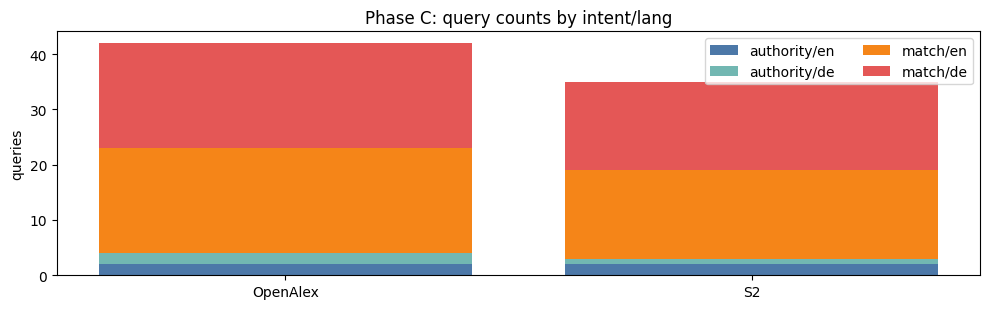

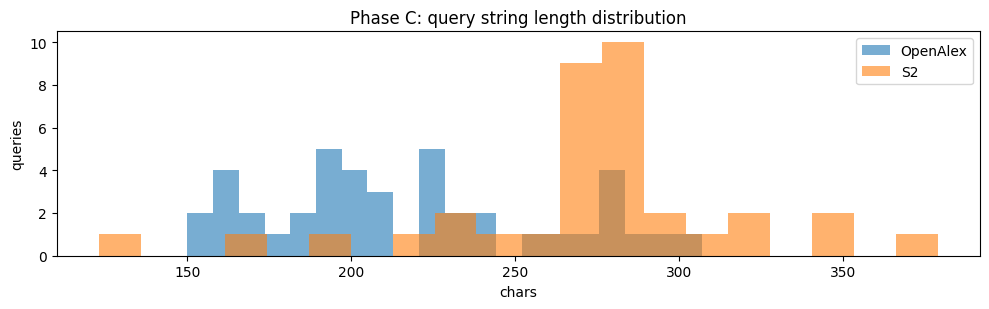

In [11]:
# Phase C.4 — Run query builders + inspect outputs

openalex_queries, openalex_meta = build_openalex_queries_llm(
    plan,
    chapter_title=chapter_title,
    chapter_spec_text=chapter_spec_text,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_PROVIDER_QUERIES,
)

s2_bulk_queries, s2_meta = build_s2_bulk_queries_llm(
    plan,
    chapter_title=chapter_title,
    chapter_spec_text=chapter_spec_text,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_PROVIDER_QUERIES,
)


def _summarize(queries: List[Any]) -> List[Dict[str, Any]]:
    counts: Dict[Tuple[str, str], int] = {}
    for q in queries:
        key = (getattr(q, "intent", ""), getattr(q, "language", ""))
        counts[key] = counts.get(key, 0) + 1

    rows = []
    for (intent, lang), n in sorted(counts.items(), key=lambda x: (x[0][0], x[0][1])):
        rows.append({"intent": intent, "lang": lang, "count": n})
    return rows


# -----------------------------
# Reporting
# -----------------------------

# Ensure we have the plan available for anchor checks
try:
    _plan_for_c = plan  # type: ignore
except Exception:
    try:
        _plan_for_c = QueryPlan(**read_json(run_ctx.artifacts.query_plan_json))
    except Exception:
        _plan_for_c = None

anchors_by_lang = {
    'en': list(getattr(getattr(_plan_for_c, 'primary_context_anchors', None), 'en', []) or []) if _plan_for_c else [],
    'de': list(getattr(getattr(_plan_for_c, 'primary_context_anchors', None), 'de', []) or []) if _plan_for_c else [],
}


def _anchor_hit(q) -> bool:
    qs = str(getattr(q, 'query_string', '') or '')
    lang = str(getattr(q, 'language', '') or '')
    anchors = anchors_by_lang.get(lang, [])
    return any_term_in_text(qs, anchors)


def _dup_stats(items):
    from collections import Counter

    keys = []
    for q in items:
        keys.append((getattr(q, 'intent', ''), getattr(q, 'language', ''), str(getattr(q, 'query_string', '') or '').strip()))
    c = Counter(keys)
    extra = sum(v - 1 for v in c.values() if v > 1)
    ratio = float(extra) / float(max(1, len(items)))

    dups = []
    for (intent, lang, qs), v in sorted(c.items(), key=lambda kv: (-kv[1], kv[0][0], kv[0][1])):
        if v > 1:
            dups.append({'intent': intent, 'lang': lang, 'dup_count': v, 'query_string': _truncate(qs, 220)})
    return ratio, dups


def _intent_lang_sets(items):
    intents = sorted({str(getattr(q, 'intent', '') or '') for q in items})
    langs = sorted({str(getattr(q, 'language', '') or '') for q in items})
    return intents, langs


def _anchor_coverage(items):
    total = len(items)
    hits = sum(1 for q in items if _anchor_hit(q))
    return hits, total


def _validate_forbidden_openalex(items):
    bad = []
    for i, q in enumerate(items, start=1):
        qs = str(getattr(q, 'query_string', '') or '')
        if any(ch in qs for ch in ('*', '?', '~')):
            bad.append({'i': i, 'intent': q.intent, 'lang': q.language, 'bad_chars': ''.join(sorted({ch for ch in '*?~' if ch in qs})), 'query': _truncate(qs, 220)})
    return bad


n_oa = len(openalex_queries)
n_s2 = len(s2_bulk_queries)

oa_dup_ratio, oa_dups = _dup_stats(openalex_queries)
s2_dup_ratio, s2_dups = _dup_stats(s2_bulk_queries)

oa_intents, oa_langs = _intent_lang_sets(openalex_queries)
s2_intents, s2_langs = _intent_lang_sets(s2_bulk_queries)

oa_anchor_hits, oa_anchor_total = _anchor_coverage([q for q in openalex_queries if q.intent == 'match'])
s2_anchor_hits, s2_anchor_total = _anchor_coverage([q for q in s2_bulk_queries if q.intent == 'match'])

oa_forbidden = _validate_forbidden_openalex(openalex_queries)

qc = []
qc.append(qc_row('openalex_query_count', 'OK' if n_oa <= cfg.max_queries_per_provider else 'FAIL', str(n_oa), f"<= {cfg.max_queries_per_provider}", 'budget hard cap', 'reduce facets / tighten query builder'))
qc.append(qc_row('s2_query_count', 'OK' if n_s2 <= cfg.max_queries_per_provider else 'FAIL', str(n_s2), f"<= {cfg.max_queries_per_provider}", 'budget hard cap', 'reduce facets / tighten query builder'))

qc.append(qc_row('openalex_languages', 'OK' if set(oa_langs) >= {'en','de'} else 'FAIL', ','.join(oa_langs), 'en,de', 'bilingual search requirement', 'fix query builder to emit both languages'))
qc.append(qc_row('s2_languages', 'OK' if set(s2_langs) >= {'en','de'} else 'FAIL', ','.join(s2_langs), 'en,de', 'bilingual search requirement', 'fix query builder to emit both languages'))
qc.append(qc_row('openalex_intents', 'OK' if set(oa_intents) >= {'authority','match'} else 'FAIL', ','.join(oa_intents), 'authority,match', 'two-lane requirement', 'fix query builder to emit both intents'))
qc.append(qc_row('s2_intents', 'OK' if set(s2_intents) >= {'authority','match'} else 'FAIL', ','.join(s2_intents), 'authority,match', 'two-lane requirement', 'fix query builder to emit both intents'))

qc.append(
    qc_row(
        'openalex_duplicate_ratio',
        'FAIL' if oa_dup_ratio >= QUERY_DUP_FAIL else ('WARN' if oa_dup_ratio >= QUERY_DUP_WARN else 'OK'),
        f"{oa_dup_ratio*100:.1f}%",
        f"< {QUERY_DUP_WARN*100:.0f}%",
        'duplicate queries waste budget and reduce diversity',
        'dedup query builder outputs by (intent, lang, query_string)',
    )
)
qc.append(
    qc_row(
        's2_duplicate_ratio',
        'FAIL' if s2_dup_ratio >= QUERY_DUP_FAIL else ('WARN' if s2_dup_ratio >= QUERY_DUP_WARN else 'OK'),
        f"{s2_dup_ratio*100:.1f}%",
        f"< {QUERY_DUP_WARN*100:.0f}%",
        'duplicate queries waste budget and reduce diversity',
        'dedup query builder outputs by (intent, lang, query_string)',
    )
)

qc.append(
    qc_row(
        'openalex_match_anchor_coverage',
        'FAIL' if (oa_anchor_total and (oa_anchor_hits / oa_anchor_total) < TOPK_ANCHOR_FAIL) else ('WARN' if (oa_anchor_total and (oa_anchor_hits / oa_anchor_total) < 0.90) else 'OK'),
        f"{oa_anchor_hits}/{oa_anchor_total} ({fmt_pct(oa_anchor_hits, oa_anchor_total)})",
        '>= 90%',
        'match queries without anchors often go off-topic',
        'ensure query builder injects anchors into match queries',
    )
)
qc.append(
    qc_row(
        's2_match_anchor_coverage',
        'FAIL' if (s2_anchor_total and (s2_anchor_hits / s2_anchor_total) < TOPK_ANCHOR_FAIL) else ('WARN' if (s2_anchor_total and (s2_anchor_hits / s2_anchor_total) < 0.90) else 'OK'),
        f"{s2_anchor_hits}/{s2_anchor_total} ({fmt_pct(s2_anchor_hits, s2_anchor_total)})",
        '>= 90%',
        'match queries without anchors often go off-topic',
        'ensure query builder injects anchors into match queries',
    )
)

qc.append(
    qc_row(
        'openalex_forbidden_chars',
        'FAIL' if oa_forbidden else 'OK',
        _fmt_int(len(oa_forbidden)),
        '0',
        'OpenAlex forbids * ? ~ in boolean search',
        'fix query builder/validator to strip forbidden ops',
    )
)

section_at_a_glance(
    'Phase C',
    {
        'openalex_queries.json': run_ctx.artifacts.openalex_queries_json,
        'semanticscholar_queries.json': run_ctx.artifacts.semanticscholar_queries_json,
        'openalex_count': n_oa,
        's2_count': n_s2,
        'openalex_cache_hit': openalex_meta.get('cache_hit'),
        's2_cache_hit': s2_meta.get('cache_hit'),
        'budget/provider': cfg.max_queries_per_provider,
    },
    qc,
    {'openalex_queries.json': run_ctx.artifacts.openalex_queries_json, 'semanticscholar_queries.json': run_ctx.artifacts.semanticscholar_queries_json},
)

print_section('OpenAI Usage / Cost (OpenAlex builder)')
if openalex_meta.get('cache_hit'):
    print('cache hit — no new tokens billed')
else:
    u = openalex_meta.get('usage') or {}
    c = openalex_meta.get('cost_estimate') or {}
    print_kv({'model': openalex_meta.get('model_used'), 'input_tokens': _fmt_int(u.get('input_tokens') or 0), 'output_tokens': _fmt_int(u.get('output_tokens') or 0), 'cost_usd': f"{float(c.get('total_cost_usd') or 0.0):.6f}"}, key_width=16)

print_section('OpenAI Usage / Cost (S2 builder)')
if s2_meta.get('cache_hit'):
    print('cache hit — no new tokens billed')
else:
    u = s2_meta.get('usage') or {}
    c = s2_meta.get('cost_estimate') or {}
    print_kv({'model': s2_meta.get('model_used'), 'input_tokens': _fmt_int(u.get('input_tokens') or 0), 'output_tokens': _fmt_int(u.get('output_tokens') or 0), 'cost_usd': f"{float(c.get('total_cost_usd') or 0.0):.6f}"}, key_width=16)

print_section('OpenAlex query distribution')
print_table(_summarize(openalex_queries), columns=['intent','lang','count'], max_rows=20, max_col_width=40)

print_section('S2 query distribution')
print_table(_summarize(s2_bulk_queries), columns=['intent','lang','count'], max_rows=20, max_col_width=40)

# Diagnostics tables
print_section('Phase C — Duplicate queries')
rows_dup = []
for provider, dups in [('openalex', oa_dups), ('s2', s2_dups)]:
    for r in sorted(dups, key=lambda x: (-int(x.get('dup_count') or 0), x.get('intent'), x.get('lang'))):
        rows_dup.append({'provider': provider, 'intent': r['intent'], 'lang': r['lang'], 'dup_count': r['dup_count'], 'query_string': r['query_string']})
if not rows_dup:
    print('<none>')
else:
    print_table(rows_dup, columns=['provider','intent','lang','dup_count','query_string'], max_rows=80, max_col_width=220)

print_section('Phase C — Longest queries')
rows_long = []
for provider, qs in [('openalex', openalex_queries), ('s2', s2_bulk_queries)]:
    for i, q in enumerate(qs, start=1):
        s = str(getattr(q, 'query_string', '') or '')
        rows_long.append({'provider': provider, 'i': i, 'len_chars': len(s), 'intent': q.intent, 'lang': q.language, 'query': _truncate(s, 220)})
rows_long.sort(key=lambda r: (-int(r.get('len_chars') or 0), r.get('provider'), int(r.get('i') or 0)))
print_table(rows_long[:TOP_N_QUERIES], columns=['provider','i','len_chars','intent','lang','query'], max_rows=TOP_N_QUERIES, max_col_width=220)

print_section('Phase C — Anchor coverage (match queries)')
rows_anchor = []
for provider, qs in [('openalex', openalex_queries), ('s2', s2_bulk_queries)]:
    for lang in ['en','de']:
        sub = [q for q in qs if q.intent == 'match' and q.language == lang]
        if not sub:
            continue
        hits = sum(1 for q in sub if _anchor_hit(q))
        rows_anchor.append({'provider': provider, 'lang': lang, 'hit': hits, 'total': len(sub), 'pct': fmt_pct(hits, len(sub))})
print_table(rows_anchor, columns=['provider','lang','hit','total','pct'], max_rows=20, max_col_width=40)

# Previews (bounded)
print_section('OpenAlex queries (preview)')
rows_oa_prev = []
for i, q in enumerate(openalex_queries, start=1):
    rows_oa_prev.append({'i': i, 'intent': q.intent, 'lang': q.language, 'search_field': q.search_field, 'sort': q.sort, 'filters': _truncate(q.filters, 90), 'query_string': _truncate(q.query_string, 220)})
print_kv({'total': _fmt_int(len(rows_oa_prev)), 'shown': _fmt_int(min(TOP_N_PREVIEW, len(rows_oa_prev)))}, key_width=10)
print_table(rows_oa_prev[:TOP_N_PREVIEW], columns=['i','intent','lang','search_field','sort','filters','query_string'], max_rows=TOP_N_PREVIEW, max_col_width=220)

print_section('S2 queries (preview)')
rows_s2_prev = []
for i, q in enumerate(s2_bulk_queries, start=1):
    rows_s2_prev.append({'i': i, 'intent': q.intent, 'lang': q.language, 'query_string': _truncate(q.query_string, 240), 'notes': _truncate(q.notes, 90)})
print_kv({'total': _fmt_int(len(rows_s2_prev)), 'shown': _fmt_int(min(TOP_N_PREVIEW, len(rows_s2_prev)))}, key_width=10)
print_table(rows_s2_prev[:TOP_N_PREVIEW], columns=['i','intent','lang','query_string','notes'], max_rows=TOP_N_PREVIEW, max_col_width=240)

# Plots
try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception:
    plt = None

if plt is not None:
    try:
        # Plot 1: stacked bars for query counts by (intent, lang)
        cats = [('authority','en'),('authority','de'),('match','en'),('match','de')]
        providers = ['OpenAlex','S2']
        data = []
        for qs in [openalex_queries, s2_bulk_queries]:
            counts = {(qintent, qlang): 0 for (qintent, qlang) in cats}
            for q in qs:
                counts[(q.intent, q.language)] = counts.get((q.intent, q.language), 0) + 1
            data.append([counts.get(c, 0) for c in cats])

        bottom = [0, 0]
        colors = ['#4c78a8','#72b7b2','#f58518','#e45756']
        labels = [f"{i}/{l}" for i,l in cats]
        plt.figure(figsize=(10, 3.2))
        for j, lab in enumerate(labels):
            vals = [data[0][j], data[1][j]]
            plt.bar(providers, vals, bottom=bottom, label=lab, color=colors[j % len(colors)])
            bottom = [bottom[0] + vals[0], bottom[1] + vals[1]]
        plt.title('Phase C: query counts by intent/lang')
        plt.ylabel('queries')
        plt.legend(loc='upper right', ncols=2)
        plt.tight_layout()
        plt.show()

        # Plot 2: histogram of query lengths per provider
        oa_lens = [len(str(q.query_string or '')) for q in openalex_queries]
        s2_lens = [len(str(q.query_string or '')) for q in s2_bulk_queries]
        plt.figure(figsize=(10, 3.2))
        plt.hist(oa_lens, bins=20, alpha=0.6, label='OpenAlex')
        plt.hist(s2_lens, bins=20, alpha=0.6, label='S2')
        plt.title('Phase C: query string length distribution')
        plt.xlabel('chars')
        plt.ylabel('queries')
        plt.legend()
        plt.tight_layout()
        plt.show()
    except Exception:
        pass


---
# Phase D — Retrieval orchestrator (initial retrieval)
---

Phase D — Retrieval
run_id             4af2666be828e5054ccf4d31
force_rebuild      False
openalex_queries   42
s2_queries         35
Phase D — At a glance
run_id                   4af2666be828e5054ccf4d31
force_rebuild            False
openalex_queries         42
s2_queries               35
openalex_records         46,537
s2_records               41,392
Phase D — QC
QC: OK=5 WARN=1 FAIL=2
status | check                           | value         | expected        | why                                                                      | fix                                                                 
-------+---------------------------------+---------------+-----------------+--------------------------------------------------------------------------+---------------------------------------------------------------------
FAIL   | openalex:dominance_rate         | 72.4%         | < 30%           | one broad query dominating results often causes off-topic pollution      | tighten broad 

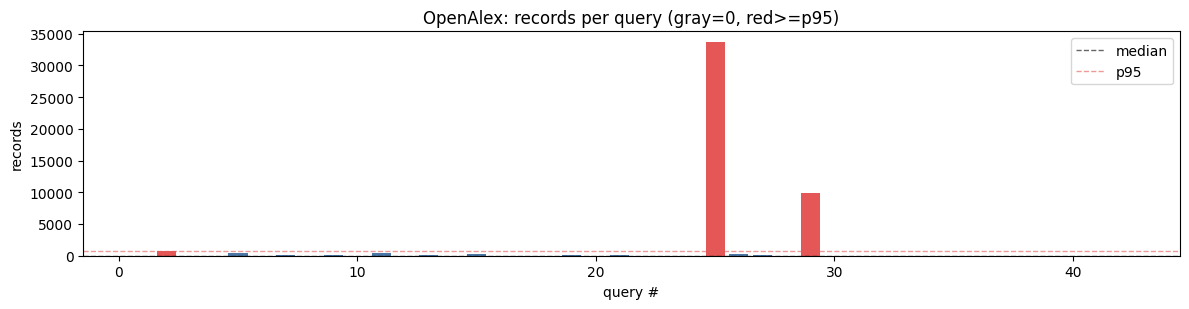

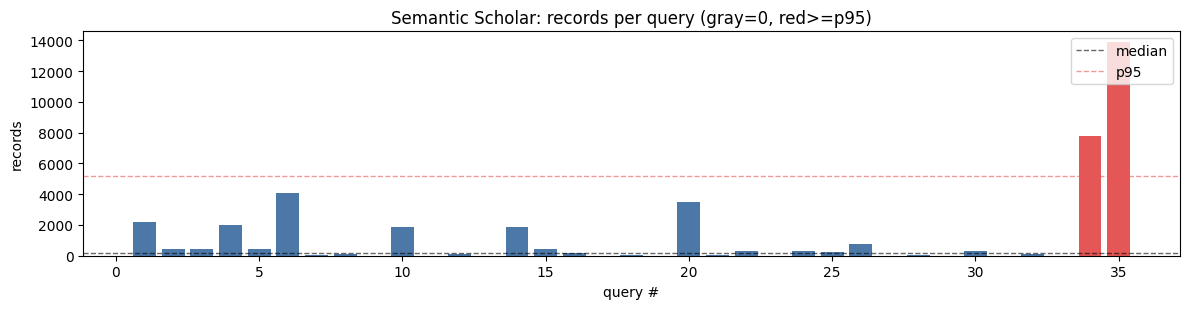

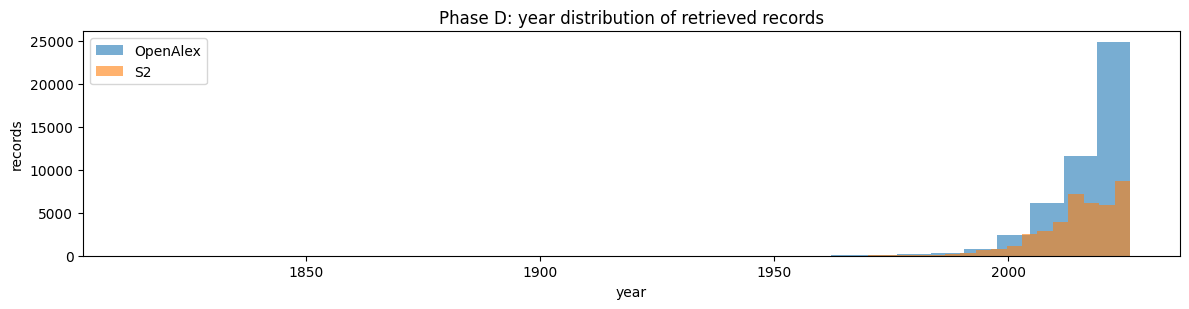

Phase D — Sample records (sanity check)
OpenAlex — Sample works
kind      | intent    | lang | cites | year | rank | anchor_hit | abstract_len | title                                                                                             | author               | source                           | link                                      | query_i | query                                                                                                          | abstract_snip                                                                                                                                                   
----------+-----------+------+-------+------+------+------------+--------------+---------------------------------------------------------------------------------------------------+----------------------+----------------------------------+-------------------------------------------+---------+-----------------------------------------------------------------------------

In [12]:
# Phase D — Retrieval orchestrator (initial retrieval)
#
# Implements:
# - OpenAlex /works cursor pagination (per-page=200)
# - Semantic Scholar /paper/search/bulk token pagination + /paper/batch hydration (<=500 ids)
# - Per-provider throttling, retries/backoff (429/5xx), structured request logging
# - Caching raw outputs under runs/<run_id>/cache/<provider>/<query_hash>.jsonl

import json
import time
import random
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional
from urllib.parse import urlparse

import requests


def _chunked(xs: List[str], n: int) -> Iterable[List[str]]:
    for i in range(0, len(xs), n):
        yield xs[i : i + n]


def _trim_cache_dir(run_ctx: RunContext) -> Path:
    p = run_ctx.run_dir / "cache"
    ensure_dir(p)
    return p


class RateLimiter:
    def __init__(self, rps: float):
        self.rps = float(rps or 0.0)
        self.min_interval = (1.0 / self.rps) if self.rps > 0 else 0.0
        self._next_ts = 0.0

    def acquire(self) -> None:
        if self.min_interval <= 0:
            return
        now = time.monotonic()
        if now < self._next_ts:
            time.sleep(self._next_ts - now)
        now2 = time.monotonic()
        self._next_ts = max(self._next_ts, now2) + self.min_interval


def _truncate_for_log(x: Any, max_str_len: int = 400) -> Any:
    if isinstance(x, str):
        return _truncate(x, max_str_len)
    if isinstance(x, dict):
        return {k: _truncate_for_log(v, max_str_len=max_str_len) for k, v in x.items()}
    if isinstance(x, list):
        # keep logs bounded
        return [_truncate_for_log(v, max_str_len=max_str_len) for v in x[:50]]
    return x


def _parse_retry_after(resp: requests.Response) -> Optional[float]:
    try:
        ra = (resp.headers or {}).get("Retry-After")
        if not ra:
            return None
        return float(ra)
    except Exception:
        return None


def request_json(
    *,
    run_ctx: RunContext,
    stage: str,
    provider: str,
    session: requests.Session,
    method: str,
    url: str,
    params: Optional[Dict[str, Any]],
    body: Optional[Dict[str, Any]],
    timeout_s: float,
    rate_limiter: Optional[RateLimiter],
    max_attempts: int = 8,
    backoff_initial_s: float = 1.0,
    backoff_max_s: float = 60.0,
) -> Any:
    method_u = method.upper()
    params_fp = dict(params or {})
    if "api_key" in params_fp:
        params_fp["api_key"] = "<redacted>"
    pjson = json.dumps(params_fp, ensure_ascii=False, sort_keys=True)
    bjson = json.dumps(body or {}, ensure_ascii=False, sort_keys=True)
    fingerprint = stable_hash(provider, method_u, url, pjson, bjson, length=24)
    endpoint = urlparse(url).path

    last_status: Any = None
    last_err: Optional[str] = None

    for attempt in range(1, max_attempts + 1):
        if rate_limiter is not None:
            rate_limiter.acquire()

        t0 = time.time()
        resp: Optional[requests.Response] = None
        try:
            resp = session.request(method_u, url, params=params, json=body, timeout=timeout_s)
            last_status = int(resp.status_code)
        except Exception as e:
            last_status = "exception"
            last_err = repr(e)
        
        retries = attempt - 1
        log_event(
            run_ctx,
            stage=stage,
            event="http_request",
            provider=provider,
            fingerprint=fingerprint,
            endpoint=endpoint,
            method=method_u,
            status=last_status,
            retries=retries,
            cache_hit=False,
            params=_truncate_for_log(params_fp),
            elapsed_s=round(time.time() - t0, 3),
        )

        retry_after_s: Optional[float] = None
        retryable = False
        if resp is None:
            retryable = True
        elif resp.status_code in (429, 500, 502, 503, 504):
            retryable = True
            retry_after_s = _parse_retry_after(resp)
        elif resp.status_code >= 400:
            raise RuntimeError(f"{provider} HTTP {resp.status_code} | URL: {resp.url} | Body: {resp.text[:600]}")

        if not retryable:
            try:
                return resp.json() if resp is not None else None
            except Exception as e:
                last_err = f"json_error: {e!r}"
                if attempt >= max_attempts:
                    raise RuntimeError(f"{provider} JSON decode error | URL: {url} | err={last_err}")
                retryable = True

        if attempt >= max_attempts:
            detail = f"last_status={last_status}"
            if last_err:
                detail += f" last_err={last_err}"
            raise RuntimeError(f"{provider} retry budget exhausted: {method_u} {url} ({detail})")

        wait = min(backoff_max_s, backoff_initial_s * (2 ** max(0, retries)))
        if retry_after_s is not None:
            wait = max(wait, float(retry_after_s))
        # jitter (avoid thundering herd)
        wait = wait * (1.0 + random.uniform(-0.15, 0.15))
        wait = max(0.5, float(wait))
        time.sleep(wait)


def _query_hash(provider: str, q: BaseModel) -> str:
    payload = json.dumps(q.model_dump(mode="json"), ensure_ascii=False, sort_keys=True)
    return stable_hash(provider, payload, length=24)


def count_jsonl_records(paths: List[Path]) -> int:
    total = 0
    seen: set[str] = set()
    for p in paths:
        sp = str(p)
        if sp in seen:
            continue
        seen.add(sp)
        try:
            with p.open("r", encoding="utf-8") as f:
                for line in f:
                    if line.strip():
                        total += 1
        except Exception:
            continue
    return total


OPENALEX_SELECT = (
    "id,doi,display_name,publication_year,type,ids,cited_by_count,"
    "primary_location,authorships,abstract_inverted_index"
)


def _openalex_params(cfg: PipelineConfig, q: OpenAlexQuery, *, cursor: str) -> Dict[str, Any]:
    params: Dict[str, Any] = {
        "per-page": int(getattr(q, "per_page", 200) or 200),
        "cursor": cursor,
        "select": OPENALEX_SELECT,
    }
    if getattr(q, "sort", None):
        params["sort"] = q.sort
    if cfg.openalex_email:
        params["mailto"] = cfg.openalex_email
    if cfg.openalex_api_key:
        params["api_key"] = cfg.openalex_api_key

    base_filters = str(getattr(q, "filters", "") or "").strip().strip(",")
    if q.search_field == "default.search":
        params["search"] = q.query_string
        if base_filters:
            params["filter"] = base_filters
        return params

    # OpenAlex field-specific search via filter key (e.g. title_and_abstract.search:...)
    search_filter = f"{q.search_field}:{q.query_string}"
    params["filter"] = f"{base_filters},{search_filter}" if base_filters else search_filter
    return params


def fetch_openalex_to_cache(
    *,
    cfg: PipelineConfig,
    run_ctx: RunContext,
    queries: List[OpenAlexQuery],
    force_rebuild: bool,
) -> Dict[str, Any]:
    stage = "phase_d_openalex_retrieval"
    base_url = cfg.openalex_base_url.rstrip("/") + "/works"
    cache_root = _trim_cache_dir(run_ctx) / "openalex"
    ensure_dir(cache_root)

    limiter = RateLimiter(cfg.openalex_rps)
    session = requests.Session()
    session.headers.update({"User-Agent": "instantpaper-two-lane/1.0"})

    cache_hits = 0
    cache_writes = 0
    query_failed = 0
    records_fetched = 0
    used_cache_paths: List[Path] = []

    for qi, q in enumerate(queries, start=1):
        qh = _query_hash("openalex", q)
        cache_path = cache_root / f"{qh}.jsonl"

        if cache_path.exists() and not force_rebuild:
            cache_hits += 1
            used_cache_paths.append(cache_path)
            log_event(
                run_ctx,
                stage=stage,
                event="cache_hit",
                provider="openalex",
                query_hash=qh,
                query_i=qi,
                path=str(cache_path),
                intent=q.intent,
                language=q.language,
            )
            continue

        tmp = cache_path.with_suffix(cache_path.suffix + ".tmp")
        if tmp.exists():
            try:
                tmp.unlink()
            except Exception:
                pass

        ensure_dir(tmp.parent)
        tmp.touch(exist_ok=True)

        pages = 0
        cursor = "*"
        rank = 0

        try:
            while cursor:
                params = _openalex_params(cfg, q, cursor=cursor)
                data = request_json(
                    run_ctx=run_ctx,
                    stage=stage,
                    provider="openalex",
                    session=session,
                    method="GET",
                    url=base_url,
                    params=params,
                    body=None,
                    timeout_s=float(cfg.openalex_timeout_s),
                    rate_limiter=limiter,
                    max_attempts=8,
                    backoff_initial_s=1.0,
                    backoff_max_s=60.0,
                )
                pages += 1

                results = (data or {}).get("results") or []
                for w in results:
                    rank += 1
                    append_jsonl(
                        tmp,
                        {
                            "run_id": run_ctx.run_id,
                            "provider": "openalex",
                            "query_hash": qh,
                            "query_i": qi,
                            "intent": q.intent,
                            "language": q.language,
                            "rank": rank,
                            "work": w,
                        },
                    )

                cursor = ((data or {}).get("meta") or {}).get("next_cursor")
                if not cursor:
                    break

            tmp.replace(cache_path)
            cache_writes += 1
            used_cache_paths.append(cache_path)
            records_fetched += rank
            log_event(
                run_ctx,
                stage=stage,
                event="cache_write",
                provider="openalex",
                query_hash=qh,
                query_i=qi,
                path=str(cache_path),
                pages=pages,
                records=rank,
                intent=q.intent,
                language=q.language,
            )
        except Exception as e:
            query_failed += 1
            log_event(
                run_ctx,
                stage=stage,
                event="query_failed",
                provider="openalex",
                query_hash=qh,
                query_i=qi,
                intent=q.intent,
                language=q.language,
                error=repr(e),
            )
            # Keep existing cache_path if it exists (FORCE rebuild fallback).
            if cache_path.exists():
                used_cache_paths.append(cache_path)
            # preserve tmp for debugging
            if tmp.exists():
                failed = cache_path.with_suffix(cache_path.suffix + f".failed.{utc_now_iso().replace(':','_')}")
                try:
                    tmp.replace(failed)
                except Exception:
                    pass

    return {
        "cache_root": cache_root,
        "cache_hits": cache_hits,
        "cache_writes": cache_writes,
        "query_failed": query_failed,
        "records": count_jsonl_records(used_cache_paths),
        "records_fetched": records_fetched,
        "used_cache_paths": used_cache_paths,
    }


S2_BULK_FIELDS = "paperId"
S2_BATCH_FIELDS = "paperId,title,year,authors,venue,url,externalIds,citationCount,influentialCitationCount,abstract"


def _s2_iter_batch_items(batch: Any) -> List[Dict[str, Any]]:
    if isinstance(batch, list):
        return [b for b in batch if isinstance(b, dict)]
    if isinstance(batch, dict):
        it = batch.get("data", []) or []
        return [b for b in it if isinstance(b, dict)]
    return []


def fetch_s2_to_cache(
    *,
    cfg: PipelineConfig,
    run_ctx: RunContext,
    queries: List[S2BulkQuery],
    force_rebuild: bool,
    bulk_limit: int = 100,
) -> Dict[str, Any]:
    stage = "phase_d_semanticscholar_retrieval"
    base = cfg.semanticscholar_base_url.rstrip("/")
    bulk_url = base + "/paper/search/bulk"
    batch_url = base + "/paper/batch"

    cache_root = _trim_cache_dir(run_ctx) / "semanticscholar"
    ensure_dir(cache_root)

    limiter = RateLimiter(cfg.semanticscholar_rps)
    session = requests.Session()
    session.headers.update({"User-Agent": "instantpaper-two-lane/1.0"})
    if cfg.semanticscholar_api_key:
        session.headers.update({"x-api-key": cfg.semanticscholar_api_key})

    cache_hits = 0
    cache_writes = 0
    query_failed = 0
    records_fetched = 0
    used_cache_paths: List[Path] = []

    for qi, q in enumerate(queries, start=1):
        qh = _query_hash("semanticscholar", q)
        cache_path = cache_root / f"{qh}.jsonl"

        if cache_path.exists() and not force_rebuild:
            cache_hits += 1
            used_cache_paths.append(cache_path)
            log_event(
                run_ctx,
                stage=stage,
                event="cache_hit",
                provider="semanticscholar",
                query_hash=qh,
                query_i=qi,
                path=str(cache_path),
                intent=q.intent,
                language=q.language,
            )
            continue

        tmp = cache_path.with_suffix(cache_path.suffix + ".tmp")
        if tmp.exists():
            try:
                tmp.unlink()
            except Exception:
                pass

        ensure_dir(tmp.parent)
        tmp.touch(exist_ok=True)

        token: Optional[str] = None
        rank = 0
        written = 0

        try:
            while True:
                params: Dict[str, Any] = {"query": q.query_string, "fields": S2_BULK_FIELDS, "limit": int(bulk_limit)}
                if token:
                    params["token"] = token

                page = request_json(
                    run_ctx=run_ctx,
                    stage=stage,
                    provider="semanticscholar",
                    session=session,
                    method="GET",
                    url=bulk_url,
                    params=params,
                    body=None,
                    timeout_s=float(cfg.semanticscholar_timeout_s),
                    rate_limiter=limiter,
                    max_attempts=10,
                    backoff_initial_s=2.0,
                    backoff_max_s=120.0,
                )

                items = (page or {}).get("data") or []
                ids: List[str] = []
                ranks: Dict[str, int] = {}
                for it in items:
                    if not isinstance(it, dict):
                        continue
                    pid = it.get("paperId")
                    if not pid:
                        continue
                    pid_s = str(pid)
                    rank += 1
                    ids.append(pid_s)
                    ranks[pid_s] = rank

                if ids:
                    for chunk in _chunked(ids, 500):
                        batch = request_json(
                            run_ctx=run_ctx,
                            stage=stage,
                            provider="semanticscholar",
                            session=session,
                            method="POST",
                            url=batch_url,
                            params={"fields": S2_BATCH_FIELDS},
                            body={"ids": chunk},
                            timeout_s=float(cfg.semanticscholar_timeout_s),
                            rate_limiter=limiter,
                            max_attempts=10,
                            backoff_initial_s=2.0,
                            backoff_max_s=120.0,
                        )
                        for paper in _s2_iter_batch_items(batch):
                            pid = paper.get("paperId")
                            if not pid:
                                continue
                            pid_s = str(pid)
                            append_jsonl(
                                tmp,
                                {
                                    "run_id": run_ctx.run_id,
                                    "provider": "semanticscholar",
                                    "query_hash": qh,
                                    "query_i": qi,
                                    "intent": q.intent,
                                    "language": q.language,
                                    "rank": int(ranks.get(pid_s) or 0),
                                    "paper": paper,
                                },
                            )
                            written += 1

                token = (page or {}).get("token") or (page or {}).get("next")
                if not token:
                    break

            tmp.replace(cache_path)
            cache_writes += 1
            used_cache_paths.append(cache_path)
            records_fetched += written
            log_event(
                run_ctx,
                stage=stage,
                event="cache_write",
                provider="semanticscholar",
                query_hash=qh,
                query_i=qi,
                path=str(cache_path),
                ids_seen=rank,
                records=written,
                intent=q.intent,
                language=q.language,
            )
        except Exception as e:
            query_failed += 1
            log_event(
                run_ctx,
                stage=stage,
                event="query_failed",
                provider="semanticscholar",
                query_hash=qh,
                query_i=qi,
                intent=q.intent,
                language=q.language,
                error=repr(e),
            )
            if cache_path.exists():
                used_cache_paths.append(cache_path)
            if tmp.exists():
                failed = cache_path.with_suffix(cache_path.suffix + f".failed.{utc_now_iso().replace(':','_')}")
                try:
                    tmp.replace(failed)
                except Exception:
                    pass

    return {
        "cache_root": cache_root,
        "cache_hits": cache_hits,
        "cache_writes": cache_writes,
        "query_failed": query_failed,
        "records": count_jsonl_records(used_cache_paths),
        "records_fetched": records_fetched,
        "used_cache_paths": used_cache_paths,
    }


def rebuild_aggregate_jsonl(dest: Path, sources: List[Path]) -> None:
    ensure_dir(dest.parent)
    tmp = dest.with_suffix(dest.suffix + ".tmp")
    if tmp.exists():
        try:
            tmp.unlink()
        except Exception:
            pass

    with tmp.open("w", encoding="utf-8") as out:
        for src in sources:
            if not src.exists():
                continue
            with src.open("r", encoding="utf-8") as f:
                for line in f:
                    if line.strip():
                        out.write(line)

    tmp.replace(dest)


print_section("Phase D — Retrieval")
print_kv(
    {
        "run_id": run_ctx.run_id,
        "force_rebuild": FORCE_REBUILD_RETRIEVAL,
        "openalex_queries": len(openalex_queries),
        "s2_queries": len(s2_bulk_queries),
    },
    key_width=18,
)

# Pre-compute expected cache paths so we can report cache hits/writes cleanly.
oa_cache_root = _trim_cache_dir(run_ctx) / "openalex"
s2_cache_root = _trim_cache_dir(run_ctx) / "semanticscholar"
expected_oa_paths = [oa_cache_root / f"{_query_hash('openalex', q)}.jsonl" for q in openalex_queries]
expected_s2_paths = [s2_cache_root / f"{_query_hash('semanticscholar', q)}.jsonl" for q in s2_bulk_queries]
pre_existing_oa = {str(p) for p in expected_oa_paths if p.exists()}
pre_existing_s2 = {str(p) for p in expected_s2_paths if p.exists()}

with stage_timer(run_ctx, "phase_d_retrieval"):
    oa_stats = fetch_openalex_to_cache(cfg=cfg, run_ctx=run_ctx, queries=openalex_queries, force_rebuild=FORCE_REBUILD_RETRIEVAL)
    s2_stats = fetch_s2_to_cache(cfg=cfg, run_ctx=run_ctx, queries=s2_bulk_queries, force_rebuild=FORCE_REBUILD_RETRIEVAL)

    # Rebuild aggregated raw files from per-query caches in query order.
    rebuild_aggregate_jsonl(run_ctx.artifacts.openalex_raw_jsonl, oa_stats["used_cache_paths"])
    rebuild_aggregate_jsonl(run_ctx.artifacts.semanticscholar_raw_jsonl, s2_stats["used_cache_paths"])

    log_event(
        run_ctx,
        stage="phase_d_retrieval",
        event="aggregate_rebuilt",
        openalex_raw_jsonl=str(run_ctx.artifacts.openalex_raw_jsonl),
        semanticscholar_raw_jsonl=str(run_ctx.artifacts.semanticscholar_raw_jsonl),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault("phase_d_retrieval", {})["openalex"] = {
        "cache_hits": oa_stats.get("cache_hits"),
        "cache_writes": oa_stats.get("cache_writes"),
        "query_failed": oa_stats.get("query_failed"),
        "records": oa_stats.get("records"),
    }
    metrics["stages"]["phase_d_retrieval"]["semanticscholar"] = {
        "cache_hits": s2_stats.get("cache_hits"),
        "cache_writes": s2_stats.get("cache_writes"),
        "query_failed": s2_stats.get("query_failed"),
        "records": s2_stats.get("records"),
    }
    save_metrics(run_ctx, metrics)


def _count_lines(path: Path) -> int:
    if not path.exists():
        return 0
    n = 0
    try:
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    n += 1
    except Exception:
        return 0
    return n


def _status(path: Path, pre_existing: set[str]) -> str:
    if FORCE_REBUILD_RETRIEVAL:
        return "write" if path.exists() else "missing"
    if str(path) in pre_existing:
        return "hit"
    return "write" if path.exists() else "missing"


rows_oa = []
for i, q in enumerate(openalex_queries, start=1):
    qh = _query_hash("openalex", q)
    path = oa_cache_root / f"{qh}.jsonl"
    rows_oa.append(
        {
            "i": i,
            "intent": q.intent,
            "lang": q.language,
            "records": _count_lines(path),
            "status": _status(path, pre_existing_oa),
            "query": _truncate(q.query_string, 110),
        }
    )

rows_s2 = []
for i, q in enumerate(s2_bulk_queries, start=1):
    qh = _query_hash("semanticscholar", q)
    path = s2_cache_root / f"{qh}.jsonl"
    rows_s2.append(
        {
            "i": i,
            "intent": q.intent,
            "lang": q.language,
            "records": _count_lines(path),
            "status": _status(path, pre_existing_s2),
            "query": _truncate(q.query_string, 110),
        }
    )


def _provider_summary(label: str, rows: List[Dict[str, Any]], stats: Dict[str, Any]) -> Dict[str, Any]:
    total = len(rows)
    total_records = sum(int(r.get("records") or 0) for r in rows)
    zeros = sum(1 for r in rows if int(r.get("records") or 0) == 0)
    hits = sum(1 for r in rows if r.get("status") == "hit")
    writes = sum(1 for r in rows if r.get("status") == "write")
    missing = sum(1 for r in rows if r.get("status") == "missing")
    return {
        "provider": label,
        "queries": total,
        "hits": hits,
        "writes": writes,
        "missing": missing,
        "failed": int(stats.get("query_failed") or 0),
        "records": _fmt_int(total_records),
        "zero_q": zeros,
    }


# -----------------------------
# Phase D — Reporting
# -----------------------------

# Ensure we have the plan for anchor checks
try:
    _plan_for_d = plan  # type: ignore
except Exception:
    try:
        _plan_for_d = QueryPlan(**read_json(run_ctx.artifacts.query_plan_json))
    except Exception:
        _plan_for_d = None

anchors_all: List[str] = []
if _plan_for_d is not None:
    try:
        anchors_all = list((_plan_for_d.primary_context_anchors.en or [])) + list((_plan_for_d.primary_context_anchors.de or []))
    except Exception:
        anchors_all = []


def _iter_jsonl(path: Path) -> Iterable[Dict[str, Any]]:
    if not path.exists():
        return
    try:
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json.loads(line)
                except Exception:
                    continue
                if isinstance(obj, dict):
                    yield obj
    except Exception:
        return


def _breakdown(rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    agg: Dict[tuple[str, str], int] = {}
    for r in rows:
        key = (str(r.get('intent') or ''), str(r.get('lang') or ''))
        agg[key] = agg.get(key, 0) + int(r.get('records') or 0)
    out = []
    for (intent, lang), n in sorted(agg.items(), key=lambda x: (-x[1], x[0][0], x[0][1])):
        out.append({'intent': intent, 'lang': lang, 'records': _fmt_int(n)})
    return out


def _provider_metrics(label: str, rows: List[Dict[str, Any]], stats: Dict[str, Any]) -> Dict[str, Any]:
    total = len(rows)
    recs = [int(r.get('records') or 0) for r in rows]
    total_records = sum(recs)
    zeros = sum(1 for x in recs if int(x) == 0)
    max_r = max(recs) if recs else 0
    dominance = (float(max_r) / float(total_records)) if total_records else 0.0

    mean = (float(total_records) / float(total)) if total else 0.0
    med = pctile(recs, 50)
    p90 = pctile(recs, 90)

    de_records = sum(int(r.get('records') or 0) for r in rows if str(r.get('lang') or '') == 'de')
    de_queries = sum(1 for r in rows if str(r.get('lang') or '') == 'de')

    failed = int(stats.get('query_failed') or 0)
    failed_rate = float(failed) / float(max(1, total))
    zero_rate = float(zeros) / float(max(1, total))

    return {
        'provider': label,
        'queries': total,
        'failed': failed,
        'failed_rate': failed_rate,
        'records': total_records,
        'zero_q': zeros,
        'zero_rate': zero_rate,
        'mean': mean,
        'median': med,
        'p90': p90,
        'max': max_r,
        'dominance': dominance,
        'de_records': de_records,
        'de_queries': de_queries,
    }


m_oa = _provider_metrics('openalex', rows_oa, oa_stats)
m_s2 = _provider_metrics('semanticscholar', rows_s2, s2_stats)

# QC checks
qc = []
for m in [m_oa, m_s2]:
    prov = str(m.get('provider') or '')
    total = int(m.get('queries') or 0)
    zeros = int(m.get('zero_q') or 0)
    zero_rate = float(zeros) / float(max(1, total))
    dom = float(m.get('dominance') or 0.0)

    failed = int(m.get('failed') or 0)
    failed_rate = float(failed) / float(max(1, total))

    qc.append(
        qc_row(
            check=f'{prov}:failed_rate',
            status='FAIL' if failed_rate > 0.10 else ('WARN' if failed_rate > 0 else 'OK'),
            value=f"{failed}/{total} ({failed_rate*100:.1f}%)",
            expected='0 (or very low)',
            why='provider errors reduce recall and can bias distributions',
            fix='check API keys/rate limits; rerun with FORCE_REBUILD_RETRIEVAL',
        )
    )

    qc.append(
        qc_row(
            check=f'{prov}:zero_query_rate',
            status='FAIL' if zero_rate >= ZERO_Q_FAIL else ('WARN' if zero_rate >= ZERO_Q_WARN else 'OK'),
            value=f"{zeros}/{total} ({zero_rate*100:.1f}%)",
            expected=f"< {ZERO_Q_WARN*100:.0f}%",
            why='many zero queries suggests anchors/terms too strict or provider mismatch',
            fix='inspect zero queries; relax clauses; adjust anchors/canonical terms',
        )
    )

    qc.append(
        qc_row(
            check=f'{prov}:dominance_rate',
            status='FAIL' if dom >= DOMINANCE_FAIL else ('WARN' if dom >= DOMINANCE_WARN else 'OK'),
            value=f"{dom*100:.1f}%",
            expected=f"< {DOMINANCE_WARN*100:.0f}%",
            why='one broad query dominating results often causes off-topic pollution',
            fix='tighten broad query; add exclusions; add more facet-specific queries',
        )
    )

    de_q = int(m.get('de_queries') or 0)
    de_r = int(m.get('de_records') or 0)
    if de_q > 0:
        qc.append(
            qc_row(
                check=f'{prov}:de_records',
                status='WARN' if de_r == 0 else 'OK',
                value=str(de_r),
                expected='> 0',
                why='German lane requires some DE results if DE queries exist',
                fix='inspect DE queries; consider DE anchors; relax language filters',
            )
        )

section_at_a_glance(
    'Phase D',
    {
        'run_id': run_ctx.run_id,
        'force_rebuild': FORCE_REBUILD_RETRIEVAL,
        'openalex_queries': len(openalex_queries),
        's2_queries': len(s2_bulk_queries),
        'openalex_records': _fmt_int(m_oa.get('records') or 0),
        's2_records': _fmt_int(m_s2.get('records') or 0),
    },
    qc,
    {
        'openalex_raw.jsonl': run_ctx.artifacts.openalex_raw_jsonl,
        'semanticscholar_raw.jsonl': run_ctx.artifacts.semanticscholar_raw_jsonl,
        'logs.jsonl': run_ctx.artifacts.logs_jsonl,
        'metrics.json': run_ctx.artifacts.metrics_json,
    },
)

print_section('Phase D — Provider Summary (with rates)')
print_table(
    [
        {
            'provider': m_oa['provider'],
            'queries': m_oa['queries'],
            'failed': m_oa['failed'],
            'failed_rate': f"{m_oa['failed_rate']*100:.1f}%",
            'records': _fmt_int(m_oa['records']),
            'zero_q': m_oa['zero_q'],
            'zero_rate': f"{m_oa['zero_rate']*100:.1f}%",
            'mean': f"{m_oa['mean']:.1f}",
            'median': f"{m_oa['median']:.1f}",
            'p90': f"{m_oa['p90']:.1f}",
            'max': m_oa['max'],
            'dominance': f"{m_oa['dominance']*100:.1f}%",
        },
        {
            'provider': m_s2['provider'],
            'queries': m_s2['queries'],
            'failed': m_s2['failed'],
            'failed_rate': f"{m_s2['failed_rate']*100:.1f}%",
            'records': _fmt_int(m_s2['records']),
            'zero_q': m_s2['zero_q'],
            'zero_rate': f"{m_s2['zero_rate']*100:.1f}%",
            'mean': f"{m_s2['mean']:.1f}",
            'median': f"{m_s2['median']:.1f}",
            'p90': f"{m_s2['p90']:.1f}",
            'max': m_s2['max'],
            'dominance': f"{m_s2['dominance']*100:.1f}%",
        },
    ],
    columns=['provider','queries','failed','failed_rate','records','zero_q','zero_rate','mean','median','p90','max','dominance'],
    max_rows=10,
    max_col_width=40,
)

print_section('OpenAlex — Records by intent/lang')
print_table(_breakdown(rows_oa), columns=['intent','lang','records'], max_rows=20, max_col_width=40)

print_section('Semantic Scholar — Records by intent/lang')
print_table(_breakdown(rows_s2), columns=['intent','lang','records'], max_rows=20, max_col_width=40)

# Broad / narrow / zero queries

def _with_share(rows: List[Dict[str, Any]], *, total_records: int, provider: str) -> List[Dict[str, Any]]:
    out = []
    for r in rows:
        recs = int(r.get('records') or 0)
        share = (100.0 * float(recs) / float(max(1, total_records))) if total_records else 0.0
        out.append({
            'provider': provider,
            'i': r.get('i'),
            'intent': r.get('intent'),
            'lang': r.get('lang'),
            'records': recs,
            'share': f"{share:.1f}%",
            'status': r.get('status'),
            'query': _truncate(r.get('query') or '', 140),
        })
    return out


oa_total_records = sum(int(r.get('records') or 0) for r in rows_oa)
s2_total_records = sum(int(r.get('records') or 0) for r in rows_s2)

rows_oa_ws = _with_share(rows_oa, total_records=oa_total_records, provider='openalex')
rows_s2_ws = _with_share(rows_s2, total_records=s2_total_records, provider='semanticscholar')

zeros = [r for r in (rows_oa_ws + rows_s2_ws) if int(r.get('records') or 0) == 0]
print_section('Phase D — Zero queries')
if not zeros:
    print('<none>')
else:
    print_table(zeros[:50], columns=['provider','i','intent','lang','records','status','query'], max_rows=80, max_col_width=160)

broad = sorted(rows_oa_ws + rows_s2_ws, key=lambda r: (-int(r.get('records') or 0), r.get('provider'), int(r.get('i') or 0)))
print_section('Phase D — Broad queries (top by records)')
print_table(broad[:10], columns=['provider','i','intent','lang','records','share','status','query'], max_rows=20, max_col_width=160)

narrow = [r for r in (rows_oa_ws + rows_s2_ws) if int(r.get('records') or 0) > 0]
narrow = sorted(narrow, key=lambda r: (int(r.get('records') or 0), r.get('provider'), int(r.get('i') or 0)))
print_section('Phase D — Narrow queries (bottom non-zero)')
print_table(narrow[:10], columns=['provider','i','intent','lang','records','share','status','query'], max_rows=20, max_col_width=160)

# -----------------------------
# Plots (optional)
# -----------------------------
try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception:
    plt = None


def _plot_records(rows: List[Dict[str, Any]], *, title: str) -> None:
    if plt is None:
        return
    if not rows:
        return

    ordered = sorted(rows, key=lambda r: int(r.get('i') or 0))
    xs = [int(r.get('i') or 0) for r in ordered]
    ys = [int(r.get('records') or 0) for r in ordered]

    med = pctile(ys, 50)
    p95 = pctile(ys, 95)

    colors = []
    for y in ys:
        if y == 0:
            colors.append('#9e9e9e')
        elif y >= p95 and p95 > 0:
            colors.append('#e45756')
        else:
            colors.append('#4c78a8')

    plt.figure(figsize=(12, 3.2))
    plt.bar(xs, ys, color=colors)
    if med:
        plt.axhline(med, color='black', linestyle='--', linewidth=1, alpha=0.6, label='median')
    if p95:
        plt.axhline(p95, color='#e45756', linestyle='--', linewidth=1, alpha=0.6, label='p95')
    plt.title(title)
    plt.xlabel('query #')
    plt.ylabel('records')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


_plot_records(rows_oa, title='OpenAlex: records per query (gray=0, red>=p95)')
_plot_records(rows_s2, title='Semantic Scholar: records per query (gray=0, red>=p95)')

# Year histogram (retrieved records)

def _years_from_oa(path: Path) -> List[int]:
    ys = []
    for rec in _iter_jsonl(path):
        w = (rec or {}).get('work') or {}
        y = w.get('publication_year')
        try:
            yy = int(y)
        except Exception:
            continue
        if 0 < yy < 2100:
            ys.append(yy)
    return ys


def _years_from_s2(path: Path) -> List[int]:
    ys = []
    for rec in _iter_jsonl(path):
        p = (rec or {}).get('paper') or {}
        y = p.get('year')
        try:
            yy = int(y)
        except Exception:
            continue
        if 0 < yy < 2100:
            ys.append(yy)
    return ys


if plt is not None:
    try:
        y_oa = _years_from_oa(run_ctx.artifacts.openalex_raw_jsonl)
        y_s2 = _years_from_s2(run_ctx.artifacts.semanticscholar_raw_jsonl)
        if y_oa or y_s2:
            plt.figure(figsize=(12, 3.2))
            if y_oa:
                plt.hist(y_oa, bins=30, alpha=0.6, label='OpenAlex')
            if y_s2:
                plt.hist(y_s2, bins=30, alpha=0.6, label='S2')
            plt.title('Phase D: year distribution of retrieved records')
            plt.xlabel('year')
            plt.ylabel('records')
            plt.legend()
            plt.tight_layout()
            plt.show()
    except Exception:
        pass

# -----------------------------
# Samples (sanity check)
# -----------------------------


def _anchor_hit_text(title: str, abstract: str) -> bool:
    if not anchors_all:
        return False
    return any_term_in_text(f"{title} {abstract}", anchors_all)


def _oa_abstract_full(work: Dict[str, Any], *, max_words: int = 800, max_chars: int = 4000) -> str:
    inv = (work or {}).get('abstract_inverted_index')
    if not isinstance(inv, dict) or not inv:
        return ''

    max_pos = -1
    for positions in inv.values():
        if isinstance(positions, list):
            for p in positions:
                if isinstance(p, int) and p > max_pos:
                    max_pos = p
    if max_pos < 0:
        return ''

    limit = min(max_pos, int(max_words) - 1)
    words: List[str] = [''] * (limit + 1)
    for token, positions in inv.items():
        if not isinstance(token, str) or not isinstance(positions, list):
            continue
        for p in positions:
            if isinstance(p, int) and 0 <= p <= limit:
                words[p] = token

    text = ' '.join(w for w in words if w)
    text = re.sub(r"\s+", " ", text).strip()
    return _truncate(text, max_chars)


print_section('Phase D — Sample records (sanity check)')


def _pick_samples_by_group(
    path: Path,
    *,
    group_fn,
    cite_fn,
    row_fn,
    seed: int,
) -> List[Dict[str, Any]]:
    rng = random.Random(seed if seed is not None else 0)
    counts: Dict[Any, int] = {}
    best: Dict[Any, tuple[int, Dict[str, Any]]] = {}
    sample: Dict[Any, Dict[str, Any]] = {}

    for rec in _iter_jsonl(path):
        g = group_fn(rec)
        counts[g] = counts.get(g, 0) + 1
        cites = int(cite_fn(rec) or 0)

        prev = best.get(g)
        if prev is None or cites > prev[0]:
            best[g] = (cites, rec)

        n = counts[g]
        if g not in sample or rng.random() < (1.0 / float(n)):
            sample[g] = rec

    def _group_sort_key(g):
        # Prefer authority before match, then language
        if isinstance(g, tuple) and len(g) == 2:
            intent, lang = g
        else:
            intent, lang = (g, '')
        intent_s = str(intent or '')
        pri = 2
        if intent_s == 'authority':
            pri = 0
        elif intent_s == 'match':
            pri = 1
        return (pri, intent_s, str(lang or ''))

    rows: List[Dict[str, Any]] = []
    for g in sorted(counts.keys(), key=_group_sort_key):
        if g in best:
            rows.append(row_fn(best[g][1], kind='top_cited'))
        if g in sample:
            rows.append(row_fn(sample[g], kind='random'))
    return rows


oa_query_map = {i: q.query_string for i, q in enumerate(openalex_queries, start=1)}
s2_query_map = {i: q.query_string for i, q in enumerate(s2_bulk_queries, start=1)}


def _oa_sample_row(rec: Dict[str, Any], *, kind: str) -> Dict[str, Any]:
    w = (rec or {}).get('work') or {}
    q_i = int((rec or {}).get('query_i') or 0)
    title = str(w.get('display_name') or '')
    year = w.get('publication_year') or ''
    cites = int(w.get('cited_by_count') or 0)
    doi = w.get('doi') or ''
    if not doi:
        doi = ((w.get('ids') or {}).get('doi') or '')

    pl = w.get('primary_location') or {}
    src = (pl.get('source') or {}).get('display_name') or ''

    first_author = ''
    auths = w.get('authorships') or []
    if isinstance(auths, list) and auths:
        a0 = auths[0] or {}
        first_author = ((a0.get('author') or {}).get('display_name') or '')

    link = doi or (w.get('id') or '')
    abs_full = _oa_abstract_full(w)
    anchor_hit = _anchor_hit_text(title, abs_full)

    return {
        'kind': kind,
        'intent': rec.get('intent') or '',
        'lang': rec.get('language') or '',
        'rank': rec.get('rank') or '',
        'cites': cites,
        'year': year,
        'anchor_hit': 'yes' if anchor_hit else 'no',
        'abstract_len': len(abs_full),
        'title': _truncate(title, 100),
        'author': _truncate(first_author, 30),
        'source': _truncate(src, 32),
        'link': _truncate(link, 60),
        'abstract_snip': _truncate(abs_full, 180),
        'query_i': q_i,
        'query': _truncate(oa_query_map.get(q_i, ''), 110),
    }


def _s2_sample_row(rec: Dict[str, Any], *, kind: str) -> Dict[str, Any]:
    p = (rec or {}).get('paper') or {}
    q_i = int((rec or {}).get('query_i') or 0)
    title = str(p.get('title') or '')
    year = p.get('year') or ''
    cites = int(p.get('citationCount') or 0)
    infl = int(p.get('influentialCitationCount') or 0)
    url = p.get('url') or ''
    venue = p.get('venue') or ''

    first_author = ''
    auths = p.get('authors') or []
    if isinstance(auths, list) and auths:
        a0 = auths[0] or {}
        first_author = (a0.get('name') or '')

    abs_full = str(p.get('abstract') or '')
    anchor_hit = _anchor_hit_text(title, abs_full)

    return {
        'kind': kind,
        'intent': rec.get('intent') or '',
        'lang': rec.get('language') or '',
        'rank': rec.get('rank') or '',
        'cites': cites,
        'infl': infl,
        'year': year,
        'anchor_hit': 'yes' if anchor_hit else 'no',
        'abstract_len': len(abs_full),
        'title': _truncate(title, 100),
        'author': _truncate(first_author, 30),
        'venue': _truncate(venue, 32),
        'url': _truncate(url, 60),
        'abstract_snip': _truncate(abs_full, 180),
        'query_i': q_i,
        'query': _truncate(s2_query_map.get(q_i, ''), 110),
    }


oa_samples = _pick_samples_by_group(
    run_ctx.artifacts.openalex_raw_jsonl,
    group_fn=lambda r: (str(r.get('intent') or ''), str(r.get('language') or '')),
    cite_fn=lambda r: ((r.get('work') or {}).get('cited_by_count') or 0),
    row_fn=_oa_sample_row,
    seed=stable_hash(run_ctx.run_id, 'openalex', length=8),
)
print_section('OpenAlex — Sample works')
print_table(
    oa_samples,
    columns=['kind','intent','lang','cites','year','rank','anchor_hit','abstract_len','title','author','source','link','query_i','query','abstract_snip'],
    max_rows=40,
    max_col_width=160,
)

s2_samples = _pick_samples_by_group(
    run_ctx.artifacts.semanticscholar_raw_jsonl,
    group_fn=lambda r: (str(r.get('intent') or ''), str(r.get('language') or '')),
    cite_fn=lambda r: ((r.get('paper') or {}).get('citationCount') or 0),
    row_fn=_s2_sample_row,
    seed=stable_hash(run_ctx.run_id, 'semanticscholar', length=8),
)
print_section('Semantic Scholar — Sample papers')
print_table(
    s2_samples,
    columns=['kind','intent','lang','cites','infl','year','rank','anchor_hit','abstract_len','title','author','venue','url','query_i','query','abstract_snip'],
    max_rows=40,
    max_col_width=160,
)

def preview_openalex_query(query_i: int, n: int = 5) -> List[Dict[str, Any]]:
    """Print the first N cached OpenAlex works for query #query_i (by provider rank)."""
    query_i = int(query_i)
    if query_i < 1 or query_i > len(openalex_queries):
        raise ValueError(f'query_i out of range: {query_i} (1..{len(openalex_queries)})')
    q = openalex_queries[query_i - 1]
    qh = _query_hash('openalex', q)
    path = (_trim_cache_dir(run_ctx) / 'openalex' / f'{qh}.jsonl')
    rows = []
    for rec in _iter_jsonl(path):
        w = (rec or {}).get('work') or {}
        rows.append({
            'rank': rec.get('rank') or '',
            'cites': int(w.get('cited_by_count') or 0),
            'year': w.get('publication_year') or '',
            'title': _truncate(w.get('display_name') or '', 140),
            'doi': _truncate(w.get('doi') or '', 60),
        })
        if len(rows) >= int(n):
            break
    print_section(f'OpenAlex — Query #{query_i} preview')
    print_kv({'intent': q.intent, 'lang': q.language, 'query': _truncate(q.query_string, 260)}, key_width=10)
    print_table(rows, columns=['rank', 'cites', 'year', 'title', 'doi'], max_rows=int(n), max_col_width=160)
    return rows


def preview_s2_query(query_i: int, n: int = 5) -> List[Dict[str, Any]]:
    """Print the first N cached Semantic Scholar papers for query #query_i (by provider rank)."""
    query_i = int(query_i)
    if query_i < 1 or query_i > len(s2_bulk_queries):
        raise ValueError(f'query_i out of range: {query_i} (1..{len(s2_bulk_queries)})')
    q = s2_bulk_queries[query_i - 1]
    qh = _query_hash('semanticscholar', q)
    path = (_trim_cache_dir(run_ctx) / 'semanticscholar' / f'{qh}.jsonl')
    rows = []
    for rec in _iter_jsonl(path):
        p = (rec or {}).get('paper') or {}
        rows.append({
            'rank': rec.get('rank') or '',
            'cites': int(p.get('citationCount') or 0),
            'infl': int(p.get('influentialCitationCount') or 0),
            'year': p.get('year') or '',
            'title': _truncate(p.get('title') or '', 140),
            'url': _truncate(p.get('url') or '', 60),
        })
        if len(rows) >= int(n):
            break
    print_section(f'Semantic Scholar — Query #{query_i} preview')
    print_kv({'intent': q.intent, 'lang': q.language, 'query': _truncate(q.query_string, 260)}, key_width=10)
    print_table(rows, columns=['rank', 'cites', 'infl', 'year', 'title', 'url'], max_rows=int(n), max_col_width=160)
    return rows


In [19]:
preview_openalex_query(1, n=10)
preview_s2_query(1, n=10)

OpenAlex — Query #1 preview
intent     authority
lang       en
query      ("decision confidence" OR "decision-making confidence" OR "choice certainty") AND (heuristics OR "cognitive biases" OR "dual process theory" OR "digital nudging" OR "choice architecture" OR "perceived risk" OR "online trust")
rank | cites | year | title                                                                                                                | doi                                               
-----+-------+------+----------------------------------------------------------------------------------------------------------------------+---------------------------------------------------
1    | 195   | 2011 | Biased but in Doubt: Conflict and Decision Confidence                                                                | https://doi.org/10.1371/journal.pone.0015954      
2    | 64    | 2020 | The role of decision confidence in advice-taking and trust formation.                                 

[{'rank': 1,
  'cites': 9,
  'infl': 0,
  'year': 2020,
  'title': 'Beyond Discrete Choices – Investigating the Effectiveness of a Proximity Nudge With Multiple Alternative Options',
  'url': 'https://www.semanticscholar.org/paper/000c13c39c70d519aa6d2…'},
 {'rank': 2,
  'cites': 0,
  'infl': 0,
  'year': 2025,
  'title': 'Barriers and Facilitators of Alcohol Use Disorder Treatment for Alcohol-associated Liver Disease: A Systematic Review.',
  'url': 'https://www.semanticscholar.org/paper/0041875af5f76d7229064…'},
 {'rank': 3,
  'cites': 2,
  'infl': 0,
  'year': 2024,
  'title': 'Making the default more legitimate\xa0–\xa0the role of autonomy and\xa0transparency for digital privacy nudges',
  'url': 'https://www.semanticscholar.org/paper/00749861c2ce41a88221a…'},
 {'rank': 4,
  'cites': 0,
  'infl': 0,
  'year': 2025,
  'title': 'Systematic Identification and Evaluation of Dark Patterns and Nudging at the Travel Service Market',
  'url': 'https://www.semanticscholar.org/paper/00824744

---
# Phase E — Normalize, deduplicate, and pool split
---

Phase E — Candidates
Phase E — At a glance
cache_hit              True
raw_openalex_records   46,537
raw_s2_records         41,392
normalized_total       86,374
deduped_candidates     64,838
dedup_ratio            75.1%
merges                 20,884
merge_ratio            24.2%
with_abstract          43,504
without_abstract       21,334
with_abs_share         67.1%
doi_share              80.0%
year_missing_share     0.6%
filtered_paratext_titles 484
filtered_openalex_types 1,065
unknown_intent_count   0
final_id_collisions    0
unknown_intent_candidates 0
Phase E — QC
QC: OK=4 WARN=1 FAIL=0
status | check                  | value             | expected                  | why                                                                    | fix                                                    
-------+------------------------+-------------------+---------------------------+------------------------------------------------------------------------+-------------------------------------

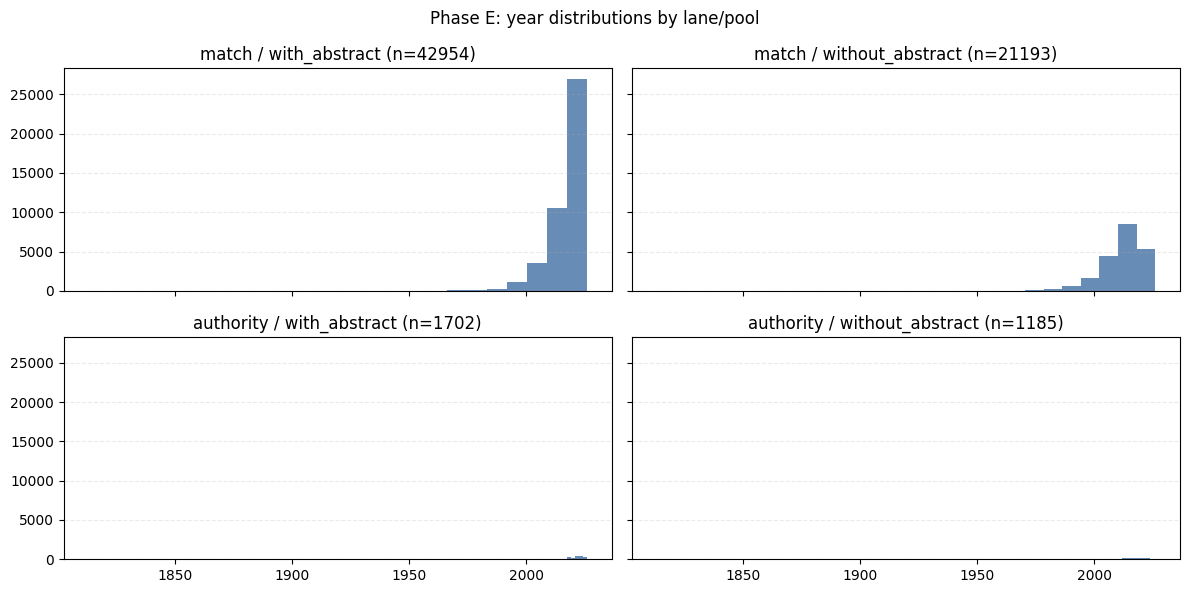

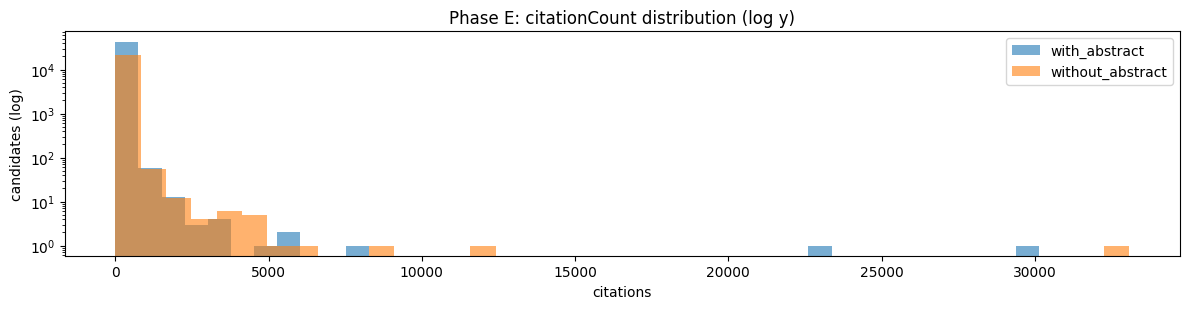

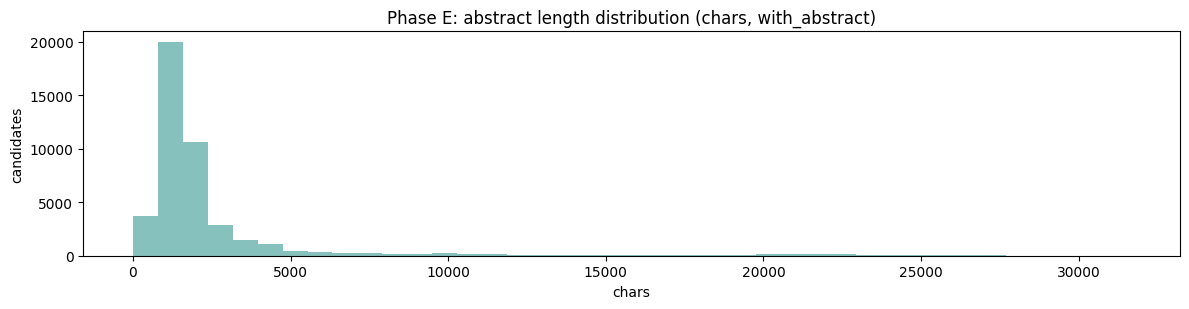

Phase E — Artifacts
candidates_normalized.jsonl  <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\candidates_normalized.jsonl
candidates_normalized.csv    <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\candidates_normalized.csv


In [14]:
# Phase E — Normalize, deduplicate, and pool split
#
# Implements:
# - Normalize OpenAlex/S2 raw records -> canonical Candidate
# - Cross-provider dedup (DOI > arXiv > PMID/PMCID > fallback)
# - Merge precedence: prefer abstract-bearing / richer metadata, preserve provenance
# - Split into disjoint pools: with_abstract vs without_abstract

import csv
import json
import re
from pathlib import Path
from typing import Any, Dict, Iterable, Iterator, List, Optional, Tuple

from pydantic import BaseModel, Field
from pydantic.config import ConfigDict


_PARATEXT_RE = re.compile(
    r"^(books received|book[s]?\s+received|erratum|correction|editorial|preface|introduction|obituary)\b",
    re.IGNORECASE,
)


def is_paratext_title(title: str) -> bool:
    t = (title or "").strip()
    if not t:
        return True
    return bool(_PARATEXT_RE.search(t))


class CandidateSource(BaseModel):
    model_config = ConfigDict(extra="forbid")

    provider: str
    query_hash: str
    query_i: int
    intent: str
    language: str
    rank: Optional[int] = None


class Candidate(BaseModel):
    model_config = ConfigDict(extra="forbid")

    # Canonical identity
    id: str
    doi: Optional[str] = None
    external_ids: Dict[str, str] = Field(default_factory=dict)

    # Metadata
    title: str
    authors: List[str] = Field(default_factory=list)
    year: Optional[int] = None
    venue: Optional[str] = None
    venue_is_core: Optional[bool] = None
    url: Optional[str] = None
    language: Optional[str] = None
    languages: List[str] = Field(default_factory=list)
    abstract: Optional[str] = None

    # Provenance
    provider_ids: Dict[str, List[str]] = Field(default_factory=dict)
    sources: List[CandidateSource] = Field(default_factory=list)
    intents: List[str] = Field(default_factory=list)

    # Signals
    citations: int = 0
    influential_citations: int = 0

    # Pool split
    pool: str


def _iter_jsonl_dicts(path: Path) -> Iterator[Dict[str, Any]]:
    if not path.exists():
        return
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            if isinstance(obj, dict):
                yield obj


def _count_lines(path: Path) -> int:
    if not path.exists():
        return 0
    n = 0
    try:
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    n += 1
    except Exception:
        return 0
    return n

def reconstruct_abstract_from_inverted_index(inv: Any) -> Optional[str]:
    """Reconstruct OpenAlex abstract text from `abstract_inverted_index`.

    OpenAlex stores a mapping token -> list[int positions]. We rebuild a best-effort
    token sequence and join with spaces.
    """

    if not isinstance(inv, dict) or not inv:
        return None

    max_pos = -1
    for positions in inv.values():
        if not isinstance(positions, list):
            continue
        for p in positions:
            if isinstance(p, int) and p > max_pos:
                max_pos = p

    if max_pos < 0:
        return None

    words = [""] * (max_pos + 1)
    for token, positions in inv.items():
        if not isinstance(token, str) or not isinstance(positions, list):
            continue
        for p in positions:
            if isinstance(p, int) and 0 <= p <= max_pos:
                words[p] = token

    text = " ".join(w for w in words if w)
    text = re.sub(r"\s+", " ", text).strip()
    return text or None


_DOI_PREFIX_RE = re.compile(r"^(?:https?://(?:dx\.)?doi\.org/|doi:)", re.IGNORECASE)


def normalize_doi(x: Any) -> Optional[str]:
    if not x:
        return None
    s = str(x).strip()
    s = _DOI_PREFIX_RE.sub("", s)
    s = s.strip().strip("/")
    s = s.lower()
    if not s:
        return None
    if s.startswith("10."):
        return s
    # Some providers embed DOI in longer URLs; accept if we can find a DOI-ish substring.
    m = re.search(r"10\.[0-9]{4,9}/[^\s]+", s)
    if m:
        return m.group(0).lower().rstrip(".")
    return None


def normalize_arxiv(x: Any) -> Optional[str]:
    if not x:
        return None
    s = str(x).strip()
    s = re.sub(r"^https?://arxiv\.org/(abs|pdf)/", "", s, flags=re.IGNORECASE)
    s = re.sub(r"^arxiv:\s*", "", s, flags=re.IGNORECASE)
    s = s.strip().strip("/")
    s = s.lower()
    return s or None


def normalize_pmid(x: Any) -> Optional[str]:
    if not x:
        return None
    s = str(x).strip()
    s = re.sub(r"^https?://pubmed\.ncbi\.nlm\.nih\.gov/", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\D+", "", s)
    return s or None


def normalize_pmcid(x: Any) -> Optional[str]:
    if not x:
        return None
    s = str(x).strip()
    s = re.sub(r"^https?://www\.ncbi\.nlm\.nih\.gov/pmc/articles/", "", s, flags=re.IGNORECASE)
    s = s.strip().strip("/")
    s = s.upper()
    if s and not s.startswith("PMC"):
        s = "PMC" + s
    return s or None


_PUNCT_RE = re.compile(r"[^\w\s]+", re.UNICODE)


def normalize_title(x: Any) -> str:
    s = str(x or "").casefold()
    s = _PUNCT_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def first_author_lastname(authors: List[str]) -> str:
    if not authors:
        return ""
    a = str(authors[0] or "").strip()
    if not a:
        return ""
    # Keep it simple: last token after whitespace.
    parts = re.split(r"\s+", a)
    last = parts[-1] if parts else ""
    last = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ\-']+", "", last)
    return last.casefold()


def _merge_str(a: Optional[str], b: Optional[str]) -> Optional[str]:
    a = (a or "").strip() or None
    b = (b or "").strip() or None
    if a and b:
        return a if len(a) >= len(b) else b
    return a or b


def _merge_list_pref_longer(a: List[str], b: List[str]) -> List[str]:
    a = list(a or [])
    b = list(b or [])
    if len(b) > len(a):
        return b
    return a


def _merge_int_max(a: Any, b: Any) -> int:
    try:
        ia = int(a or 0)
    except Exception:
        ia = 0
    try:
        ib = int(b or 0)
    except Exception:
        ib = 0
    return max(ia, ib)


def _merge_bool_tristate(a: Any, b: Any) -> Optional[bool]:
    va = a if isinstance(a, bool) else None
    vb = b if isinstance(b, bool) else None
    if va is True or vb is True:
        return True
    if va is False or vb is False:
        return False
    return None


def _merge_year(a: Optional[int], b: Optional[int]) -> Optional[int]:
    ya = int(a) if isinstance(a, int) else None
    yb = int(b) if isinstance(b, int) else None
    if ya and yb:
        return ya if ya == yb else min(ya, yb)
    return ya or yb


def _uniq_preserve(xs: List[str]) -> List[str]:
    out = []
    seen = set()
    for x in xs or []:
        x = str(x or "").strip()
        if not x:
            continue
        if x in seen:
            continue
        seen.add(x)
        out.append(x)
    return out


def _merge_sources(a: List[CandidateSource], b: List[CandidateSource]) -> List[CandidateSource]:
    out = list(a or [])
    seen = {stable_hash(s.provider, s.query_hash, str(s.query_i), str(s.rank or ""), s.intent, s.language, length=24) for s in out}
    for s in b or []:
        h = stable_hash(s.provider, s.query_hash, str(s.query_i), str(s.rank or ""), s.intent, s.language, length=24)
        if h in seen:
            continue
        seen.add(h)
        out.append(s)
    return out


def _merge_provider_ids(a: Dict[str, List[str]], b: Dict[str, List[str]]) -> Dict[str, List[str]]:
    out: Dict[str, List[str]] = {k: list(v) for k, v in (a or {}).items()}
    for k, vs in (b or {}).items():
        out.setdefault(k, [])
        out[k].extend(list(vs or []))
        out[k] = _uniq_preserve(out[k])
    return out


def _merge_external_ids(a: Dict[str, str], b: Dict[str, str]) -> Dict[str, str]:
    out = dict(a or {})
    for k, v in (b or {}).items():
        if not v:
            continue
        if k not in out or not out.get(k):
            out[k] = str(v)
            continue
        # conflict: prefer longer/more specific
        if len(str(v)) > len(str(out[k])):
            out[k] = str(v)
    return out


def _key_candidates(partial: Dict[str, Any]) -> List[str]:
    doi = normalize_doi(partial.get("doi"))
    ext = partial.get("external_ids") or {}
    arxiv = normalize_arxiv(ext.get("arxiv"))
    pmid = normalize_pmid(ext.get("pmid"))
    pmcid = normalize_pmcid(ext.get("pmcid"))

    title = partial.get("title") or ""
    year = partial.get("year")
    authors = partial.get("authors") or []

    keys: List[str] = []
    if doi:
        keys.append(f"doi:{doi}")
    if arxiv:
        keys.append(f"arxiv:{arxiv}")
    if pmid:
        keys.append(f"pmid:{pmid}")
    if pmcid:
        keys.append(f"pmcid:{pmcid}")

    tnorm = normalize_title(title)
    ln = first_author_lastname(authors)
    if tnorm and year and ln:
        keys.append(f"fallback:{tnorm}|{int(year)}|{ln}")

    # Guarantee deterministic ordering and remove duplicates.
    pri = {"doi": 0, "arxiv": 1, "pmid": 2, "pmcid": 3, "fallback": 4}
    keys = sorted(set(keys), key=lambda k: (pri.get(k.split(":", 1)[0], 99), k))
    return keys


def _final_candidate_id(c: Dict[str, Any]) -> str:
    doi = normalize_doi(c.get("doi"))
    if doi:
        return doi
    ext = c.get("external_ids") or {}
    arxiv = normalize_arxiv(ext.get("arxiv"))
    if arxiv:
        return f"arxiv:{arxiv}"
    pmid = normalize_pmid(ext.get("pmid"))
    if pmid:
        return f"pmid:{pmid}"
    pmcid = normalize_pmcid(ext.get("pmcid"))
    if pmcid:
        return f"pmcid:{pmcid}"

    title = c.get("title") or ""
    year = c.get("year")
    authors = c.get("authors") or []
    tnorm = normalize_title(title)
    ln = first_author_lastname(authors)
    if tnorm and year and ln:
        payload = f"{tnorm}|{year}|{ln}"
        return "cand_" + stable_hash(payload, length=24)

    # Weak identity fallback: include provider_ids + url to avoid collisions on common titles
    pid = json.dumps(c.get("provider_ids") or {}, ensure_ascii=False, sort_keys=True)
    url = str(c.get("url") or "").strip()
    payload = f"{tnorm}|{year or ''}|{ln}|{url}|{pid}"
    return "cand_" + stable_hash(payload, length=24)


def normalize_openalex_record(rec: Dict[str, Any], *, stats: Optional[Dict[str, int]] = None) -> Optional[Dict[str, Any]]:
    w = (rec or {}).get("work") or {}
    if not isinstance(w, dict):
        return None

    title = (w.get("display_name") or "").strip()
    if not title:
        return None

    if is_paratext_title(title):
        if stats is not None:
            stats['filtered_paratext_titles'] = int(stats.get('filtered_paratext_titles', 0) or 0) + 1
        return None

    wtype = str(w.get("type") or "").casefold()
    if wtype in {"editorial", "erratum", "correction", "letter"}:
        if stats is not None:
            stats['filtered_openalex_types'] = int(stats.get('filtered_openalex_types', 0) or 0) + 1
        return None

    cited_by = int(w.get("cited_by_count") or 0)
    year = w.get("publication_year")
    year = int(year) if isinstance(year, int) else None

    # IDs
    ids = w.get("ids") or {}
    doi = normalize_doi(w.get("doi") or ids.get("doi"))
    arxiv = normalize_arxiv(ids.get("arxiv"))
    pmid = normalize_pmid(ids.get("pmid"))
    pmcid = normalize_pmcid(ids.get("pmcid"))

    external_ids: Dict[str, str] = {}
    if arxiv:
        external_ids["arxiv"] = arxiv
    if pmid:
        external_ids["pmid"] = pmid
    if pmcid:
        external_ids["pmcid"] = pmcid

    # Venue / URL
    pl = w.get("primary_location") or {}
    src = (pl.get("source") or {}) if isinstance(pl, dict) else {}
    venue = None
    if isinstance(src, dict):
        venue = (src.get("display_name") or "").strip() or None

    venue_is_core: Optional[bool] = None
    if isinstance(src, dict) and isinstance(src.get("is_core"), bool):
        venue_is_core = src.get("is_core")

    url = None
    if isinstance(pl, dict):
        url = (pl.get("landing_page_url") or "").strip() or None
    if not url and doi:
        url = "https://doi.org/" + doi

    # Authors
    authors: List[str] = []
    auths = w.get("authorships") or []
    if isinstance(auths, list):
        for a in auths[:50]:
            if not isinstance(a, dict):
                continue
            nm = ((a.get("author") or {}).get("display_name") or "").strip()
            if nm:
                authors.append(nm)
    authors = _uniq_preserve(authors)

    # Abstract
    abstract = reconstruct_abstract_from_inverted_index(w.get("abstract_inverted_index"))

    openalex_id = (w.get("id") or ids.get("openalex") or "").strip() or None

    intent = str(rec.get("intent") or "unknown")
    if intent == 'unknown':
        if stats is not None:
            stats['unknown_intent_count'] = int(stats.get('unknown_intent_count', 0) or 0) + 1

    src_obj = CandidateSource(
        provider="openalex",
        query_hash=str(rec.get("query_hash") or ""),
        query_i=int(rec.get("query_i") or 0),
        intent=intent,
        language=str(rec.get("language") or ""),
        rank=int(rec.get("rank") or 0) if rec.get("rank") is not None else None,
    )

    return {
        "doi": doi,
        "external_ids": external_ids,
        "title": title,
        "authors": authors,
        "year": year,
        "venue": venue,
        "venue_is_core": venue_is_core,
        "url": url,
        "language": str(rec.get("language") or "") or None,
        "languages": [str(rec.get("language") or "") or ""],
        "abstract": abstract,
        "provider_ids": {"openalex": [openalex_id] if openalex_id else []},
        "sources": [src_obj],
        "intents": [intent],
        "citations": cited_by,
        "influential_citations": 0,
    }


def normalize_s2_record(rec: Dict[str, Any], *, stats: Optional[Dict[str, int]] = None) -> Optional[Dict[str, Any]]:
    p = (rec or {}).get("paper") or {}
    if not isinstance(p, dict):
        return None

    title = (p.get("title") or "").strip()
    if not title:
        return None

    if is_paratext_title(title):
        if stats is not None:
            stats['filtered_paratext_titles'] = int(stats.get('filtered_paratext_titles', 0) or 0) + 1
        return None

    year = p.get("year")
    year = int(year) if isinstance(year, int) else None

    doi = normalize_doi(((p.get("externalIds") or {}).get("DOI")) or p.get("doi"))
    ext = p.get("externalIds") or {}

    arxiv = normalize_arxiv(ext.get("ArXiv"))
    pmid = normalize_pmid(ext.get("PubMed"))
    pmcid = normalize_pmcid(ext.get("PubMedCentral"))

    external_ids: Dict[str, str] = {}
    if arxiv:
        external_ids["arxiv"] = arxiv
    if pmid:
        external_ids["pmid"] = pmid
    if pmcid:
        external_ids["pmcid"] = pmcid

    citations = int(p.get("citationCount") or 0)
    influential = int(p.get("influentialCitationCount") or 0)

    venue = (p.get("venue") or "").strip() or None
    url = (p.get("url") or "").strip() or None

    authors: List[str] = []
    auths = p.get("authors") or []
    if isinstance(auths, list):
        for a in auths[:80]:
            if not isinstance(a, dict):
                continue
            nm = (a.get("name") or "").strip()
            if nm:
                authors.append(nm)
    authors = _uniq_preserve(authors)

    abstract = (p.get("abstract") or "").strip() or None

    paper_id = (p.get("paperId") or "").strip() or None

    intent = str(rec.get("intent") or "unknown")
    if intent == 'unknown':
        if stats is not None:
            stats['unknown_intent_count'] = int(stats.get('unknown_intent_count', 0) or 0) + 1

    src_obj = CandidateSource(
        provider="semanticscholar",
        query_hash=str(rec.get("query_hash") or ""),
        query_i=int(rec.get("query_i") or 0),
        intent=intent,
        language=str(rec.get("language") or ""),
        rank=int(rec.get("rank") or 0) if rec.get("rank") is not None else None,
    )

    return {
        "doi": doi,
        "external_ids": external_ids,
        "title": title,
        "authors": authors,
        "year": year,
        "venue": venue,
        "venue_is_core": None,
        "url": url,
        "language": str(rec.get("language") or "") or None,
        "languages": [str(rec.get("language") or "") or ""],
        "abstract": abstract,
        "provider_ids": {"semanticscholar": [paper_id] if paper_id else []},
        "sources": [src_obj],
        "intents": [intent],
        "citations": citations,
        "influential_citations": influential,
    }


def merge_partials(a: Dict[str, Any], b: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(a)

    # Identity + metadata
    out["doi"] = normalize_doi(_merge_str(out.get("doi"), b.get("doi")))
    out["external_ids"] = _merge_external_ids(out.get("external_ids") or {}, b.get("external_ids") or {})
    out["title"] = _merge_str(out.get("title"), b.get("title")) or (out.get("title") or "")
    out["authors"] = _merge_list_pref_longer(out.get("authors") or [], b.get("authors") or [])
    out["year"] = _merge_year(out.get("year"), b.get("year"))
    out["venue"] = _merge_str(out.get("venue"), b.get("venue"))
    out["venue_is_core"] = _merge_bool_tristate(out.get("venue_is_core"), b.get("venue_is_core"))
    out["url"] = _merge_str(out.get("url"), b.get("url"))

    # Abstract precedence: prefer non-empty, then longer.
    abs_a = (out.get("abstract") or "").strip()
    abs_b = (b.get("abstract") or "").strip()
    if abs_a and abs_b:
        out["abstract"] = abs_a if len(abs_a) >= len(abs_b) else abs_b
    else:
        out["abstract"] = abs_a or abs_b or None

    # Provenance & signals
    out["provider_ids"] = _merge_provider_ids(out.get("provider_ids") or {}, b.get("provider_ids") or {})
    out["sources"] = _merge_sources(out.get("sources") or [], b.get("sources") or [])
    out["intents"] = sorted(set([*(out.get("intents") or []), *(b.get("intents") or [])]))
    out["languages"] = sorted(set([*(out.get("languages") or []), *(b.get("languages") or [])]))

    out["citations"] = _merge_int_max(out.get("citations"), b.get("citations"))
    out["influential_citations"] = _merge_int_max(out.get("influential_citations"), b.get("influential_citations"))

    # A single, best-effort language label.
    langs = [x for x in out.get("languages") or [] if x]
    out["language"] = langs[0] if len(set(langs)) == 1 else None

    return out


def build_candidates_from_raw(
    *,
    run_ctx: RunContext,
    force_rebuild: bool,
) -> Tuple[List[Candidate], Dict[str, Any]]:
    stage = "phase_e_candidates"

    raw_oa = run_ctx.artifacts.openalex_raw_jsonl
    raw_s2 = run_ctx.artifacts.semanticscholar_raw_jsonl
    out_jsonl = run_ctx.artifacts.candidates_normalized_jsonl
    out_csv = run_ctx.artifacts.candidates_normalized_csv

    # Cache policy: if we did not force rebuild upstream and candidates already exist, reuse.
    def _has_data(p: Path) -> bool:
        try:
            with p.open('r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        return True
        except Exception:
            return False
        return False

    if (not force_rebuild) and _has_data(out_jsonl):
        rows = [Candidate(**obj) for obj in _iter_jsonl_dicts(out_jsonl)]

        # Safety: if cache contains duplicate ids, ignore it and rebuild.
        ids = [c.id for c in rows]
        if len(set(ids)) == len(ids):
            # Reuse stored metrics if present (so the summary stays informative on reruns).
            meta: Dict[str, Any] = {}
            try:
                metrics = load_metrics(run_ctx)
                cached = ((metrics.get("stages") or {}).get(stage) or {}).get("counts")
                if isinstance(cached, dict):
                    meta = dict(cached)
            except Exception:
                meta = {}

            pool_counts = {"with_abstract": 0, "without_abstract": 0}
            for c in rows:
                pool_counts[c.pool] = pool_counts.get(c.pool, 0) + 1

            meta.update(
                {
                    "cache_hit": True,
                    "raw_openalex_records": _count_lines(raw_oa),
                    "raw_s2_records": _count_lines(raw_s2),
                    "deduped_candidates": len(rows),
                    "final_id_collisions": 0,
                    "pool_counts": pool_counts,
                    "candidates_jsonl": str(out_jsonl),
                    "candidates_csv": str(out_csv),
                }
            )
            return rows, meta

    # Stream normalization
    normalized = 0
    normalized_by_provider = {"openalex": 0, "semanticscholar": 0}
    stats: Dict[str, int] = {
        'filtered_paratext_titles': 0,
        'filtered_openalex_types': 0,
        'unknown_intent_count': 0,
    }

    index: Dict[str, str] = {}  # key -> internal cid
    by_cid: Dict[str, Dict[str, Any]] = {}

    merges = 0

    def _get_or_create(part: Dict[str, Any]) -> str:
        nonlocal merges
        keys = _key_candidates(part)
        cid = None
        for k in keys:
            if k in index:
                cid = index[k]
                break
        if cid is None:
            # Stable internal id: derived from best available key(s)
            if keys:
                seed = keys[0]
            else:
                pid = json.dumps(part.get("provider_ids") or {}, ensure_ascii=False, sort_keys=True)
                seed = (part.get("title") or "") + "\n" + pid + "\n" + str(part.get("url") or "")
            cid = stable_hash("candidate", seed, length=24)
            by_cid[cid] = part
        else:
            by_cid[cid] = merge_partials(by_cid[cid], part)
            merges += 1

        # Re-index with whatever keys we have after merge.
        merged = by_cid[cid]
        for k in _key_candidates(merged):
            index[k] = cid
        return cid

    for rec in _iter_jsonl_dicts(raw_oa):
        part = normalize_openalex_record(rec, stats=stats)
        if not part:
            continue
        normalized += 1
        normalized_by_provider['openalex'] += 1
        _get_or_create(part)

    for rec in _iter_jsonl_dicts(raw_s2):
        part = normalize_s2_record(rec, stats=stats)
        if not part:
            continue
        normalized += 1
        normalized_by_provider['semanticscholar'] += 1
        _get_or_create(part)

    # Finalize models + pool split
    candidates: List[Candidate] = []
    pool_counts = {"with_abstract": 0, "without_abstract": 0}
    final_ids_seen = set()
    final_id_collisions = 0

    for cid, part in by_cid.items():
        abstract = (part.get('abstract') or '').strip() or None
        pool = 'with_abstract' if abstract else 'without_abstract'
        pool_counts[pool] += 1

        part_final = dict(part)
        part_final['abstract'] = abstract
        part_final['pool'] = pool
        final_id = _final_candidate_id(part_final)
        if final_id in final_ids_seen:
            final_id_collisions += 1
            final_id = 'cand_' + str(cid)
        final_ids_seen.add(final_id)
        part_final['id'] = final_id
        part_final['doi'] = normalize_doi(part_final.get('doi'))

        # Ensure canonical list fields
        part_final['authors'] = _uniq_preserve(part_final.get('authors') or [])
        part_final['intents'] = sorted(set([x for x in part_final.get('intents') or [] if x]))
        part_final['languages'] = sorted(set([x for x in part_final.get('languages') or [] if x]))

        candidates.append(Candidate(**part_final))

    # Deterministic output order: highest citations first, then title.
    candidates.sort(key=lambda c: (-int(c.citations or 0), (c.title or "").casefold(), c.id))

    # Write JSONL atomically
    ensure_dir(out_jsonl.parent)
    tmp = out_jsonl.with_suffix(out_jsonl.suffix + '.tmp')
    with tmp.open('w', encoding='utf-8') as f:
        for c in candidates:
            f.write(json.dumps(c.model_dump(mode='json'), ensure_ascii=False, default=_json_default) + '\n')
    tmp.replace(out_jsonl)

    # Write CSV (small, practical view)
    ensure_dir(out_csv.parent)
    tmpc = out_csv.with_suffix(out_csv.suffix + '.tmp')
    fieldnames = [
        'id','doi','pool','citations','influential_citations','year','title','venue','venue_is_core','url',
        'authors_first','langs','intents','openalex_id','s2_paperId','sources_n','abstract_len'
    ]
    with tmpc.open('w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for c in candidates:
            openalex_ids = (c.provider_ids or {}).get('openalex') or []
            s2_ids = (c.provider_ids or {}).get('semanticscholar') or []
            w.writerow({
                'id': c.id,
                'doi': c.doi or '',
                'pool': c.pool,
                'citations': int(c.citations or 0),
                'influential_citations': int(c.influential_citations or 0),
                'year': c.year or '',
                'title': c.title,
                'venue': c.venue or '',
                'venue_is_core': ('' if c.venue_is_core is None else str(bool(c.venue_is_core)).lower()),
                'url': c.url or '',
                'authors_first': (c.authors[0] if c.authors else ''),
                'langs': ','.join(c.languages or []),
                'intents': ','.join(c.intents or []),
                'openalex_id': (openalex_ids[0] if openalex_ids else ''),
                's2_paperId': (s2_ids[0] if s2_ids else ''),
                'sources_n': len(c.sources or []),
                'abstract_len': (len(c.abstract or '') if c.abstract else 0),
            })
    tmpc.replace(out_csv)

    meta = {
        'cache_hit': False,
        'raw_openalex_records': _count_lines(raw_oa),
        'raw_s2_records': _count_lines(raw_s2),
        'normalized_total': normalized,
        'normalized_by_provider': normalized_by_provider,
        'deduped_candidates': len(candidates),
        'merges': merges,
        'final_id_collisions': int(final_id_collisions or 0),
        'filtered_paratext_titles': int(stats.get('filtered_paratext_titles', 0) or 0),
        'filtered_openalex_types': int(stats.get('filtered_openalex_types', 0) or 0),
        'unknown_intent_count': int(stats.get('unknown_intent_count', 0) or 0),
        'pool_counts': pool_counts,
        'candidates_jsonl': str(out_jsonl),
        'candidates_csv': str(out_csv),
    }

    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        provider="candidates",
        path=str(out_jsonl),
        records=len(candidates),
        csv=str(out_csv),
        merges=merges,
        with_abstract=pool_counts.get("with_abstract"),
        without_abstract=pool_counts.get("without_abstract"),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault('stages', {}).setdefault(stage, {})['counts'] = meta
    save_metrics(run_ctx, metrics)

    return candidates, meta


print_section('Phase E — Candidates')
with stage_timer(run_ctx, 'phase_e_candidates'):
    candidates, meta_e = build_candidates_from_raw(run_ctx=run_ctx, force_rebuild=FORCE_REBUILD_RETRIEVAL)

# Pool + id sanity checks (required for lane isolation + scoring)
allowed_pools = {'with_abstract', 'without_abstract'}
bad_pool = [f"{c.id}:{c.pool}" for c in candidates if str(c.pool or '') not in allowed_pools]
assert not bad_pool, f"Unexpected pool values (first 10): {bad_pool[:10]}"

ids_all = [c.id for c in candidates]
id_counts: Dict[str, int] = {}
for cid in ids_all:
    id_counts[str(cid)] = int(id_counts.get(str(cid), 0) or 0) + 1
dups = [cid for cid, n in id_counts.items() if int(n) > 1]
assert not dups, f"Duplicate candidate ids after normalization (first 10): {dups[:10]}"

with_n = sum(1 for c in candidates if c.pool == 'with_abstract')
without_n = sum(1 for c in candidates if c.pool == 'without_abstract')
assert with_n + without_n == len(candidates), 'Pool split counts do not add up'

# Load plan for anchor/canonical term sanity
try:
    _plan_for_e = plan  # type: ignore
except Exception:
    try:
        _plan_for_e = QueryPlan(**read_json(run_ctx.artifacts.query_plan_json))
    except Exception:
        _plan_for_e = None

anchors_all: List[str] = []
econ_terms_all: List[str] = []
if _plan_for_e is not None:
    try:
        anchors_all = list((_plan_for_e.primary_context_anchors.en or [])) + list((_plan_for_e.primary_context_anchors.de or []))
    except Exception:
        anchors_all = []
    try:
        econ_terms_all = list((_plan_for_e.global_canonical_terms.en or [])) + list((_plan_for_e.global_canonical_terms.de or []))
    except Exception:
        econ_terms_all = []

# -----------------------------
# At a glance + QC
# -----------------------------
print_section('Phase E — At a glance')

n_total = len(candidates)
with_abs = sum(1 for c in candidates if c.pool == 'with_abstract')
no_abs = sum(1 for c in candidates if c.pool == 'without_abstract')
with_abs_share = float(with_abs) / float(max(1, n_total))

deduped = int(meta_e.get('deduped_candidates', meta_e.get('candidates', n_total)) or n_total)
normalized_total = int(meta_e.get('normalized_total', 0) or 0)
merges = int(meta_e.get('merges', 0) or 0)

dedup_ratio = (float(deduped) / float(max(1, normalized_total))) if normalized_total else 0.0
merge_ratio = (float(merges) / float(max(1, normalized_total))) if normalized_total else 0.0

n_doi = sum(1 for c in candidates if bool(c.doi))
doi_share = float(n_doi) / float(max(1, n_total))

n_year_missing = sum(1 for c in candidates if not (c.year and int(c.year) > 0))
year_missing_share = float(n_year_missing) / float(max(1, n_total))

filtered_paratext_titles = int(meta_e.get('filtered_paratext_titles', 0) or 0)
filtered_openalex_types = int(meta_e.get('filtered_openalex_types', 0) or 0)
unknown_intent_count = int(meta_e.get('unknown_intent_count', 0) or 0)
final_id_collisions = int(meta_e.get('final_id_collisions', 0) or 0)
unknown_intent_candidates = sum(1 for c in candidates if 'unknown' in (c.intents or []))

print_kv(
    {
        'cache_hit': meta_e.get('cache_hit'),
        'raw_openalex_records': _fmt_int(meta_e.get('raw_openalex_records', 0)),
        'raw_s2_records': _fmt_int(meta_e.get('raw_s2_records', 0)),
        'normalized_total': _fmt_int(normalized_total),
        'deduped_candidates': _fmt_int(deduped),
        'dedup_ratio': f"{dedup_ratio*100:.1f}%",
        'merges': _fmt_int(merges),
        'merge_ratio': f"{merge_ratio*100:.1f}%",
        'with_abstract': _fmt_int(with_abs),
        'without_abstract': _fmt_int(no_abs),
        'with_abs_share': f"{with_abs_share*100:.1f}%",
        'doi_share': f"{doi_share*100:.1f}%",
        'year_missing_share': f"{year_missing_share*100:.1f}%",
        'filtered_paratext_titles': _fmt_int(filtered_paratext_titles),
        'filtered_openalex_types': _fmt_int(filtered_openalex_types),
        'unknown_intent_count': _fmt_int(unknown_intent_count),
        'final_id_collisions': _fmt_int(final_id_collisions),
        'unknown_intent_candidates': _fmt_int(unknown_intent_candidates),
    },
    key_width=22,
)

qc = []
qc.append(qc_row('pool_split_disjoint', 'OK', 'assertions passed', 'disjoint id sets', 'mixing pools breaks evidence rules', 'inspect pool assignment logic'))
qc.append(
    qc_row(
        'with_abstract_share',
        'FAIL' if with_abs_share <= WITH_ABS_FAIL else ('WARN' if with_abs_share <= WITH_ABS_WARN else 'OK'),
        f"{with_abs_share*100:.1f}%",
        f"> {WITH_ABS_WARN*100:.0f}% (domain-dependent)",
        'low abstract share reduces evidence quality and stage2 usefulness',
        'broaden title/abstract search; adjust provider settings',
    )
)
qc.append(
    qc_row(
        'year_missing_share',
        'FAIL' if year_missing_share >= YEAR_MISSING_FAIL else ('WARN' if year_missing_share >= YEAR_MISSING_WARN else 'OK'),
        f"{year_missing_share*100:.1f}%",
        f"< {YEAR_MISSING_WARN*100:.0f}%",
        'missing years degrade authority normalization and stratification',
        'prefer richer records; check provider mappings',
    )
)
qc.append(
    qc_row(
        'doi_share',
        'FAIL' if doi_share < 0.30 else ('WARN' if doi_share < 0.50 else 'OK'),
        f"{doi_share*100:.1f}%",
        '>= 50% (domain-dependent)',
        'DOIs improve dedup/linking; low DOI share can indicate noisy retrieval',
        'tighten queries or add provider filters',
    )
)
qc.append(qc_row('unknown_intent_records', 'WARN' if unknown_intent_count > 0 else 'OK', _fmt_int(unknown_intent_count), '0', 'missing source intent breaks lane isolation', 'ensure retrieval preserves intent per record'))

print_section('Phase E — QC')
print_qc(qc)


def _lane_label(c: Candidate) -> str:
    has_auth = 'authority' in (c.intents or [])
    has_match = 'match' in (c.intents or [])
    if has_auth and has_match:
        return 'both'
    if has_auth:
        return 'authority'
    if has_match:
        return 'match'
    return 'unknown'


def _anchor_hit_candidate(c: Candidate) -> bool:
    if not anchors_all:
        return False
    text = f"{c.title or ''} {c.abstract or ''}"
    return any_term_in_text(text, anchors_all)


def _econ_hit_candidate(c: Candidate) -> int:
    if not econ_terms_all:
        return 0
    text = f"{c.title or ''} {c.abstract or ''}".casefold()
    hits = 0
    for t in econ_terms_all:
        tt = str(t or '').strip()
        if not tt:
            continue
        if tt.casefold() in text:
            hits += 1
    return hits


# -----------------------------
# Counts by lane/pool
# -----------------------------
rows = []
for c in candidates:
    rows.append({'lane': _lane_label(c), 'pool': c.pool, 'n': 1})

agg: Dict[Tuple[str, str], int] = {}
for r in rows:
    k = (r['lane'], r['pool'])
    agg[k] = agg.get(k, 0) + 1

print_section('Phase E — Counts by lane/pool')
print_table(
    [{'lane': k[0], 'pool': k[1], 'n': _fmt_int(v)} for k, v in sorted(agg.items(), key=lambda x: (-x[1], x[0][0], x[0][1]))],
    columns=['lane', 'pool', 'n'],
    max_rows=30,
    max_col_width=30,
)

# -----------------------------
# Top candidates (by citations) — sorted correctly
# -----------------------------
print_section('Phase E — Top candidates (by citations)')

sorted_by_cites = sorted(candidates, key=lambda c: (-int(c.citations or 0), str(c.title or '').casefold(), str(c.id)))
preview = []
for c in sorted_by_cites[:20]:
    preview.append(
        {
            'lane': _lane_label(c),
            'pool': c.pool,
            'cites': int(c.citations or 0),
            'year': c.year or '',
            'anchor_hit': 'yes' if _anchor_hit_candidate(c) else 'no',
            'econ_hits': _econ_hit_candidate(c),
            'has_abs': 'yes' if (c.abstract and c.abstract.strip()) else 'no',
            'title': _truncate(c.title, 100),
            'doi': _truncate(c.doi or '', 55),
            'id': _truncate(c.id, 55),
        }
    )
print_table(preview, columns=['lane','pool','cites','year','anchor_hit','econ_hits','has_abs','title','doi','id'], max_rows=20, max_col_width=160)

# -----------------------------
# Provider overlap / ID coverage / venue core
# -----------------------------
print_section('Phase E — Provider overlap')

def _has_provider_id(c: Candidate, key: str) -> bool:
    try:
        return bool((c.provider_ids or {}).get(key))
    except Exception:
        return False

n_oa = sum(1 for c in candidates if _has_provider_id(c, 'openalex'))
n_s2 = sum(1 for c in candidates if _has_provider_id(c, 'semanticscholar'))
n_both = sum(1 for c in candidates if _has_provider_id(c, 'openalex') and _has_provider_id(c, 'semanticscholar'))

print_kv(
    {
        'candidates_total': _fmt_int(n_total),
        'openalex_id': _fmt_int(n_oa),
        's2_paperId': _fmt_int(n_s2),
        'both_providers': _fmt_int(n_both),
        'openalex_only': _fmt_int(max(0, n_oa - n_both)),
        's2_only': _fmt_int(max(0, n_s2 - n_both)),
    },
    key_width=18,
)

print_section('Phase E — ID coverage')

def _has_ext_id(c: Candidate, key: str) -> bool:
    try:
        return bool((c.external_ids or {}).get(key))
    except Exception:
        return False

n_arxiv = sum(1 for c in candidates if _has_ext_id(c, 'arxiv'))
n_pmid = sum(1 for c in candidates if _has_ext_id(c, 'pmid'))
n_pmcid = sum(1 for c in candidates if _has_ext_id(c, 'pmcid'))

rows_id = [
    {'key': 'doi', 'n': n_doi, 'pct': (100.0 * n_doi / n_total) if n_total else 0.0},
    {'key': 'arxiv', 'n': n_arxiv, 'pct': (100.0 * n_arxiv / n_total) if n_total else 0.0},
    {'key': 'pmid', 'n': n_pmid, 'pct': (100.0 * n_pmid / n_total) if n_total else 0.0},
    {'key': 'pmcid', 'n': n_pmcid, 'pct': (100.0 * n_pmcid / n_total) if n_total else 0.0},
]
print_table(
    [{'key': r['key'], 'n': _fmt_int(r['n']), 'pct': f"{r['pct']:.1f}%"} for r in rows_id],
    columns=['key', 'n', 'pct'],
    max_rows=10,
    max_col_width=30,
)

core_true = sum(1 for c in candidates if c.venue_is_core is True)
core_false = sum(1 for c in candidates if c.venue_is_core is False)
core_none = sum(1 for c in candidates if c.venue_is_core is None)
print_section('Phase E — Venue core flag (OpenAlex)')
print_kv(
    {
        'is_core_true': _fmt_int(core_true),
        'is_core_false': _fmt_int(core_false),
        'is_core_missing': _fmt_int(core_none),
    },
    key_width=18,
)

# -----------------------------
# Merged candidates (sources > 1)
# -----------------------------
merged_candidates = [c for c in candidates if len(c.sources or []) > 1]

def _is_cross_provider(c: Candidate) -> bool:
    return _has_provider_id(c, 'openalex') and _has_provider_id(c, 'semanticscholar')

merged_candidates.sort(key=lambda c: (0 if _is_cross_provider(c) else 1, -int(c.citations or 0), (c.title or '').casefold(), c.id))

print_section('Phase E — Merged candidates (sources > 1)')
if not merged_candidates:
    print('<none>')
else:
    mprev = []
    for c in merged_candidates[:20]:
        oa_ids = ((c.provider_ids or {}).get('openalex') or [])
        s2_ids = ((c.provider_ids or {}).get('semanticscholar') or [])
        mprev.append(
            {
                'cross': 'yes' if (oa_ids and s2_ids) else 'no',
                'lane': _lane_label(c),
                'pool': c.pool,
                'cites': int(c.citations or 0),
                'year': c.year or '',
                'oa': 'yes' if oa_ids else 'no',
                's2': 'yes' if s2_ids else 'no',
                'sources': len(c.sources or []),
                'title': _truncate(c.title, 92),
                'doi': _truncate(c.doi or '', 55),
            }
        )
    print_table(mprev, columns=['cross','lane','pool','cites','year','oa','s2','sources','title','doi'], max_rows=30, max_col_width=160)

# -----------------------------
# Relevance sanity tables
# -----------------------------
if anchors_all:
    no_anchor = [c for c in sorted_by_cites[:200] if not _anchor_hit_candidate(c)]
    print_section('Phase E — Top cited but NO anchors (red flag)')
    rows_na = []
    for c in no_anchor[:TOP_N_PREVIEW]:
        rows_na.append({'cites': int(c.citations or 0), 'year': c.year or '', 'pool': c.pool, 'lane': _lane_label(c), 'title': _truncate(c.title, 110), 'doi': _truncate(c.doi or '', 55)})
    if not rows_na:
        print('<none>')
    else:
        print_table(rows_na, columns=['cites','year','pool','lane','title','doi'], max_rows=TOP_N_PREVIEW, max_col_width=160)

if econ_terms_all:
    econ_rank = []
    for c in candidates:
        h = _econ_hit_candidate(c)
        if h > 0:
            econ_rank.append((h, int(c.citations or 0), c))
    econ_rank.sort(key=lambda t: (-t[0], -t[1], (t[2].title or '').casefold()))

    print_section('Phase E — Top econ-hit candidates (heuristic)')
    rows_eh = []
    for h, cites, c in econ_rank[:TOP_N_PREVIEW]:
        rows_eh.append({'econ_hits': h, 'cites': cites, 'year': c.year or '', 'pool': c.pool, 'anchor_hit': 'yes' if _anchor_hit_candidate(c) else 'no', 'title': _truncate(c.title, 110), 'doi': _truncate(c.doi or '', 55)})
    if not rows_eh:
        print('<none>')
    else:
        print_table(rows_eh, columns=['econ_hits','cites','year','pool','anchor_hit','title','doi'], max_rows=TOP_N_PREVIEW, max_col_width=160)

# -----------------------------
# Plots (optional)
# -----------------------------
try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception:
    plt = None

if plt is not None and candidates:
    try:
        # 2x2 year hist: match/authority × with/without abs
        def _years(sub: List[Candidate]) -> List[int]:
            ys = []
            for c in sub:
                try:
                    y = int(c.year) if c.year is not None else None
                except Exception:
                    y = None
                if y and 0 < y < 2100:
                    ys.append(y)
            return ys

        fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
        groups = [
            ('match', 'with_abstract', axes[0][0]),
            ('match', 'without_abstract', axes[0][1]),
            ('authority', 'with_abstract', axes[1][0]),
            ('authority', 'without_abstract', axes[1][1]),
        ]
        for lane, pool, ax in groups:
            sub = [c for c in candidates if (lane in (c.intents or [])) and c.pool == pool]
            ys = _years(sub)
            ax.hist(ys, bins=25, color='#4c78a8', alpha=0.85)
            ax.set_title(f"{lane} / {pool} (n={len(sub)})")
            ax.grid(axis='y', linestyle='--', alpha=0.25)
        fig.suptitle('Phase E: year distributions by lane/pool')
        plt.tight_layout()
        plt.show()

        # citations distribution (log y), split by pool
        cites_with = [max(0, int(c.citations or 0)) for c in candidates if c.pool == 'with_abstract']
        cites_no = [max(0, int(c.citations or 0)) for c in candidates if c.pool == 'without_abstract']
        plt.figure(figsize=(12, 3.2))
        plt.hist(cites_with, bins=40, alpha=0.6, label='with_abstract')
        plt.hist(cites_no, bins=40, alpha=0.6, label='without_abstract')
        plt.yscale('log')
        plt.title('Phase E: citationCount distribution (log y)')
        plt.xlabel('citations')
        plt.ylabel('candidates (log)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # abstract length histogram (with_abstract)
        abs_lens = [len(c.abstract or '') for c in candidates if c.pool == 'with_abstract' and (c.abstract or '').strip()]
        if abs_lens:
            plt.figure(figsize=(12, 3.2))
            plt.hist(abs_lens, bins=40, color='#72b7b2', alpha=0.85)
            plt.title('Phase E: abstract length distribution (chars, with_abstract)')
            plt.xlabel('chars')
            plt.ylabel('candidates')
            plt.tight_layout()
            plt.show()
    except Exception:
        pass

print_section('Phase E — Artifacts')
print_kv(
    {
        'candidates_normalized.jsonl': run_ctx.artifacts.candidates_normalized_jsonl,
        'candidates_normalized.csv': run_ctx.artifacts.candidates_normalized_csv,
    },
    key_width=28,
)

# -----------------------------
# Unit tests (acceptance)
# -----------------------------

# Abstract reconstruction
inv_test = {'hello': [0], 'world': [1], 'again': [3]}
assert reconstruct_abstract_from_inverted_index(inv_test) == 'hello world again'

# Dedup precedence: prefer abstract-bearing record
part_a = {
    'doi': '10.1000/xyz',
    'external_ids': {},
    'title': 'Test Title',
    'authors': ['Alice Example'],
    'year': 2020,
    'venue': None,
    'url': None,
    'language': 'en',
    'languages': ['en'],
    'abstract': None,
    'provider_ids': {'openalex': ['W1']},
    'sources': [CandidateSource(provider='openalex', query_hash='h', query_i=1, intent='match', language='en', rank=1)],
    'intents': ['match'],
    'citations': 5,
    'influential_citations': 0,
}
part_b = {
    'doi': 'https://doi.org/10.1000/xyz',
    'external_ids': {},
    'title': 'Test Title',
    'authors': ['Alice Example', 'Bob Example'],
    'year': 2020,
    'venue': 'Venue',
    'url': 'https://example.org',
    'language': 'en',
    'languages': ['en'],
    'abstract': 'This is an abstract.',
    'provider_ids': {'semanticscholar': ['P1']},
    'sources': [CandidateSource(provider='semanticscholar', query_hash='h2', query_i=2, intent='match', language='en', rank=2)],
    'intents': ['match'],
    'citations': 12,
    'influential_citations': 2,
}
merged = merge_partials(part_a, part_b)
assert merged.get('abstract') == 'This is an abstract.'
assert normalize_doi(merged.get('doi')) == '10.1000/xyz'
assert 'openalex' in (merged.get('provider_ids') or {})
assert 'semanticscholar' in (merged.get('provider_ids') or {})
assert _merge_int_max(part_a['citations'], part_b['citations']) == 12


---
# Phase F — Embeddings and staged scoring (with partial-match protection)
---

Phase F — Embeddings + staged scoring
embedding_model    text-embedding-3-small
batch_size         256
prune_n1_with_abs  600
prune_n1_no_abs    300
t                  0.3
t_noabs            0.35
facets             17
candidates         64838
Phase F — At a glance
embedding_model        text-embedding-3-small
batch_size             256
facets                 17
candidates             64,838
stage2_candidates      1,093
stage2_scored          1,093
prompt_tokens          0
cost_usd_est           0.0000
t(abs/noabs)           0.30/0.35
required_facets(w>=4)  15
Phase F — QC
QC: OK=3 WARN=0 FAIL=0
status | check                           | value       | expected | why                                                                                               | fix                                                         
-------+---------------------------------+-------------+----------+---------------------------------------------------------------------------------------------------+--

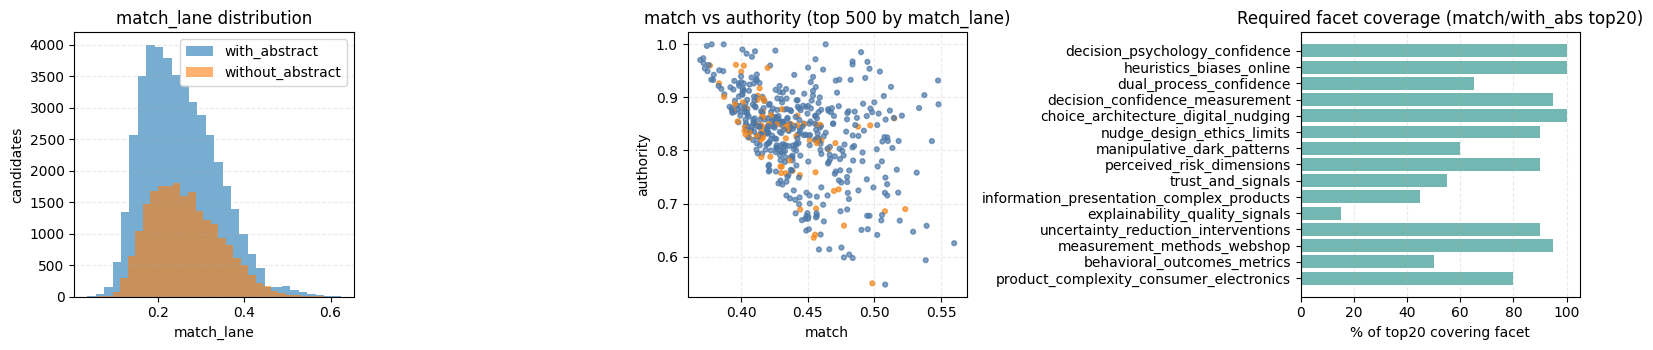

In [15]:
# Phase F — Embeddings and staged scoring (with partial-match protection)
#
# Implements Phase F from TWO_LANE_PIPELINE_IMPLEMENTATION_PLAN_FROM_REPORT.md:
# - F1: embedding cache (text_hash, model) + manifest; batched calls
# - F2: facet embeddings
# - F3: metadata embeddings + Stage 1 facet scores + match aggregation (G1)
# - F5: prune to N1 per lane per pool
# - F6: abstract chunking + Stage 2 MaxSim (with_abstract shortlist only)
# - F7: without-abstract handling via richer metadata segments + stricter threshold

import json
import time
import math
import re
from array import array
from bisect import bisect_right
from datetime import date
from pathlib import Path
from typing import Any, Dict, Iterable, Iterator, List, Optional, Tuple

from openai import OpenAI


# -----------------------------
# Helpers
# -----------------------------

def _iter_jsonl_dicts(path: Path) -> Iterator[Dict[str, Any]]:
    if not path.exists():
        return
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            if isinstance(obj, dict):
                yield obj


def _clip01(x: float) -> float:
    return 0.0 if x < 0.0 else (1.0 if x > 1.0 else float(x))


def _softclip(x: float) -> float:
    return float(x) if x > 0 else 0.0


def _as_f32(vec: Iterable[float]) -> array:
    return vec if isinstance(vec, array) else array('f', [float(x) for x in vec])


def _f32_norm(vec: array) -> float:
    s = 0.0
    for x in vec:
        s += float(x) * float(x)
    return math.sqrt(s) if s > 0 else 0.0


def _f32_dot(a: array, b: array) -> float:
    s = 0.0
    for x, y in zip(a, b):
        s += float(x) * float(y)
    return s


def _cos(a: array, inv_norm_a: float, b: array, inv_norm_b: float) -> float:
    if inv_norm_a <= 0 or inv_norm_b <= 0:
        return 0.0
    return _f32_dot(a, b) * inv_norm_a * inv_norm_b


def _text_hash(text: str) -> str:
    # Keep stable across whitespace noise.
    s = re.sub(r'\s+', ' ', str(text or '').strip())
    return stable_hash(s, length=24)


def _vector_path(run_ctx: RunContext, model: str, text_hash: str) -> Path:
    safe_model = re.sub(r'[^A-Za-z0-9._-]+', '_', model)
    return run_ctx.artifacts.embeddings_vectors_dir / safe_model / f"{text_hash}.f32"


def _global_cache_root(run_ctx: RunContext, cfg: PipelineConfig) -> Optional[Path]:
    root = getattr(cfg, 'embeddings_global_cache_dir', None)
    if root:
        try:
            return Path(root)
        except Exception:
            return None
    # Default: share across runs under sources-v2/embeddings_cache_global
    try:
        base = Path(run_ctx.run_dir).parent.parent
        return base / 'embeddings_cache_global'
    except Exception:
        return None


def _global_vector_path(run_ctx: RunContext, cfg: PipelineConfig, model: str, text_hash: str) -> Optional[Path]:
    root = _global_cache_root(run_ctx, cfg)
    if root is None:
        return None
    safe_model = re.sub(r'[^A-Za-z0-9._-]+', '_', model)
    return Path(root) / safe_model / f"{text_hash}.f32"


def _link_or_copy(src: Path, dst: Path) -> None:
    if dst.exists():
        return
    ensure_dir(dst.parent)
    # Prefer hardlink when possible (fast, no duplication).
    try:
        os.link(str(src), str(dst))
        return
    except Exception:
        pass
    tmp = dst.with_suffix(dst.suffix + '.tmp')
    tmp.write_bytes(src.read_bytes())
    tmp.replace(dst)


def _load_f32(path: Path) -> Optional[array]:
    try:
        b = path.read_bytes()
    except Exception:
        return None
    if not b:
        return None
    arr = array('f')
    try:
        arr.frombytes(b)
    except Exception:
        return None
    return arr


def _save_f32(path: Path, vec: array) -> None:
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + '.tmp')
    tmp.write_bytes(vec.tobytes())
    tmp.replace(path)


def _load_embedding_index(run_ctx: RunContext, model: str) -> Dict[str, Path]:
    safe_model = re.sub(r'[^A-Za-z0-9._-]+', '_', model)
    root = run_ctx.artifacts.embeddings_vectors_dir / safe_model
    if not root.exists():
        return {}
    out: Dict[str, Path] = {}
    for p in root.glob('*.f32'):
        out[p.stem] = p
    return out

# Embedding pricing (USD per 1M input tokens).
# Source: OpenAI pricing page (verify periodically).
EMBEDDING_PRICES_USD_PER_1M_INPUT: Dict[str, float] = {
    'text-embedding-3-small': 0.02,
    'text-embedding-3-large': 0.13,
    'text-embedding-ada-002': 0.10,
}


def _resolve_embedding_price_usd_per_1m(model: str) -> Optional[float]:
    m = (model or '').lower()
    mapping = {k.lower(): v for k, v in EMBEDDING_PRICES_USD_PER_1M_INPUT.items()}

    if m in mapping:
        return float(mapping[m])

    # Strip trailing release suffix: -YYYY-MM-DD
    m2 = re.sub(r'-20\d{2}-\d{2}-\d{2}$', '', m)
    if m2 in mapping:
        return float(mapping[m2])

    for k, v in mapping.items():
        if m.startswith(k + '-'):
            return float(v)

    return None


def _extract_embedding_prompt_tokens(resp: Any) -> int:
    # OpenAI python returns usage.prompt_tokens for embeddings.
    usage = getattr(resp, 'usage', None)
    if usage is None and isinstance(resp, dict):
        usage = resp.get('usage')

    if usage is None:
        return 0

    if isinstance(usage, dict):
        return int(usage.get('prompt_tokens') or usage.get('input_tokens') or usage.get('total_tokens') or 0)

    return int(getattr(usage, 'prompt_tokens', None) or getattr(usage, 'input_tokens', None) or getattr(usage, 'total_tokens', None) or 0)




def embed_texts_cached(
    *,
    run_ctx: RunContext,
    cfg: PipelineConfig,
    texts: List[str],
    model: str,
    kind: str,
    extra_fields: Optional[List[Dict[str, Any]]] = None,
    force_rebuild: bool = False,
) -> Tuple[List[array], Dict[str, Any]]:
    """Embed texts with a local cache keyed by (model, text_hash)."""

    assert len(texts) == (len(extra_fields) if extra_fields is not None else len(texts))

    idx = _load_embedding_index(run_ctx, model)
    hashes = [_text_hash(t) for t in texts]

    out_vecs: List[Optional[array]] = [None] * len(texts)

    hits = 0
    hits_local = 0
    hits_global = 0
    to_embed: Dict[str, Tuple[str, List[int]]] = {}  # hash -> (text, [positions])

    for i, (h, t) in enumerate(zip(hashes, texts)):
        if (not force_rebuild) and (h in idx) and idx[h].exists():
            vec = _load_f32(idx[h])
            if vec is not None:
                out_vecs[i] = vec
                hits += 1
                hits_local += 1
                continue

        # Global cache (shared across runs)
        if not force_rebuild:
            gv = _global_vector_path(run_ctx, cfg, model, h)
            if gv is not None and gv.exists():
                vec = _load_f32(gv)
                if vec is not None:
                    out_vecs[i] = vec
                    hits += 1
                    hits_global += 1
                    # Best-effort: materialize into the run-local cache for reproducibility.
                    try:
                        lp = _vector_path(run_ctx, model, h)
                        _link_or_copy(gv, lp)
                        idx[h] = lp
                    except Exception:
                        idx[h] = gv
                    continue

        if h not in to_embed:
            to_embed[h] = (t, [i])
        else:
            to_embed[h][1].append(i)

    created = 0
    batches = 0
    api_calls = 0
    prompt_tokens_total = 0

    if to_embed:
        if not cfg.openai_api_key:
            raise RuntimeError('OPENAI_API_KEY missing (required for embeddings).')
        client = OpenAI(api_key=cfg.openai_api_key)

        # Embed in stable order (hash order) for reproducibility.
        items = sorted(to_embed.items(), key=lambda kv: kv[0])
        unique_texts = [t for _, (t, _) in items]
        unique_hashes = [h for h, _ in items]

        bs = int(cfg.embedding_batch_size or 256)

        def _call(batch_texts: List[str]) -> Tuple[List[List[float]], int]:
            # Basic retry/backoff (OpenAI handles some retries but keep it robust).
            attempt = 0
            backoff = 1.0
            while True:
                attempt += 1
                try:
                    resp = client.embeddings.create(model=model, input=batch_texts)
                    tokens = _extract_embedding_prompt_tokens(resp)
                    data = getattr(resp, 'data', None) or []
                    embs = [getattr(d, 'embedding', None) for d in data]
                    if any(e is None for e in embs) or len(embs) != len(batch_texts):
                        raise RuntimeError(f'Embedding response shape mismatch (got {len(embs)} for {len(batch_texts)}).')
                    return embs, int(tokens)  # type: ignore
                except Exception as e:
                    if attempt >= 8:
                        raise
                    time.sleep(min(60.0, backoff))
                    backoff *= 2.0

        for start in range(0, len(unique_texts), bs):
            batch_texts = unique_texts[start : start + bs]
            batch_hashes = unique_hashes[start : start + bs]
            batches += 1

            embs, tok = _call(batch_texts)
            api_calls += 1
            prompt_tokens_total += int(tok)
            for h, e in zip(batch_hashes, embs):
                vec = _as_f32(e)
                vpath = _vector_path(run_ctx, model, h)
                _save_f32(vpath, vec)
                idx[h] = vpath
                created += 1

                # Best-effort: populate the shared global cache too.
                try:
                    gv = _global_vector_path(run_ctx, cfg, model, h)
                    if gv is not None:
                        _link_or_copy(vpath, gv)
                except Exception:
                    pass

                # Manifest entry (append-only)
                fields = {
                    'ts': utc_now_iso(),
                    'model': model,
                    'text_hash': h,
                    'kind': kind,
                    'path': str(vpath),
                    'dim': len(vec),
                    'n_chars': len(str(to_embed[h][0] or '')),
                }
                append_jsonl(run_ctx.artifacts.embeddings_manifest_jsonl, fields)

    # Fill per-input outputs
    for h, (t, positions) in to_embed.items():
        vpath = _vector_path(run_ctx, model, h)
        vec = _load_f32(vpath)
        if vec is None:
            raise RuntimeError(f'Embedding cache write failed: {vpath}')
        for i in positions:
            out_vecs[i] = vec

    # attach extra fields to manifest for new writes (best-effort, non-critical)
    if extra_fields is not None and to_embed:
        # We already appended minimal manifest lines above; keep this lightweight.
        pass

    vecs_final = [v for v in out_vecs if v is not None]
    if len(vecs_final) != len(out_vecs):
        raise RuntimeError('Embedding pipeline produced missing vectors.')

    stats = {
        'texts': len(texts),
        'unique_hashes': len(set(hashes)),
        'cache_hits': hits,
        'cache_hits_local': hits_local,
        'cache_hits_global': hits_global,
        'cache_creates': created,
        'batches': batches,
        'model': model,
        'kind': kind,
        'api_calls': api_calls,
        'prompt_tokens': int(prompt_tokens_total),
        'price_usd_per_1m_tokens': _resolve_embedding_price_usd_per_1m(model),
        'cost_usd': (None if _resolve_embedding_price_usd_per_1m(model) is None else round((float(prompt_tokens_total) / 1_000_000.0) * float(_resolve_embedding_price_usd_per_1m(model)), 6)),
    }
    return [v for v in out_vecs if v is not None], stats  # type: ignore


def facet_embed_text(f: Facet, *, lang: str) -> str:
    if lang == 'en':
        terms = (f.canonical_terms.en or [])
        return (f.text_en or '').strip() + "\nCanonical terms: " + ", ".join(terms)
    terms = (f.canonical_terms.de or [])
    return (f.text_de or '').strip() + "\nKanonische Begriffe: " + ", ".join(terms)


def candidate_meta_view(c: Dict[str, Any], *, rich: bool = False) -> str:
    title = (c.get('title') or '').strip()
    venue = (c.get('venue') or '').strip()
    year = c.get('year')
    doi = (c.get('doi') or '').strip()
    url = (c.get('url') or '').strip()
    authors = c.get('authors') or []
    authors_s = ', '.join([a for a in authors[:12] if a])
    ext = c.get('external_ids') or {}
    lang = c.get('language') or ''

    lines = [
        f"Title: {title}",
        f"Venue: {venue}",
        f"Year: {year or ''}",
        f"Authors: {authors_s}",
    ]
    if rich:
        if doi:
            lines.append(f"DOI: {doi}")
        if ext.get('arxiv'):
            lines.append(f"arXiv: {ext.get('arxiv')}")
        if ext.get('pmid'):
            lines.append(f"PMID: {ext.get('pmid')}")
        if ext.get('pmcid'):
            lines.append(f"PMCID: {ext.get('pmcid')}")
        if lang:
            lines.append(f"Language: {lang}")
        if url:
            lines.append(f"URL: {url}")

    return '\n'.join([ln for ln in lines if ln and not ln.endswith(': ')])


def candidate_meta_segments(c: Dict[str, Any]) -> List[str]:
    # 2–4 small segments for metadata-only candidates
    segs = [
        (c.get('title') or '').strip(),
        f"{(c.get('venue') or '').strip()}\n{c.get('year') or ''}".strip(),
        ('Authors: ' + ', '.join((c.get('authors') or [])[:12])).strip(),
    ]
    doi = (c.get('doi') or '').strip()
    url = (c.get('url') or '').strip()
    if doi or url:
        segs.append('\n'.join([x for x in [f"DOI: {doi}" if doi else '', f"URL: {url}" if url else ''] if x]))
    segs = [s for s in segs if s]
    return segs[:4]


def compute_match(
    *,
    facet_scores: List[float],
    facet_weights: List[int],
    t: float,
    m: int,
    w_best: float,
    w_topm: float,
    w_cov: float,
) -> Dict[str, float]:
    assert len(facet_scores) == len(facet_weights)
    if not facet_scores:
        return {'best': 0.0, 'top_m': 0.0, 'cov': 0.0, 'match': 0.0}

    g = [float(w) * float(s) for w, s in zip(facet_weights, facet_scores)]

    best = (max(g) / 5.0) if g else 0.0

    # top-m by g_i
    idxs = sorted(range(len(g)), key=lambda i: g[i], reverse=True)[: max(1, int(m))]
    num = sum(g[i] for i in idxs)
    den = sum(float(facet_weights[i]) for i in idxs) or 1.0
    top_m = num / den

    # coverage
    wsum = sum(float(w) for w in facet_weights) or 1.0
    cov_num = 0.0
    for w, s in zip(facet_weights, facet_scores):
        cov_num += float(w) * _softclip(float(s) - float(t))
    cov = cov_num / wsum

    match = float(w_best) * best + float(w_topm) * top_m + float(w_cov) * cov
    return {'best': best, 'top_m': top_m, 'cov': cov, 'match': match}


def compute_authority_scores(cands: List[Dict[str, Any]]) -> Dict[str, float]:
    # G2 practical implementation
    current_year = int(date.today().year)

    vals: List[float] = []
    per_id: Dict[str, float] = {}
    for c in cands:
        cid = str(c.get('id') or '')
        citations = int(c.get('citations') or 0)
        year = c.get('year')
        try:
            y = int(year) if year is not None else None
        except Exception:
            y = None
        if not y:
            age_years = 10
        else:
            age_years = max(1, current_year - y + 1)
        cpy = float(citations) / float(age_years)
        per_id[cid] = cpy
        vals.append(cpy)

    vals_pos = sorted(v for v in vals if v > 0)

    def _percentile(x: float) -> float:
        if x <= 0 or not vals_pos:
            return 0.0
        i = bisect_right(vals_pos, x)
        # prevents 1.0; reduces saturation when many candidates have cpy=0
        return float(i) / float(len(vals_pos) + 1)

    def _recency(y: Optional[int]) -> float:
        if not y:
            return 0.5
        # 1/(1+exp(-(year-(current_year-5))/2))
        z = (float(y) - float(current_year - 5)) / 2.0
        try:
            return 1.0 / (1.0 + math.exp(-z))
        except Exception:
            return 0.5

    review_terms = [
        'review', 'survey', 'handbook', 'overview', 'introduction',
        'handbuch', 'überblick', 'ueberblick', 'einführung', 'einfuehrung',
    ]

    out: Dict[str, float] = {}
    for c in cands:
        cid = str(c.get('id') or '')
        cpy = per_id.get(cid, 0.0)
        c_norm = _percentile(cpy)

        year = c.get('year')
        try:
            y = int(year) if year is not None else None
        except Exception:
            y = None
        rec = _recency(y)

        bonus = 0.0
        title = str(c.get('title') or '').casefold()
        if any(t in title for t in review_terms):
            bonus += 0.05
        if c.get('venue_is_core') is True:
            bonus += 0.03

        auth = _clip01(0.85 * float(c_norm) + 0.15 * float(rec) + float(bonus))
        out[cid] = auth

    return out


def chunk_abstract(text: str, *, target_min: int = 250, target_max: int = 400) -> List[str]:
    t = re.sub(r'\s+', ' ', str(text or '').strip())
    MAX_ABS_CHARS = 6000
    t = t[:MAX_ABS_CHARS]
    if not t:
        return []

    # Sentence split (simple & deterministic)
    sents = re.split(r'(?<=[.!?])\s+', t)
    sents = [s.strip() for s in sents if s.strip()]
    if not sents:
        return [t[:target_max]]

    chunks: List[str] = []
    i = 0
    while i < len(sents):
        cur = sents[i]
        j = i + 1
        while j < len(sents) and (len(cur) + 1 + len(sents[j])) <= target_max:
            cur = cur + ' ' + sents[j]
            j += 1

        if len(cur) < target_min and j < len(sents):
            # Try to add one more sentence if we can
            if (len(cur) + 1 + len(sents[j])) <= target_max:
                cur = cur + ' ' + sents[j]
                j += 1

        if len(cur) > target_max:
            cur = cur[:target_max]

        chunks.append(cur)
        if j <= i + 1:
            i = j
        else:
            i = j - 1  # 1-sentence overlap

    # De-dup consecutive identical chunks
    out: List[str] = []
    for c in chunks:
        if not out or c != out[-1]:
            out.append(c)
    return out


# -----------------------------
# Load inputs
# -----------------------------

plan = QueryPlan(**read_json(run_ctx.artifacts.query_plan_json))
facets = list(plan.facets)
facet_ids = [f.facet_id for f in facets]
facet_weights = [int(f.importance_weight) for f in facets]

candidates = list(_iter_jsonl_dicts(run_ctx.artifacts.candidates_normalized_jsonl))
if not candidates:
    raise RuntimeError('No candidates found. Run Phase E first.')

print_section('Phase F — Embeddings + staged scoring')
print_kv(
    {
        'embedding_model': cfg.embedding_model,
        'batch_size': cfg.embedding_batch_size,
        'prune_n1_with_abs': cfg.prune_n1,
        'prune_n1_no_abs': cfg.prune_n1_without_abstract,
        't': cfg.scoring_t,
        't_noabs': cfg.scoring_t_noabs,
        'facets': len(facets),
        'candidates': len(candidates),
    },
    key_width=18,
)

# Persist facet index for downstream stages (G/H/I)
facet_index_path = run_ctx.run_dir / 'facets_index.json'
write_json(
    facet_index_path,
    {
        'facet_ids': facet_ids,
        'facets': [
            {
                'facet_id': f.facet_id,
                'facet_label_en': f.facet_label_en,
                'facet_label_de': f.facet_label_de,
                'importance_weight': int(f.importance_weight),
                'facet_type': f.facet_type,
            }
            for f in facets
        ],
    },
)


# -----------------------------
# F2: Facet embeddings
# -----------------------------

facet_texts: List[str] = []
facet_meta: List[Dict[str, Any]] = []
for f in facets:
    for lang in ['en', 'de']:
        facet_texts.append(facet_embed_text(f, lang=lang))
        facet_meta.append({'facet_id': f.facet_id, 'lang': lang})

with stage_timer(run_ctx, 'phase_f_facet_embeddings'):
    facet_vecs, facet_embed_stats = embed_texts_cached(
        run_ctx=run_ctx,
        cfg=cfg,
        texts=facet_texts,
        model=cfg.embedding_model,
        kind='facet',
        extra_fields=facet_meta,
        force_rebuild=False,
    )

# Arrange into dicts: facet_id -> vector
facet_en: Dict[str, array] = {}
facet_de: Dict[str, array] = {}
facet_en_invnorm: Dict[str, float] = {}
facet_de_invnorm: Dict[str, float] = {}

for meta, vec in zip(facet_meta, facet_vecs):
    fid = str(meta['facet_id'])
    lang = str(meta['lang'])
    inv = 1.0 / (_f32_norm(vec) or 1.0)
    if lang == 'en':
        facet_en[fid] = vec
        facet_en_invnorm[fid] = inv
    else:
        facet_de[fid] = vec
        facet_de_invnorm[fid] = inv


# -----------------------------
# F3/F7: Metadata embeddings + Stage 1 scoring
# -----------------------------

meta_texts: List[str] = []
meta_kinds: List[str] = []
for c in candidates:
    pool = str(c.get('pool') or '')
    if pool == 'without_abstract':
        # richer view for metadata-only
        meta_texts.append(candidate_meta_view(c, rich=True))
        meta_kinds.append('meta_rich')
    else:
        meta_texts.append(candidate_meta_view(c, rich=False))
        meta_kinds.append('meta')

with stage_timer(run_ctx, 'phase_f_metadata_embeddings'):
    meta_vecs, meta_embed_stats = embed_texts_cached(
        run_ctx=run_ctx,
        cfg=cfg,
        texts=meta_texts,
        model=cfg.embedding_model,
        kind='meta',
        force_rebuild=False,
    )

meta_embed_stats_recs: Optional[Dict[str, Any]] = None

# Precompute per-candidate authority
authority_by_id = compute_authority_scores(candidates)

stage1_records: List[Dict[str, Any]] = []

with stage_timer(run_ctx, 'phase_f_stage1_scoring'):
    for c, v_meta in zip(candidates, meta_vecs):
        cid = str(c.get('id') or '')
        pool = str(c.get('pool') or '')
        inv_meta = 1.0 / (_f32_norm(v_meta) or 1.0)

        scores: List[float] = []
        for f in facets:
            fid = f.facet_id
            s_en = _cos(facet_en[fid], facet_en_invnorm[fid], v_meta, inv_meta)
            s_de = _cos(facet_de[fid], facet_de_invnorm[fid], v_meta, inv_meta)
            scores.append(max(float(s_en), float(s_de)))

        t = float(cfg.scoring_t_noabs if pool == 'without_abstract' else cfg.scoring_t)
        m = int(cfg.match_m)
        parts = compute_match(
            facet_scores=scores,
            facet_weights=facet_weights,
            t=t,
            m=m,
            w_best=float(cfg.match_weight_best),
            w_topm=float(cfg.match_weight_top_m),
            w_cov=float(cfg.match_weight_cov),
        )

        match = float(parts['match'])
        auth = float(authority_by_id.get(cid, 0.0))
        match_lane = 0.80 * match + 0.20 * auth
        authority_lane = 0.80 * auth + 0.20 * match

        stage1_records.append(
            {
                'id': cid,
                'pool': pool,
                'year': c.get('year'),
                'citations': int(c.get('citations') or 0),
                'match_stage1': match,
                'authority': auth,
                'match_lane': match_lane,
                'authority_lane': authority_lane,
                'best': float(parts['best']),
                'top_m': float(parts['top_m']),
                'cov': float(parts['cov']),
                'facet_scores_stage1': scores,
            }
        )



# -----------------------------
# F4: Semantic Scholar neighbor-search booster (recommendations expansion)
# -----------------------------
# Note: This expands the candidate pool for this run (does not overwrite Phase E artifacts).

import requests


def _norm_doi(x: Any) -> Optional[str]:
    if not x:
        return None
    s = str(x).strip()
    s = re.sub(r"^(?:https?://(?:dx\.)?doi\.org/|doi:)\s*", "", s, flags=re.IGNORECASE)
    s = s.strip().strip('/').lower()
    if not s:
        return None
    if s.startswith('10.'):
        return s
    m = re.search(r"10\.[0-9]{4,9}/[^\s]+", s)
    return (m.group(0).lower().rstrip('.')) if m else None


def _norm_title(x: Any) -> str:
    s = str(x or '').casefold()
    s = re.sub(r"[^\w\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def _first_author_lastname(authors: List[str]) -> str:
    if not authors:
        return ''
    a = str(authors[0] or '').strip()
    if not a:
        return ''
    parts = re.split(r"\s+", a)
    last = parts[-1] if parts else ''
    last = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ\-']+", "", last)
    return last.casefold()


def _dedup_keys(c: Dict[str, Any]) -> List[str]:
    keys: List[str] = []
    doi = _norm_doi(c.get('doi'))
    ext = c.get('external_ids') or {}
    arxiv = ext.get('arxiv')
    pmid = ext.get('pmid')
    pmcid = ext.get('pmcid')

    if doi:
        keys.append(f"doi:{doi}")
    if arxiv:
        keys.append(f"arxiv:{str(arxiv).strip().lower()}")
    if pmid:
        keys.append(f"pmid:{str(pmid).strip()}")
    if pmcid:
        keys.append(f"pmcid:{str(pmcid).strip().upper()}")

    t = _norm_title(c.get('title') or '')
    y = c.get('year')
    try:
        y = int(y) if y is not None else None
    except Exception:
        y = None
    ln = _first_author_lastname(c.get('authors') or [])
    if t and y and ln:
        keys.append(f"fallback:{t}|{y}|{ln}")

    pri = {'doi': 0, 'arxiv': 1, 'pmid': 2, 'pmcid': 3, 'fallback': 4}
    return sorted(set(keys), key=lambda k: (pri.get(k.split(':', 1)[0], 99), k))


def _merge_candidate_dict(dst: Dict[str, Any], src: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(dst)

    # Prefer abstract-bearing / longer abstract
    a = (out.get('abstract') or '').strip()
    b = (src.get('abstract') or '').strip()
    if a and b:
        out['abstract'] = a if len(a) >= len(b) else b
    else:
        out['abstract'] = a or b or None

    # Prefer richer metadata
    for k in ['title', 'venue', 'url']:
        va = (out.get(k) or '').strip()
        vb = (src.get(k) or '').strip()
        if vb and (not va or len(vb) > len(va)):
            out[k] = vb

    # Year: prefer a real int if missing
    ya = out.get('year')
    yb = src.get('year')
    if (ya is None or ya == '') and isinstance(yb, int):
        out['year'] = yb

    out['doi'] = _norm_doi(out.get('doi') or src.get('doi'))

    # External IDs
    ext = dict(out.get('external_ids') or {})
    for k, v in (src.get('external_ids') or {}).items():
        if v and (k not in ext or not ext.get(k) or len(str(v)) > len(str(ext.get(k)))):
            ext[k] = v
    out['external_ids'] = ext

    # Authors: prefer longer list
    a_auth = out.get('authors') or []
    b_auth = src.get('authors') or []
    if len(b_auth) > len(a_auth):
        out['authors'] = b_auth

    # Provider ids provenance
    pids = {k: list(v) for k, v in (out.get('provider_ids') or {}).items()}
    for k, vs in (src.get('provider_ids') or {}).items():
        pids.setdefault(k, [])
        pids[k].extend(list(vs or []))
        # de-dup preserve
        seen = set()
        uniq = []
        for x in pids[k]:
            x = str(x or '').strip()
            if not x or x in seen:
                continue
            seen.add(x)
            uniq.append(x)
        pids[k] = uniq
    out['provider_ids'] = pids

    # Lane provenance
    out['intents'] = sorted(set((out.get('intents') or []) + (src.get('intents') or [])))

    # Citations: take max
    try:
        out['citations'] = max(int(out.get('citations') or 0), int(src.get('citations') or 0))
    except Exception:
        out['citations'] = int(out.get('citations') or 0)

    # Pool
    abs_txt = (out.get('abstract') or '').strip()
    out['pool'] = 'with_abstract' if abs_txt else 'without_abstract'

    # Core venue flag: preserve if any True
    if out.get('venue_is_core') is True or src.get('venue_is_core') is True:
        out['venue_is_core'] = True
    elif out.get('venue_is_core') is False or src.get('venue_is_core') is False:
        out['venue_is_core'] = False
    else:
        out['venue_is_core'] = None

    return out


def _s2_recommendations_expand(
    *,
    cfg: PipelineConfig,
    run_ctx: RunContext,
    seeds: List[str],
    limit: int,
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Fetch S2 recommendations (paperIds), hydrate via graph /paper/batch, and return paper dicts."""

    recs_path = run_ctx.artifacts.semanticscholar_recommendations_jsonl

    already: Dict[str, set[str]] = {}
    try:
        for rec in _iter_jsonl_dicts(recs_path):
            sp = str(rec.get('seed_paperId') or '')
            rp = str(rec.get('paperId') or '')
            if sp and rp:
                already.setdefault(sp, set()).add(rp)
    except Exception:
        already = {}

    session = requests.Session()
    session.headers.update({'User-Agent': 'instantpaper-two-lane/1.0'})
    if cfg.semanticscholar_api_key:
        session.headers.update({'x-api-key': cfg.semanticscholar_api_key})

    def _req_json(method: str, url: str, *, params=None, body=None, max_attempts: int = 8) -> Any:
        attempt = 0
        backoff = 1.0
        while True:
            attempt += 1
            try:
                r = session.request(method, url, params=params, json=body, timeout=float(cfg.semanticscholar_timeout_s))
                if r.status_code in (429, 500, 502, 503, 504):
                    raise RuntimeError(f'status={r.status_code}')
                if r.status_code >= 400:
                    raise RuntimeError(f'S2 HTTP {r.status_code}: {r.text[:400]}')
                return r.json()
            except Exception:
                if attempt >= max_attempts:
                    raise
                time.sleep(min(60.0, backoff))
                backoff *= 2.0

    rec_base = 'https://api.semanticscholar.org/recommendations/v1/papers'

    fetched = 0
    new_ids: List[str] = []

    for sp in seeds:
        have = already.get(sp, set())
        if len(have) >= int(limit):
            continue

        # 1 RPS-ish
        time.sleep(max(0.0, 1.0 / float(cfg.semanticscholar_rps or 1.0)))

        data = _req_json(
            'POST',
            rec_base,
            params={'limit': int(limit), 'fields': 'paperId'},
            body={'positivePaperIds': [sp], 'negativePaperIds': []},
        )

        recs = []
        if isinstance(data, dict) and isinstance(data.get('recommendedPapers'), list):
            recs = data.get('recommendedPapers') or []
        elif isinstance(data, list):
            recs = data

        rank = 0
        for it in recs:
            if not isinstance(it, dict):
                continue
            pid = it.get('paperId')
            if not pid:
                continue
            pid_s = str(pid)
            if pid_s in have:
                continue
            rank += 1
            have.add(pid_s)
            new_ids.append(pid_s)
            fetched += 1
            append_jsonl(
                recs_path,
                {
                    'ts': utc_now_iso(),
                    'seed_paperId': sp,
                    'paperId': pid_s,
                    'rank': rank,
                },
            )
        already[sp] = have

    # Hydrate new ids via graph
    hydrated: List[Dict[str, Any]] = []
    if new_ids:
        base = cfg.semanticscholar_base_url.rstrip('/')
        batch_url = base + '/paper/batch'
        fields = 'paperId,title,year,authors,venue,url,externalIds,citationCount,influentialCitationCount,abstract'

        uniq = list(dict.fromkeys(new_ids))
        for chunk in [uniq[i:i+500] for i in range(0, len(uniq), 500)]:
            time.sleep(max(0.0, 1.0 / float(cfg.semanticscholar_rps or 1.0)))
            data = _req_json('POST', batch_url, params={'fields': fields}, body={'ids': chunk}, max_attempts=10)
            if isinstance(data, list):
                hydrated.extend([x for x in data if isinstance(x, dict)])
            elif isinstance(data, dict) and isinstance(data.get('data'), list):
                hydrated.extend([x for x in data.get('data') if isinstance(x, dict)])

    return hydrated, {'seeds': len(seeds), 'new_recommendations': fetched, 'hydrated': len(hydrated)}


# Pick seeds: highest match_lane, prefer with_abstract and candidates with S2 paperId
seed_count = int(cfg.s2_neighbor_seed_count or 0)
recs_limit = int(cfg.s2_recs_limit_per_seed or 0)

recs_stats = {'enabled': False}
candidates_expanded_path: Optional[Path] = None
expanded_candidates = candidates

if seed_count > 0 and recs_limit > 0:
    recs_stats['enabled'] = True

    cand_by_id_tmp = {str(c.get('id') or ''): c for c in candidates}

    def _s2_pid(cid: str) -> Optional[str]:
        c = cand_by_id_tmp.get(cid) or {}
        pids = (c.get('provider_ids') or {}).get('semanticscholar') or []
        return str(pids[0]) if pids else None

    rows_sorted = sorted(
        stage1_records,
        key=lambda r: (0 if str(r.get('pool') or '') == 'with_abstract' else 1, -float(r.get('match_lane') or 0.0)),
    )

    seeds: List[str] = []
    seen = set()
    for r in rows_sorted:
        cid = str(r.get('id') or '')
        sp = _s2_pid(cid)
        if not sp or sp in seen:
            continue
        seen.add(sp)
        seeds.append(sp)
        if len(seeds) >= seed_count:
            break

    if seeds:
        with stage_timer(run_ctx, 'phase_f_s2_recommendations'):
            papers, recs_stats2 = _s2_recommendations_expand(cfg=cfg, run_ctx=run_ctx, seeds=seeds, limit=recs_limit)
        recs_stats.update(recs_stats2)

        # Normalize hydrated papers -> candidate dicts and merge into pool (dedup by keys)
        def _paper_to_candidate(p: Dict[str, Any]) -> Optional[Dict[str, Any]]:
            title = (p.get('title') or '').strip()
            if not title:
                return None

            ext = p.get('externalIds') or {}
            doi = _norm_doi(ext.get('DOI'))

            external_ids: Dict[str, str] = {}
            if ext.get('ArXiv'):
                external_ids['arxiv'] = str(ext.get('ArXiv')).strip().lower()
            if ext.get('PubMed'):
                external_ids['pmid'] = re.sub(r'\D+', '', str(ext.get('PubMed')))
            if ext.get('PubMedCentral'):
                pmc = str(ext.get('PubMedCentral')).strip().upper()
                if pmc and not pmc.startswith('PMC'):
                    pmc = 'PMC' + pmc
                external_ids['pmcid'] = pmc

            authors = []
            for a in (p.get('authors') or [])[:80]:
                if isinstance(a, dict) and a.get('name'):
                    authors.append(str(a.get('name')).strip())
            authors = [a for a in authors if a]

            abstract = (p.get('abstract') or '').strip() or None
            pool = 'with_abstract' if abstract else 'without_abstract'

            pid = (p.get('paperId') or '').strip()

            # candidate id: prefer DOI (same as Phase E)
            cid = doi or ('pmid:' + external_ids['pmid'] if external_ids.get('pmid') else None)
            if not cid:
                cid = 'cand_' + stable_hash(title, str(p.get('year') or ''), length=24)

            year = p.get('year')
            year = int(year) if isinstance(year, int) else None

            return {
                'id': cid,
                'doi': doi,
                'external_ids': external_ids,
                'title': title,
                'authors': authors,
                'year': year,
                'venue': (p.get('venue') or '').strip() or None,
                'venue_is_core': None,
                'url': (p.get('url') or '').strip() or None,
                'language': None,
                'languages': [],
                'abstract': abstract,
                'provider_ids': {'semanticscholar': [pid] if pid else []},
                'intents': ['match'],
                'citations': int(p.get('citationCount') or 0),
                'influential_citations': int(p.get('influentialCitationCount') or 0),
                'pool': pool,
            }

        # Build index for existing
        index: Dict[str, str] = {}
        merged_by_id: Dict[str, Dict[str, Any]] = {str(c.get('id') or ''): dict(c) for c in candidates}

        for cid0, c0 in merged_by_id.items():
            for k in _dedup_keys(c0):
                index[k] = cid0

        new_added = 0
        merged = 0

        for p in papers:
            cand = _paper_to_candidate(p)
            if not cand:
                continue
            keys = _dedup_keys(cand)
            hit = None
            for k in keys:
                if k in index:
                    hit = index[k]
                    break
            if hit is None:
                merged_by_id[cand['id']] = cand
                for k in keys:
                    index[k] = cand['id']
                new_added += 1
            else:
                merged_by_id[hit] = _merge_candidate_dict(merged_by_id[hit], cand)
                merged += 1

        expanded_candidates = list(merged_by_id.values())

        # Persist expanded pool (for traceability; does not overwrite Phase E outputs)
        candidates_expanded_path = run_ctx.run_dir / 'candidates_expanded.jsonl'
        tmpx = candidates_expanded_path.with_suffix(candidates_expanded_path.suffix + '.tmp')
        with tmpx.open('w', encoding='utf-8') as f:
            for cc in expanded_candidates:
                f.write(json.dumps(cc, ensure_ascii=False, default=_json_default) + '\n')
        tmpx.replace(candidates_expanded_path)

        # Score newly added candidates only
        existing_ids = {str(r.get('id') or '') for r in stage1_records}
        new_ids = [str(c.get('id') or '') for c in expanded_candidates if str(c.get('id') or '') not in existing_ids]

        if new_ids:
            new_cands = [c for c in expanded_candidates if str(c.get('id') or '') in set(new_ids)]
            new_meta_texts = []
            for c in new_cands:
                pool = str(c.get('pool') or '')
                new_meta_texts.append(candidate_meta_view(c, rich=(pool == 'without_abstract')))

            new_vecs, stats_new = embed_texts_cached(
                run_ctx=run_ctx,
                cfg=cfg,
                texts=new_meta_texts,
                model=cfg.embedding_model,
                kind='meta_recs',
                force_rebuild=False,
            )

            meta_embed_stats_recs = stats_new

            for c, v_meta in zip(new_cands, new_vecs):
                cid = str(c.get('id') or '')
                pool = str(c.get('pool') or '')
                inv_meta = 1.0 / (_f32_norm(v_meta) or 1.0)

                scores: List[float] = []
                for f in facets:
                    fid = f.facet_id
                    s_en = _cos(facet_en[fid], facet_en_invnorm[fid], v_meta, inv_meta)
                    s_de = _cos(facet_de[fid], facet_de_invnorm[fid], v_meta, inv_meta)
                    scores.append(max(float(s_en), float(s_de)))

                t = float(cfg.scoring_t_noabs if pool == 'without_abstract' else cfg.scoring_t)
                parts = compute_match(
                    facet_scores=scores,
                    facet_weights=facet_weights,
                    t=t,
                    m=int(cfg.match_m),
                    w_best=float(cfg.match_weight_best),
                    w_topm=float(cfg.match_weight_top_m),
                    w_cov=float(cfg.match_weight_cov),
                )

                stage1_records.append(
                    {
                        'id': cid,
                        'pool': pool,
                        'year': c.get('year'),
                        'citations': int(c.get('citations') or 0),
                        'match_stage1': float(parts['match']),
                        'authority': 0.0,  # set below
                        'match_lane': 0.0,
                        'authority_lane': 0.0,
                        'best': float(parts['best']),
                        'top_m': float(parts['top_m']),
                        'cov': float(parts['cov']),
                        'facet_scores_stage1': scores,
                    }
                )

        # Recompute authority percentile ranks over expanded pool
        candidates = expanded_candidates
        authority_by_id = compute_authority_scores(candidates)
        for r in stage1_records:
            cid = str(r.get('id') or '')
            match = float(r.get('match_stage1') or 0.0)
            auth = float(authority_by_id.get(cid, 0.0))
            r['authority'] = auth
            r['match_lane'] = 0.80 * match + 0.20 * auth
            r['authority_lane'] = 0.80 * auth + 0.20 * match

        recs_stats.update({'new_candidates_added': new_added, 'merged_into_existing': merged})

# Persist stage1 scores
scores_stage1_path = run_ctx.run_dir / 'scores_stage1.jsonl'
ensure_dir(scores_stage1_path.parent)
_tmp = scores_stage1_path.with_suffix(scores_stage1_path.suffix + '.tmp')
with _tmp.open('w', encoding='utf-8') as f:
    for r in stage1_records:
        f.write(json.dumps(r, ensure_ascii=False) + '\n')
_tmp.replace(scores_stage1_path)


# -----------------------------
# F5: Prune after Stage 1
# -----------------------------

N1_WITH_ABS = int(cfg.prune_n1)
N1_NO_ABS = int(getattr(cfg, 'prune_n1_without_abstract', 300) or 300)

# Build lane eligibility from Phase E provenance
intents_by_id = {str(c.get('id') or ''): set(c.get('intents') or []) for c in candidates}


def _eligible(cid: str, lane: str) -> bool:
    return lane in intents_by_id.get(cid, set())


# Simple anchor check over title/venue/year (metadata-only)
cand_by_id = {str(c.get('id') or ''): c for c in candidates}
anchors_all_prune = []
try:
    anchors_all_prune = list((plan.primary_context_anchors.en or [])) + list((plan.primary_context_anchors.de or []))
except Exception:
    anchors_all_prune = []
anchors_all_prune = [a for a in anchors_all_prune if str(a or '').strip()]


def _anchor_hit_meta(cid: str) -> bool:
    if not anchors_all_prune:
        return False
    c = cand_by_id.get(cid) or {}
    text = f"{c.get('title') or ''} {c.get('venue') or ''} {c.get('year') or ''}".casefold()
    for a in anchors_all_prune:
        aa = str(a or '').casefold().strip()
        if aa and aa in text:
            return True
    return False


NOABS_AUTH_MIN_MATCH = 0.22

shortlists = {
    'match': {'with_abstract': [], 'without_abstract': []},
    'authority': {'with_abstract': [], 'without_abstract': []},
}
eligible_available = {
    'match': {'with_abstract': 0, 'without_abstract': 0},
    'authority': {'with_abstract': 0, 'without_abstract': 0},
}

for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        keep = N1_WITH_ABS if pool == 'with_abstract' else N1_NO_ABS
        key = f"{lane}_lane"

        rows = [
            r
            for r in stage1_records
            if str(r.get('pool') or '') == pool
            and _eligible(str(r.get('id') or ''), lane)
        ]

        # Gate: avoid off-topic, high-citation metadata-only papers in authority/no-abs
        if lane == 'authority' and pool == 'without_abstract':
            rows = [
                r
                for r in rows
                if float(r.get('match_stage1') or 0.0) >= NOABS_AUTH_MIN_MATCH
                or _anchor_hit_meta(str(r.get('id') or ''))
            ]

        eligible_available[lane][pool] = len(rows)
        rows_sorted = sorted(rows, key=lambda x: float(x.get(key) or 0.0), reverse=True)
        shortlists[lane][pool] = [r['id'] for r in rows_sorted[:keep]]

# Assertion: lane isolation
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = shortlists[lane][pool]
        bad = [cid for cid in ids if not _eligible(cid, lane)]
        assert not bad, f"lane leak detected in {lane}/{pool}: {bad[:5]}"

shortlists_path = run_ctx.run_dir / 'shortlists_stage1.json'
write_json(shortlists_path, shortlists)


# -----------------------------
# F6: Stage 2 (with_abstract shortlist only)
# -----------------------------

# Candidates to process in Stage2 = union of pruned with_abstract from both lanes
stage2_ids = set(shortlists['match']['with_abstract']) | set(shortlists['authority']['with_abstract'])

cand_by_id = {str(c.get('id') or ''): c for c in candidates}
record_by_id = {str(r.get('id') or ''): r for r in stage1_records}

chunk_texts: List[str] = []
chunk_owner: List[Tuple[str, int]] = []  # (candidate_id, chunk_i)

for cid in sorted(stage2_ids):
    c = cand_by_id.get(cid) or {}
    abstract = (c.get('abstract') or '').strip()
    if not abstract:
        continue
    chunks = chunk_abstract(abstract)[:25]
    for j, ch in enumerate(chunks):
        chunk_texts.append(ch)
        chunk_owner.append((cid, j))

stage2_records: Dict[str, Dict[str, Any]] = {}

if chunk_texts:
    with stage_timer(run_ctx, 'phase_f_chunk_embeddings'):
        chunk_vecs, chunk_embed_stats = embed_texts_cached(
            run_ctx=run_ctx,
            cfg=cfg,
            texts=chunk_texts,
            model=cfg.embedding_model,
            kind='chunk',
            force_rebuild=False,
        )

    # Group chunk vectors per candidate
    chunks_by_cid: Dict[str, List[Tuple[str, array]]] = {}
    for (cid, j), txt, vec in zip(chunk_owner, chunk_texts, chunk_vecs):
        chunks_by_cid.setdefault(cid, []).append((txt, vec))

    with stage_timer(run_ctx, 'phase_f_stage2_scoring'):
        for cid, items in chunks_by_cid.items():
            # Precompute inv norms for chunks
            chunk_inv: List[float] = []
            for _, v in items:
                chunk_inv.append(1.0 / (_f32_norm(v) or 1.0))

            facet_scores2: List[float] = []
            evidence: List[Optional[str]] = []

            for f in facets:
                fid = f.facet_id
                scores_this_facet: List[float] = []
                best_s = -1e9
                best_chunk = None

                for (txt, v), inv_v in zip(items, chunk_inv):
                    s_en = _cos(facet_en[fid], facet_en_invnorm[fid], v, inv_v)
                    s_de = _cos(facet_de[fid], facet_de_invnorm[fid], v, inv_v)
                    s = max(float(s_en), float(s_de))
                    scores_this_facet.append(s)
                    if s > best_s:
                        best_s = s
                        best_chunk = txt

                scores_this_facet.sort(reverse=True)
                if len(scores_this_facet) >= 2:
                    agg = 0.5 * (scores_this_facet[0] + scores_this_facet[1])
                elif scores_this_facet:
                    agg = scores_this_facet[0]
                else:
                    agg = 0.0

                facet_scores2.append(float(agg))
                evidence.append(_truncate(best_chunk, 240) if best_chunk else None)

            parts2 = compute_match(
                facet_scores=facet_scores2,
                facet_weights=facet_weights,
                t=float(cfg.scoring_t),
                m=int(cfg.match_m),
                w_best=float(cfg.match_weight_best),
                w_topm=float(cfg.match_weight_top_m),
                w_cov=float(cfg.match_weight_cov),
            )

            stage2_records[cid] = {
                'id': cid,
                'facet_scores_stage2': facet_scores2,
                'evidence_chunks': evidence,
                'match_stage2': float(parts2['match']),
                'best2': float(parts2['best']),
                'top_m2': float(parts2['top_m']),
                'cov2': float(parts2['cov']),
            }

    # Update lane scores for stage2 candidates
    for cid, r2 in stage2_records.items():
        r1 = record_by_id.get(cid)
        if not r1:
            continue
        match2 = float(r2.get('match_stage2') or 0.0)
        auth = float(r1.get('authority') or 0.0)
        r1['match'] = match2
        r1['match_lane'] = 0.80 * match2 + 0.20 * auth
        r1['authority_lane'] = 0.80 * auth + 0.20 * match2
        r1['facet_scores_stage2'] = r2.get('facet_scores_stage2')

    # Refresh ordering for with_abstract shortlists after Stage 2 updates.
    for lane in ['match', 'authority']:
        ids = shortlists[lane]['with_abstract']
        ids_sorted = sorted(ids, key=lambda cid: float(record_by_id.get(cid, {}).get(f"{lane}_lane") or 0.0), reverse=True)
        shortlists[lane]['with_abstract'] = ids_sorted

    write_json(shortlists_path, shortlists)

# Persist stage2 scores (only those computed)
scores_stage2_path = run_ctx.run_dir / 'scores_stage2.jsonl'
_tmp2 = scores_stage2_path.with_suffix(scores_stage2_path.suffix + '.tmp')
with _tmp2.open('w', encoding='utf-8') as f:
    for cid in sorted(stage2_records.keys()):
        f.write(json.dumps(stage2_records[cid], ensure_ascii=False) + '\n')
_tmp2.replace(scores_stage2_path)


# -----------------------------
# Output summaries (diagnostic-first)
# -----------------------------

# Load plan for anchor checks
try:
    _plan_for_f = plan  # type: ignore
except Exception:
    try:
        _plan_for_f = QueryPlan(**read_json(run_ctx.artifacts.query_plan_json))
    except Exception:
        _plan_for_f = None

anchors_all: List[str] = []
if _plan_for_f is not None:
    try:
        anchors_all = list((_plan_for_f.primary_context_anchors.en or [])) + list((_plan_for_f.primary_context_anchors.de or []))
    except Exception:
        anchors_all = []

required_facet_ix = [i for i, f in enumerate(facets) if int(getattr(f, 'importance_weight', 0) or 0) >= REQUIRED_FACET_WEIGHT_MIN]
required_facet_ids = [facets[i].facet_id for i in required_facet_ix]

# Map facet_id -> importance weight (used in coverage diagnostics)
weight_by_fid: Dict[str, int] = {}
for f in facets:
    fid = getattr(f, 'facet_id', None)
    if fid is None:
        continue
    try:
        weight_by_fid[str(fid)] = int(getattr(f, 'importance_weight', 1) or 1)
    except Exception:
        weight_by_fid[str(fid)] = 1

# Resolve thresholds from cfg
try:
    t_abs = float(getattr(cfg, 'scoring_t', COVER_T_ABS))
except Exception:
    t_abs = float(COVER_T_ABS)
try:
    t_noabs = float(getattr(cfg, 'scoring_t_noabs', COVER_T_NOABS))
except Exception:
    t_noabs = float(COVER_T_NOABS)

# Total embedding cost/tokens (estimated)
rows_embed = [facet_embed_stats, meta_embed_stats]
if meta_embed_stats_recs is not None:
    rows_embed.append(meta_embed_stats_recs)
if chunk_embed_stats is not None:
    rows_embed.append(chunk_embed_stats)

total_cost = 0.0
total_tokens = 0
for r in rows_embed:
    try:
        total_cost += float(r.get('cost_usd') or 0.0)
    except Exception:
        pass
    try:
        total_tokens += int(r.get('prompt_tokens') or 0)
    except Exception:
        pass

print_section('Phase F — At a glance')
print_kv(
    {
        'embedding_model': cfg.embedding_model,
        'batch_size': cfg.embedding_batch_size,
        'facets': _fmt_int(len(facets)),
        'candidates': _fmt_int(len(candidates)),
        'stage2_candidates': _fmt_int(len(stage2_ids)),
        'stage2_scored': _fmt_int(len(stage2_records)),
        'prompt_tokens': _fmt_int(total_tokens),
        'cost_usd_est': f"{total_cost:.4f}",
        't(abs/noabs)': f"{t_abs:.2f}/{t_noabs:.2f}",
        'required_facets(w>=4)': _fmt_int(len(required_facet_ids)),
    },
    key_width=22,
)

# QC
qc = []
qc.append(
    qc_row(
        check='embeddings_cost_usd',
        status='FAIL' if total_cost >= COST_FAIL_USD else ('WARN' if total_cost >= COST_WARN_USD else 'OK'),
        value=f"{total_cost:.4f}",
        expected=f"< {COST_WARN_USD:.2f}",
        why='keeps runs within cost target; prevents runaway chunk embedding',
        fix='reduce prune_n1, reduce chunking, or increase caching',
    )
)

with_abs_exists = any((c.get('pool') == 'with_abstract') for c in candidates)
if with_abs_exists:
    qc.append(
        qc_row(
            check='stage2_candidates',
            status='WARN' if len(stage2_ids) == 0 else 'OK',
            value=_fmt_int(len(stage2_ids)),
            expected='> 0',
            why='Stage2 boosts quality using abstract evidence; 0 can indicate missing abstracts or pruning issues',
            fix='inspect Phase E with_abstract share; adjust prune thresholds',
        )
    )

qc.append(
    qc_row(
        check='stage2_scored_equals_candidates',
        status='WARN' if (len(stage2_ids) != len(stage2_records)) else 'OK',
        value=f"{_fmt_int(len(stage2_records))}/{_fmt_int(len(stage2_ids))}",
        expected='equal',
        why='missing stage2 scores can bias rankings',
        fix='check embedding cache + chunking; rerun Stage2',
    )
)

print_section('Phase F — QC')
print_qc(qc)

# Helper: compute anchor hit for candidate

def _anchor_hit(cid: str) -> bool:
    if not anchors_all:
        return False
    c = cand_by_id.get(cid) or {}
    text = f"{c.get('title') or ''} {c.get('abstract') or ''}"
    return any_term_in_text(text, anchors_all)


# Helper: facet coverage for a candidate

def _covered_facet_indices(scores: List[float], *, pool: str) -> set[int]:
    out = set()
    if not scores:
        return out
    if pool == 'with_abstract':
        t = t_abs
        top_n = 2
    else:
        t = t_noabs
        top_n = 1

    for i, s in enumerate(scores):
        try:
            if float(s) >= float(t):
                out.add(i)
        except Exception:
            continue

    order = sorted(range(len(scores)), key=lambda i: float(scores[i] or 0.0), reverse=True)
    for i in order[:top_n]:
        out.add(int(i))
    return out


# Coverage diagnostics per lane/pool (required facets, top20)
print_section('Phase F — Coverage diagnostics (required facets, top20)')

cov_rows = []
missing_required_by_group = []
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = list(shortlists[lane][pool])
        top20 = ids[:20]
        if not top20:
            continue

        counts = {fid: 0 for fid in required_facet_ids}
        for cid in top20:
            r = record_by_id.get(cid) or {}
            fs = r.get('facet_scores_stage2') or r.get('facet_scores_stage1') or []
            cov_ix = _covered_facet_indices([float(x) if x is not None else 0.0 for x in fs], pool=pool)
            for j, fid in enumerate(facet_ids):
                if fid in counts and j in cov_ix:
                    counts[fid] += 1

        for fid in required_facet_ids:
            n = int(counts.get(fid, 0))
            cov_rows.append({'lane': lane, 'pool': pool, 'facet_id': fid, 'weight': int(weight_by_fid.get(fid, 1)), 'covered_n': n, 'covered_pct': f"{(100.0 * n / float(max(1, len(top20)))):.1f}%"})

        missing = [fid for fid in required_facet_ids if int(counts.get(fid, 0)) == 0]
        if missing:
            missing_required_by_group.append({'lane': lane, 'pool': pool, 'missing_required_facets': ', '.join(missing[:12])})

if not cov_rows:
    print('<none>')
else:
    cov_rows.sort(key=lambda r: (r['lane'], r['pool'], -int(r.get('weight') or 0), -int(r.get('covered_n') or 0), r.get('facet_id')))
    print_table(cov_rows, columns=['lane','pool','facet_id','weight','covered_n','covered_pct'], max_rows=200, max_col_width=90)

if missing_required_by_group:
    print_section('Phase F — Missing required facets (top20)')
    print_table(missing_required_by_group, columns=['lane','pool','missing_required_facets'], max_rows=20, max_col_width=220)

# Anchor hit rates
print_section('Phase F — Anchor hit rate (top20)')
ahr_rows = []
for lane in ['match','authority']:
    for pool in ['with_abstract','without_abstract']:
        ids = list(shortlists[lane][pool])[:20]
        if not ids:
            continue
        hits = sum(1 for cid in ids if _anchor_hit(cid))
        rate = float(hits) / float(max(1, len(ids)))
        ahr_rows.append({'lane': lane, 'pool': pool, 'hit': hits, 'total': len(ids), 'pct': f"{rate*100:.1f}%"})
print_table(ahr_rows, columns=['lane','pool','hit','total','pct'], max_rows=20, max_col_width=40)

# Top previews with richer columns

def _top_facets_str(scores: List[float], k: int = 3) -> str:
    if not scores:
        return ''
    pairs = list(enumerate(scores))
    pairs.sort(key=lambda t: float(t[1] or 0.0), reverse=True)
    out = []
    for i, s in pairs[: int(k)]:
        fid = facet_ids[int(i)] if int(i) < len(facet_ids) else str(i)
        out.append(f"{fid}({float(s or 0.0):.2f})")
    return ', '.join(out)


def _cites_per_year(cites: int, year: Any) -> float:
    try:
        y = int(year)
    except Exception:
        return 0.0
    now = int(datetime.now(timezone.utc).year)
    age = max(1, now - y + 1)
    return float(cites) / float(age)


def _top_preview2(lane: str, pool: str, k: int = 12) -> List[Dict[str, Any]]:
    ids = list(shortlists[lane][pool])[: int(k)]
    rows: List[Dict[str, Any]] = []
    for cid in ids:
        c = cand_by_id.get(cid) or {}
        r = record_by_id.get(cid) or {}
        stage = 'stage2' if (r.get('facet_scores_stage2') and pool == 'with_abstract') else 'stage1'
        fs = r.get('facet_scores_stage2') or r.get('facet_scores_stage1') or []
        score = float(r.get(f'{lane}_lane') or 0.0)
        matchv = float(r.get('match') or r.get('match_stage1') or 0.0)
        authv = float(r.get('authority') or 0.0)
        cites = int(c.get('citations') or 0)
        year = c.get('year') or ''
        rows.append(
            {
                'score': f"{score:.3f}",
                'match': f"{matchv:.3f}",
                'auth': f"{authv:.3f}",
                'year': year,
                'cites': cites,
                'c/yr': f"{_cites_per_year(cites, year):.1f}",
                'stage': stage,
                'anchor_hit': 'yes' if _anchor_hit(cid) else 'no',
                'top_facets': _top_facets_str([float(x) if x is not None else 0.0 for x in fs], k=3),
                'title': _truncate(c.get('title') or '', 90),
                'doi': _truncate(c.get('doi') or '', 55),
                'id': _truncate(cid, 55),
            }
        )
    return rows

for lane in ['match','authority']:
    for pool in ['with_abstract','without_abstract']:
        print_section(f"{lane} lane — {pool} (top)")
        print_table(
            _top_preview2(lane, pool, k=TOP_N_PREVIEW),
            columns=['score','match','auth','year','cites','c/yr','stage','anchor_hit','top_facets','title','doi','id'],
            max_rows=TOP_N_PREVIEW,
            max_col_width=180,
        )

# Suspicious top results
print_section('Phase F — Suspicious top results (heuristic)')
rows_susp = []
for lane in ['match','authority']:
    for pool in ['with_abstract','without_abstract']:
        ids = list(shortlists[lane][pool])[:30]
        for cid in ids:
            r = record_by_id.get(cid) or {}
            c = cand_by_id.get(cid) or {}
            score = float(r.get(f'{lane}_lane') or 0.0)
            matchv = float(r.get('match') or r.get('match_stage1') or 0.0)
            a_hit = _anchor_hit(cid)
            if (score >= 0.60 and not a_hit) or (score >= 0.60 and matchv < 0.20):
                rows_susp.append({'lane': lane, 'pool': pool, 'score': f"{score:.3f}", 'match': f"{matchv:.3f}", 'anchor_hit': 'no' if not a_hit else 'yes', 'title': _truncate(c.get('title') or '', 100), 'doi': _truncate(c.get('doi') or '', 55)})

if not rows_susp:
    print('<none>')
else:
    print_table(rows_susp[:50], columns=['lane','pool','score','match','anchor_hit','title','doi'], max_rows=50, max_col_width=180)

# Keep existing summaries (S2 recs + embedding cache)
print_section('Phase F — S2 recommendations (F4)')
if not recs_stats.get('enabled'):
    print('<disabled>')
else:
    show = dict(recs_stats)
    show['candidates_after'] = len(candidates)
    print_kv(show, key_width=22)

print_section('Phase F — Embedding cache')
print_table(
    rows_embed,
    columns=['kind','model','texts','unique_hashes','cache_hits','cache_creates','batches','api_calls','prompt_tokens','cost_usd'],
    max_rows=10,
    max_col_width=50,
)

print_section('Phase F — Pruning (Stage 1)')
rows_sum = []
for lane in ['match','authority']:
    for pool in ['with_abstract','without_abstract']:
        ids = shortlists[lane][pool]
        scs = [float(record_by_id.get(cid, {}).get(f"{lane}_lane") or 0.0) for cid in ids]
        rows_sum.append({'lane': lane, 'pool': pool, 'eligible': _fmt_int(eligible_available.get(lane, {}).get(pool, 0)), 'kept': _fmt_int(len(ids)), 'top_score': f"{(max(scs) if scs else 0.0):.3f}", 'min_score': f"{(min(scs) if scs else 0.0):.3f}"})
print_table(rows_sum, columns=['lane','pool','eligible','kept','top_score','min_score'], max_rows=10, max_col_width=40)

print_section('Phase F — Stage 2')
print_kv({'stage2_candidates': _fmt_int(len(stage2_ids)), 'chunks_embedded': _fmt_int(chunk_embed_stats.get('texts') if chunk_embed_stats else 0), 'stage2_scored': _fmt_int(len(stage2_records))}, key_width=18)

print_section('Phase F — Artifacts')
print_kv(
    {
        'facets_index.json': facet_index_path,
        'scores_stage1.jsonl': scores_stage1_path,
        'shortlists_stage1.json': shortlists_path,
        'scores_stage2.jsonl': scores_stage2_path,
        'semanticscholar_recommendations.jsonl': run_ctx.artifacts.semanticscholar_recommendations_jsonl,
        'embeddings_manifest.jsonl': run_ctx.artifacts.embeddings_manifest_jsonl,
        'embeddings_vectors_dir': run_ctx.artifacts.embeddings_vectors_dir,
    },
    key_width=32,
)

# -----------------------------
# Plots (Matplotlib dashboard)
# -----------------------------
try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception:
    plt = None

if plt is not None:
    try:
        pools = []
        match_lane_vals = []
        match_vals = []
        auth_vals = []

        for cid, r in record_by_id.items():
            c = cand_by_id.get(cid) or {}
            pools.append(str(c.get('pool') or r.get('pool') or ''))
            match_lane_vals.append(float(r.get('match_lane') or 0.0))
            match_vals.append(float(r.get('match') or r.get('match_stage1') or 0.0))
            auth_vals.append(float(r.get('authority') or 0.0))

        fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))

        ml_with = [v for v, p in zip(match_lane_vals, pools) if p == 'with_abstract']
        ml_no = [v for v, p in zip(match_lane_vals, pools) if p == 'without_abstract']
        axes[0].hist(ml_with, bins=30, alpha=0.6, label='with_abstract')
        axes[0].hist(ml_no, bins=30, alpha=0.6, label='without_abstract')
        axes[0].set_title('match_lane distribution')
        axes[0].set_xlabel('match_lane')
        axes[0].set_ylabel('candidates')
        axes[0].legend()
        axes[0].grid(axis='y', linestyle='--', alpha=0.25)

        # scatter match vs authority (top 500 by match_lane)
        idxs = list(range(len(match_vals)))
        idxs.sort(key=lambda i: float(match_lane_vals[i] or 0.0), reverse=True)
        idxs = idxs[:500]
        x2 = [match_vals[i] for i in idxs]
        y2 = [auth_vals[i] for i in idxs]
        c2 = ['#4c78a8' if pools[i] == 'with_abstract' else '#f58518' for i in idxs]
        axes[1].scatter(x2, y2, s=12, alpha=0.7, c=c2)
        axes[1].set_title('match vs authority (top 500 by match_lane)')
        axes[1].set_xlabel('match')
        axes[1].set_ylabel('authority')
        axes[1].grid(True, linestyle='--', alpha=0.25)

        # required facet coverage for match/with_abstract top20
        ids = list(shortlists['match']['with_abstract'])[:20]
        counts = {fid: 0 for fid in required_facet_ids}
        for cid in ids:
            r = record_by_id.get(cid) or {}
            fs = r.get('facet_scores_stage2') or r.get('facet_scores_stage1') or []
            cov_ix = _covered_facet_indices([float(x) if x is not None else 0.0 for x in fs], pool='with_abstract')
            for j, fid in enumerate(facet_ids):
                if fid in counts and j in cov_ix:
                    counts[fid] += 1
        fids = list(required_facet_ids)
        vals = [100.0 * counts.get(fid, 0) / float(max(1, len(ids))) for fid in fids]
        axes[2].barh(fids, vals, color='#72b7b2')
        axes[2].invert_yaxis()
        axes[2].set_title('Required facet coverage (match/with_abs top20)')
        axes[2].set_xlabel('% of top20 covering facet')
        axes[2].grid(axis='x', linestyle='--', alpha=0.25)

        plt.tight_layout()
        plt.show()
    except Exception:
        pass

# Metrics
metrics = load_metrics(run_ctx)

emb = {'facet': facet_embed_stats, 'meta': meta_embed_stats}
if meta_embed_stats_recs is not None:
    emb['meta_recs'] = meta_embed_stats_recs
if chunk_embed_stats is not None:
    emb['chunk'] = chunk_embed_stats

# Totals (estimated from OpenAI-reported prompt tokens)
tokens_total = 0
cost_total = 0.0
for r in emb.values():
    try:
        tokens_total += int(r.get('prompt_tokens') or 0)
    except Exception:
        pass
    try:
        cost_total += float(r.get('cost_usd') or 0.0)
    except Exception:
        pass

metrics.setdefault('stages', {}).setdefault('phase_f', {})['embeddings'] = emb
metrics['stages']['phase_f']['embeddings_total'] = {
    'prompt_tokens': int(tokens_total),
    'cost_usd_est': float(cost_total),
}

metrics['stages']['phase_f']['counts'] = {
    'candidates': len(candidates),
    'facets': len(facets),
    'stage2_candidates': len(stage2_ids),
    'stage2_scored': len(stage2_records),
}
save_metrics(run_ctx, metrics)


---
# Phase G — Exact scoring formulas and lane fusion
---

Phase G — Lane fusion (final scores)
candidates_file      <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\candidates_expanded.jsonl
scores_stage1.jsonl  <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\scores_stage1.jsonl
scores_stage2.jsonl  <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\scores_stage2.jsonl
shortlists.json      <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\shortlists_stage1.json
facets               17
G1 m                 3
G1 t/t_noabs         0.30 / 0.35
G1 weights           0.55/0.25/0.20
Phase G — At a glance
shortlist_unique_ids   1,644
stage2_records         1,093
stage2_used_final      1,093
missing_candidates     0
missing_stage1_scores  0
required_facets(w>=4)  15
t(abs/noabs)           0.30/0.35
scores_final.jsonl     <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\scores_final.jsonl
rankings_stageg.json   <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\rankings_stageg.jso

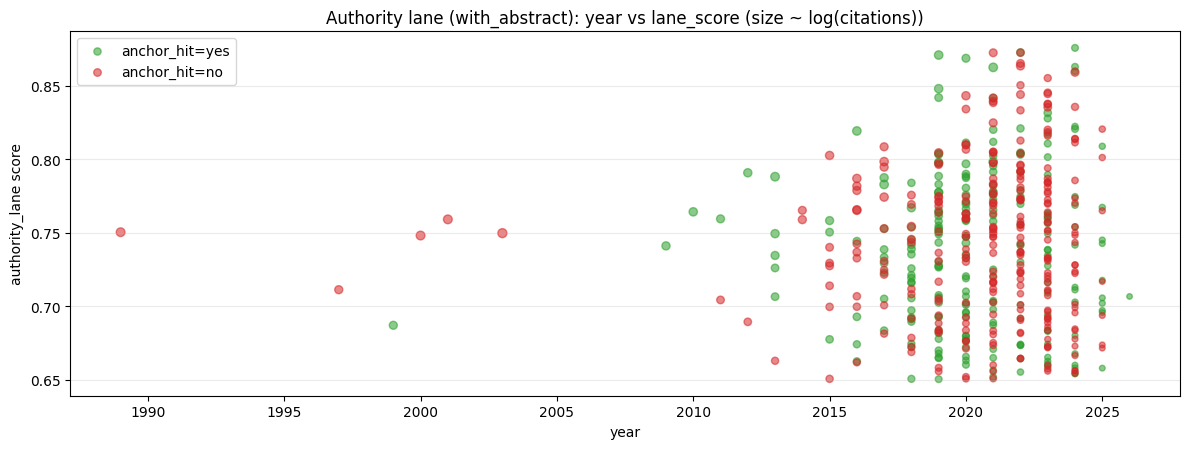

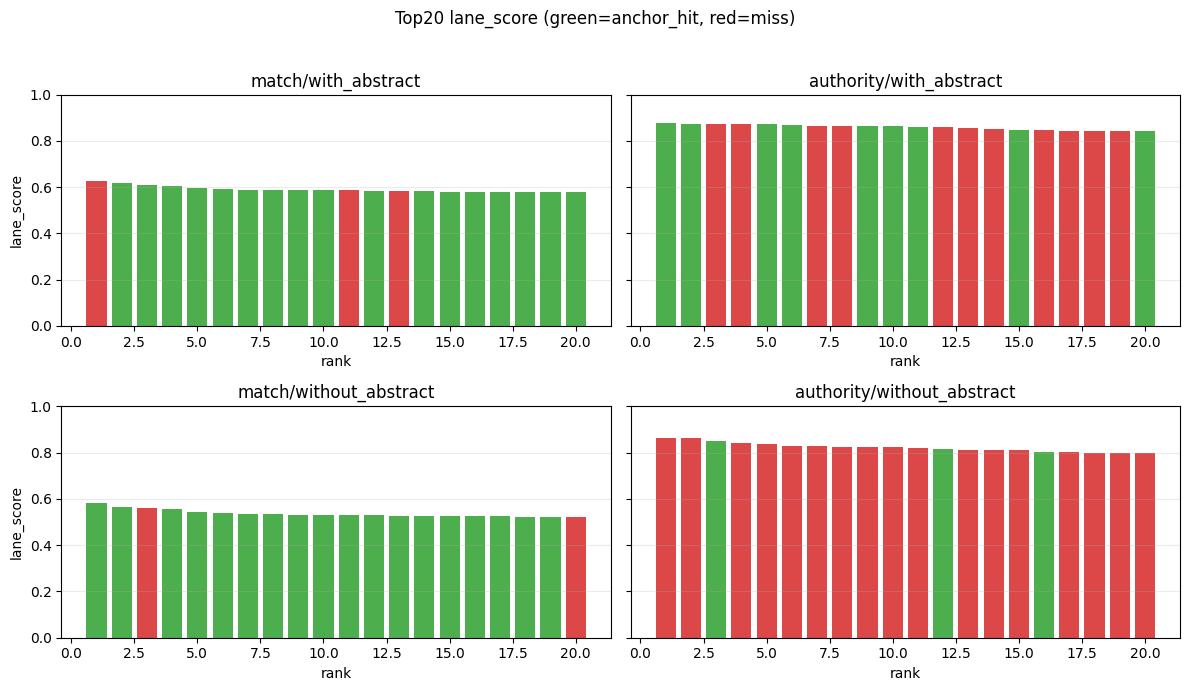

Phase G — Artifacts
scores_final.jsonl   <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\scores_final.jsonl
rankings_stageg.json <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\rankings_stageg.json


In [16]:
# Phase G — Exact scoring formulas and lane fusion
#
# Implements Phase G from TWO_LANE_PIPELINE_IMPLEMENTATION_PLAN_FROM_REPORT.md:
# - G1 match (recomputed from per-facet scores; Stage2 if present else Stage1)
# - G2 authority (recomputed from candidate set; citations/year-normalized)
# - G3 lane fusion (exact)

import json
import math
from bisect import bisect_right
from datetime import date
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Tuple


def _iter_jsonl_dicts(path: Path) -> Iterator[Dict[str, Any]]:
    if not path.exists():
        return
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            if isinstance(obj, dict):
                yield obj


def _has_data(path: Path) -> bool:
    try:
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    return True
    except Exception:
        return False
    return False


def _f(x: Any) -> float:
    try:
        return float(x)
    except Exception:
        return 0.0


def _i(x: Any) -> int:
    try:
        return int(x)
    except Exception:
        return 0


def _clip01(x: float) -> float:
    try:
        x = float(x)
    except Exception:
        return 0.0
    if x < 0.0:
        return 0.0
    if x > 1.0:
        return 1.0
    return x


def _softclip(x: float) -> float:
    try:
        x = float(x)
    except Exception:
        return 0.0
    return x if x > 0.0 else 0.0


def compute_match_g1(
    *,
    facet_scores: List[float],
    facet_weights: List[int],
    t: float,
    m: int,
    w_best: float,
    w_topm: float,
    w_cov: float,
) -> Dict[str, float]:
    # Exact Phase G1 aggregation
    assert len(facet_scores) == len(facet_weights)
    if not facet_scores:
        return {'best': 0.0, 'top_m': 0.0, 'cov': 0.0, 'match': 0.0}

    g = [float(w) * float(s) for w, s in zip(facet_weights, facet_scores)]
    best = (max(g) / 5.0) if g else 0.0

    idxs = sorted(range(len(g)), key=lambda i: g[i], reverse=True)[: max(1, int(m))]
    num = sum(g[i] for i in idxs)
    den = sum(float(facet_weights[i]) for i in idxs) or 1.0
    top_m = num / den

    wsum = sum(float(w) for w in facet_weights) or 1.0
    cov_num = 0.0
    for w, s in zip(facet_weights, facet_scores):
        cov_num += float(w) * _softclip(float(s) - float(t))
    cov = cov_num / wsum

    match = float(w_best) * best + float(w_topm) * top_m + float(w_cov) * cov
    return {'best': best, 'top_m': top_m, 'cov': cov, 'match': match}


def compute_authority_scores_g2(cands: List[Dict[str, Any]]) -> Dict[str, float]:
    # Exact Phase G2 (practical) implementation
    current_year = int(date.today().year)

    vals: List[float] = []
    cpy_by_id: Dict[str, float] = {}
    for c in cands:
        cid = str(c.get('id') or '')
        citations = int(c.get('citations') or 0)
        year = c.get('year')
        try:
            y = int(year) if year is not None else None
        except Exception:
            y = None
        if not y:
            age_years = 10
        else:
            age_years = max(1, current_year - y + 1)
        cpy = float(citations) / float(age_years)
        cpy_by_id[cid] = cpy
        vals.append(cpy)

    vals_pos = sorted(v for v in vals if v > 0)

    def _percentile(x: float) -> float:
        if x <= 0 or not vals_pos:
            return 0.0
        i = bisect_right(vals_pos, x)
        # prevents 1.0; reduces saturation when many candidates have cpy=0
        return float(i) / float(len(vals_pos) + 1)

    def _recency(y: Optional[int]) -> float:
        if not y:
            return 0.5
        z = (float(y) - float(current_year - 5)) / 2.0
        try:
            return 1.0 / (1.0 + math.exp(-z))
        except Exception:
            return 0.5

    review_terms = [
        'review', 'survey', 'handbook', 'overview', 'introduction',
        'handbuch', 'überblick', 'ueberblick', 'einführung', 'einfuehrung',
    ]

    out: Dict[str, float] = {}
    for c in cands:
        cid = str(c.get('id') or '')
        cpy = cpy_by_id.get(cid, 0.0)
        c_norm = _percentile(cpy)

        year = c.get('year')
        try:
            y = int(year) if year is not None else None
        except Exception:
            y = None
        rec = _recency(y)

        bonus = 0.0
        title = str(c.get('title') or '').casefold()
        if any(t in title for t in review_terms):
            bonus += 0.05
        if c.get('venue_is_core') is True:
            bonus += 0.03

        auth = _clip01(0.85 * float(c_norm) + 0.15 * float(rec) + float(bonus))
        out[cid] = auth

    return out


print_section('Phase G — Lane fusion (final scores)')

facet_index_path = run_ctx.run_dir / 'facets_index.json'
if not facet_index_path.exists():
    raise RuntimeError(f'Missing {facet_index_path}. Run Phase F first.')

facet_index = read_json(facet_index_path)
facet_ids = list((facet_index.get('facet_ids') or []))
facet_rows = list((facet_index.get('facets') or []))
weight_by_fid: Dict[str, int] = {}
for fr in facet_rows:
    fid = str(fr.get('facet_id') or '').strip()
    if not fid:
        continue
    try:
        weight_by_fid[fid] = int(fr.get('importance_weight') or 1)
    except Exception:
        weight_by_fid[fid] = 1
facet_weights = [int(weight_by_fid.get(str(fid), 1)) for fid in facet_ids]
if len(facet_weights) != len(facet_ids):
    facet_weights = (facet_weights + [1] * len(facet_ids))[: len(facet_ids)]

m = int(getattr(cfg, 'match_m', 3))
w_best = float(getattr(cfg, 'match_weight_best', 0.55))
w_topm = float(getattr(cfg, 'match_weight_top_m', 0.25))
w_cov = float(getattr(cfg, 'match_weight_cov', 0.20))
t_abs = float(getattr(cfg, 'scoring_t', 0.30))
t_noabs = float(getattr(cfg, 'scoring_t_noabs', 0.35))

scores_stage1_path = run_ctx.run_dir / 'scores_stage1.jsonl'
scores_stage2_path = run_ctx.run_dir / 'scores_stage2.jsonl'
shortlists_path = run_ctx.run_dir / 'shortlists_stage1.json'

if not scores_stage1_path.exists():
    raise RuntimeError(f'Missing {scores_stage1_path}. Run Phase F first.')
if not shortlists_path.exists():
    raise RuntimeError(f'Missing {shortlists_path}. Run Phase F first.')

# Candidate pool to join for metadata
candidates_expanded_path = run_ctx.run_dir / 'candidates_expanded.jsonl'
candidates_path = candidates_expanded_path if _has_data(candidates_expanded_path) else run_ctx.artifacts.candidates_normalized_jsonl

print_kv(
    {
        'candidates_file': candidates_path,
        'scores_stage1.jsonl': scores_stage1_path,
        'scores_stage2.jsonl': scores_stage2_path,
        'shortlists.json': shortlists_path,
        'facets': _fmt_int(len(facet_ids)),
        'G1 m': _fmt_int(m),
        'G1 t/t_noabs': f"{t_abs:.2f} / {t_noabs:.2f}",
        'G1 weights': f"{w_best:.2f}/{w_topm:.2f}/{w_cov:.2f}",
    },
    key_width=20,
)

candidates_by_id: Dict[str, Dict[str, Any]] = {}
candidates_list: List[Dict[str, Any]] = []
for c in _iter_jsonl_dicts(candidates_path):
    cid = str(c.get('id') or '').strip()
    if not cid:
        continue
    candidates_by_id[cid] = c
    candidates_list.append(c)

authority_by_id = compute_authority_scores_g2(candidates_list)

stage1_by_id: Dict[str, Dict[str, Any]] = {}
for r in _iter_jsonl_dicts(scores_stage1_path):
    cid = str(r.get('id') or '').strip()
    if not cid:
        continue
    stage1_by_id[cid] = r

stage2_by_id: Dict[str, Dict[str, Any]] = {}
if scores_stage2_path.exists():
    for r in _iter_jsonl_dicts(scores_stage2_path):
        cid = str(r.get('id') or '').strip()
        if not cid:
            continue
        stage2_by_id[cid] = r

shortlists = read_json(shortlists_path)

# Union of ids we actually care about downstream
ids_needed: List[str] = []
seen = set()
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        for cid in (shortlists.get(lane, {}).get(pool, []) or []):
            cid = str(cid)
            if cid and cid not in seen:
                seen.add(cid)
                ids_needed.append(cid)

# Build final score rows
scores_final_by_id: Dict[str, Dict[str, Any]] = {}

missing_candidates = 0
missing_stage1 = 0

for cid in ids_needed:
    c = candidates_by_id.get(cid)
    s1 = stage1_by_id.get(cid)
    s2 = stage2_by_id.get(cid)

    if c is None:
        missing_candidates += 1
        c = {}
    if s1 is None:
        missing_stage1 += 1
        continue

    pool = str((c.get('pool') or s1.get('pool') or '')).strip() or 'unknown'

    # G2: authority (recomputed from candidate set percentiles)
    authority = _f(authority_by_id.get(cid, s1.get('authority')))

    # Choose per-facet scores (Stage 2 if present for with_abstract)
    use_stage2 = bool(s2) and pool == 'with_abstract'
    if use_stage2:
        stage_used = 'stage2'
        facet_scores = list(s2.get('facet_scores_stage2') or [])
        evidence = list(s2.get('evidence_chunks') or [])
    else:
        stage_used = 'stage1'
        facet_scores = list(s1.get('facet_scores_stage1') or [])
        evidence = []

    facet_scores = [float(x) if x is not None else 0.0 for x in facet_scores]
    if len(facet_scores) != len(facet_weights):
        if len(facet_scores) > len(facet_weights):
            facet_scores = facet_scores[: len(facet_weights)]
        else:
            facet_scores = facet_scores + [0.0] * (len(facet_weights) - len(facet_scores))

    # G1: exact match aggregation
    t = float(t_noabs if pool == 'without_abstract' else t_abs)
    parts = compute_match_g1(
        facet_scores=facet_scores,
        facet_weights=facet_weights,
        t=t,
        m=m,
        w_best=w_best,
        w_topm=w_topm,
        w_cov=w_cov,
    )
    match = float(parts['match'])
    best = float(parts['best'])
    top_m = float(parts['top_m'])
    cov = float(parts['cov'])

    match_lane = 0.80 * match + 0.20 * authority
    authority_lane = 0.80 * authority + 0.20 * match

    # Minimal join metadata (keep JSONL compact)
    title = str(c.get('title') or '')
    doi = str(c.get('doi') or '')
    year = c.get('year') if c.get('year') is not None else s1.get('year')
    citations = _i(c.get('citations') if c.get('citations') is not None else s1.get('citations'))

    scores_final_by_id[cid] = {
        'id': cid,
        'pool': pool,
        'title': title,
        'doi': doi or None,
        'year': year,
        'citations': citations,
        'venue': c.get('venue'),
        'url': c.get('url'),
        'provider_ids': c.get('provider_ids') or {},
        'scores': {
            'match': match,
            'authority': authority,
            'match_lane': match_lane,
            'authority_lane': authority_lane,
            'best': best,
            'top_m': top_m,
            'cov': cov,
        },
        'facet_scores': {
            'stage': stage_used,
            'scores': facet_scores,
        },
        'evidence_chunks': evidence,
    }


# Write scores_final.jsonl
scores_final_path = run_ctx.run_dir / 'scores_final.jsonl'
ensure_dir(scores_final_path.parent)
tmp = scores_final_path.with_suffix(scores_final_path.suffix + '.tmp')
with tmp.open('w', encoding='utf-8') as f:
    for cid in sorted(scores_final_by_id.keys()):
        f.write(json.dumps(scores_final_by_id[cid], ensure_ascii=False, default=_json_default) + '\n')
tmp.replace(scores_final_path)

# Build ranked lists per lane/pool (based on recomputed lane fusion)
rankings: Dict[str, Dict[str, List[str]]] = {
    'match': {'with_abstract': [], 'without_abstract': []},
    'authority': {'with_abstract': [], 'without_abstract': []},
}

for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = [str(x) for x in (shortlists.get(lane, {}).get(pool, []) or [])]

        def _lane_score(cid: str) -> float:
            r = scores_final_by_id.get(cid) or {}
            s = (r.get('scores') or {})
            return _f(s.get('match_lane' if lane == 'match' else 'authority_lane'))

        ids_sorted = sorted(ids, key=_lane_score, reverse=True)
        rankings[lane][pool] = ids_sorted

rankings_path = run_ctx.run_dir / 'rankings_stageg.json'
write_json(
    rankings_path,
    {
        'run_id': run_ctx.run_id,
        'generated_at_utc': utc_now_iso(),
        'rankings': rankings,
    },
)

# Summary output (diagnostic-first)

# Load plan for anchor checks
try:
    _plan_for_g = plan  # type: ignore
except Exception:
    try:
        _plan_for_g = QueryPlan(**read_json(run_ctx.artifacts.query_plan_json))
    except Exception:
        _plan_for_g = None

anchors_all: List[str] = []
if _plan_for_g is not None:
    try:
        anchors_all = list((_plan_for_g.primary_context_anchors.en or [])) + list((_plan_for_g.primary_context_anchors.de or []))
    except Exception:
        anchors_all = []

try:
    _req_w_min = int(REQUIRED_FACET_WEIGHT_MIN)
except Exception:
    _req_w_min = 4

required_facet_ids = [str(fid) for fid in facet_ids if int(weight_by_fid.get(str(fid), 1)) >= _req_w_min]
fid_to_ix = {str(fid): i for i, fid in enumerate(facet_ids)}

try:
    _topk_warn = float(TOPK_ANCHOR_WARN)
except Exception:
    _topk_warn = 0.70
try:
    _topk_fail = float(TOPK_ANCHOR_FAIL)
except Exception:
    _topk_fail = 0.40

TOPK_FINAL = 20


def _anchor_hit(cid: str) -> bool:
    if not anchors_all:
        return False
    c = candidates_by_id.get(cid) or {}
    text = str(c.get('title') or '') + chr(10) + str(c.get('abstract') or c.get('abstract_text') or '')
    return any_term_in_text(text, anchors_all)


def _cites_per_year(cites: int, year: Any) -> float:
    current_year = int(date.today().year)
    try:
        y = int(year) if year is not None and str(year).strip() else None
    except Exception:
        y = None
    if not y:
        return 0.0
    age_years = max(1, current_year - y + 1)
    return float(cites) / float(age_years)


def _top_facets_str(facet_scores: List[float], k: int = 3) -> str:
    pairs: List[Tuple[str, float]] = []
    n = min(len(facet_scores), len(facet_ids))
    for i in range(n):
        fid = str(facet_ids[i])
        try:
            val = float(facet_scores[i] or 0.0)
        except Exception:
            val = 0.0
        pairs.append((fid, val))
    pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[: int(k)]
    return ', '.join([f"{fid}({val:.2f})" for fid, val in pairs_sorted])


def _missing_required_facets(ids: List[str], pool: str, k: int = 20) -> List[str]:
    if not required_facet_ids:
        return []
    t = float(t_noabs if pool == 'without_abstract' else t_abs)
    counts = {fid: 0 for fid in required_facet_ids}
    for cid in ids[: int(k)]:
        r = scores_final_by_id.get(cid) or {}
        fs = ((r.get('facet_scores') or {}).get('scores') or [])
        for fid in required_facet_ids:
            ix = fid_to_ix.get(fid)
            if ix is None or ix >= len(fs):
                continue
            try:
                v = float(fs[ix] or 0.0)
            except Exception:
                v = 0.0
            if v >= t:
                counts[fid] = int(counts.get(fid, 0)) + 1
    return [fid for fid in required_facet_ids if int(counts.get(fid, 0)) == 0]


# At a glance
stage2_used_total = sum(1 for cid in ids_needed if ((scores_final_by_id.get(cid) or {}).get('facet_scores') or {}).get('stage') == 'stage2')
print_section('Phase G — At a glance')
print_kv(
    {
        'shortlist_unique_ids': _fmt_int(len(ids_needed)),
        'stage2_records': _fmt_int(len(stage2_by_id)),
        'stage2_used_final': _fmt_int(stage2_used_total),
        'missing_candidates': _fmt_int(missing_candidates),
        'missing_stage1_scores': _fmt_int(missing_stage1),
        'required_facets(w>=4)': _fmt_int(len(required_facet_ids)),
        't(abs/noabs)': f"{t_abs:.2f}/{t_noabs:.2f}",
        'scores_final.jsonl': scores_final_path,
        'rankings_stageg.json': rankings_path,
    },
    key_width=22,
)

# Build shortlist summary rows (and compute diagnostics used by QC)
rows_short = []
anchor_rates: Dict[Tuple[str, str], float] = {}
missing_required_by_group: Dict[Tuple[str, str], List[str]] = {}

for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = rankings[lane][pool]
        n = len(ids)
        stage2_n = 0
        for cid in ids:
            fs = (scores_final_by_id.get(cid) or {}).get('facet_scores') or {}
            if fs.get('stage') == 'stage2':
                stage2_n += 1

        scs = [
            _f(((scores_final_by_id.get(cid) or {}).get('scores') or {}).get('match_lane' if lane == 'match' else 'authority_lane'))
            for cid in ids
        ]
        top_score = max(scs) if scs else 0.0
        min_score = min(scs) if scs else 0.0

        topk_n = min(TOPK_FINAL, n)
        hits = sum(1 for cid in ids[: int(TOPK_FINAL)] if _anchor_hit(cid))
        rate = float(hits) / float(max(1, topk_n))
        anchor_rates[(lane, pool)] = rate

        missing_req = _missing_required_facets(ids, pool, k=TOPK_FINAL)
        missing_required_by_group[(lane, pool)] = missing_req

        rows_short.append(
            {
                'lane': lane,
                'pool': pool,
                'kept': _fmt_int(n),
                'stage2': _fmt_int(stage2_n),
                'top_score': f"{top_score:.3f}",
                'min_score': f"{min_score:.3f}",
                'top20_anchor_hit': fmt_pct(hits, topk_n),
                'missing_req': _fmt_int(len(missing_req)),
            }
        )


# QC
qc = []
qc.append(
    qc_row(
        check='missing_candidates',
        status='FAIL' if missing_candidates > 0 else 'OK',
        value=_fmt_int(missing_candidates),
        expected='0',
        why='missing metadata breaks downstream final export and diagnostics',
        fix='rerun Phase E; ensure candidates file matches shortlists ids',
    )
)
qc.append(
    qc_row(
        check='missing_stage1_scores',
        status='FAIL' if missing_stage1 > 0 else 'OK',
        value=_fmt_int(missing_stage1),
        expected='0',
        why='lane fusion requires Stage1 scores for every shortlisted id',
        fix='rerun Phase F; check scores_stage1.jsonl integrity',
    )
)

with_abs_any = any(len(rankings[l]['with_abstract']) > 0 for l in ['match', 'authority'])
qc.append(
    qc_row(
        check='stage2_used(with_abstract)',
        status='WARN' if with_abs_any and stage2_used_total == 0 else 'OK',
        value=_fmt_int(stage2_used_total),
        expected='> 0 when with_abstract exists',
        why='Stage2 improves match quality using abstract evidence; 0 can indicate missing abstracts or disabled Stage2',
        fix='inspect Phase E with_abstract share; inspect Phase F stage2_candidates/stage2_scored',
    )
)

qc.append(
    qc_row(
        check='anchor_terms_loaded',
        status='FAIL' if len(anchors_all) == 0 else 'OK',
        value=_fmt_int(len(anchors_all)),
        expected='> 0',
        why='anchor_hit diagnostics require primary_context_anchors from Phase B',
        fix='rerun Phase B; verify planner output includes primary_context_anchors',
    )
)

qc.append(
    qc_row(
        check='required_facets(w>=4)',
        status='WARN' if len(required_facet_ids) == 0 else 'OK',
        value=_fmt_int(len(required_facet_ids)),
        expected='> 0 (usually)',
        why='required facets drive coverage diagnostics and top-up planning',
        fix='inspect Phase B facet weights; ensure important facets use weight>=4',
    )
)

# Top-k anchor hit QC per lane/pool
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        rate = float(anchor_rates.get((lane, pool), 0.0))
        status = 'OK'
        if rate < _topk_fail:
            status = 'FAIL'
        elif rate < _topk_warn:
            status = 'WARN'
        qc.append(
            qc_row(
                check=f"top{TOPK_FINAL}_anchor_hit({lane}/{pool})",
                status=status,
                value=f"{rate:.2f}",
                expected=f">= {_topk_warn:.2f}",
                why='top results should contain primary context anchors; low rate suggests off-topic scoring',
                fix='inspect Phase B anchors; inspect Phase F/G top results + facet coverage; adjust planner/queries',
            )
        )

# Required facet coverage QC (missing facets in top20)
if required_facet_ids:
    for lane in ['match', 'authority']:
        for pool in ['with_abstract', 'without_abstract']:
            missing = missing_required_by_group.get((lane, pool), [])
            missing_n = len(missing)
            frac = float(missing_n) / float(max(1, len(required_facet_ids)))
            status = 'OK'
            if missing_n > 0:
                status = 'WARN'
            if frac >= 0.50:
                status = 'FAIL'
            qc.append(
                qc_row(
                    check=f"missing_required_facets_top{TOPK_FINAL}({lane}/{pool})",
                    status=status,
                    value=_fmt_int(missing_n),
                    expected='0',
                    why='required facets should appear in top results; missing facets indicate narrow/polluted retrieval or scoring',
                    fix='inspect Phase F coverage diagnostics; adjust query plan / thresholds; consider coverage top-up (Phase H/J)',
                )
            )

# Cov component sanity (match/with_abs top20)
try:
    covs = [
        float(((scores_final_by_id.get(cid) or {}).get('scores') or {}).get('cov') or 0.0)
        for cid in rankings['match']['with_abstract'][: int(TOPK_FINAL)]
    ]
except Exception:
    covs = []
qc.append(
    qc_row(
        check=f"cov_nonzero(match/with_abstract top{TOPK_FINAL})",
        status='WARN' if covs and max(covs) <= 1e-9 else 'OK',
        value=f"{(max(covs) if covs else 0.0):.3f}",
        expected='> 0 (often)',
        why='cov rewards covering multiple facets; always-0 can indicate thresholds too strict or facet score issues',
        fix='inspect facet scores distribution; adjust t/t_noabs or facet scoring; verify facets_index ordering',
    )
)

print_section('Phase G — QC')
print_qc(qc)

# Shortlists table (keep, but enriched)
print_section('Phase G — Shortlists (final ordering)')
print_table(
    rows_short,
    columns=['lane', 'pool', 'kept', 'stage2', 'top_score', 'min_score', 'top20_anchor_hit', 'missing_req'],
    max_rows=10,
    max_col_width=50,
)


def _top_preview(lane: str, pool: str, k: int = 20) -> List[Dict[str, Any]]:
    ids = rankings[lane][pool][: int(k)]
    out: List[Dict[str, Any]] = []
    for cid in ids:
        r = scores_final_by_id.get(cid) or {}
        c = candidates_by_id.get(cid) or {}
        s = (r.get('scores') or {})
        year = r.get('year') if r.get('year') is not None else c.get('year')
        citations = _i(r.get('citations') if r.get('citations') is not None else c.get('citations'))
        fs = ((r.get('facet_scores') or {}).get('scores') or [])
        out.append(
            {
                'score': f"{_f(s.get('match_lane' if lane == 'match' else 'authority_lane')):.3f}",
                'match': f"{_f(s.get('match')):.3f}",
                'auth': f"{_f(s.get('authority')):.3f}",
                'year': year or '',
                'cites': citations,
                'c/yr': f"{_cites_per_year(citations, year):.1f}",
                'stage': (r.get('facet_scores') or {}).get('stage') or '',
                'anchor_hit': 'yes' if _anchor_hit(cid) else 'no',
                'top_facets': _top_facets_str([float(x) if x is not None else 0.0 for x in fs], k=3),
                'title': _truncate(r.get('title') or c.get('title') or '', 90),
                'doi': _truncate(r.get('doi') or c.get('doi') or '', 55),
                'id': _truncate(cid, 55),
            }
        )
    return out


for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        print_section(f"{lane} lane — {pool} (top)")
        print_table(
            _top_preview(lane, pool, k=20),
            columns=['score','match','auth','year','cites','c/yr','stage','anchor_hit','top_facets','title','doi','id'],
            max_rows=20,
            max_col_width=180,
        )

# Score composition table (top20 per lane/pool)
print_section('Phase G — Score composition (top20)')
rows_comp: List[Dict[str, Any]] = []
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = rankings[lane][pool][:20]
        for rank, cid in enumerate(ids, 1):
            r = scores_final_by_id.get(cid) or {}
            s = (r.get('scores') or {})
            lane_score = _f(s.get('match_lane' if lane == 'match' else 'authority_lane'))
            rows_comp.append(
                {
                    'lane': lane,
                    'pool': pool,
                    'rank': _fmt_int(rank),
                    'lane_score': f"{lane_score:.3f}",
                    'match': f"{_f(s.get('match')):.3f}",
                    'auth': f"{_f(s.get('authority')):.3f}",
                    'best': f"{_f(s.get('best')):.3f}",
                    'top_m': f"{_f(s.get('top_m')):.3f}",
                    'cov': f"{_f(s.get('cov')):.3f}",
                    'id': _truncate(cid, 60),
                }
            )

print_table(
    rows_comp,
    columns=['lane','pool','rank','lane_score','match','auth','best','top_m','cov','id'],
    max_rows=80,
    max_col_width=120,
)

# Coverage diagnostics (required facets, top20)
print_section('Phase G — Coverage diagnostics (required facets, top20)')
if not required_facet_ids:
    print('<no required facets>')
else:
    for lane in ['match', 'authority']:
        for pool in ['with_abstract', 'without_abstract']:
            ids = rankings[lane][pool][: int(TOPK_FINAL)]
            topk_n = len(ids)
            t = float(t_noabs if pool == 'without_abstract' else t_abs)
            counts = {fid: 0 for fid in required_facet_ids}
            for cid in ids:
                r = scores_final_by_id.get(cid) or {}
                fs = ((r.get('facet_scores') or {}).get('scores') or [])
                for fid in required_facet_ids:
                    ix = fid_to_ix.get(fid)
                    if ix is None or ix >= len(fs):
                        continue
                    try:
                        v = float(fs[ix] or 0.0)
                    except Exception:
                        v = 0.0
                    if v >= t:
                        counts[fid] = int(counts.get(fid, 0)) + 1

            rows_cov = []
            for fid in required_facet_ids:
                w = int(weight_by_fid.get(fid, 1))
                cn = int(counts.get(fid, 0))
                rows_cov.append({'facet_id': fid, 'weight': _fmt_int(w), 'covered_n': _fmt_int(cn), 'covered_pct': fmt_pct(cn, topk_n)})

            rows_cov = sorted(rows_cov, key=lambda r: (-int(r.get('covered_n') or 0), -int(r.get('weight') or 0), str(r.get('facet_id') or '')))
            missing = [fid for fid in required_facet_ids if int(counts.get(fid, 0)) == 0]

            print()
            print(f"{lane}/{pool} — threshold t={t:.2f} (top{TOPK_FINAL}={topk_n})")
            print_table(rows_cov, columns=['facet_id','weight','covered_n','covered_pct'], max_rows=40, max_col_width=90)
            if missing:
                print(f"Missing required facets: {', '.join(missing[:18])}")

# Anchor hit rates table
print_section('Phase G — Anchor hit rates (top20)')
rows_anchor = []
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = rankings[lane][pool][: int(TOPK_FINAL)]
        topk_n = len(ids)
        hits = sum(1 for cid in ids if _anchor_hit(cid))
        rate = float(hits) / float(max(1, topk_n))
        rows_anchor.append({'lane': lane, 'pool': pool, 'topk': _fmt_int(topk_n), 'anchor_hit_n': _fmt_int(hits), 'anchor_hit_rate': f"{rate:.2f}"})
print_table(rows_anchor, columns=['lane','pool','topk','anchor_hit_n','anchor_hit_rate'], max_rows=10, max_col_width=40)

# Plots
print_section('Phase G — Plots')
try:
    import matplotlib.pyplot as plt
except Exception as e:
    print(f"<matplotlib unavailable: {e}>")
else:
    # Plot 1: Authority lane year vs score scatter (with_abstract)
    ids = list(rankings['authority']['with_abstract'])[:500]
    xs_hit, ys_hit, ss_hit = [], [], []
    xs_miss, ys_miss, ss_miss = [], [], []
    for cid in ids:
        r = scores_final_by_id.get(cid) or {}
        s = (r.get('scores') or {})
        year = r.get('year')
        try:
            y = int(year) if year is not None and str(year).strip() else None
        except Exception:
            y = None
        if not y:
            continue
        score = float(s.get('authority_lane') or 0.0)
        cites = _i(r.get('citations'))
        try:
            size = 10.0 + 10.0 * math.log10(float(cites) + 1.0)
        except Exception:
            size = 10.0

        if _anchor_hit(cid):
            xs_hit.append(y)
            ys_hit.append(score)
            ss_hit.append(size)
        else:
            xs_miss.append(y)
            ys_miss.append(score)
            ss_miss.append(size)

    fig1, ax = plt.subplots(figsize=(12, 4.6))
    if xs_hit:
        ax.scatter(xs_hit, ys_hit, s=ss_hit, alpha=0.55, label='anchor_hit=yes', color='tab:green')
    if xs_miss:
        ax.scatter(xs_miss, ys_miss, s=ss_miss, alpha=0.55, label='anchor_hit=no', color='tab:red')
    ax.set_title('Authority lane (with_abstract): year vs lane_score (size ~ log(citations))')
    ax.set_xlabel('year')
    ax.set_ylabel('authority_lane score')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(loc='best')
    fig1.tight_layout()
    plt.show()

    # Plot 2: Top20 score bars for each lane/pool (green=anchor_hit, red=miss)
    fig2, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)

    def _plot_bars(ax, lane: str, pool: str):
        ids2 = rankings[lane][pool][:20]
        scores = []
        colors = []
        for cid2 in ids2:
            r2 = scores_final_by_id.get(cid2) or {}
            s2 = (r2.get('scores') or {})
            sc = float(s2.get('match_lane' if lane == 'match' else 'authority_lane') or 0.0)
            scores.append(sc)
            colors.append('tab:green' if _anchor_hit(cid2) else 'tab:red')
        xs = list(range(1, len(scores) + 1))
        ax.bar(xs, scores, color=colors, alpha=0.85)
        ax.set_title(f"{lane}/{pool}")
        ax.set_xlabel('rank')
        ax.set_ylim(0, 1.0)
        ax.grid(True, axis='y', alpha=0.25)

    _plot_bars(axes[0][0], 'match', 'with_abstract')
    _plot_bars(axes[0][1], 'authority', 'with_abstract')
    _plot_bars(axes[1][0], 'match', 'without_abstract')
    _plot_bars(axes[1][1], 'authority', 'without_abstract')

    axes[0][0].set_ylabel('lane_score')
    axes[1][0].set_ylabel('lane_score')

    fig2.suptitle('Top20 lane_score (green=anchor_hit, red=miss)')
    fig2.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


print_section('Phase G — Artifacts')
print_kv(
    {
        'scores_final.jsonl': scores_final_path,
        'rankings_stageg.json': rankings_path,
    },
    key_width=20,
)


# Metrics
metrics = load_metrics(run_ctx)
metrics.setdefault('stages', {}).setdefault('phase_g', {})['artifacts'] = {
    'scores_final_jsonl': str(scores_final_path),
    'rankings_json': str(rankings_path),
}
metrics['stages']['phase_g']['counts'] = {
    'shortlist_unique_ids': len(ids_needed),
    'missing_candidates': missing_candidates,
    'missing_stage1_scores': missing_stage1,
    'stage2_available': len(stage2_by_id),
}
save_metrics(run_ctx, metrics)


---
# Phase H — Coverage tags (evidence-based)
---

Phase H — Coverage tags
Phase H — At a glance
T_abs / topN           0.30 / 2
T_noabs / topN         0.35 / 1
records_scored_final   1,644
coverage_tags_total    13,222
avg_tags/record        8.04
avg_tags(with_abs)     10.00
avg_tags(no_abs)       4.16
fallback_excerpt_tags  2,290
empty_excerpt_fallbacks 0
scores_final.jsonl     <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\scores_final.jsonl
coverage_tags.jsonl    <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\coverage_tags.jsonl
Phase H — Preview (top5 per lane/pool)
lane      | pool             | rank | lane_score | year | cites | title                                                                                                                                        | top_tags                                                                                                                            | top_excerpt                                                                                         

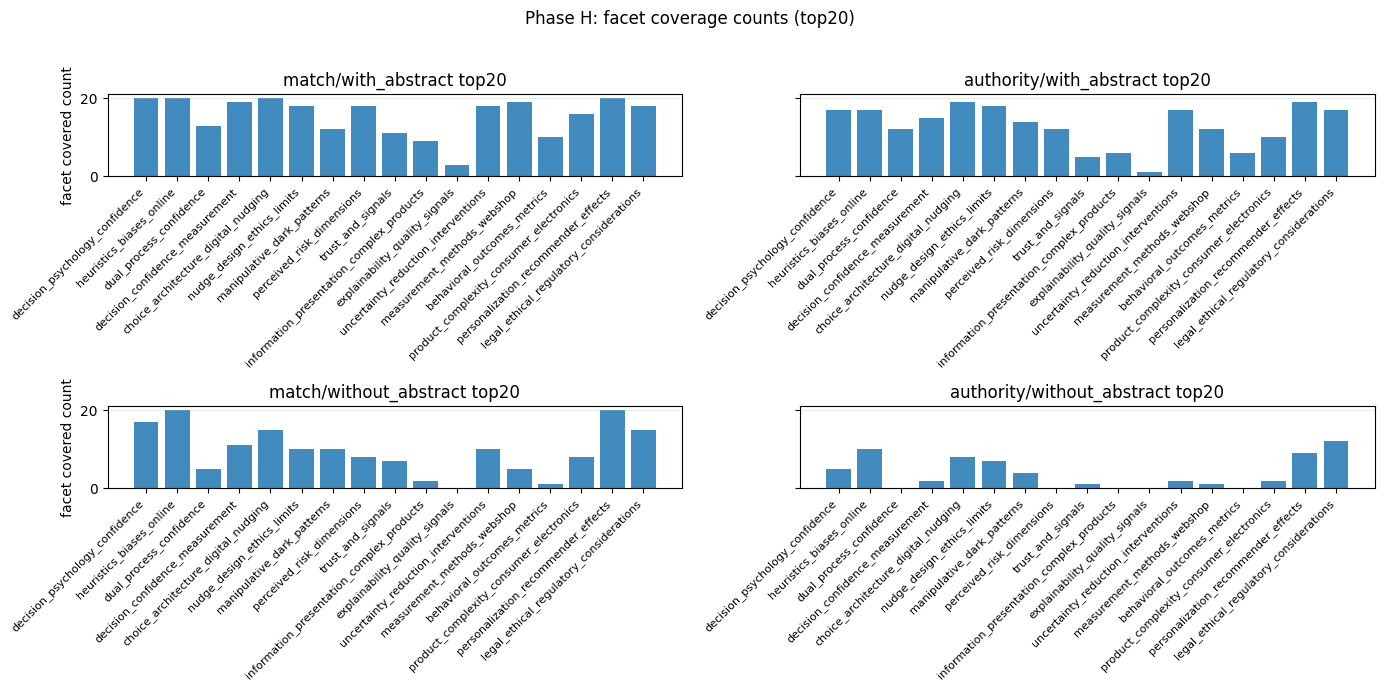

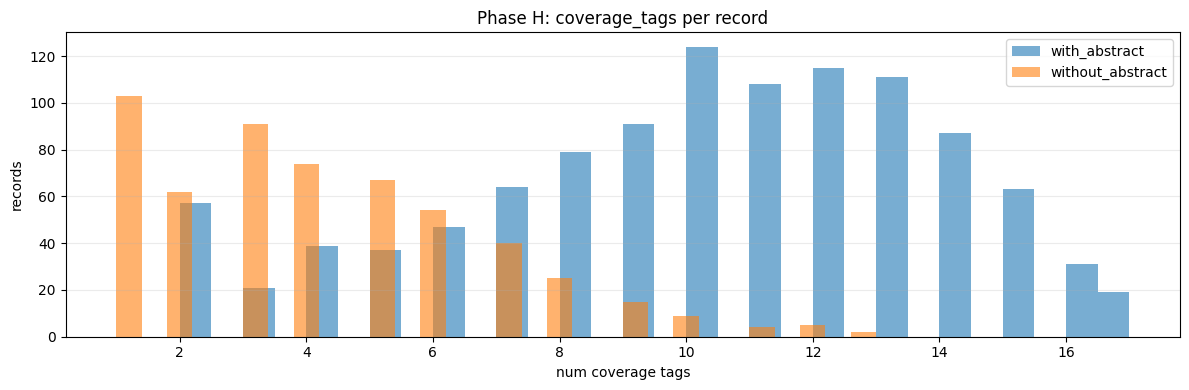

In [17]:
# Phase H — Coverage tags (evidence-based)
#
# Computes per-paper `coverage_tags[]` grounded in embedding evidence:
# - with_abstract: covered if s_i >= t OR top-2 facets
# - without_abstract: covered if s_i >= t_noabs OR top-1 facet
# Excerpts come from Stage2 evidence chunks when available; otherwise abstract/metadata fallback.

import json
from pathlib import Path
from typing import Any, Dict, Iterator, List


def _iter_jsonl_dicts(path: Path) -> Iterator[Dict[str, Any]]:
    if not path.exists():
        return
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            if isinstance(obj, dict):
                yield obj


def _has_data(path: Path) -> bool:
    try:
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    return True
    except Exception:
        return False
    return False


def _f(x: Any) -> float:
    try:
        return float(x)
    except Exception:
        return 0.0


def _pad_list(xs: List[Any], n: int, fill: Any) -> List[Any]:
    xs = list(xs or [])
    if len(xs) > n:
        return xs[:n]
    if len(xs) < n:
        return xs + [fill] * (n - len(xs))
    return xs


print_section('Phase H — Coverage tags')
stage = 'phase_h_coverage_tags'

facet_index_path = run_ctx.run_dir / 'facets_index.json'
scores_final_path = run_ctx.run_dir / 'scores_final.jsonl'
rankings_path = run_ctx.run_dir / 'rankings_stageg.json'

for p in [facet_index_path, scores_final_path, rankings_path]:
    if not p.exists():
        raise RuntimeError(f'Missing {p}. Run Phase F/G first.')

with stage_timer(run_ctx, stage):
    facet_index = read_json(facet_index_path)
    facet_ids = list((facet_index.get('facet_ids') or []))
    facet_rows = list((facet_index.get('facets') or []))
    if not facet_ids:
        raise RuntimeError(f'Empty facet_ids in {facet_index_path}')

    label_by_fid: Dict[str, str] = {}
    for fr in facet_rows:
        fid = str((fr or {}).get('facet_id') or '').strip()
        if not fid:
            continue
        label_by_fid[fid] = str((fr or {}).get('facet_label_en') or (fr or {}).get('facet_label_de') or fid)

    candidates_expanded_path = run_ctx.run_dir / 'candidates_expanded.jsonl'
    candidates_path = candidates_expanded_path if _has_data(candidates_expanded_path) else run_ctx.artifacts.candidates_normalized_jsonl

    candidates_by_id: Dict[str, Dict[str, Any]] = {}
    for c in _iter_jsonl_dicts(candidates_path):
        cid = str(c.get('id') or '').strip()
        if cid:
            candidates_by_id[cid] = c

    scores_final_by_id: Dict[str, Dict[str, Any]] = {}
    for r in _iter_jsonl_dicts(scores_final_path):
        cid = str(r.get('id') or '').strip()
        if cid:
            scores_final_by_id[cid] = r
    if not scores_final_by_id:
        raise RuntimeError(f'No records found in {scores_final_path}')

    try:
        T_ABS = float(getattr(cfg, 'scoring_t', 0.30))
    except Exception:
        T_ABS = 0.30
    try:
        T_NOABS = float(getattr(cfg, 'scoring_t_noabs', 0.35))
    except Exception:
        T_NOABS = 0.35

    TOPN_ABS = 2
    TOPN_NOABS = 1

    records_total = 0
    tags_total = 0
    fallback_excerpt_tags = 0
    empty_excerpt_fallbacks = 0
    records_by_pool: Dict[str, int] = {'with_abstract': 0, 'without_abstract': 0, 'unknown': 0}
    tags_by_pool: Dict[str, int] = {'with_abstract': 0, 'without_abstract': 0, 'unknown': 0}

    def _excerpt_for_tag(cid: str, r: Dict[str, Any], ix: int) -> str:
        global fallback_excerpt_tags, empty_excerpt_fallbacks
        ev = list(r.get('evidence_chunks') or [])
        if ix < len(ev):
            e = ev[ix]
            if isinstance(e, str) and e.strip():
                return _truncate(e.strip(), 240)

        fallback_excerpt_tags += 1
        c = candidates_by_id.get(cid) or {}
        abs_txt = str(c.get('abstract') or '').strip()
        if abs_txt:
            ex = _truncate(abs_txt, 240)
        else:
            title = str(c.get('title') or r.get('title') or '').strip()
            venue = str(c.get('venue') or r.get('venue') or '').strip()
            year = (c.get('year') if c.get('year') is not None else r.get('year'))
            year_s = str(year).strip() if year is not None and str(year).strip() else ''
            meta = ' | '.join([x for x in [title, venue, year_s] if str(x or '').strip()])
            ex = _truncate(meta, 240)

        if not str(ex or '').strip():
            empty_excerpt_fallbacks += 1
            title = str(r.get('title') or c.get('title') or '').strip()
            ex = _truncate(title, 240)
        return str(ex or '').strip()

    for cid, r in scores_final_by_id.items():
        records_total += 1
        pool = str(r.get('pool') or '').strip() or 'unknown'
        if pool not in records_by_pool:
            records_by_pool[pool] = 0
            tags_by_pool[pool] = 0
        records_by_pool[pool] = int(records_by_pool.get(pool, 0) or 0) + 1

        fs_obj = r.get('facet_scores') or {}
        if not isinstance(fs_obj, dict):
            fs_obj = {}
        raw_scores = list((fs_obj.get('scores') or []))
        scores = [_f(x) for x in raw_scores]
        scores = _pad_list(scores, len(facet_ids), 0.0)
        fs_obj['scores'] = scores
        r['facet_scores'] = fs_obj

        ev = _pad_list(list(r.get('evidence_chunks') or []), len(facet_ids), None)
        r['evidence_chunks'] = ev

        if pool == 'with_abstract':
            T = float(T_ABS)
            topN = int(TOPN_ABS)
        elif pool == 'without_abstract':
            T = float(T_NOABS)
            topN = int(TOPN_NOABS)
        else:
            T = float(T_ABS)
            topN = int(TOPN_ABS)

        covered = {i for i, s in enumerate(scores) if float(s) >= float(T)}
        idxs_sorted = sorted(range(len(facet_ids)), key=lambda i: (-float(scores[i]), str(facet_ids[i])))
        for i in idxs_sorted[: max(0, int(topN))]:
            covered.add(i)

        tags: List[Dict[str, Any]] = []
        for i in sorted(covered):
            if i >= len(facet_ids):
                continue
            fid = str(facet_ids[i])
            tags.append(
                {
                    'facet_id': fid,
                    'facet_label_en': str(label_by_fid.get(fid) or fid),
                    'score': float(scores[i]),
                    'excerpt': _excerpt_for_tag(cid, r, i),
                }
            )

        tags_sorted = sorted(tags, key=lambda t: (-float(t.get('score') or 0.0), str(t.get('facet_id') or '')))
        r['coverage_tags'] = tags_sorted

        tags_total += len(tags_sorted)
        tags_by_pool[pool] = int(tags_by_pool.get(pool, 0) or 0) + len(tags_sorted)

    coverage_tags_path = run_ctx.run_dir / 'coverage_tags.jsonl'
    ensure_dir(coverage_tags_path.parent)
    tmp = coverage_tags_path.with_suffix(coverage_tags_path.suffix + '.tmp')
    with tmp.open('w', encoding='utf-8') as f:
        for cid in sorted(scores_final_by_id.keys()):
            rr = scores_final_by_id[cid]
            f.write(
                json.dumps(
                    {
                        'id': cid,
                        'pool': rr.get('pool'),
                        'coverage_tags': (rr.get('coverage_tags') or []),
                    },
                    ensure_ascii=False,
                    default=_json_default,
                )
                + '\n'
            )
    tmp.replace(coverage_tags_path)

    tmp2 = scores_final_path.with_suffix(scores_final_path.suffix + '.tmp')
    with tmp2.open('w', encoding='utf-8') as f:
        for cid in sorted(scores_final_by_id.keys()):
            f.write(json.dumps(scores_final_by_id[cid], ensure_ascii=False, default=_json_default) + '\n')
    tmp2.replace(scores_final_path)

    log_event(
        run_ctx,
        stage=stage,
        event='cache_write',
        provider='coverage_tags',
        path=str(coverage_tags_path),
        records=records_total,
        tags=tags_total,
    )


# At a glance
print_section('Phase H — At a glance')
avg_tags = (float(tags_total) / float(max(1, records_total))) if records_total else 0.0
avg_with = (float(tags_by_pool.get('with_abstract') or 0) / float(max(1, records_by_pool.get('with_abstract') or 0)))
avg_noabs = (float(tags_by_pool.get('without_abstract') or 0) / float(max(1, records_by_pool.get('without_abstract') or 0)))
print_kv(
    {
        'T_abs / topN': f"{T_ABS:.2f} / {TOPN_ABS}",
        'T_noabs / topN': f"{T_NOABS:.2f} / {TOPN_NOABS}",
        'records_scored_final': _fmt_int(records_total),
        'coverage_tags_total': _fmt_int(tags_total),
        'avg_tags/record': f"{avg_tags:.2f}",
        'avg_tags(with_abs)': f"{avg_with:.2f}",
        'avg_tags(no_abs)': f"{avg_noabs:.2f}",
        'fallback_excerpt_tags': _fmt_int(fallback_excerpt_tags),
        'empty_excerpt_fallbacks': _fmt_int(empty_excerpt_fallbacks),
        'scores_final.jsonl': scores_final_path,
        'coverage_tags.jsonl': coverage_tags_path,
    },
    key_width=22,
)


# Preview: top5 per lane/pool
print_section('Phase H — Preview (top5 per lane/pool)')
rankings_obj = read_json(rankings_path)
rankings = rankings_obj.get('rankings') or {}
rows_preview: List[Dict[str, Any]] = []
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = list((rankings.get(lane, {}).get(pool, []) or []))[:5]
        for j, cid in enumerate(ids, start=1):
            r = scores_final_by_id.get(str(cid)) or {}
            s = (r.get('scores') or {})
            lane_score = _f(s.get('match_lane' if lane == 'match' else 'authority_lane'))
            tags = list(r.get('coverage_tags') or [])
            top_tags = ', '.join([f"{t.get('facet_id')}({float(t.get('score') or 0.0):.2f})" for t in tags[:3]])
            top_excerpt = _truncate((tags[0].get('excerpt') if tags else ''), 120)
            rows_preview.append(
                {
                    'lane': lane,
                    'pool': pool,
                    'rank': _fmt_int(j),
                    'lane_score': f"{lane_score:.3f}",
                    'year': r.get('year'),
                    'cites': _fmt_int(r.get('citations') or 0),
                    'title': r.get('title') or '',
                    'top_tags': top_tags,
                    'top_excerpt': top_excerpt,
                }
            )
print_table(
    rows_preview,
    columns=['lane','pool','rank','lane_score','year','cites','title','top_tags','top_excerpt'],
    max_rows=40,
    max_col_width=140,
)


# Facet coverage frequency (top20)
print_section('Phase H — Facet coverage frequency (top20)')
cols = {
    ('match', 'with_abstract'): 'count_match_with',
    ('match', 'without_abstract'): 'count_match_noabs',
    ('authority', 'with_abstract'): 'count_auth_with',
    ('authority', 'without_abstract'): 'count_auth_noabs',
}
counts_by_fid: Dict[str, Dict[str, int]] = {fid: {v: 0 for v in cols.values()} for fid in facet_ids}
for (lane, pool), col in cols.items():
    ids = list((rankings.get(lane, {}).get(pool, []) or []))[:20]
    for cid in ids:
        r = scores_final_by_id.get(str(cid)) or {}
        tags = list(r.get('coverage_tags') or [])
        for t in tags:
            fid = str(t.get('facet_id') or '')
            if fid in counts_by_fid:
                counts_by_fid[fid][col] = int(counts_by_fid[fid].get(col, 0) or 0) + 1

rows_cov: List[Dict[str, Any]] = []
for fid in facet_ids:
    row = {'facet_id': fid, 'label_en': str(label_by_fid.get(fid) or fid)}
    row.update(counts_by_fid.get(fid) or {})
    rows_cov.append(row)

def _row_total(r: Dict[str, Any]) -> int:
    return int(r.get('count_match_with') or 0) + int(r.get('count_match_noabs') or 0) + int(r.get('count_auth_with') or 0) + int(r.get('count_auth_noabs') or 0)

rows_cov = sorted(rows_cov, key=_row_total, reverse=True)
print_table(
    rows_cov,
    columns=['facet_id','label_en','count_match_with','count_match_noabs','count_auth_with','count_auth_noabs'],
    max_rows=50,
    max_col_width=70,
)


# Plots
print_section('Phase H — Plots')
try:
    import matplotlib.pyplot as plt
except Exception as e:
    print(f"<matplotlib unavailable: {e}>")
else:
    # Plot A: facet coverage counts in top20 for each lane/pool
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)
    combos = [
        ('match', 'with_abstract', axes[0][0]),
        ('authority', 'with_abstract', axes[0][1]),
        ('match', 'without_abstract', axes[1][0]),
        ('authority', 'without_abstract', axes[1][1]),
    ]
    for lane, pool, ax in combos:
        col = cols[(lane, pool)]
        ys = [int(counts_by_fid.get(fid, {}).get(col, 0) or 0) for fid in facet_ids]
        xs = list(range(len(facet_ids)))
        ax.bar(xs, ys, alpha=0.85)
        ax.set_title(f"{lane}/{pool} top20")
        ax.set_xticks(xs)
        ax.set_xticklabels([str(fid) for fid in facet_ids], rotation=45, ha='right', fontsize=8)
        ax.grid(True, axis='y', alpha=0.25)
    axes[0][0].set_ylabel('facet covered count')
    axes[1][0].set_ylabel('facet covered count')
    fig.suptitle('Phase H: facet coverage counts (top20)')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Plot B: histogram of tag counts per record
    lens_with = [len((r.get('coverage_tags') or [])) for r in scores_final_by_id.values() if str(r.get('pool') or '') == 'with_abstract']
    lens_noabs = [len((r.get('coverage_tags') or [])) for r in scores_final_by_id.values() if str(r.get('pool') or '') == 'without_abstract']
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    if lens_with:
        ax2.hist(lens_with, bins=30, alpha=0.6, label='with_abstract')
    if lens_noabs:
        ax2.hist(lens_noabs, bins=30, alpha=0.6, label='without_abstract')
    ax2.set_title('Phase H: coverage_tags per record')
    ax2.set_xlabel('num coverage tags')
    ax2.set_ylabel('records')
    ax2.grid(True, axis='y', alpha=0.25)
    ax2.legend(loc='best')
    fig2.tight_layout()
    plt.show()


# Metrics
metrics = load_metrics(run_ctx)
metrics.setdefault('stages', {}).setdefault(stage, {})['counts'] = {
    'records_scored_final': int(records_total),
    'coverage_tags_total': int(tags_total),
    'records_by_pool': records_by_pool,
    'tags_by_pool': tags_by_pool,
    'fallback_excerpt_tags': int(fallback_excerpt_tags),
    'empty_excerpt_fallbacks': int(empty_excerpt_fallbacks),
    'scores_final_jsonl': str(scores_final_path),
    'coverage_tags_jsonl': str(coverage_tags_path),
}
save_metrics(run_ctx, metrics)


---
# Phase I — LLM reranking (pointwise; async; top‑K only)
---

In [18]:
# Phase I — LLM reranking (pointwise; async; top‑K only)

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import json
import os
import random
import statistics
import time


print_section('Phase I — Rerank (LLM)')
stage = 'phase_i_rerank'

facet_index_path = run_ctx.run_dir / 'facets_index.json'
scores_final_path = run_ctx.run_dir / 'scores_final.jsonl'
rankings_g_path = run_ctx.run_dir / 'rankings_stageg.json'

if not facet_index_path.exists():
    raise RuntimeError(f'Missing {facet_index_path}. Run Phase F first.')
if not scores_final_path.exists():
    raise RuntimeError(f'Missing {scores_final_path}. Run Phase G first.')
if not rankings_g_path.exists():
    raise RuntimeError(f'Missing {rankings_g_path}. Run Phase G first.')

api_key = (getattr(cfg, 'openai_api_key', None) or os.environ.get('OPENAI_API_KEY') or '').strip()
if not api_key:
    raise RuntimeError('OPENAI_API_KEY missing (cfg.openai_api_key or env var).')

MODEL_RERANK = 'gpt-5-nano'
K = int(getattr(cfg, 'rerank_top_k_pre', 40) or 40)
CONCURRENCY = int(getattr(cfg, 'rerank_concurrency', 20) or 20)
RETRIES = 3

rankings_i_path = run_ctx.run_dir / 'rankings_stagei.json'
rerank_results_path = Path(run_ctx.artifacts.rerank_results_jsonl)
cache_dir = ensure_dir(run_ctx.run_dir / 'cache' / 'rerank')


def _cache_path(cid: str, lane: str, pool: str) -> Path:
    fn = stable_hash('rerank', run_ctx.run_id, lane, pool, cid, length=24) + '.json'
    return cache_dir / fn


def _write_jsonl_atomic(path: Path, rows: List[Dict[str, Any]]) -> None:
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + '.tmp')
    with tmp.open('w', encoding='utf-8') as f:
        for obj in rows:
            f.write(json.dumps(obj, ensure_ascii=False, default=_json_default) + '\n')
    tmp.replace(path)


def _coerce_str_list(x: Any) -> List[str]:
    if not isinstance(x, list):
        return []
    out: List[str] = []
    for v in x:
        s = str(v or '').strip()
        if s:
            out.append(s)
    return out


def _truncate_i(text: Any, max_len: int = 240) -> str:
    t = str(text or '').strip()
    if len(t) <= max_len:
        return t
    return t[: max(0, max_len - 1)].rstrip() + '…'


with stage_timer(run_ctx, stage):
    facet_index = read_json(facet_index_path)
    facet_ids = [str(x) for x in (facet_index.get('facet_ids') or [])]
    facets = list((facet_index.get('facets') or []))
    label_by_fid = {
        str(f.get('facet_id')): str(f.get('facet_label_en') or f.get('facet_label_de') or f.get('facet_id'))
        for f in facets
        if isinstance(f, dict) and f.get('facet_id')
    }
    weight_by_fid = {
        str(f.get('facet_id')): int(f.get('importance_weight') or 0)
        for f in facets
        if isinstance(f, dict) and f.get('facet_id')
    }

    required_facet_rows = []
    for fid in facet_ids:
        w = int(weight_by_fid.get(fid) or 0)
        if w >= 4:
            required_facet_rows.append({'facet_id': fid, 'label_en': label_by_fid.get(fid, fid), 'weight': w})

    # Load candidates (fallback excerpts / metadata)
    candidates_expanded_path = run_ctx.run_dir / 'candidates_expanded.jsonl'
    candidates_path = candidates_expanded_path if _has_data(candidates_expanded_path) else run_ctx.artifacts.candidates_normalized_jsonl
    candidates_path = Path(candidates_path)
    candidates_by_id: Dict[str, Dict[str, Any]] = {}
    if candidates_path.exists():
        for c in _iter_jsonl_dicts(candidates_path):
            cid = str(c.get('id') or '').strip()
            if cid:
                candidates_by_id[cid] = c

    # Load scores_final
    scores_by_id: Dict[str, Dict[str, Any]] = {}
    for r in _iter_jsonl_dicts(scores_final_path):
        cid = str(r.get('id') or '').strip()
        if cid:
            scores_by_id[cid] = r
    if not scores_by_id:
        raise RuntimeError(f'No records in {scores_final_path}')

    # Ensure in-memory coverage_tags exist (Phase H preferred; compute fallback if missing)
    T_ABS = float(getattr(cfg, 'scoring_t', 0.30) or 0.30)
    T_NOABS = float(getattr(cfg, 'scoring_t_noabs', 0.35) or 0.35)

    def _compute_coverage_tags_fallback(r: Dict[str, Any]) -> List[Dict[str, Any]]:
        pool = str(r.get('pool') or '').strip() or 'with_abstract'
        topN = 2 if pool == 'with_abstract' else 1
        T = T_ABS if pool == 'with_abstract' else T_NOABS

        sc = (r.get('facet_scores') or {}).get('scores')
        scores = list(sc) if isinstance(sc, list) else []
        if len(scores) < len(facet_ids):
            scores = scores + [0.0] * (len(facet_ids) - len(scores))
        if len(scores) > len(facet_ids):
            scores = scores[: len(facet_ids)]

        ev = r.get('evidence_chunks')
        evidence = list(ev) if isinstance(ev, list) else []
        if len(evidence) < len(facet_ids):
            evidence = evidence + [None] * (len(facet_ids) - len(evidence))
        if len(evidence) > len(facet_ids):
            evidence = evidence[: len(facet_ids)]

        # top indices
        idx_sorted = sorted(range(len(scores)), key=lambda i: float(scores[i] or 0.0), reverse=True)
        top_idxs = set(idx_sorted[:topN])
        covered = {i for i, s in enumerate(scores) if float(s or 0.0) >= T}.union(top_idxs)

        tags: List[Dict[str, Any]] = []
        cid = str(r.get('id') or '').strip()
        c = candidates_by_id.get(cid) or {}
        title = str(c.get('title') or r.get('title') or '').strip()
        venue = str(c.get('venue') or r.get('venue') or '').strip()
        year = c.get('year') if c.get('year') is not None else r.get('year')
        abstract = str(c.get('abstract') or '').strip()

        for i in covered:
            fid = facet_ids[i]
            excerpt = None
            if i < len(evidence) and isinstance(evidence[i], str) and evidence[i].strip():
                excerpt = evidence[i]
            if not excerpt:
                if abstract:
                    excerpt = abstract
                else:
                    excerpt = f"{title} | {venue} | {year or ''}".strip(' |')
            excerpt = _truncate_i(excerpt, 240)
            if not excerpt:
                excerpt = _truncate_i(title, 240)
            tags.append(
                {
                    'facet_id': fid,
                    'facet_label_en': label_by_fid.get(fid, fid),
                    'score': float(scores[i] or 0.0),
                    'excerpt': excerpt,
                }
            )

        tags.sort(key=lambda t: (-float(t.get('score') or 0.0), str(t.get('facet_id') or '')))
        return tags

    for _cid, _r in scores_by_id.items():
        if not isinstance(_r.get('coverage_tags'), list):
            _r['coverage_tags'] = _compute_coverage_tags_fallback(_r)
        elif len(_r.get('coverage_tags') or []) == 0:
            _r['coverage_tags'] = _compute_coverage_tags_fallback(_r)

    rankings_g = read_json(rankings_g_path)
    rankings = rankings_g.get('rankings') or {}

    tasks: List[Tuple[str, str, str]] = []
    for lane in ['match', 'authority']:
        for pool in ['with_abstract', 'without_abstract']:
            ids = list((((rankings.get(lane) or {}).get(pool)) or []))
            for cid in ids[:K]:
                cids = str(cid or '').strip()
                if cids:
                    tasks.append((cids, lane, pool))

    if not tasks:
        raise RuntimeError('No rerank tasks found. rankings_stageg.json appears empty.')

    # Schema: note OpenAI JSON-schema constraints (uniqueItems is NOT permitted).
    RERANK_JSON_SCHEMA: Dict[str, Any] = {
        'type': 'object',
        'additionalProperties': False,
        'required': ['llm_score_0_100', 'covered_facets', 'rationale', 'insufficient_info'],
        'properties': {
            'llm_score_0_100': {'type': 'integer', 'minimum': 0, 'maximum': 100},
            'covered_facets': {
                'type': 'array',
                'items': {'type': 'string', 'enum': facet_ids},
                'maxItems': 12,
            },
            'rationale': {'type': 'string', 'maxLength': 800},
            'insufficient_info': {'type': 'boolean'},
        },
    }

    SYSTEM_PROMPT = '''You are reranking scientific sources for a chapter in an academic paper.
You MUST only use the provided evidence excerpts (coverage_tags) and candidate metadata.
Do NOT infer content that is not supported by the excerpts/metadata.
If evidence is insufficient, set insufficient_info=true and keep the score conservative.

Without-abstract honesty rule:
- If pool=="without_abstract", set insufficient_info=true unless the metadata/excerpts clearly support MULTIPLE required facets.

Output ONLY valid JSON matching the provided schema. No Markdown. No extra keys.'''

    def _lane_guidance(lane: str) -> str:
        if lane == 'authority':
            return (
                'authority lane: allow broader/foundational works, but they must still be relevant to the chapter. '
                'Reward strong scholarly importance only if relevance is supported by excerpts.'
            )
        return 'match lane: prioritize topical fit + coverage of the required facets; prefer concrete excerpt support.'

    def _build_user_prompt(cid: str, lane: str, pool: str) -> str:
        r = scores_by_id.get(cid) or {}
        c = candidates_by_id.get(cid) or {}

        title = str(c.get('title') or r.get('title') or '').strip()
        year = c.get('year') if c.get('year') is not None else r.get('year')
        venue = str(c.get('venue') or r.get('venue') or '').strip()
        citations = int(c.get('citations') or r.get('citations') or 0)
        url = str(c.get('url') or r.get('url') or '').strip()
        authors = c.get('authors')
        if isinstance(authors, list):
            authors = [str(a.get('name') if isinstance(a, dict) else a or '').strip() for a in authors]
        authors_list = [a for a in (authors or []) if str(a).strip()]
        authors_list = authors_list[:6]

        tags = list((r.get('coverage_tags') or []))
        tags_compact = []
        for t in tags:
            if not isinstance(t, dict):
                continue
            fid = str(t.get('facet_id') or '').strip()
            if not fid:
                continue
            tags_compact.append(
                {
                    'facet_id': fid,
                    'score': float(t.get('score') or 0.0),
                    'excerpt': _truncate_i(t.get('excerpt') or '', 240),
                }
            )
        tags_compact.sort(key=lambda x: -float(x.get('score') or 0.0))

        required_facets_json = json.dumps(required_facet_rows, ensure_ascii=False)
        tags_json = json.dumps(tags_compact, ensure_ascii=False)

        abstract_present = bool(str(c.get('abstract') or '').strip())

        return (
            'CHAPTER_TITLE:\n'
            f'{chapter_title}\n\n'
            'LANE:\n'
            f'{lane}\n\n'
            'POOL:\n'
            f'{pool}\n\n'
            'LANE_GUIDANCE:\n'
            f'{_lane_guidance(lane)}\n\n'
            'FACETS_REQUIRED (weight>=4):\n'
            f'{required_facets_json}\n\n'
            'ALL_FACET_IDS:\n'
            f'{json.dumps(facet_ids, ensure_ascii=False)}\n\n'
            'CANDIDATE_METADATA:\n'
            f"title={title}\nyear={year}\nvenue={venue}\ncitations={citations}\nurl={url}\n"
            f"authors={json.dumps(authors_list, ensure_ascii=False)}\nabstract_present={abstract_present}\n\n"
            'CANDIDATE_EVIDENCE (coverage_tags):\n'
            f'{tags_json}\n\n'
            'INSTRUCTIONS:\n'
            '- Score 0..100 for usefulness for this chapter (higher = better).\n'
            '- covered_facets: choose ONLY facets explicitly supported by the excerpts; keep it short (<=12).\n'
            '- rationale: cite the excerpts/metadata you used; do not invent.\n'
            '- insufficient_info: true if the evidence is too thin to judge confidently.\n'
        )

    def _clean_rerank(obj: Dict[str, Any]) -> Dict[str, Any]:
        score = int(obj.get('llm_score_0_100') or 0)
        score = max(0, min(100, score))
        covered = _coerce_str_list(obj.get('covered_facets'))
        # Enforce enum + uniqueness (schema cannot use uniqueItems)
        seen = set()
        covered2 = []
        for fid in covered:
            if fid not in facet_ids:
                continue
            if fid in seen:
                continue
            seen.add(fid)
            covered2.append(fid)
            if len(covered2) >= 12:
                break
        rationale = _truncate_i(obj.get('rationale') or '', 800)
        insuff = bool(obj.get('insufficient_info'))
        return {
            'llm_score_0_100': int(score),
            'covered_facets': covered2,
            'rationale': str(rationale or ''),
            'insufficient_info': bool(insuff),
        }

    def _should_retry(exc: Exception) -> bool:
        msg = str(exc)
        if isinstance(exc, json.JSONDecodeError):
            return True
        if '429' in msg or 'rate limit' in msg.lower():
            return True
        if 'timeout' in msg.lower() or 'timed out' in msg.lower():
            return True
        if '500' in msg or '502' in msg or '503' in msg or '504' in msg:
            return True
        return False

    def _rerank_one(cid: str, lane: str, pool: str) -> Tuple[Dict[str, Any], Dict[str, Any]]:
        user_prompt = _build_user_prompt(cid, lane, pool)
        last_exc: Optional[Exception] = None
        for attempt in range(RETRIES):
            try:
                obj, meta = openai_json_schema_call(
                    api_key=api_key,
                    model=MODEL_RERANK,
                    system_prompt=SYSTEM_PROMPT,
                    user_prompt=user_prompt,
                    schema_name='rerank_result',
                    schema=RERANK_JSON_SCHEMA,
                    reasoning_effort='medium',
                    max_output_tokens=8000,
                    timeout_s=180.0,
                )
                return _clean_rerank(obj), meta
            except Exception as e:
                last_exc = e
                if attempt + 1 >= RETRIES or not _should_retry(e):
                    raise
                sleep_s = (2.0 ** attempt) + random.uniform(0.0, 0.5)
                time.sleep(sleep_s)
        raise RuntimeError(f'Phase I rerank failed after {RETRIES} attempts: {last_exc}')

    # Load caches first
    cached_rows: List[Dict[str, Any]] = []
    todo: List[Tuple[str, str, str]] = []
    bad_cache = 0

    for cid, lane, pool in tasks:
        cp = _cache_path(cid, lane, pool)
        if cp.exists():
            try:
                obj = read_json(cp)
                rerank = obj.get('rerank') or {}
                openai_meta = obj.get('openai') or {}
                rerank = _clean_rerank(rerank) if isinstance(rerank, dict) else None
                if not rerank:
                    raise ValueError('empty rerank')
                cached_rows.append(
                    {
                        'ts': utc_now_iso(),
                        'run_id': run_ctx.run_id,
                        'id': cid,
                        'lane': lane,
                        'pool': pool,
                        'cache_hit': True,
                        'rerank': rerank,
                        'openai': openai_meta,
                    }
                )
                log_event(run_ctx, stage=stage, event='cache_hit', id=cid, lane=lane, pool=pool, path=str(cp))
            except Exception:
                bad_cache += 1
                todo.append((cid, lane, pool))
        else:
            todo.append((cid, lane, pool))

    # Progress bar (one tick per model call)
    try:
        from tqdm.auto import tqdm  # type: ignore
    except Exception:
        tqdm = None

    pbar = None
    if tqdm is not None and len(todo) > 0:
        pbar = tqdm(total=len(todo), desc='Phase I rerank', unit='call')

    new_rows: List[Dict[str, Any]] = []
    failures = 0
    usd_new = 0.0
    tokens_in_new = 0
    tokens_cached_in_new = 0
    tokens_out_new = 0
    latencies: List[float] = []

    def _worker(task: Tuple[str, str, str]) -> Dict[str, Any]:
        cid, lane, pool = task
        rerank, meta = _rerank_one(cid, lane, pool)
        cache_obj = {'id': cid, 'lane': lane, 'pool': pool, 'rerank': rerank, 'openai': meta, 'ts': utc_now_iso()}
        cp = _cache_path(cid, lane, pool)
        write_json(cp, cache_obj)
        log_event(run_ctx, stage=stage, event='cache_write', id=cid, lane=lane, pool=pool, path=str(cp))
        return {
            'ts': utc_now_iso(),
            'run_id': run_ctx.run_id,
            'id': cid,
            'lane': lane,
            'pool': pool,
            'cache_hit': False,
            'rerank': rerank,
            'openai': meta,
        }

    if len(todo) > 0:
        with ThreadPoolExecutor(max_workers=max(1, CONCURRENCY)) as ex:
            futs = {ex.submit(_worker, t): t for t in todo}
            done_i = 0
            t0 = time.time()
            for fut in as_completed(list(futs.keys())):
                done_i += 1
                try:
                    row = fut.result()
                    new_rows.append(row)

                    oa = row.get('openai') or {}
                    usage = oa.get('usage') or {}
                    ce = oa.get('cost_estimate') or {}
                    usd_new += float(ce.get('total_cost_usd') or 0.0)
                    tokens_in_new += int(usage.get('input_tokens') or 0)
                    tokens_cached_in_new += int(usage.get('cached_input_tokens') or 0)
                    tokens_out_new += int(usage.get('output_tokens') or 0)
                    try:
                        latencies.append(float(oa.get('latency_s') or 0.0))
                    except Exception:
                        pass
                except Exception as e:
                    failures += 1
                    task = futs.get(fut)
                    if task is not None:
                        cid, lane, pool = task
                        log_event(run_ctx, stage=stage, event='rerank_failed', id=cid, lane=lane, pool=pool, error=str(e))
                finally:
                    if pbar is not None:
                        # tqdm already shows ETA; we add USD spent so far.
                        pbar.update(1)
                        pbar.set_postfix({'usd_new': f'{usd_new:.3f}', 'fail': failures})
                    else:
                        if done_i == 1 or done_i % 5 == 0 or done_i == len(todo):
                            dt = max(0.001, time.time() - t0)
                            rate = done_i / dt
                            eta_s = int((len(todo) - done_i) / max(rate, 1e-6))
                            print(f'Phase I rerank progress: {done_i}/{len(todo)} calls; usd_new={usd_new:.3f}; failures={failures}; eta~{eta_s}s')

    if pbar is not None:
        pbar.close()

    rows_all = cached_rows + new_rows
    rows_all.sort(key=lambda r: (str(r.get('lane') or ''), str(r.get('pool') or ''), str(r.get('id') or '')))
    _write_jsonl_atomic(rerank_results_path, rows_all)

    # Build rerank index
    rerank_by_key: Dict[Tuple[str, str, str], Dict[str, Any]] = {}
    for row in rows_all:
        cid = str(row.get('id') or '').strip()
        lane = str(row.get('lane') or '').strip()
        pool = str(row.get('pool') or '').strip()
        rr = row.get('rerank')
        if cid and lane and pool and isinstance(rr, dict):
            rerank_by_key[(cid, lane, pool)] = rr

    # Construct rankings_stagei.json (two-tier sort)
    rankings_i: Dict[str, Dict[str, List[str]]] = {'match': {}, 'authority': {}}

    def _stageg_lane_score(cid: str, lane: str) -> float:
        r = scores_by_id.get(cid) or {}
        sc = r.get('scores') or {}
        return float(sc.get('match_lane' if lane == 'match' else 'authority_lane') or 0.0)

    for lane in ['match', 'authority']:
        for pool in ['with_abstract', 'without_abstract']:
            ids_g = list((((rankings.get(lane) or {}).get(pool)) or []))
            top = ids_g[:K]
            tail = ids_g[K:]
            top_ok = []
            top_fail = []
            for cid in top:
                cids = str(cid or '').strip()
                rr = rerank_by_key.get((cids, lane, pool))
                if rr is None:
                    top_fail.append(cids)
                else:
                    top_ok.append(cids)

            def _sort_key(cids: str):
                rr = rerank_by_key.get((cids, lane, pool)) or {}
                insuff = bool(rr.get('insufficient_info'))
                llm = int(rr.get('llm_score_0_100') or 0)
                sg = _stageg_lane_score(cids, lane)
                return (insuff, -llm, -sg)

            top_ok_sorted = sorted(top_ok, key=_sort_key)
            rankings_i[lane][pool] = top_ok_sorted + top_fail + [str(x) for x in tail if str(x or '').strip()]

    write_json(rankings_i_path, {'run_id': run_ctx.run_id, 'generated_at_utc': utc_now_iso(), 'rankings': rankings_i})

    # Aggregate usage + cost
    def _usage_cost_from_row(row: Dict[str, Any]) -> Tuple[int, int, int, float, float]:
        oa = row.get('openai') or {}
        usage = oa.get('usage') or {}
        ce = oa.get('cost_estimate') or {}
        tin = int(usage.get('input_tokens') or 0)
        tc = int(usage.get('cached_input_tokens') or 0)
        tout = int(usage.get('output_tokens') or 0)
        cost = float(ce.get('total_cost_usd') or 0.0)
        lat = float(oa.get('latency_s') or 0.0)
        return tin, tc, tout, cost, lat

    tokens_in_total = 0
    tokens_cached_in_total = 0
    tokens_out_total = 0
    cost_total = 0.0
    insuff_by_lp: Dict[str, int] = {}

    for row in rows_all:
        tin, tc, tout, cost, _lat = _usage_cost_from_row(row)
        tokens_in_total += tin
        tokens_cached_in_total += tc
        tokens_out_total += tout
        cost_total += cost
        rr = row.get('rerank') or {}
        if isinstance(rr, dict) and bool(rr.get('insufficient_info')):
            k = f"{row.get('lane')}/{row.get('pool')}"
            insuff_by_lp[k] = int(insuff_by_lp.get(k) or 0) + 1

    # Metrics
    metrics = load_metrics(run_ctx)
    metrics.setdefault('stages', {}).setdefault(stage, {})['counts'] = {
        'model': MODEL_RERANK,
        'model_used': MODEL_RERANK,
        'rerank_top_k_pre': int(K),
        'rerank_concurrency': int(CONCURRENCY),
        'tasks_total': int(len(tasks)),
        'cache_hits': int(len(cached_rows)),
        'bad_cache': int(bad_cache),
        'api_calls': int(len(new_rows)),
        'failures': int(failures),
        'tokens_in_total': int(tokens_in_total),
        'tokens_cached_in_total': int(tokens_cached_in_total),
        'tokens_out_total': int(tokens_out_total),
        'tokens_in_new': int(tokens_in_new),
        'tokens_cached_in_new': int(tokens_cached_in_new),
        'tokens_out_new': int(tokens_out_new),
        'cost_usd_total': float(cost_total),
        'cost_usd_new': float(usd_new),
        # Backward-compat keys for older rollups
        'cost_usd_est_total': float(cost_total),
        'cost_usd_est_new': float(usd_new),
        'rerank_results_jsonl': str(rerank_results_path),
        'rankings_stagei_json': str(rankings_i_path),
        'insufficient_by_lane_pool': insuff_by_lp,
        'latency_s_p50': (None if not latencies else float(statistics.median(latencies))),
    }
    save_metrics(run_ctx, metrics)

    # Console summary
    print_section('Phase I — At a glance')
    print_kv(
        {
            'model': MODEL_RERANK,
            'top_k_per_lane_pool': int(K),
            'concurrency': int(CONCURRENCY),
            'tasks_total': int(len(tasks)),
            'cache_hits': int(len(cached_rows)),
            'api_calls(new_ok)': int(len(new_rows)),
            'failures': int(failures),
            'cost_usd_new(list_price)': round(float(usd_new), 6),
            'cost_usd_total(list_price)': round(float(cost_total), 6),
            'rerank_results.jsonl': str(rerank_results_path),
            'rankings_stagei.json': str(rankings_i_path),
        },
        key_width=26,
    )


Phase I — Rerank (LLM)
Phase I — At a glance
model                      gpt-5-nano
top_k_per_lane_pool        40
concurrency                20
tasks_total                160
cache_hits                 160
api_calls(new_ok)          0
failures                   0
cost_usd_new(list_price)   0.0
cost_usd_total(list_price) 0.179501
rerank_results.jsonl       <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\rerank_results.jsonl
rankings_stagei.json       <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\rankings_stagei.json


---
# Phase K — Final lane construction and output formatting
---

In [18]:
# Phase K — Final lane construction and output formatting
#
# Skipping Phase J (coverage top-up) for now; we emit an empty `coverage_top_up` list.

import json
import subprocess
from datetime import date
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple


def _has_data_k(path: Path) -> bool:
    try:
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    return True
    except Exception:
        return False
    return False


def _git_head(repo_root: Path) -> Optional[str]:
    try:
        return (
            subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=str(repo_root), text=True, stderr=subprocess.DEVNULL)
            .strip()
            or None
        )
    except Exception:
        return None


def _git_dirty(repo_root: Path) -> Optional[bool]:
    try:
        out = subprocess.check_output(['git', 'status', '--porcelain'], cwd=str(repo_root), text=True, stderr=subprocess.DEVNULL)
        return bool(str(out or '').strip())
    except Exception:
        return None


print_section('Phase K — Final output')
stage = 'phase_k_output'

facet_index_path = run_ctx.run_dir / 'facets_index.json'
scores_final_path = run_ctx.run_dir / 'scores_final.jsonl'
rankings_i_path = run_ctx.run_dir / 'rankings_stagei.json'
rankings_g_path = run_ctx.run_dir / 'rankings_stageg.json'

if not facet_index_path.exists():
    raise RuntimeError(f'Missing {facet_index_path}. Run Phase F first.')
if not scores_final_path.exists():
    raise RuntimeError(f'Missing {scores_final_path}. Run Phase G first.')

rankings_path = rankings_i_path if rankings_i_path.exists() else rankings_g_path
if not rankings_path.exists():
    raise RuntimeError(f'Missing {rankings_path}. Run Phase G (Phase I optional) first.')

candidates_expanded_path = run_ctx.run_dir / 'candidates_expanded.jsonl'
candidates_path = candidates_expanded_path if _has_data_k(candidates_expanded_path) else run_ctx.artifacts.candidates_normalized_jsonl
candidates_path = Path(candidates_path)
if not candidates_path.exists():
    raise RuntimeError(f'Missing candidates file: {candidates_path}. Run Phase E/F first.')

rerank_path = run_ctx.artifacts.rerank_results_jsonl

TOP_N = 20
classic_year_max = int(getattr(cfg, 'authority_classic_year_max', 2004) or 2004)
recent_year_window = int(getattr(cfg, 'authority_recent_year_window', 8) or 8)
bucket_quotas = dict(getattr(cfg, 'authority_bucket_quotas', {}) or {})

facet_index = read_json(facet_index_path)
facet_ids = [str(x) for x in (facet_index.get('facet_ids') or [])]
facets = list((facet_index.get('facets') or []))
label_by_fid = {str(f.get('facet_id')): str(f.get('facet_label_en') or f.get('facet_label_de') or f.get('facet_id')) for f in facets if isinstance(f, dict) and f.get('facet_id')}

# Load scores_final.jsonl
scores_by_id: Dict[str, Dict[str, Any]] = {}
for r in _iter_jsonl_dicts(scores_final_path):
    cid = str(r.get('id') or '').strip()
    if cid:
        scores_by_id[cid] = r
if not scores_by_id:
    raise RuntimeError(f'No records found in {scores_final_path}')

# Load candidates join file
candidates_by_id: Dict[str, Dict[str, Any]] = {}
for c in _iter_jsonl_dicts(candidates_path):
    cid = str(c.get('id') or '').strip()
    if cid:
        candidates_by_id[cid] = c

# Load rerank results (optional)
rerank_by_key: Dict[Tuple[str, str, str], Dict[str, Any]] = {}
rerank_loaded = 0
if rerank_path.exists() and _has_data_k(rerank_path):
    for rec in _iter_jsonl_dicts(rerank_path):
        cid = str(rec.get('id') or '').strip()
        lane = str(rec.get('lane') or '').strip()
        pool = str(rec.get('pool') or '').strip()
        rr = rec.get('rerank')
        if cid and lane and pool and isinstance(rr, dict):
            rerank_by_key[(cid, lane, pool)] = rr
            rerank_loaded += 1

# Load rankings
rankings_obj = read_json(rankings_path)
rankings = rankings_obj.get('rankings') or {}


def _pool_of(cid: str) -> str:
    c = candidates_by_id.get(cid) or {}
    p = str(c.get('pool') or '').strip()
    if p:
        return p
    r = scores_by_id.get(cid) or {}
    return str(r.get('pool') or '').strip()


def _year_of(cid: str) -> Optional[int]:
    c = candidates_by_id.get(cid) or {}
    y = c.get('year')
    if y is None:
        y = (scores_by_id.get(cid) or {}).get('year')
    try:
        return int(y) if y is not None and str(y).strip() else None
    except Exception:
        return None


def _bucket_for_year(y: Optional[int]) -> str:
    if not y:
        return 'mid'
    current_year = int(date.today().year)
    recent_min = int(current_year - int(recent_year_window))
    if int(y) <= int(classic_year_max):
        return 'classic'
    if int(y) >= int(recent_min):
        return 'recent'
    return 'mid'


def _select_authority_primary(ids_ranked: List[str]) -> Tuple[List[str], Dict[str, int], Dict[str, int]]:
    ids_ranked = [str(x) for x in (ids_ranked or []) if str(x or '').strip()]
    avail = {'classic': 0, 'recent': 0, 'mid': 0}
    for cid in ids_ranked:
        avail[_bucket_for_year(_year_of(cid))] = int(avail.get(_bucket_for_year(_year_of(cid)), 0)) + 1

    selected: List[str] = []
    selected_set = set()
    picked = {'classic': 0, 'recent': 0, 'mid': 0}

    order = ['classic', 'recent', 'mid']
    for b in order:
        q = int(bucket_quotas.get(b, 0) or 0)
        if q <= 0:
            continue
        for cid in ids_ranked:
            if len(selected) >= TOP_N:
                break
            if cid in selected_set:
                continue
            if _bucket_for_year(_year_of(cid)) != b:
                continue
            selected.append(cid)
            selected_set.add(cid)
            picked[b] = int(picked.get(b, 0)) + 1
            if int(picked.get(b, 0)) >= q:
                break
        if len(selected) >= TOP_N:
            break

    for cid in ids_ranked:
        if len(selected) >= TOP_N:
            break
        if cid in selected_set:
            continue
        selected.append(cid)
        selected_set.add(cid)

    return selected, picked, avail


def _card(cid: str, lane: str, pool: str) -> Dict[str, Any]:
    c = candidates_by_id.get(cid) or {}
    r = scores_by_id.get(cid) or {}

    provider_ids = c.get('provider_ids') or r.get('provider_ids') or {}
    providers = [k for k, vs in (provider_ids or {}).items() if vs]
    provider = None
    if len(providers) == 1:
        provider = providers[0]
    elif len(providers) > 1:
        provider = 'mixed'

    tags_in = list(r.get('coverage_tags') or [])
    tags: List[Dict[str, Any]] = []
    for t in tags_in:
        if not isinstance(t, dict):
            continue
        fid = str(t.get('facet_id') or '').strip()
        if not fid:
            continue
        tags.append(
            {
                'facet_id': fid,
                'facet_label_en': str(t.get('facet_label_en') or label_by_fid.get(fid) or fid),
                'score': float(t.get('score') or 0.0),
                'excerpt': _truncate(str(t.get('excerpt') or '').strip(), 240),
            }
        )
    tags = sorted(tags, key=lambda x: (-float(x.get('score') or 0.0), str(x.get('facet_id') or '')))

    rr = rerank_by_key.get((cid, lane, pool))
    if isinstance(rr, dict):
        rr = {
            'llm_score_0_100': int(rr.get('llm_score_0_100') or 0),
            'covered_facets': list(rr.get('covered_facets') or []),
            'rationale': _truncate(str(rr.get('rationale') or '').strip(), 800),
            'insufficient_info': bool(rr.get('insufficient_info')),
        }
    else:
        rr = None

    abstract = str(c.get('abstract') or '').strip()
    abstract_out = abstract if abstract else None

    citations = int(c.get('citations') or r.get('citations') or 0)
    infl = int(c.get('influential_citations') or 0)

    return {
        'id': cid,
        'doi': c.get('doi') or r.get('doi'),
        'title': c.get('title') or r.get('title') or '',
        'authors': list(c.get('authors') or []),
        'year': c.get('year') if c.get('year') is not None else r.get('year'),
        'venue': c.get('venue') if c.get('venue') is not None else r.get('venue'),
        'url': c.get('url') if c.get('url') is not None else r.get('url'),
        'language': c.get('language') if c.get('language') is not None else r.get('language'),
        'abstract': abstract_out,
        'citations': citations,
        'influential_citations': infl,
        'citation_metrics': {'citations': citations, 'influential_citations': infl},
        'provider': provider,
        'provider_ids': provider_ids,
        'external_ids': c.get('external_ids') or {},
        'sources': list(c.get('sources') or []),
        'pool': pool,
        'scores': r.get('scores') or {},
        'coverage_tags': tags,
        'rerank': rr,
    }


# Build final lists
final_rankings: Dict[str, Dict[str, List[str]]] = {'match': {'with_abstract': [], 'without_abstract': []}, 'authority': {'with_abstract': [], 'without_abstract': []}}
top_cards: Dict[str, Dict[str, List[Dict[str, Any]]]] = {'match': {'with_abstract': [], 'without_abstract': []}, 'authority': {'with_abstract': [], 'without_abstract': []}}
authority_bucket_meta: Dict[str, Dict[str, Dict[str, int]]] = {'with_abstract': {}, 'without_abstract': {}}

for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        ids = [str(x) for x in (rankings.get(lane, {}).get(pool, []) or [])]
        ids = [cid for cid in ids if _pool_of(cid) == pool]
        final_rankings[lane][pool] = ids

        if lane == 'authority':
            primary_ids, picked, avail = _select_authority_primary(ids)
            authority_bucket_meta[pool] = {'picked': picked, 'available': avail}
        else:
            primary_ids = ids[:TOP_N]

        top_cards[lane][pool] = [_card(cid, lane, pool) for cid in primary_ids]


# Assemble output (blueprint-compatible)
git_head = _git_head(run_ctx.repo_root)
git_dirty = _git_dirty(run_ctx.repo_root)
cfg_masked = cfg.masked() if hasattr(cfg, 'masked') else {}
cfg_hash = stable_hash(json.dumps(cfg_masked, ensure_ascii=False, sort_keys=True), length=24) if cfg_masked else None

# Cache costs + key pipeline metrics into output.json for easy inspection later.
run_costs: Dict[str, Any] = {}
try:
    m = load_metrics(run_ctx)
    st = m.get('stages', {}) or {}

    # infer cache hits for the main LLM stages (best-effort)
    cache_last: Dict[str, str] = {}
    cache_ts: Dict[str, str] = {}
    logs_path = Path(run_ctx.artifacts.logs_jsonl)
    if logs_path.exists():
        for rec in _iter_jsonl_dicts(logs_path):
            stg = str(rec.get('stage') or '').strip()
            ev = str(rec.get('event') or '').strip()
            ts = str(rec.get('ts') or '').strip()
            if not stg or not ts:
                continue
            if ev not in {'cache_hit', 'cache_write'}:
                continue
            if stg not in {'phase_b_query_planner', 'phase_c_openalex_query_builder', 'phase_c_s2_query_builder'}:
                continue
            prev = cache_ts.get(stg)
            if (prev is None) or (ts > prev):
                cache_ts[stg] = ts
                cache_last[stg] = ev

    def _cache_status(stage_name: str) -> str:
        ev = cache_last.get(stage_name)
        if ev == 'cache_hit':
            return 'hit'
        if ev == 'cache_write':
            return 'write'
        return ''

    openai_cost_usd_run = 0.0
    openai_cost_usd_artifacts = 0.0
    emb_cost_usd_run = 0.0
    emb_cost_usd_artifacts = 0.0
    tokens_in_run = 0
    tokens_cached_in_run = 0
    tokens_out_run = 0
    tokens_in_artifacts = 0
    tokens_cached_in_artifacts = 0
    tokens_out_artifacts = 0

    # LLM stages with openai meta
    for stage_name in ['phase_b_query_planner', 'phase_c_openalex_query_builder', 'phase_c_s2_query_builder']:
        s = st.get(stage_name) or {}
        oa = s.get('openai') or {}
        usage = oa.get('usage') or {}
        ce = oa.get('cost_estimate') or {}
        cost = float(ce.get('total_cost_usd') or 0.0)
        tin = int(usage.get('input_tokens') or 0)
        tcached = int(usage.get('cached_input_tokens') or 0)
        tout = int(usage.get('output_tokens') or 0)

        openai_cost_usd_artifacts += float(cost)
        tokens_in_artifacts += int(tin)
        tokens_cached_in_artifacts += int(tcached)
        tokens_out_artifacts += int(tout)

        if _cache_status(stage_name) == 'hit':
            continue
        openai_cost_usd_run += float(cost)
        tokens_in_run += int(tin)
        tokens_cached_in_run += int(tcached)
        tokens_out_run += int(tout)

    # Rerank stage (already splits new vs total)
    ir = st.get('phase_i_rerank') or {}
    ic = (ir.get('counts') or {})
    openai_cost_usd_artifacts += float(ic.get('cost_usd_est_total') or 0.0)
    openai_cost_usd_run += float(ic.get('cost_usd_est_new') or 0.0)
    tokens_in_artifacts += int(ic.get('tokens_in_total') or 0)
    tokens_cached_in_artifacts += int(ic.get('tokens_cached_in_total') or 0)
    tokens_out_artifacts += int(ic.get('tokens_out_total') or 0)
    tokens_in_run += int(ic.get('tokens_in_new') or 0)
    tokens_cached_in_run += int(ic.get('tokens_cached_in_new') or 0)
    tokens_out_run += int(ic.get('tokens_out_new') or 0)

    # Embeddings (Phase F)
    pf = st.get('phase_f') or {}
    et = (pf.get('embeddings_total') or {})
    emb_cost = float(et.get('cost_usd_est') or 0.0)
    emb_tok = int(et.get('prompt_tokens') or 0)
    emb_cost_usd_artifacts += float(emb_cost)
    emb_cost_usd_run += float(emb_cost)
    tokens_in_artifacts += int(emb_tok)
    tokens_in_run += int(emb_tok)

    # A few pipeline counts
    de = st.get('phase_d_retrieval') or {}
    ee = st.get('phase_e_candidates') or {}
    ec = (ee.get('counts') or {})
    fc = (pf.get('counts') or {})

    run_costs = {
        'total_cost_usd': float(openai_cost_usd_run) + float(emb_cost_usd_run),
        'openai_cost_usd': float(openai_cost_usd_run),
        'embeddings_cost_usd': float(emb_cost_usd_run),
        'total_cost_usd_artifacts': float(openai_cost_usd_artifacts) + float(emb_cost_usd_artifacts),
        'tokens_in_run': int(tokens_in_run),
        'tokens_cached_in_run': int(tokens_cached_in_run),
        'tokens_out_run': int(tokens_out_run),
        'tokens_in_artifacts': int(tokens_in_artifacts),
        'tokens_cached_in_artifacts': int(tokens_cached_in_artifacts),
        'tokens_out_artifacts': int(tokens_out_artifacts),
        'cache_status': {k: _cache_status(k) for k in ['phase_b_query_planner', 'phase_c_openalex_query_builder', 'phase_c_s2_query_builder']},
        'counts': {
            'openalex_records': int(((de.get('openalex') or {}).get('records') or 0)),
            's2_records': int(((de.get('semanticscholar') or {}).get('records') or 0)),
            'candidates_deduped': int(ec.get('deduped_candidates') or 0),
            'stage2_scored': int(fc.get('stage2_scored') or 0),
        },
        'note': 'costs computed from token usage × local price table; run cost treats cache hits as $0',
    }
except Exception:
    run_costs = {}

output_obj: Dict[str, Any] = {
    'schema_version': 'two_lane_output_v1',
    'run_id': run_ctx.run_id,
    'generated_at_utc': utc_now_iso(),
    'pipeline_version': getattr(cfg, 'pipeline_version', 'two_lane_v1'),
    'chapter_title': chapter_title,
    'chapter_spec_text': chapter_spec_text,
    'git': {'head': git_head, 'dirty': git_dirty},
    'config_hash': cfg_hash,
    'run_costs': run_costs,
    'artifacts': {
        'candidates_jsonl': str(candidates_path),
        'scores_final_jsonl': str(scores_final_path),
        'rerank_results_jsonl': str(rerank_path) if rerank_path.exists() else None,
        'rankings_used_json': str(rankings_path),
        'output_json': str(run_ctx.artifacts.output_json),
    },
    'facets': facets,
    'rankings': final_rankings,
    'top': top_cards,
    'authority_lane': {
        'with_abstract': {'primary_top_20': top_cards['authority']['with_abstract'], 'coverage_top_up': []},
        'without_abstract': {'primary_top_20': top_cards['authority']['without_abstract'], 'coverage_top_up': []},
        'time_stratification': {
            'classic_year_max': int(classic_year_max),
            'recent_year_window': int(recent_year_window),
            'bucket_quotas': bucket_quotas,
            'meta': authority_bucket_meta,
        },
    },
    'match_lane': {
        'with_abstract': {'primary_top_20': top_cards['match']['with_abstract'], 'coverage_top_up': []},
        'without_abstract': {'primary_top_20': top_cards['match']['without_abstract'], 'coverage_top_up': []},
    },
}

with stage_timer(run_ctx, stage):
    write_json(run_ctx.artifacts.output_json, output_obj)
    log_event(run_ctx, stage=stage, event='cache_write', provider='output', path=str(run_ctx.artifacts.output_json), top_n=int(TOP_N), rerank_loaded=int(rerank_loaded), rankings_used=str(rankings_path))


# Console output
print_section('Phase K — At a glance')
print_kv(
    {
        'rankings_used': rankings_path,
        'rerank_rows_loaded': _fmt_int(rerank_loaded),
        'top_n': _fmt_int(TOP_N),
        'authority_classic_year_max': classic_year_max,
        'authority_recent_year_window': recent_year_window,
        'authority_bucket_quotas': bucket_quotas,
        'output.json': run_ctx.artifacts.output_json,
    },
    key_width=28,
)

print_section('Phase K — QC')
qc_rows = []
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        n_rank = int(len(final_rankings.get(lane, {}).get(pool, []) or []))
        n_primary = int(len(top_cards.get(lane, {}).get(pool, []) or []))
        if n_rank <= 0:
            status = 'FAIL'
        elif n_primary >= TOP_N:
            status = 'OK'
        elif n_primary > 0:
            status = 'WARN'
        else:
            status = 'FAIL'
        qc_rows.append(
            qc_row(
                check=f"primary_count({lane}/{pool})",
                status=status,
                value=f"{n_primary}/{TOP_N} (ranking={n_rank})",
                expected=f"{TOP_N} (or as many as available)",
                why='final output should contain a usable top-N list per lane/pool',
                fix='inspect rankings_stage*.json + Phase F pruning (shortlists_stage1.json)',
            )
        )
print_table(qc_rows, columns=['status','check','value','expected','why','fix'], max_rows=10, max_col_width=100)

print_section('Phase K — Authority bucket selection')
rows_b = []
for pool in ['with_abstract', 'without_abstract']:
    meta = authority_bucket_meta.get(pool) or {}
    picked = meta.get('picked') or {}
    avail = meta.get('available') or {}
    for b in ['classic', 'recent', 'mid']:
        rows_b.append(
            {
                'pool': pool,
                'bucket': b,
                'quota': int(bucket_quotas.get(b, 0) or 0),
                'picked': int(picked.get(b, 0) or 0),
                'available_in_ranking': int(avail.get(b, 0) or 0),
            }
        )
print_table(rows_b, columns=['pool', 'bucket', 'quota', 'picked', 'available_in_ranking'], max_rows=20, max_col_width=80)

print_section('Phase K — Preview (top5 per lane/pool)')
rows_prev = []
for lane in ['match', 'authority']:
    for pool in ['with_abstract', 'without_abstract']:
        cards = list(top_cards.get(lane, {}).get(pool, []) or [])[:5]
        for j, card in enumerate(cards, start=1):
            sc = card.get('scores') or {}
            lane_score = float(sc.get('match_lane' if lane == 'match' else 'authority_lane') or 0.0)
            rr = card.get('rerank')
            rows_prev.append(
                {
                    'lane': lane,
                    'pool': pool,
                    'rank': _fmt_int(j),
                    'year': card.get('year'),
                    'cites': _fmt_int(card.get('citations') or 0),
                    'lane_score': f"{lane_score:.3f}",
                    'llm': ('' if not isinstance(rr, dict) else str(rr.get('llm_score_0_100'))),
                    'insuff': ('' if not isinstance(rr, dict) else str(bool(rr.get('insufficient_info'))).lower()),
                    'title': card.get('title') or '',
                }
            )
print_table(rows_prev, columns=['lane', 'pool', 'rank', 'year', 'cites', 'lane_score', 'llm', 'insuff', 'title'], max_rows=40, max_col_width=140)


# Metrics
metrics = load_metrics(run_ctx)
metrics.setdefault('stages', {}).setdefault(stage, {})['counts'] = {
    'rankings_used': str(rankings_path),
    'rerank_rows_loaded': int(rerank_loaded),
    'top_n': int(TOP_N),
    'output_json': str(run_ctx.artifacts.output_json),
}
save_metrics(run_ctx, metrics)


Phase K — Final output
Phase K — At a glance
rankings_used                <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\rankings_stagei.json
rerank_rows_loaded           160
top_n                        20
authority_classic_year_max   2004
authority_recent_year_window 8
authority_bucket_quotas      {'classic': 8, 'mid': 6, 'recent': 6}
output.json                  <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\output.json
Phase K — QC
status | check                                     | value               | expected                     | why                                                           | fix                                                                    
-------+-------------------------------------------+---------------------+------------------------------+---------------------------------------------------------------+------------------------------------------------------------------------
OK     | primary_count(match/with_abstract)   

---
---
# Final report — Top results + pipeline cost summary
---
---

Final report — Summary
Final report — At a glance
run_id                       4af2666be828e5054ccf4d31
chapter_title                Entscheidungspsychologie im Kontext unsicherer Kaufentscheidungen im Webshop-Kontext
pipeline_version             two_lane_v1
top_show                     30
rerank_top_k                 40
ranked_total                 {'match/with_abstract': 600, 'match/without_abstract': 300, 'authority/with_abstract': 600, 'authority/without_abstract': 300}
total_cost_usd (run)         0.4515
openai_cost_usd (run)        0.3572
  rerank_cost_usd (run)      0.1795
embeddings_cost_usd (run)    0.0943
total_cost_usd (artifacts)   0.4515
cache_status (B/C)           {'planner': 'write', 'openalex_builder': 'write', 's2_builder': 'write'}
rankings_used                <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\rankings_stagei.json
scores_final_jsonl           <projektverzeichnis>\sources-v2\runs\4af2666be828e5054ccf4d31\scores_final.jsonl
rerank_results_js

,label,cost_usd_run,cost_usd_artifacts,cache,duration_s,model,info,stage
15,Phase I — Rerank (LLM),0.179501,0.179501,,244.155000,gpt-5-nano,tasks=160 cache_hits=0 api_calls=160 failures=0,phase_i_rerank
6,Phase F — Scoring + embeddings,0.094268,0.094268,,,text-embedding-3-small,"facet:hits=0(l=0 g=0) creates=34 api_calls=1; meta:hits=0(l=0 g=0) creates=64,738 api_calls=253; meta_recs:hits=0(l=0 g=0) creates=1,196 api_calls=5; chunk:hits=0(l=0 g=0) creates=7,602 api_calls=30",phase_f
2,Phase C — OpenAlex query builder (LLM),0.070449,0.070449,write,449.047000,gpt-5-mini-2025-08-07,,phase_c_openalex_query_builder
3,Phase C — S2 query builder (LLM),0.058170,0.058170,write,591.349000,gpt-5-mini-2025-08-07,,phase_c_s2_query_builder
1,Phase B — Query planner (LLM),0.049124,0.049124,write,371.921000,gpt-5-mini-2025-08-07,,phase_b_query_planner
4,Phase D — Retrieval,0.000000,0.000000,,652.709000,,"oa_records=46,537 s2_records=41,392",phase_d_retrieval
9,phase_f_metadata_embeddings,0.000000,0.000000,,387.074000,,,phase_f_metadata_embeddings
11,phase_f_stage1_scoring,0.000000,0.000000,,202.822000,,,phase_f_stage1_scoring
7,phase_f_chunk_embeddings,0.000000,0.000000,,45.551000,,,phase_f_chunk_embeddings
10,phase_f_s2_recommendations,0.000000,0.000000,,28.085000,,,phase_f_s2_recommendations


Final report — Plots


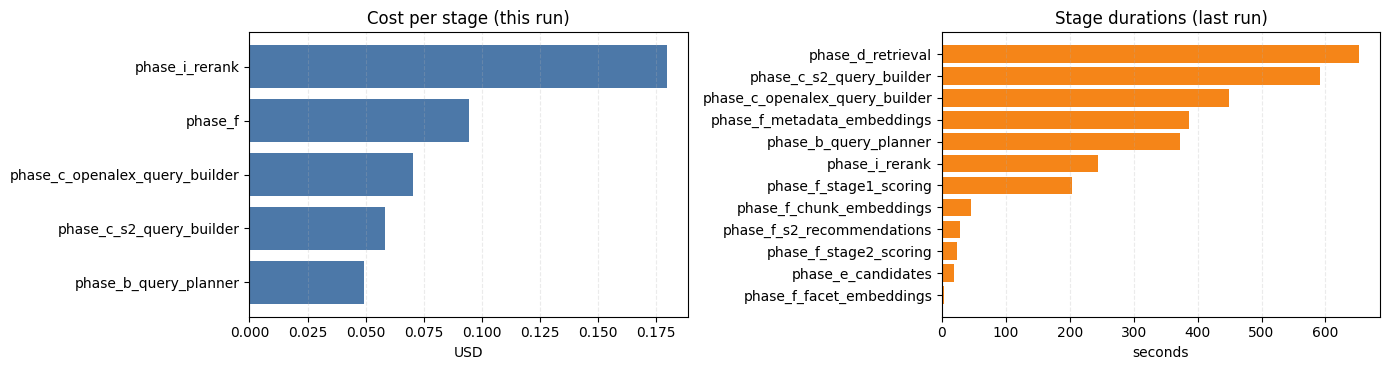

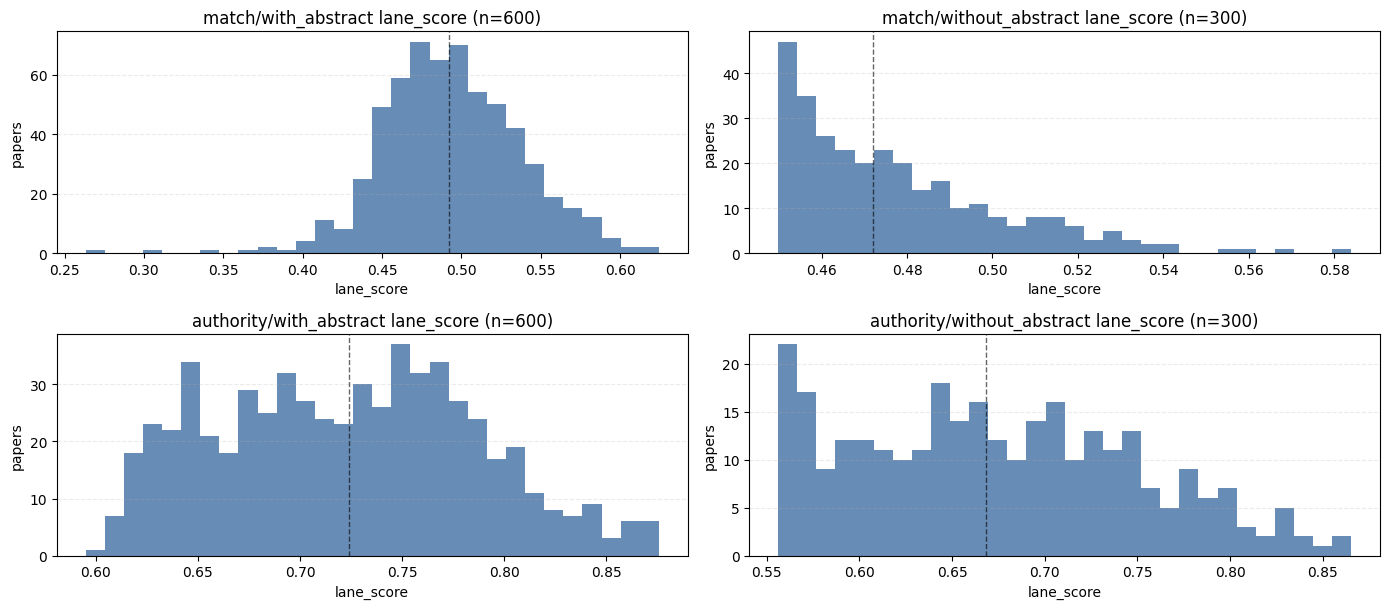

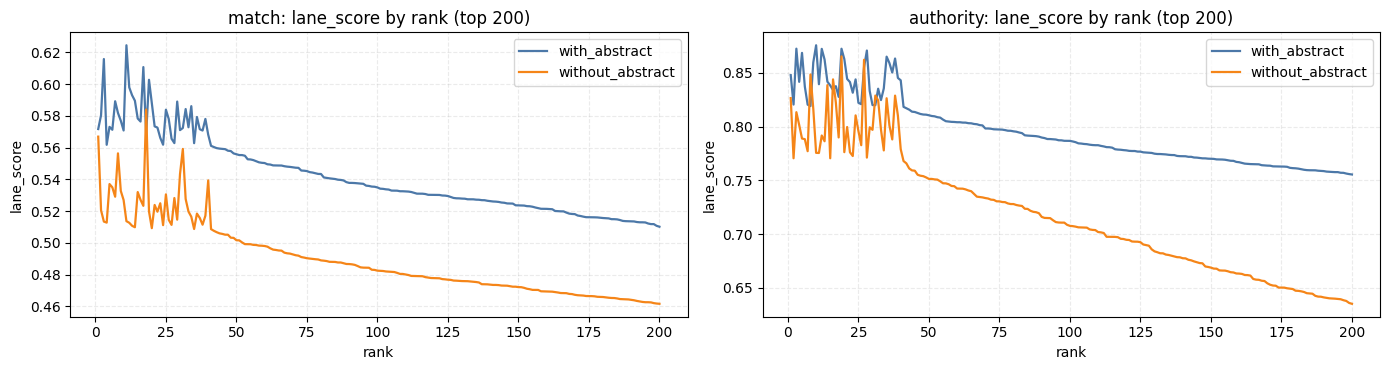

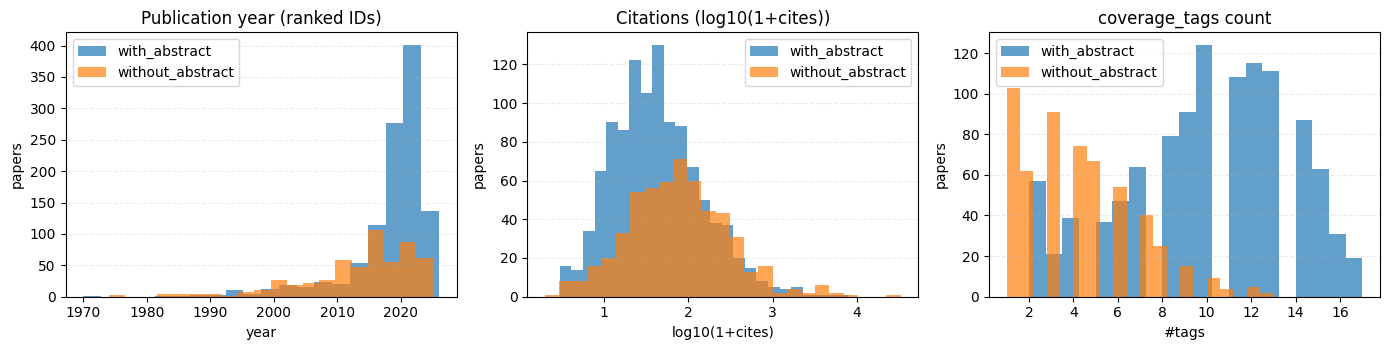

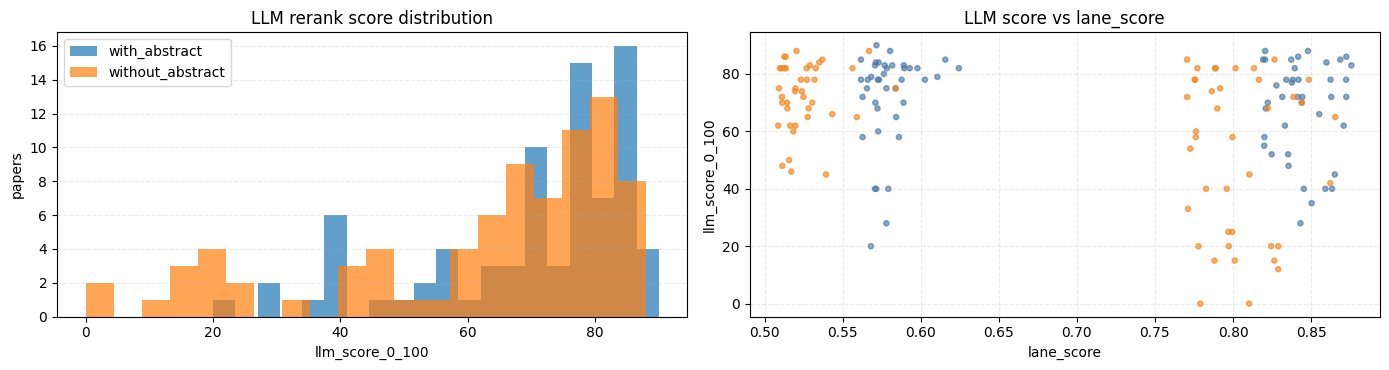

Final report — Top 30 results (pandas tables)

Top 30 / 600: match/with_abstract
Overview


,rank,title,open,scholar,year,cites,lane_score,llm,insuff,match,authority,best,top_m,cov,n_tags,req_hit,abs,facet_stage,venue,providers,id
0,1,"Consumer Perceived Risk, Attitude and Online Shopping Behaviour; Empirical Evidence from Malaysia",open,scholar,2014,129,0.572000,90,False,0.513000,0.805000,0.656000,0.538000,0.091000,15,13,True,stage2,IOP Conference Series Materials Science and Engineering,openalex,10.1088/1757-899x/58/1/012007
1,2,How effective is nudging? A quantitative review on the effect sizes and limits of empirical nudging studies,open,scholar,2019,495,0.580000,88,False,0.484000,0.968000,0.616000,0.511000,0.084000,14,12,True,stage2,Journal of Behavioral and Experimental Economics,mixed,10.1016/j.socec.2019.03.005
2,3,Digital Nudging,open,scholar,2016,520,0.616000,85,False,0.548000,0.887000,0.679000,0.585000,0.141000,15,13,True,stage2,Business & Information Systems Engineering,mixed,10.1007/s12599-016-0453-1
3,4,"Trust, Risk and Alternative Website Quality in B-Buyer Acceptance of Cross-Border E-Commerce",open,scholar,2019,69,0.562000,85,False,0.487000,0.861000,0.628000,0.505000,0.074000,14,12,True,stage2,Journal of Global Information Management,openalex,10.4018/jgim.2020010109
4,5,"Heuristics, Biases and the Psychology of Reasoning: State of the Art",open,scholar,2023,19,0.573000,84,False,0.498000,0.872000,0.620000,0.572000,0.070000,10,9,True,stage2,Psychology,openalex,10.4236/psych.2023.142016
5,6,Online customer behavior: perceptions regarding the types of risks incurred through online purchases,open,scholar,2020,43,0.571000,84,False,0.502000,0.848000,0.621000,0.557000,0.106000,15,13,True,stage2,Palgrave Communications,openalex,10.1057/s41599-020-0389-4
6,7,The Digital Landscape of Nudging: A Systematic Literature Review of Empirical Research on Digital Nudges,open,scholar,2022,80,0.589000,83,False,0.495000,0.967000,0.635000,0.512000,0.087000,12,10,True,stage2,International Conference on Human Factors in Computing Systems,mixed,10.1145/3491102.3517638
7,8,23 Ways to Nudge: A Review of Technology-Mediated Nudging in Human-Computer Interaction,open,scholar,2019,412,0.582000,83,False,0.493000,0.937000,0.612000,0.549000,0.096000,12,10,True,stage2,International Conference on Human Factors in Computing Systems,mixed,10.1145/3290605.3300733
8,9,Understanding the user perception of digital nudging in platform interface design,open,scholar,2024,6,0.577000,83,False,0.532000,0.758000,0.643000,0.587000,0.156000,17,15,True,stage2,Electronic Commerce Research,mixed,10.1007/s10660-024-09825-6
9,10,Dark patterns and consumer vulnerability,open,scholar,2025,9,0.571000,83,False,0.491000,0.888000,0.593000,0.570000,0.114000,15,13,True,stage2,Behavioural Public Policy,mixed,10.1017/bpp.2024.49


Evidence


,rank,title,top_tags,top_excerpt,abstract_preview
0,1,"Consumer Perceived Risk, Attitude and Online Shopping Behaviour; Empirical Evidence from Malaysia","perceived_risk_dimensions(0.66), heuristics_biases_online(0.50), decision_confidence_measurement(0.46)","The conceptualization of consumers' perceived risk, attitude and online shopping behaviour of this study provides empirical evidence in the study of consumer online behaviour. Four types of risks – product risk, financial, convenience and …","The development of e-commerce has increased the popularity of online shopping worldwide. In Malaysia, it was reported that online shopping market size was RM1.8 billion in 2013 and it is estimated to reach RM5 billion by 2015. However, online shopping was rated 11th out of 15 purposes of using internet in 2012. Consumers' perceived risks of online shopping becomes a hot topic to research as it will directly influence users' attitude towards online purchasing, and their attitude will have significant impact to the online purchasing behaviour. The conceptualization of consumers' perceived risk, attitude and online shopping behaviour of this study provides empirical evidence in the study of consumer online behaviour. Four types of risks – product risk, financial, convenience and non-delivery risks – were examined in term of their effect on consumers' online attitude. A web-based survey was employed, and a total of 300 online shoppers of a Malaysia largest online marketplace participated in this study. The findings indicated that product risk, financial and non-delivery risks are hazardous and negatively affect the attitude of online shoppers. Convenience risk was found to have positive effect on consumers' attitude, denoting that online buyers of this site trusted the online seller and they encountered less troublesome with the site. It also implies that consumers did not really concern on non-convenience aspect of online shopping, such as handling of returned products and exam…"
1,2,How effective is nudging? A quantitative review on the effect sizes and limits of empirical nudging studies,"choice_architecture_digital_nudging(0.62), personalization_recommender_effects(0.52), legal_ethical_regulatory_considerations(0.49)","Abstract Changes in the choice architecture, so-called nudges, have been employed in a variety of contexts to alter people's behavior. Although nudging has gained a widespread popularity, the effect sizes of its influences vary considerabl…","Abstract Changes in the choice architecture, so-called nudges, have been employed in a variety of contexts to alter people's behavior. Although nudging has gained a widespread popularity, the effect sizes of its influences vary considerably across studies. In addition, nudges have proven to be ineffective or even backfire in selected studies which raises the question whether, and under which conditions, nudges are effective. Therefore, we conduct a quantitative review on nudging with 100 primary publications including 317 effect sizes from different research areas. We derive four key results. (1) A morphological box on nudging based on eight dimensions, (2) an assessment of the effectiveness of different nudging interventions, (3) a categorization of the relative importance of the application context and the nudge category, and (4) a comparison of nudging and digital nudging. Thereby, we shed light on the (in)effectiveness of nudging and we show how the findings of the past can be used for future research. Practitioners, especially government officials, can use the results to review and adjust their policy making."
2,3,Digital Nudging,"choice_architecture_digital_nudging(0.68), heuristics_biases_online(0.56), personalization_recommender_effects(0.54)","Nudging, Information systems design, Human–computer interaction, Online choice architecture","Nudging, Information systems design, Human–computer interaction, Online choice architecture"
3,4,"Trust, Risk and Alternative Website Qual


Top 30 / 300: match/without_abstract
Overview


...

Final report — Provider + abstract mix (top 30)
lane      | pool             | n  | openalex | semanticscholar | mixed | unknown | abstract_% | stage2_% | req_hit_mean
----------+------------------+----+----------+-----------------+-------+---------+------------+----------+-------------
match     | with_abstract    | 30 | 12       | 0               | 18    | 0       | 100%       | 100%     | 11.27       
match     | without_abstract | 30 | 9        | 19              | 2     | 0       | 0%         | 0%       | 6.20        
authority | with_abstract    | 30 | 13       | 4               | 13    | 0       | 100%       | 100%     | 9.80        
authority | without_abstract | 30 | 19       | 9               | 2     | 0       | 0%         | 0%       | 3.27        
Final report — Abstract snippets (quick audit)

match/with_abstract — abstract snippets
  #1 (2014, cites=129) Consumer Perceived Risk, Attitude and Online Shopping Behaviour; Empirical Evidence from Malaysia
     open: https://doi.

,facet_id,label_en,match_with,match_noabs,auth_with,auth_noabs
0,personalization_recommender_effects,Personalization and recommender effects,30,29,30,22
1,heuristics_biases_online,Heuristics and biases online,30,30,30,19
2,choice_architecture_digital_nudging,Choice architecture and digital nudging,29,22,29,20
3,decision_psychology_confidence,Decision psychology and confidence,30,24,28,15
4,legal_ethical_regulatory_considerations,Legal ethical and regulatory considerations,26,22,27,22
5,nudge_design_ethics_limits,Ethics transparency and autonomy,24,15,28,16
6,uncertainty_reduction_interventions,Interventions to reduce uncertainty,28,13,29,6
7,decision_confidence_measurement,Measuring decision confidence,28,17,23,4
8,manipulative_dark_patterns,Manipulative patterns and dark patterns,17,14,26,10
9,measurement_methods_webshop,Measurement methods in webshop research,28,6,21,4


Final report — Required facet coverage (weight>=4; top 30)


,facet_id,weight,label_en,match_with,match_noabs,auth_with,auth_noabs
0,decision_psychology_confidence,5,Decision psychology and confidence,30,24,28,15
1,heuristics_biases_online,5,Heuristics and biases online,30,30,30,19
2,choice_architecture_digital_nudging,5,Choice architecture and digital nudging,29,22,29,20
3,decision_confidence_measurement,5,Measuring decision confidence,28,17,23,4
4,uncertainty_reduction_interventions,5,Interventions to reduce uncertainty,28,13,29,6
5,perceived_risk_dimensions,5,Perceived risk and uncertainty,25,12,18,0
6,product_complexity_consumer_electronics,5,Consumer electronics product complexity,25,11,13,1
7,nudge_design_ethics_limits,5,Ethics transparency and autonomy,24,15,28,16
8,dual_process_confidence,5,Dual process and confidence,21,9,22,0
9,manipulative_dark_patterns,5,Manipulative patterns and dark patterns,17,14,26,10


lane      | pool             | n  | req_hit_mean | req_hit_p50 | req_hit_p90 | req_hit_min | req_hit_max
----------+------------------+----+--------------+-------------+-------------+-------------+------------
match     | with_abstract    | 30 | 11.27        | 12          | 14          | 6           | 15         
match     | without_abstract | 30 | 6.20         | 6           | 9           | 4           | 10         
authority | with_abstract    | 30 | 9.80         | 10          | 12          | 4           | 14         
authority | without_abstract | 30 | 3.27         | 2           | 7           | 0           | 10         
WARN: some required facets never appear in the top list(s)
lane      | pool             | missing_required | examples                                                                                                                  
----------+------------------+------------------+-----------------------------------------------------------------------------------------

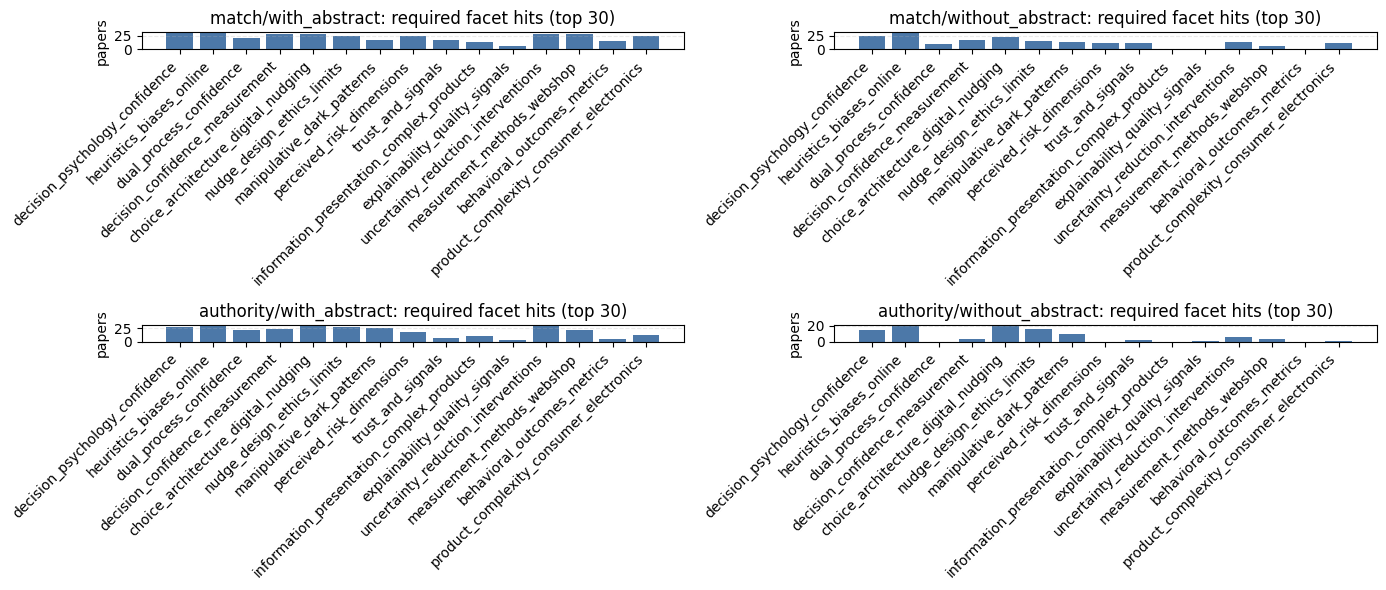

In [19]:
# Final report — Top results + pipeline cost summary

import html
import json
import math
import statistics
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from urllib.parse import quote_plus


def _has_data_report(path: Path) -> bool:
    try:
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    return True
    except Exception:
        return False
    return False


print_section('Final report — Summary')

output_path = Path(run_ctx.artifacts.output_json)
if not output_path.exists():
    raise RuntimeError(f'Missing {output_path}. Run Phase K first.')
out = read_json(output_path)

rankings = out.get('rankings') or {}
lanes = ['match', 'authority']
pools = ['with_abstract', 'without_abstract']

TOP_SHOW = 30
RERANK_TOP_K = int(getattr(cfg, 'rerank_top_k_pre', 40) or 40)
REPORT_EXCERPT_CHARS = 240
REPORT_ABSTRACT_CHARS = int(getattr(cfg, 'report_abstract_chars', 1500) or 1500)
REPORT_MAX_COLWIDTH = int(getattr(cfg, 'report_max_colwidth', 800) or 800)
REPORT_ID_CHARS = int(getattr(cfg, 'report_id_chars', 42) or 42)

# IDs by lane/pool
ranked_ids: Dict[Tuple[str, str], List[str]] = {}
top_ids: Dict[Tuple[str, str], List[str]] = {}
all_rank_ids: set[str] = set()
top_needed_ids: set[str] = set()
for lane in lanes:
    for pool in pools:
        ids_full = [str(x) for x in (rankings.get(lane, {}).get(pool, []) or [])]
        ids_full = [cid for cid in ids_full if cid]
        ranked_ids[(lane, pool)] = ids_full
        all_rank_ids.update(ids_full)

        ids_top = ids_full[: int(TOP_SHOW)]
        top_ids[(lane, pool)] = ids_top
        top_needed_ids.update(ids_top)

# Locate join inputs (prefer paths recorded in output.json)
scores_final_path = Path((out.get('artifacts') or {}).get('scores_final_jsonl') or (run_ctx.run_dir / 'scores_final.jsonl'))
candidates_path = Path((out.get('artifacts') or {}).get('candidates_jsonl') or run_ctx.artifacts.candidates_normalized_jsonl)
rerank_results_path_raw = (out.get('artifacts') or {}).get('rerank_results_jsonl')
rerank_results_path = Path(rerank_results_path_raw) if rerank_results_path_raw else Path(run_ctx.artifacts.rerank_results_jsonl)

if not scores_final_path.exists():
    raise RuntimeError(f'Missing {scores_final_path}. Run Phase G first.')
if not candidates_path.exists():
    raise RuntimeError(f'Missing {candidates_path}. Run Phase E/F first.')

# Facets index (labels + required facets)
facet_index_path = run_ctx.run_dir / 'facets_index.json'
facet_index = read_json(facet_index_path) if facet_index_path.exists() else {}
facet_rows = list((facet_index.get('facets') or []))
label_by_fid = {str(f.get('facet_id')): str(f.get('facet_label_en') or f.get('facet_label_de') or f.get('facet_id')) for f in facet_rows if isinstance(f, dict) and f.get('facet_id')}
weight_by_fid: Dict[str, int] = {}
for f in facet_rows:
    if not isinstance(f, dict):
        continue
    fid = str(f.get('facet_id') or '').strip()
    if not fid:
        continue
    try:
        weight_by_fid[fid] = int(f.get('importance_weight') or 0)
    except Exception:
        weight_by_fid[fid] = 0
required_fids = sorted([fid for fid, w in weight_by_fid.items() if int(w) >= 4])
required_fid_set = set(required_fids)

# Load scores for all ranked IDs (used for distributions/QC)
scores_by_id: Dict[str, Dict[str, Any]] = {}
for r in _iter_jsonl_dicts(scores_final_path):
    cid = str(r.get('id') or '').strip()
    if cid in all_rank_ids:
        scores_by_id[cid] = r

# Load candidate metadata only for top IDs (for tables/abstract previews)
candidates_by_id: Dict[str, Dict[str, Any]] = {}
for c in _iter_jsonl_dicts(candidates_path):
    cid = str(c.get('id') or '').strip()
    if cid in top_needed_ids:
        candidates_by_id[cid] = c

# Load rerank results if present (also aggregate costs/tokens from rerank_results.jsonl when available)
rerank_by_key: Dict[Tuple[str, str, str], Dict[str, Any]] = {}
rerank_agg: Dict[str, Any] = {
    'tasks_total': 0,
    'cache_hits': 0,
    'api_calls': 0,
    'failures': 0,
    'tokens_in_total': 0,
    'tokens_cached_in_total': 0,
    'tokens_out_total': 0,
    'tokens_in_new': 0,
    'tokens_cached_in_new': 0,
    'tokens_out_new': 0,
    'cost_usd_total': 0.0,
    'cost_usd_new': 0.0,
    'model_used': '',
}
if rerank_results_path.exists() and _has_data_report(rerank_results_path):
    for rec in _iter_jsonl_dicts(rerank_results_path):
        cid = str(rec.get('id') or '').strip()
        lane = str(rec.get('lane') or '').strip()
        pool = str(rec.get('pool') or '').strip()

        rerank_agg['tasks_total'] = int(rerank_agg.get('tasks_total') or 0) + 1
        cache_hit = bool(rec.get('cache_hit')) if ('cache_hit' in rec) else False
        if cache_hit:
            rerank_agg['cache_hits'] = int(rerank_agg.get('cache_hits') or 0) + 1

        rr = rec.get('rerank')
        if cid and lane and pool and isinstance(rr, dict):
            rerank_by_key[(cid, lane, pool)] = rr
        else:
            rerank_agg['failures'] = int(rerank_agg.get('failures') or 0) + 1

        oa = rec.get('openai') or {}
        if not isinstance(oa, dict):
            continue
        usage = oa.get('usage') or {}
        ce = oa.get('cost_estimate') or {}

        model_used = str(oa.get('model_used') or oa.get('model') or '').strip()
        if model_used and not str(rerank_agg.get('model_used') or '').strip():
            rerank_agg['model_used'] = model_used

        try:
            tin = int((usage.get('input_tokens') or 0))
        except Exception:
            tin = 0
        try:
            tcached = int((usage.get('cached_input_tokens') or 0))
        except Exception:
            tcached = 0
        try:
            tout = int((usage.get('output_tokens') or 0))
        except Exception:
            tout = 0
        try:
            cost = float((ce.get('total_cost_usd') or 0.0))
        except Exception:
            cost = 0.0

        rerank_agg['tokens_in_total'] = int(rerank_agg.get('tokens_in_total') or 0) + tin
        rerank_agg['tokens_cached_in_total'] = int(rerank_agg.get('tokens_cached_in_total') or 0) + tcached
        rerank_agg['tokens_out_total'] = int(rerank_agg.get('tokens_out_total') or 0) + tout
        rerank_agg['cost_usd_total'] = float(rerank_agg.get('cost_usd_total') or 0.0) + float(cost)

        if not cache_hit:
            rerank_agg['tokens_in_new'] = int(rerank_agg.get('tokens_in_new') or 0) + tin
            rerank_agg['tokens_cached_in_new'] = int(rerank_agg.get('tokens_cached_in_new') or 0) + tcached
            rerank_agg['tokens_out_new'] = int(rerank_agg.get('tokens_out_new') or 0) + tout
            rerank_agg['cost_usd_new'] = float(rerank_agg.get('cost_usd_new') or 0.0) + float(cost)

rerank_agg['api_calls'] = max(0, int(rerank_agg.get('tasks_total') or 0) - int(rerank_agg.get('cache_hits') or 0))


def _providers(cand: Dict[str, Any]) -> str:
    pids = cand.get('provider_ids') or {}
    keys = [str(k) for k, vs in (pids or {}).items() if vs]
    keys = [k for k in keys if k]
    if not keys:
        return ''
    if len(keys) == 1:
        return keys[0]
    return 'mixed'


def _top_tags_str(tags: List[Dict[str, Any]], k: int = 3) -> str:
    tags = [t for t in (tags or []) if isinstance(t, dict) and str(t.get('facet_id') or '').strip()]
    tags_sorted = sorted(tags, key=lambda x: float(x.get('score') or 0.0), reverse=True)[: int(k)]
    out = []
    for t in tags_sorted:
        fid = str(t.get('facet_id') or '').strip()
        try:
            sc = float(t.get('score') or 0.0)
        except Exception:
            sc = 0.0
        out.append(f"{fid}({sc:.2f})")
    return ', '.join(out)


def _first_excerpt(tags: List[Dict[str, Any]]) -> str:
    tags = [t for t in (tags or []) if isinstance(t, dict)]
    if not tags:
        return ''
    t0 = tags[0]
    return _truncate(str(t0.get('excerpt') or '').strip(), REPORT_EXCERPT_CHARS)


def _link(label: str, url: str) -> str:
    u = str(url or '').strip()
    if not u:
        return ''
    lab = html.escape(str(label or '').strip())
    return f'<a href="{u}" target="_blank" rel="noopener">{lab}</a>'


def _best_open_url(cid: str, cand: Dict[str, Any], score_rec: Dict[str, Any]) -> str:
    url = str(cand.get('url') or score_rec.get('url') or '').strip()
    if url.startswith('http'):
        return url

    doi = str(cand.get('doi') or score_rec.get('doi') or '').strip()
    if doi:
        return f'https://doi.org/{doi}'

    cid_s = str(cid or '').strip()
    if cid_s.startswith('10.'):
        return f'https://doi.org/{cid_s}'

    pids = cand.get('provider_ids') or score_rec.get('provider_ids') or {}
    if isinstance(pids, dict):
        for k in ['semanticscholar', 'openalex']:
            vals = pids.get(k) or []
            if not vals:
                continue
            u = str(vals[0] or '').strip()
            if not u:
                continue
            if u.startswith('http'):
                return u
            if k == 'openalex' and u.startswith('W'):
                return f'https://openalex.org/{u}'
            if k == 'semanticscholar':
                return f'https://www.semanticscholar.org/paper/{u}'

    if cid_s.startswith('http'):
        return cid_s
    if cid_s.startswith('W'):
        return f'https://openalex.org/{cid_s}'

    return ''


def _scholar_search_url(title: str, year: Any) -> str:
    t = str(title or '').strip()
    y = '' if year in (None, '') else str(year)
    q = (t + ' ' + y).strip()
    return 'https://scholar.google.com/scholar?q=' + quote_plus(q)


def _build_rows(lane: str, pool: str) -> List[Dict[str, Any]]:
    ids = list(top_ids.get((lane, pool), []) or [])
    rows = []
    for rank, cid in enumerate(ids, start=1):
        r = scores_by_id.get(cid) or {}
        c = candidates_by_id.get(cid) or {}
        sc = r.get('scores') or {}
        lane_score = float(sc.get('match_lane' if lane == 'match' else 'authority_lane') or 0.0)
        match = float(sc.get('match') or 0.0)
        auth = float(sc.get('authority') or 0.0)
        best = float(sc.get('best') or 0.0)
        top_m = float(sc.get('top_m') or 0.0)
        cov = float(sc.get('cov') or 0.0)
        cites = int(c.get('citations') or r.get('citations') or 0)
        year = c.get('year') if c.get('year') is not None else r.get('year')
        venue = c.get('venue') if c.get('venue') is not None else r.get('venue')
        title = str(c.get('title') or r.get('title') or '').strip()
        tags = list((r.get('coverage_tags') or []))
        n_tags = int(len([t for t in tags if isinstance(t, dict)]))
        rr = rerank_by_key.get((cid, lane, pool)) or {}
        llm = rr.get('llm_score_0_100') if isinstance(rr, dict) else None
        insuff = rr.get('insufficient_info') if isinstance(rr, dict) else None
        url_open = _best_open_url(cid, c, r)
        url_scholar = _scholar_search_url(title, year)
        url_best = url_open or url_scholar
        title_disp = (_link(title, url_best) if url_best else html.escape(title))
        id_short = _truncate(str(cid), int(REPORT_ID_CHARS))
        id_disp = (_link(id_short, url_best) if url_best else html.escape(id_short))
        abstract = str(c.get('abstract') or '').strip()
        abstract_preview = _truncate(abstract, REPORT_ABSTRACT_CHARS) if abstract else ''
        covered_fids = {str(t.get('facet_id') or '').strip() for t in tags if isinstance(t, dict) and str(t.get('facet_id') or '').strip()}
        req_hit = (len(covered_fids.intersection(required_fid_set)) if required_fid_set else 0)
        facet_stage = str(((r.get('facet_scores') or {}).get('stage') or '')).strip()
        rows.append(
            {
                'rank': int(rank),
                'title': title_disp,
                'open': _link('open', url_open) if url_open else _link('scholar', url_scholar),
                'scholar': _link('scholar', url_scholar),
                'year': year,
                'cites': int(cites),
                'lane_score': round(float(lane_score), 3),
                'llm': (None if llm is None else int(llm)),
                'insuff': (None if insuff is None else bool(insuff)),
                'match': round(float(match), 3),
                'authority': round(float(auth), 3),
                'best': round(float(best), 3),
                'top_m': round(float(top_m), 3),
                'cov': round(float(cov), 3),
                'facet_stage': facet_stage,
                'n_tags': int(n_tags),
                'req_hit': int(req_hit),
                'abs': bool(abstract),
                'venue': venue or '',
                'providers': _providers(c),
                'id': id_disp,
                'top_tags': _top_tags_str(tags, k=3),
                'top_excerpt': _first_excerpt(tags),
                'abstract_preview': abstract_preview,
            }
        )
    return rows


# Costs + totals (OpenAI + embeddings)
# Note: costs are computed from token usage × the local price table used by this notebook (not an invoice).
metrics = load_metrics(run_ctx)
stages = metrics.get('stages', {}) or {}

# Best-effort: infer whether the latest LLM stages were cache hits from logs.jsonl.
logs_path = Path(run_ctx.artifacts.logs_jsonl)
cache_last: Dict[str, str] = {}
cache_ts: Dict[str, str] = {}
if logs_path.exists():
    for rec in _iter_jsonl_dicts(logs_path):
        stg = str(rec.get('stage') or '').strip()
        ev = str(rec.get('event') or '').strip()
        ts = str(rec.get('ts') or '').strip()
        if not stg or not ts:
            continue
        if ev not in {'cache_hit', 'cache_write'}:
            continue
        if stg not in {'phase_b_query_planner', 'phase_c_openalex_query_builder', 'phase_c_s2_query_builder'}:
            continue
        prev = cache_ts.get(stg)
        if (prev is None) or (ts > prev):
            cache_ts[stg] = ts
            cache_last[stg] = ev

def _cache_status(stage_name: str) -> str:
    ev = cache_last.get(stage_name)
    if ev == 'cache_hit':
        return 'hit'
    if ev == 'cache_write':
        return 'write'
    return ''

cost_rows: List[Dict[str, Any]] = []
openai_cost_usd_run = 0.0
openai_cost_usd_artifacts = 0.0
emb_cost_usd_run = 0.0
emb_cost_usd_artifacts = 0.0
tokens_in_run = 0
tokens_cached_in_run = 0
tokens_out_run = 0
tokens_in_artifacts = 0
tokens_cached_in_artifacts = 0
tokens_out_artifacts = 0

STAGE_LABELS = {
    'phase_a': 'Phase A — Init',
    'phase_b_query_planner': 'Phase B — Query planner (LLM)',
    'phase_c_openalex_query_builder': 'Phase C — OpenAlex query builder (LLM)',
    'phase_c_s2_query_builder': 'Phase C — S2 query builder (LLM)',
    'phase_d_retrieval': 'Phase D — Retrieval',
    'phase_e_candidates': 'Phase E — Candidates',
    'phase_f': 'Phase F — Scoring + embeddings',
    'phase_g': 'Phase G — Final scores',
    'phase_h_coverage_tags': 'Phase H — Coverage tags',
    'phase_i_rerank': 'Phase I — Rerank (LLM)',
    'phase_k_output': 'Phase K — Output',
}

for stage_name in sorted(stages.keys()):
    st = stages.get(stage_name) or {}
    dur = st.get('last_duration_s')
    cache = _cache_status(str(stage_name))

    model = ''
    info = ''

    # Artifact cost = what it cost to generate the cached artifact at least once.
    # Run cost = what it cost in the latest run (0 when served from cache).
    tin_a = 0
    tcached_a = 0
    tout_a = 0
    cost_a = 0.0
    tin_r = 0
    tcached_r = 0
    tout_r = 0
    cost_r = 0.0

    if isinstance(st.get('openai'), dict):
        oa = st.get('openai') or {}
        usage = oa.get('usage') or {}
        ce = oa.get('cost_estimate') or {}
        model = str(oa.get('model_used') or oa.get('model_requested') or '')
        tin_a = int(usage.get('input_tokens') or 0)
        tcached_a = int(usage.get('cached_input_tokens') or 0)
        tout_a = int(usage.get('output_tokens') or 0)
        cost_a = float(ce.get('total_cost_usd') or 0.0)

        if cache == 'hit':
            tin_r = 0
            tcached_r = 0
            tout_r = 0
            cost_r = 0.0
        else:
            tin_r = tin_a
            tcached_r = tcached_a
            tout_r = tout_a
            cost_r = cost_a

        openai_cost_usd_artifacts += float(cost_a)
        openai_cost_usd_run += float(cost_r)

    elif str(stage_name) == 'phase_i_rerank':
        c = (st.get('counts') or {})
        model = str(c.get('model_used') or c.get('model') or rerank_agg.get('model_used') or 'gpt-5-mini')

        tin_a = int(c.get('tokens_in_total') or rerank_agg.get('tokens_in_total') or 0)
        tcached_a = int(c.get('tokens_cached_in_total') or rerank_agg.get('tokens_cached_in_total') or 0)
        tout_a = int(c.get('tokens_out_total') or rerank_agg.get('tokens_out_total') or 0)
        cost_a = float(c.get('cost_usd_total') or c.get('cost_usd_est_total') or rerank_agg.get('cost_usd_total') or 0.0)

        tin_r = int(c.get('tokens_in_new') or rerank_agg.get('tokens_in_new') or 0)
        tcached_r = int(c.get('tokens_cached_in_new') or rerank_agg.get('tokens_cached_in_new') or 0)
        tout_r = int(c.get('tokens_out_new') or rerank_agg.get('tokens_out_new') or 0)
        cost_r = float(c.get('cost_usd_new') or c.get('cost_usd_est_new') or rerank_agg.get('cost_usd_new') or 0.0)

        openai_cost_usd_artifacts += float(cost_a)
        openai_cost_usd_run += float(cost_r)
        tasks_total = int(c.get('tasks_total') or rerank_agg.get('tasks_total') or 0)
        cache_hits = int(c.get('cache_hits') or rerank_agg.get('cache_hits') or 0)
        api_calls = int(c.get('api_calls') or rerank_agg.get('api_calls') or 0)
        failures = int(c.get('failures') or rerank_agg.get('failures') or 0)
        info = f"tasks={tasks_total} cache_hits={cache_hits} api_calls={api_calls} failures={failures}"

    elif str(stage_name) == 'phase_f':
        et = (st.get('embeddings_total') or {})
        emb = (st.get('embeddings') or {})

        # prefer meta model name if present
        model = str(((emb.get('meta') or {}).get('model') or (emb.get('facet') or {}).get('model') or ''))
        tin_a = int(et.get('prompt_tokens') or 0)
        cost_a = float(et.get('cost_usd') or et.get('cost_usd_est') or 0.0)
        tin_r = tin_a
        cost_r = cost_a

        emb_cost_usd_artifacts += float(cost_a)
        emb_cost_usd_run += float(cost_r)

        parts = []
        for kind in ['facet', 'meta', 'meta_recs', 'chunk']:
            k = emb.get(kind) or {}
            if not isinstance(k, dict):
                continue
            parts.append(
                f"{kind}:hits={_fmt_int(k.get('cache_hits') or 0)}(l={_fmt_int(k.get('cache_hits_local') or 0)} g={_fmt_int(k.get('cache_hits_global') or 0)}) "
                f"creates={_fmt_int(k.get('cache_creates') or 0)} "
                f"api_calls={_fmt_int(k.get('api_calls') or 0)}"
            )
        info = '; '.join([p for p in parts if p])

    else:
        # Non-OpenAI stages: surface a few useful counts.
        if str(stage_name) == 'phase_d_retrieval':
            oa = st.get('openalex') or {}
            s2 = st.get('semanticscholar') or {}
            info = f"oa_records={_fmt_int(oa.get('records') or 0)} s2_records={_fmt_int(s2.get('records') or 0)}"
        elif str(stage_name) == 'phase_e_candidates':
            c = st.get('counts') or {}
            pc = c.get('pool_counts') or {}
            info = (
                f"deduped={_fmt_int(c.get('deduped_candidates') or 0)} merges={_fmt_int(c.get('merges') or 0)} "
                f"with_abs={_fmt_int(pc.get('with_abstract') or 0)} noabs={_fmt_int(pc.get('without_abstract') or 0)}"
            )
        elif str(stage_name) == 'phase_g':
            c = st.get('counts') or {}
            info = f"shortlist={_fmt_int(c.get('shortlist_unique_ids') or 0)} stage2_avail={_fmt_int(c.get('stage2_available') or 0)}"
        elif str(stage_name) == 'phase_h_coverage_tags':
            c = st.get('counts') or {}
            info = f"records={_fmt_int(c.get('records_scored_final') or 0)} tags={_fmt_int(c.get('coverage_tags_total') or 0)}"
        elif str(stage_name) == 'phase_k_output':
            c = st.get('counts') or {}
            info = f"top_n={_fmt_int(c.get('top_n') or 0)} rerank_loaded={_fmt_int(c.get('rerank_rows_loaded') or 0)}"

    tokens_in_run += int(tin_r)
    tokens_cached_in_run += int(tcached_r)
    tokens_out_run += int(tout_r)
    tokens_in_artifacts += int(tin_a)
    tokens_cached_in_artifacts += int(tcached_a)
    tokens_out_artifacts += int(tout_a)

    cost_rows.append(
        {
            'stage': str(stage_name),
            'label': str(STAGE_LABELS.get(str(stage_name), str(stage_name))),
            'duration_s': (None if dur is None else float(dur)),
            'cache': cache,
            'model': model,
            'cost_usd_run': round(float(cost_r), 6),
            'cost_usd_artifacts': round(float(cost_a), 6),
            'tokens_in_run': int(tin_r),
            'tokens_cached_in_run': int(tcached_r),
            'tokens_out_run': int(tout_r),
            'tokens_in_artifacts': int(tin_a),
            'tokens_cached_in_artifacts': int(tcached_a),
            'tokens_out_artifacts': int(tout_a),
            'info': info,
        }
    )


# If Phase I wasn't recorded in metrics but rerank_results.jsonl exists, synthesize a stage row.
if (int(rerank_agg.get('tasks_total') or 0) > 0) and ('phase_i_rerank' not in stages):
    tin_a = int(rerank_agg.get('tokens_in_total') or 0)
    tcached_a = int(rerank_agg.get('tokens_cached_in_total') or 0)
    tout_a = int(rerank_agg.get('tokens_out_total') or 0)
    cost_a = float(rerank_agg.get('cost_usd_total') or 0.0)
    tin_r = int(rerank_agg.get('tokens_in_new') or 0)
    tcached_r = int(rerank_agg.get('tokens_cached_in_new') or 0)
    tout_r = int(rerank_agg.get('tokens_out_new') or 0)
    cost_r = float(rerank_agg.get('cost_usd_new') or 0.0)
    model = str(rerank_agg.get('model_used') or 'gpt-5-mini')
    info = (
        f"tasks={int(rerank_agg.get('tasks_total') or 0)} "
        f"cache_hits={int(rerank_agg.get('cache_hits') or 0)} "
        f"api_calls={int(rerank_agg.get('api_calls') or 0)} "
        f"failures={int(rerank_agg.get('failures') or 0)}"
    )

    openai_cost_usd_artifacts += float(cost_a)
    openai_cost_usd_run += float(cost_r)
    tokens_in_run += int(tin_r)
    tokens_cached_in_run += int(tcached_r)
    tokens_out_run += int(tout_r)
    tokens_in_artifacts += int(tin_a)
    tokens_cached_in_artifacts += int(tcached_a)
    tokens_out_artifacts += int(tout_a)

    cost_rows.append(
        {
            'stage': 'phase_i_rerank',
            'label': str(STAGE_LABELS.get('phase_i_rerank', 'phase_i_rerank')),
            'duration_s': None,
            'cache': '',
            'model': model,
            'cost_usd_run': round(float(cost_r), 6),
            'cost_usd_artifacts': round(float(cost_a), 6),
            'tokens_in_run': int(tin_r),
            'tokens_cached_in_run': int(tcached_r),
            'tokens_out_run': int(tout_r),
            'tokens_in_artifacts': int(tin_a),
            'tokens_cached_in_artifacts': int(tcached_a),
            'tokens_out_artifacts': int(tout_a),
            'info': info,
        }
    )

total_cost_usd_run = float(openai_cost_usd_run) + float(emb_cost_usd_run)
total_cost_usd_artifacts = float(openai_cost_usd_artifacts) + float(emb_cost_usd_artifacts)

cost_by_stage = {str(r.get('stage') or ''): r for r in cost_rows if isinstance(r, dict) and str(r.get('stage') or '')}
planner_cost_run = float((cost_by_stage.get('phase_b_query_planner') or {}).get('cost_usd_run') or 0.0)
openalex_builder_cost_run = float((cost_by_stage.get('phase_c_openalex_query_builder') or {}).get('cost_usd_run') or 0.0)
s2_builder_cost_run = float((cost_by_stage.get('phase_c_s2_query_builder') or {}).get('cost_usd_run') or 0.0)
rerank_cost_run = float((cost_by_stage.get('phase_i_rerank') or {}).get('cost_usd_run') or 0.0)
embeddings_cost_run = float((cost_by_stage.get('phase_f') or {}).get('cost_usd_run') or 0.0)

planner_cost_art = float((cost_by_stage.get('phase_b_query_planner') or {}).get('cost_usd_artifacts') or 0.0)
openalex_builder_cost_art = float((cost_by_stage.get('phase_c_openalex_query_builder') or {}).get('cost_usd_artifacts') or 0.0)
s2_builder_cost_art = float((cost_by_stage.get('phase_c_s2_query_builder') or {}).get('cost_usd_artifacts') or 0.0)
rerank_cost_art = float((cost_by_stage.get('phase_i_rerank') or {}).get('cost_usd_artifacts') or 0.0)
embeddings_cost_art = float((cost_by_stage.get('phase_f') or {}).get('cost_usd_artifacts') or 0.0)

n_ranked = {f"{lane}/{pool}": int(len(ranked_ids.get((lane, pool), []) or [])) for lane in lanes for pool in pools}

print_section('Final report — At a glance')
print_kv(
    {
        'run_id': run_ctx.run_id,
        'chapter_title': out.get('chapter_title') or '',
        'pipeline_version': out.get('pipeline_version') or getattr(cfg, 'pipeline_version', ''),
        'top_show': int(TOP_SHOW),
        'rerank_top_k': int(RERANK_TOP_K),
        'ranked_total': n_ranked,
        'total_cost_usd (run)': f"{total_cost_usd_run:.4f}",
        'openai_cost_usd (run)': f"{openai_cost_usd_run:.4f}",
        '  rerank_cost_usd (run)': f"{rerank_cost_run:.4f}",
        'embeddings_cost_usd (run)': f"{embeddings_cost_run:.4f}",
        'total_cost_usd (artifacts)': f"{total_cost_usd_artifacts:.4f}",
        'cache_status (B/C)': {
            'planner': _cache_status('phase_b_query_planner'),
            'openalex_builder': _cache_status('phase_c_openalex_query_builder'),
            's2_builder': _cache_status('phase_c_s2_query_builder'),
        },
        'rankings_used': (out.get('artifacts') or {}).get('rankings_used_json') or '',
        'scores_final_jsonl': scores_final_path,
        'rerank_results_jsonl': (str(rerank_results_path) if rerank_results_path.exists() else '<missing>'),
        'output.json': output_path,
        'cost_note': 'costs computed from token usage × local price table (not an invoice)',
    },
    key_width=28,
)


print_section('Final report — QC')
qc = []

# Duplicate IDs within a single lane/pool should never happen.
dup_total = 0
dup_examples = []
for lane in lanes:
    for pool in pools:
        ids = list(ranked_ids.get((lane, pool), []) or [])
        seen = set()
        dups = []
        for cid in ids:
            if cid in seen:
                dups.append(cid)
            else:
                seen.add(cid)
        if dups:
            dup_total += int(len(dups))
            dup_examples.extend(dups[:2])

qc.append(
    qc_row(
        check='ranking_duplicates',
        status='FAIL' if dup_total else 'OK',
        value=f"{dup_total}" + ('' if not dup_examples else f" (e.g. {', '.join(dup_examples[:4])})"),
        expected='0',
        why='duplicate IDs indicate a lane construction / write bug',
        fix='inspect Phase G/K ranking writers; rerun Phase G then Phase K',
    )
)

# Every ranked ID should have a record in scores_final.jsonl
missing_scores = sum(1 for cid in all_rank_ids if cid not in scores_by_id)
qc.append(
    qc_row(
        check='scores_missing',
        status='WARN' if missing_scores else 'OK',
        value=_fmt_int(missing_scores),
        expected='0',
        why='missing score records makes rankings non-auditable',
        fix='re-run Phase G; inspect shortlist writing and IDs',
    )
)

# Coverage tags are used for evidence + rerank grounding.
tags_present_top = sum(
    1
    for cid in top_needed_ids
    if int(len(((scores_by_id.get(cid) or {}).get('coverage_tags') or []))) > 0
)
qc.append(
    qc_row(
        check='coverage_tags_top30',
        status='OK' if tags_present_top else 'WARN',
        value=_fmt_int(tags_present_top),
        expected='> 0',
        why='enables quick evidence spot-checks (Phase H); without it rerank has weak grounding',
        fix='run Phase H — Coverage tags',
    )
)

# Stage2 evidence share should be non-trivial for with_abstract.
def _stage2_pct(ids: List[str]) -> float:
    recs = [scores_by_id.get(cid) for cid in ids if cid in scores_by_id]
    if not recs:
        return 0.0
    stage2 = sum(1 for r in recs if str(((r.get('facet_scores') or {}).get('stage') or '')) == 'stage2')
    return 100.0 * float(stage2) / float(max(1, len(recs)))

pct_stage2_match_with = _stage2_pct(list(ranked_ids.get(('match', 'with_abstract'), []) or []))
qc.append(
    qc_row(
        check='stage2_share_match_with',
        status='WARN' if pct_stage2_match_with < 25.0 else 'OK',
        value=f"{pct_stage2_match_with:.1f}%",
        expected='>= 25%',
        why='with_abstract quality relies on Stage2 chunk evidence; low share often means missing abstracts or pruning/scoring issues',
        fix='inspect Phase E pool split + Phase F Stage2 scoring',
    )
)

# Rerank sanity (if rerank_results.jsonl exists)
if int(rerank_agg.get('tasks_total') or 0) > 0:
    qc.append(
        qc_row(
            check='rerank_failures',
            status='WARN' if int(rerank_agg.get('failures') or 0) else 'OK',
            value=_fmt_int(int(rerank_agg.get('failures') or 0)),
            expected='0',
            why='failed rerank tasks reduce Stage I impact and break cost accounting',
            fix='re-run Phase I; inspect errors in logs.jsonl and cache/rerank',
        )
    )

# Required facets should appear somewhere in the top match/with_abstract list.
if required_fids:
    ids = list(top_ids.get(('match', 'with_abstract'), []) or [])
    seen = set()
    for cid in ids:
        for t in ((scores_by_id.get(cid) or {}).get('coverage_tags') or []):
            if isinstance(t, dict):
                fid = str(t.get('facet_id') or '').strip()
                if fid:
                    seen.add(fid)
    missing_req = [fid for fid in required_fids if fid not in seen]
    qc.append(
        qc_row(
            check='required_facets_in_top30',
            status='WARN' if missing_req else 'OK',
            value=(
                'all present'
                if not missing_req
                else f"missing {len(missing_req)}/{len(required_fids)} (e.g. {', '.join(missing_req[:3])})"
            ),
            expected='all present',
            why='required facets are the chapter backbone; absence suggests facet plan/threshold issues',
            fix='inspect query plan facets + thresholds; rerun Phase F/G/H',
        )
    )

print_qc(qc)


print_section('Final report — Costs')
cost_components = [
    {'component': 'Phase B — Query planner (LLM)', 'cost_usd_run': round(planner_cost_run, 6), 'cost_usd_artifacts': round(planner_cost_art, 6)},
    {
        'component': 'Phase C — OpenAlex query builder (LLM)',
        'cost_usd_run': round(openalex_builder_cost_run, 6),
        'cost_usd_artifacts': round(openalex_builder_cost_art, 6),
    },
    {'component': 'Phase C — S2 query builder (LLM)', 'cost_usd_run': round(s2_builder_cost_run, 6), 'cost_usd_artifacts': round(s2_builder_cost_art, 6)},
    {'component': 'Phase I — Rerank (LLM)', 'cost_usd_run': round(rerank_cost_run, 6), 'cost_usd_artifacts': round(rerank_cost_art, 6)},
    {'component': 'Phase F — Embeddings', 'cost_usd_run': round(embeddings_cost_run, 6), 'cost_usd_artifacts': round(embeddings_cost_art, 6)},
    {'component': 'TOTAL', 'cost_usd_run': round(total_cost_usd_run, 6), 'cost_usd_artifacts': round(total_cost_usd_artifacts, 6)},
]
print_table(cost_components, columns=['component', 'cost_usd_run', 'cost_usd_artifacts'], max_rows=50, max_col_width=120)


print_section('Final report — Pipeline metrics')
pm: Dict[str, Any] = {}

# Retrieval
d = stages.get('phase_d_retrieval') or {}
pm['openalex_records'] = int(((d.get('openalex') or {}).get('records') or 0))
pm['s2_records'] = int(((d.get('semanticscholar') or {}).get('records') or 0))
pm['openalex_queries_failed'] = int(((d.get('openalex') or {}).get('query_failed') or 0))
pm['s2_queries_failed'] = int(((d.get('semanticscholar') or {}).get('query_failed') or 0))
pm['openalex_cache_hits'] = int(((d.get('openalex') or {}).get('cache_hits') or 0))
pm['openalex_cache_writes'] = int(((d.get('openalex') or {}).get('cache_writes') or 0))
pm['s2_cache_hits'] = int(((d.get('semanticscholar') or {}).get('cache_hits') or 0))
pm['s2_cache_writes'] = int(((d.get('semanticscholar') or {}).get('cache_writes') or 0))

# Candidates
e = stages.get('phase_e_candidates') or {}
ec = (e.get('counts') or {})
pm['candidates_deduped'] = int(ec.get('deduped_candidates') or 0)
pm['candidates_merges'] = int(ec.get('merges') or 0)
pc = ec.get('pool_counts') or {}
pm['candidates_with_abstract'] = int(pc.get('with_abstract') or 0)
pm['candidates_without_abstract'] = int(pc.get('without_abstract') or 0)
pm['filtered_paratext_titles'] = int(ec.get('filtered_paratext_titles') or 0)
pm['filtered_openalex_types'] = int(ec.get('filtered_openalex_types') or 0)
pm['unknown_intent_count'] = int(ec.get('unknown_intent_count') or 0)
pm['final_id_collisions'] = int(ec.get('final_id_collisions') or 0)

# Scoring
f = stages.get('phase_f') or {}
fc = (f.get('counts') or {})
pm['facets'] = int(fc.get('facets') or 0)
pm['stage2_candidates'] = int(fc.get('stage2_candidates') or 0)
pm['stage2_scored'] = int(fc.get('stage2_scored') or 0)
emb = (f.get('embeddings') or {})
et = (f.get('embeddings_total') or {})
pm['embedding_model'] = str(((emb.get('meta') or {}).get('model') or (emb.get('facet') or {}).get('model') or ''))
pm['embedding_prompt_tokens'] = int(et.get('prompt_tokens') or 0)
pm['embeddings_cost_usd'] = float(et.get('cost_usd') or et.get('cost_usd_est') or 0.0)

_kinds = ['facet', 'meta', 'meta_recs', 'chunk']
pm['embedding_cache_hits'] = int(sum(int((emb.get(k) or {}).get('cache_hits') or 0) for k in _kinds))
pm['embedding_cache_hits_local'] = int(sum(int((emb.get(k) or {}).get('cache_hits_local') or 0) for k in _kinds))
pm['embedding_cache_hits_global'] = int(sum(int((emb.get(k) or {}).get('cache_hits_global') or 0) for k in _kinds))
pm['embedding_cache_creates'] = int(sum(int((emb.get(k) or {}).get('cache_creates') or 0) for k in _kinds))
pm['embedding_api_calls'] = int(sum(int((emb.get(k) or {}).get('api_calls') or 0) for k in _kinds))

# Coverage tags
h = stages.get('phase_h_coverage_tags') or {}
hc = (h.get('counts') or {})
pm['coverage_tags_total'] = int(hc.get('coverage_tags_total') or 0)

# Rerank (if present)
i = stages.get('phase_i_rerank') or {}
ic = (i.get('counts') or {})
if int(ic.get('tasks_total') or 0) > 0:
    pm['rerank_tasks_total'] = int(ic.get('tasks_total') or 0)
    pm['rerank_cache_hits'] = int(ic.get('cache_hits') or 0)
    pm['rerank_failures'] = int(ic.get('failures') or 0)
    pm['rerank_cost_usd_total'] = float(ic.get('cost_usd_total') or ic.get('cost_usd_est_total') or 0.0)
    pm['rerank_cost_usd_new'] = float(ic.get('cost_usd_new') or ic.get('cost_usd_est_new') or 0.0)
else:
    pm['rerank_tasks_total'] = int(rerank_agg.get('tasks_total') or 0)
    pm['rerank_cache_hits'] = int(rerank_agg.get('cache_hits') or 0)
    pm['rerank_failures'] = int(rerank_agg.get('failures') or 0)
    pm['rerank_cost_usd_total'] = float(rerank_agg.get('cost_usd_total') or 0.0)
    pm['rerank_cost_usd_new'] = float(rerank_agg.get('cost_usd_new') or 0.0)

print_kv(pm, key_width=26)


print_section('Final report — Score key')
w_best = float(getattr(cfg, 'match_weight_best', 0.55) or 0.55)
w_topm = float(getattr(cfg, 'match_weight_top_m', 0.25) or 0.25)
w_cov = float(getattr(cfg, 'match_weight_cov', 0.20) or 0.20)
top_m = int(getattr(cfg, 'match_top_m', 3) or 3)
t_abs = float(getattr(cfg, 'scoring_t', 0.30) or 0.30)
t_noabs = float(getattr(cfg, 'scoring_t_noabs', 0.35) or 0.35)

print_kv(
    {
        'pool': 'with_abstract = Stage2 chunk evidence; without_abstract = metadata-only (Stage1)',
        'lane_score (match)': 'match_lane = 0.80*match + 0.20*authority (0..1)',
        'lane_score (authority)': 'authority_lane = 0.80*authority + 0.20*match (0..1)',
        'match': f'match = {w_best:.2f}*best + {w_topm:.2f}*top_m + {w_cov:.2f}*cov (0..1)',
        'best': 'max facet similarity score (per-facet; Stage2 uses chunks; Stage1 uses metadata)',
        'top_m': f'mean of the top-{top_m} facet scores (stabilizes against one lucky chunk)',
        'cov': f'facet coverage term (roughly: share of facets above threshold; t={t_abs:.2f} / {t_noabs:.2f})',
        'authority': 'citations-per-year percentile among candidates (0..1; zeros map to 0)',
        'llm': 'LLM rerank score 0..100 using coverage_tags excerpts (pointwise; top-K only)',
        'insuff': 'LLM flags insufficient evidence; sorting prefers insuff=false first',
        'req_hit': '# of required facets (weight>=4) hit via coverage_tags',
        'abs': 'abstract text present (should be true for with_abstract)',
    },
    key_width=26,
)


print_section('Final report — Lane overview (all ranked IDs)')

def _pctl(xs: List[float], p: float) -> Optional[float]:
    xs2 = [float(x) for x in xs if x is not None]
    if not xs2:
        return None
    xs2.sort()
    if len(xs2) == 1:
        return float(xs2[0])
    k = (len(xs2) - 1) * (float(p) / 100.0)
    f = int(k)
    c = min(f + 1, len(xs2) - 1)
    if f == c:
        return float(xs2[f])
    return float(xs2[f]) + (float(xs2[c]) - float(xs2[f])) * (k - f)


def _fmt_f(x: Optional[float], nd: int = 3) -> str:
    if x is None:
        return ''
    try:
        return f"{float(x):.{int(nd)}f}"
    except Exception:
        return ''


lane_rows = []
missing_scores_total = 0
for lane in lanes:
    for pool in pools:
        ids = list(ranked_ids.get((lane, pool), []) or [])
        recs = [scores_by_id.get(cid) for cid in ids if cid in scores_by_id]
        missing = int(len(ids) - len(recs))
        missing_scores_total += int(missing)

        lane_key = 'match_lane' if lane == 'match' else 'authority_lane'
        lane_scores = [float(((r.get('scores') or {}).get(lane_key) or 0.0)) for r in recs if isinstance(r, dict)]
        match_scores = [float(((r.get('scores') or {}).get('match') or 0.0)) for r in recs if isinstance(r, dict)]
        auth_scores = [float(((r.get('scores') or {}).get('authority') or 0.0)) for r in recs if isinstance(r, dict)]

        cites = [int(r.get('citations') or 0) for r in recs if isinstance(r, dict)]
        years = [int(y) for r in recs if isinstance(r, dict) for y in [r.get('year')] if isinstance(y, int)]
        tag_counts = [int(len(r.get('coverage_tags') or [])) for r in recs if isinstance(r, dict)]
        stage2 = sum(1 for r in recs if isinstance(r, dict) and str(((r.get('facet_scores') or {}).get('stage') or '')) == 'stage2')

        rr_vals = [
            rerank_by_key.get((cid, lane, pool))
            for cid in ids[: int(RERANK_TOP_K)]
            if isinstance(rerank_by_key.get((cid, lane, pool)), dict)
        ]
        rr_scores = [int(v.get('llm_score_0_100') or 0) for v in rr_vals if isinstance(v, dict)]
        rr_insuff = [bool(v.get('insufficient_info')) for v in rr_vals if isinstance(v, dict)]
        insuff_rate = (sum(1 for b in rr_insuff if b) / float(max(1, len(rr_insuff)))) if rr_insuff else None

        lane_rows.append(
            {
                'lane': lane,
                'pool': pool,
                'n_total': int(len(ids)),
                'missing_scores': int(missing),
                'stage2_%': _fmt_f((100.0 * float(stage2) / float(max(1, len(recs)))) if recs else None, 1),
                'lane_min': _fmt_f(min(lane_scores) if lane_scores else None),
                'lane_p10': _fmt_f(_pctl(lane_scores, 10)),
                'lane_mean': _fmt_f(statistics.mean(lane_scores) if lane_scores else None),
                'lane_p50': _fmt_f(_pctl(lane_scores, 50)),
                'lane_p90': _fmt_f(_pctl(lane_scores, 90)),
                'lane_p99': _fmt_f(_pctl(lane_scores, 99)),
                'lane_max': _fmt_f(max(lane_scores) if lane_scores else None),
                'match_mean': _fmt_f(statistics.mean(match_scores) if match_scores else None),
                'match_p50': _fmt_f(_pctl(match_scores, 50)),
                'auth_mean': _fmt_f(statistics.mean(auth_scores) if auth_scores else None),
                'auth_p50': _fmt_f(_pctl(auth_scores, 50)),
                'cites_p50': int(statistics.median(cites) if cites else 0),
                'cites_p90': ('' if not cites else int(round(_pctl([float(x) for x in cites], 90) or 0))),
                'year_p10': ('' if not years else int(round(_pctl([float(x) for x in years], 10) or 0))),
                'year_p50': int(statistics.median(years) if years else 0),
                'year_p90': ('' if not years else int(round(_pctl([float(x) for x in years], 90) or 0))),
                'tags_mean': _fmt_f(statistics.mean(tag_counts) if tag_counts else None, 2),
                'rerank_n(topK)': int(len(rr_scores)),
                'rerank_mean': _fmt_f(statistics.mean(rr_scores) if rr_scores else None, 1),
                'insuff_rate': ('' if insuff_rate is None else f"{100.0 * float(insuff_rate):.1f}%"),
            }
        )

print_table(
    lane_rows,
    columns=['lane','pool','n_total','missing_scores','stage2_%','lane_min','lane_p10','lane_mean','lane_p50','lane_p90','lane_p99','lane_max','match_mean','match_p50','auth_mean','auth_p50','cites_p50','cites_p90','year_p10','year_p50','year_p90','tags_mean','rerank_n(topK)','rerank_mean','insuff_rate'],
    max_rows=50,
    max_col_width=140,
)

if missing_scores_total:
    print(f"WARN: {missing_scores_total} ranked IDs are missing from scores_final.jsonl")

print_section('Final report — Lane score cutoffs (by rank)')
cutoffs = [1, 5, 10, 20, 50, 100, 200]
rows_cut = []
for lane in lanes:
    for pool in pools:
        ids = list(ranked_ids.get((lane, pool), []) or [])
        lane_key = 'match_lane' if lane == 'match' else 'authority_lane'
        vals = [
            float((((scores_by_id.get(cid) or {}).get('scores') or {}).get(lane_key) or 0.0))
            for cid in ids
            if cid in scores_by_id
        ]
        row = {'lane': lane, 'pool': pool, 'n': int(len(vals))}
        for k in cutoffs:
            row[f"r{k}"] = (_fmt_f(vals[k - 1]) if len(vals) >= int(k) else '')
        rows_cut.append(row)
print_table(rows_cut, columns=['lane', 'pool', 'n'] + [f"r{k}" for k in cutoffs], max_rows=50, max_col_width=120)


print_section('Final report — Threshold pass rates (all ranked IDs)')
thr_rows = []
for lane in lanes:
    for pool in pools:
        ids = list(ranked_ids.get((lane, pool), []) or [])
        recs = [scores_by_id.get(cid) for cid in ids if cid in scores_by_id]
        thr = float(t_abs if pool == 'with_abstract' else t_noabs)
        mvals = [float(((r.get('scores') or {}).get('match') or 0.0)) for r in recs if isinstance(r, dict)]
        n = int(len(mvals))
        n_pass = sum(1 for v in mvals if float(v) >= float(thr))
        thr_rows.append(
            {
                'lane': lane,
                'pool': pool,
                'n': n,
                't': f"{thr:.2f}",
                'match>=t': int(n_pass),
                'pass_%': ('' if n == 0 else f"{(100.0 * float(n_pass) / float(n)):.1f}%"),
            }
        )
print_table(thr_rows, columns=['lane','pool','n','t','match>=t','pass_%'], max_rows=20, max_col_width=120)


# Lane overlap (same IDs appear in both lanes)
overlap_rows = []
for pool in pools:
    s_match = set(ranked_ids.get(('match', pool), []) or [])
    s_auth = set(ranked_ids.get(('authority', pool), []) or [])
    inter = sorted(s_match.intersection(s_auth))
    overlap_rows.append({'pool': pool, 'overlap_n': int(len(inter)), 'examples': ', '.join(inter[:3])})
print_table(overlap_rows, columns=['pool', 'overlap_n', 'examples'], max_rows=10, max_col_width=140)


if rerank_by_key:
    print_section('Final report — Rerank QC')
    rr_rows = []
    for lane in lanes:
        for pool in pools:
            vals = [rr for (cid, l, p), rr in rerank_by_key.items() if l == lane and p == pool and isinstance(rr, dict)]
            n = len(vals)
            if n == 0:
                rr_rows.append({'lane': lane, 'pool': pool, 'n': 0, 'insuff': 0, 'insuff_rate': '', 'mean_llm': '', 'median_llm': ''})
                continue
            scores = [int(v.get('llm_score_0_100') or 0) for v in vals]
            insuff = sum(1 for v in vals if bool(v.get('insufficient_info')))
            scores_sorted = sorted(scores)
            median = scores_sorted[n // 2] if n % 2 == 1 else int(round(0.5 * (scores_sorted[n // 2 - 1] + scores_sorted[n // 2])))
            rr_rows.append(
                {
                    'lane': lane,
                    'pool': pool,
                    'n': int(n),
                    'insuff': int(insuff),
                    'insuff_rate': f"{(100.0 * float(insuff) / float(max(1, n))):.1f}%",
                    'mean_llm': f"{(sum(scores) / float(max(1, n))):.1f}",
                    'median_llm': int(median),
                }
            )
    print_table(rr_rows, columns=['lane', 'pool', 'n', 'insuff', 'insuff_rate', 'mean_llm', 'median_llm'], max_rows=20, max_col_width=120)


# Pretty tables via pandas
try:
    import pandas as pd  # type: ignore
    from IPython.display import display, HTML  # type: ignore
except Exception as e:
    pd = None
    display = None
    HTML = None
    print(f"<pandas unavailable: {e}>")


if pd is not None:
    try:
        pd.set_option('display.max_colwidth', int(REPORT_MAX_COLWIDTH))
    except Exception:
        pass


def _display_df(df: 'pd.DataFrame') -> None:
    if display is None:
        return
    styled = (
        df.style
          .set_properties(**{"text-align": "left"})
          .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
    )
    display(styled)




print_section('Final report — Cost breakdown by stage')
if pd is None:
    print_table(
        cost_rows,
        columns=[
            'label',
            'cost_usd_run',
            'cost_usd_artifacts',
            'cache',
            'duration_s',
            'model',
            'info',
            'stage',
        ],
        max_rows=200,
        max_col_width=180,
    )
else:
    df_cost = pd.DataFrame(cost_rows)
    if not df_cost.empty:
        df_cost = df_cost.sort_values(['cost_usd_run', 'cost_usd_artifacts', 'duration_s', 'label'], ascending=[False, False, False, True])
    cols = ['label', 'cost_usd_run', 'cost_usd_artifacts', 'cache', 'duration_s', 'model', 'info', 'stage']
    _display_df(df_cost[cols].fillna(''))


print_section('Final report — Plots')
try:
    import matplotlib.pyplot as plt  # type: ignore
except Exception:
    plt = None

if plt is None:
    print('<matplotlib unavailable>')
else:
    try:
        # Cost per stage (run)
        rows_cost = [r for r in cost_rows if float(r.get('cost_usd_run') or 0.0) > 0.0]
        rows_cost.sort(key=lambda r: float(r.get('cost_usd_run') or 0.0), reverse=True)
        rows_cost = rows_cost[:12]

        stages_cost = [r.get('stage') for r in rows_cost]
        vals_cost = [float(r.get('cost_usd_run') or 0.0) for r in rows_cost]

        # Duration per stage
        rows_dur = [r for r in cost_rows if r.get('duration_s') not in (None, '')]
        rows_dur = [r for r in rows_dur if float(r.get('duration_s') or 0.0) > 0.0]
        rows_dur.sort(key=lambda r: float(r.get('duration_s') or 0.0), reverse=True)
        rows_dur = rows_dur[:12]

        stages_dur = [r.get('stage') for r in rows_dur]
        vals_dur = [float(r.get('duration_s') or 0.0) for r in rows_dur]

        fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))

        if stages_cost:
            axes[0].barh(stages_cost[::-1], vals_cost[::-1], color='#4c78a8')
            axes[0].set_title('Cost per stage (this run)')
            axes[0].set_xlabel('USD')
            axes[0].grid(axis='x', linestyle='--', alpha=0.25)
        else:
            axes[0].text(0.5, 0.5, 'No cost recorded', ha='center', va='center')
            axes[0].set_axis_off()

        if stages_dur:
            axes[1].barh(stages_dur[::-1], vals_dur[::-1], color='#f58518')
            axes[1].set_title('Stage durations (last run)')
            axes[1].set_xlabel('seconds')
            axes[1].grid(axis='x', linestyle='--', alpha=0.25)
        else:
            axes[1].text(0.5, 0.5, 'No durations recorded', ha='center', va='center')
            axes[1].set_axis_off()

        fig.tight_layout()
        plt.show()

        # Lane score distributions (all ranked IDs)
        groups = [('match', 'with_abstract'), ('match', 'without_abstract'), ('authority', 'with_abstract'), ('authority', 'without_abstract')]
        fig2, axes2 = plt.subplots(2, 2, figsize=(14, 6.2))
        for i, (lane, pool) in enumerate(groups):
            ax = axes2[i // 2][i % 2]
            ids = list(ranked_ids.get((lane, pool), []) or [])
            lane_key = 'match_lane' if lane == 'match' else 'authority_lane'
            vals = [
                float((((scores_by_id.get(cid) or {}).get('scores') or {}).get(lane_key) or 0.0))
                for cid in ids
                if cid in scores_by_id
            ]
            if vals:
                ax.hist(vals, bins=30, color='#4c78a8', alpha=0.85)
                p50 = _pctl(vals, 50)
                if p50 is not None:
                    ax.axvline(float(p50), color='black', linestyle='--', linewidth=1, alpha=0.6)
            ax.set_title(f"{lane}/{pool} lane_score (n={len(vals)})")
            ax.set_xlabel('lane_score')
            ax.set_ylabel('papers')
            ax.grid(axis='y', linestyle='--', alpha=0.25)
        fig2.tight_layout()
        plt.show()

        # Lane score vs rank (top 200)
        fig3, axes3 = plt.subplots(1, 2, figsize=(14, 3.8))
        for j, lane in enumerate(['match', 'authority']):
            ax = axes3[j]
            for pool, color in [('with_abstract', '#4c78a8'), ('without_abstract', '#f58518')]:
                ids = list(ranked_ids.get((lane, pool), []) or [])
                lane_key = 'match_lane' if lane == 'match' else 'authority_lane'
                vals = [
                    float((((scores_by_id.get(cid) or {}).get('scores') or {}).get(lane_key) or 0.0))
                    for cid in ids
                    if cid in scores_by_id
                ]
                vals = vals[:200]
                if vals:
                    ax.plot(list(range(1, len(vals) + 1)), vals, color=color, linewidth=1.6, label=pool)
            ax.set_title(f"{lane}: lane_score by rank (top 200)")
            ax.set_xlabel('rank')
            ax.set_ylabel('lane_score')
            ax.grid(True, linestyle='--', alpha=0.25)
            ax.legend(loc='best')
        fig3.tight_layout()
        plt.show()

        # Metadata diagnostics (all ranked IDs)
        yrs_with = [
            int(r.get('year'))
            for r in scores_by_id.values()
            if isinstance(r, dict) and str(r.get('pool') or '') == 'with_abstract' and isinstance(r.get('year'), int)
        ]
        yrs_no = [
            int(r.get('year'))
            for r in scores_by_id.values()
            if isinstance(r, dict) and str(r.get('pool') or '') == 'without_abstract' and isinstance(r.get('year'), int)
        ]
        cites_with = [
            int(r.get('citations') or 0)
            for r in scores_by_id.values()
            if isinstance(r, dict) and str(r.get('pool') or '') == 'with_abstract'
        ]
        cites_no = [
            int(r.get('citations') or 0)
            for r in scores_by_id.values()
            if isinstance(r, dict) and str(r.get('pool') or '') == 'without_abstract'
        ]
        tags_with = [
            int(len(r.get('coverage_tags') or []))
            for r in scores_by_id.values()
            if isinstance(r, dict) and str(r.get('pool') or '') == 'with_abstract'
        ]
        tags_no = [
            int(len(r.get('coverage_tags') or []))
            for r in scores_by_id.values()
            if isinstance(r, dict) and str(r.get('pool') or '') == 'without_abstract'
        ]

        figm, axm = plt.subplots(1, 3, figsize=(14, 3.6))
        if yrs_with or yrs_no:
            axm[0].hist(yrs_with, bins=20, alpha=0.7, label='with_abstract')
            axm[0].hist(yrs_no, bins=20, alpha=0.7, label='without_abstract')
            axm[0].set_title('Publication year (ranked IDs)')
            axm[0].set_xlabel('year')
            axm[0].set_ylabel('papers')
            axm[0].grid(axis='y', linestyle='--', alpha=0.25)
            axm[0].legend(loc='best')
        else:
            axm[0].text(0.5, 0.5, 'No year data', ha='center', va='center')
            axm[0].set_axis_off()

        cites_with_l = [math.log10(1.0 + float(x)) for x in cites_with]
        cites_no_l = [math.log10(1.0 + float(x)) for x in cites_no]
        axm[1].hist(cites_with_l, bins=25, alpha=0.7, label='with_abstract')
        axm[1].hist(cites_no_l, bins=25, alpha=0.7, label='without_abstract')
        axm[1].set_title('Citations (log10(1+cites))')
        axm[1].set_xlabel('log10(1+cites)')
        axm[1].set_ylabel('papers')
        axm[1].grid(axis='y', linestyle='--', alpha=0.25)
        axm[1].legend(loc='best')

        axm[2].hist(tags_with, bins=20, alpha=0.7, label='with_abstract')
        axm[2].hist(tags_no, bins=20, alpha=0.7, label='without_abstract')
        axm[2].set_title('coverage_tags count')
        axm[2].set_xlabel('#tags')
        axm[2].set_ylabel('papers')
        axm[2].grid(axis='y', linestyle='--', alpha=0.25)
        axm[2].legend(loc='best')

        figm.tight_layout()
        plt.show()

        # Rerank score diagnostics (if present)
        if rerank_by_key:
            xs = []
            ys = []
            cs = []
            for (cid, lane, pool), rr in rerank_by_key.items():
                if not isinstance(rr, dict):
                    continue
                r = scores_by_id.get(cid) or {}
                sc = (r.get('scores') or {}) if isinstance(r, dict) else {}
                lane_key = 'match_lane' if lane == 'match' else 'authority_lane'
                lane_s = float(sc.get(lane_key) or 0.0)
                llm_s = float(rr.get('llm_score_0_100') or 0.0)
                xs.append(lane_s)
                ys.append(llm_s)
                cs.append('#4c78a8' if pool == 'with_abstract' else '#f58518')

            fig4, axes4 = plt.subplots(1, 2, figsize=(14, 3.8))
            # Histogram
            llm_with = [float(rr.get('llm_score_0_100') or 0.0) for (cid, l, p), rr in rerank_by_key.items() if p == 'with_abstract' and isinstance(rr, dict)]
            llm_no = [float(rr.get('llm_score_0_100') or 0.0) for (cid, l, p), rr in rerank_by_key.items() if p == 'without_abstract' and isinstance(rr, dict)]
            axes4[0].hist(llm_with, bins=20, alpha=0.7, label='with_abstract')
            axes4[0].hist(llm_no, bins=20, alpha=0.7, label='without_abstract')
            axes4[0].set_title('LLM rerank score distribution')
            axes4[0].set_xlabel('llm_score_0_100')
            axes4[0].set_ylabel('papers')
            axes4[0].grid(axis='y', linestyle='--', alpha=0.25)
            axes4[0].legend(loc='best')

            # Scatter
            if xs and ys:
                axes4[1].scatter(xs, ys, s=14, alpha=0.65, c=cs)
                axes4[1].set_title('LLM score vs lane_score')
                axes4[1].set_xlabel('lane_score')
                axes4[1].set_ylabel('llm_score_0_100')
                axes4[1].grid(True, linestyle='--', alpha=0.25)
            else:
                axes4[1].text(0.5, 0.5, 'No rerank data', ha='center', va='center')
                axes4[1].set_axis_off()

            fig4.tight_layout()
            plt.show()
    except Exception as e:
        print(f"<plots skipped: {e}>")


print_section(f'Final report — Top {TOP_SHOW} results (pandas tables)')

OVERVIEW_COLS = [
    'rank',
    'title',
    'open',
    'scholar',
    'year',
    'cites',
    'lane_score',
    'llm',
    'insuff',
    'match',
    'authority',
    'best',
    'top_m',
    'cov',
    'n_tags',
    'req_hit',
    'abs',
    'facet_stage',
    'venue',
    'providers',
    'id',
]

EVIDENCE_COLS = [
    'rank',
    'title',
    'top_tags',
    'top_excerpt',
    'abstract_preview',
]

for lane in lanes:
    for pool in pools:
        total_n = int(len(ranked_ids.get((lane, pool), []) or []))
        rows = _build_rows(lane, pool)
        title = f"Top {TOP_SHOW} / {total_n}: {lane}/{pool}"
        print(f"\n{title}")

        if pd is None:
            print('Overview')
            print_table(rows, columns=OVERVIEW_COLS, max_rows=TOP_SHOW, max_col_width=min(420, int(REPORT_MAX_COLWIDTH)))
            print('Evidence')
            print_table(rows, columns=EVIDENCE_COLS, max_rows=TOP_SHOW, max_col_width=min(420, int(REPORT_MAX_COLWIDTH)))
        else:
            df = pd.DataFrame(rows)
            if not df.empty:
                print('Overview')
                _display_df(df[OVERVIEW_COLS])
                print('Evidence')
                _display_df(df[EVIDENCE_COLS])


print_section(f'Final report — Provider + abstract mix (top {TOP_SHOW})')
mix_rows = []
for lane in lanes:
    for pool in pools:
        ids = list(top_ids.get((lane, pool), []) or [])
        prov_counts: Dict[str, int] = {}
        abs_n = 0
        stage2_n = 0
        req_hits = []
        for cid in ids:
            c = candidates_by_id.get(cid) or {}
            r = scores_by_id.get(cid) or {}
            prov = _providers(c if c else r) or 'unknown'
            prov_counts[prov] = int(prov_counts.get(prov, 0) or 0) + 1
            if str(c.get('abstract') or '').strip():
                abs_n += 1
            if str(((r.get('facet_scores') or {}).get('stage') or '')) == 'stage2':
                stage2_n += 1
            tags = r.get('coverage_tags') or []
            covered = {str(t.get('facet_id') or '').strip() for t in tags if isinstance(t, dict) and str(t.get('facet_id') or '').strip()}
            req_hits.append(int(len(covered.intersection(required_fid_set))) if required_fid_set else 0)

        n = int(len(ids))
        mix_rows.append(
            {
                'lane': lane,
                'pool': pool,
                'n': n,
                'openalex': int(prov_counts.get('openalex', 0) or 0),
                'semanticscholar': int(prov_counts.get('semanticscholar', 0) or 0),
                'mixed': int(prov_counts.get('mixed', 0) or 0),
                'unknown': int(prov_counts.get('unknown', 0) or 0),
                'abstract_%': ('' if n == 0 else f"{(100.0 * float(abs_n) / float(n)):.0f}%"),
                'stage2_%': ('' if n == 0 else f"{(100.0 * float(stage2_n) / float(n)):.0f}%"),
                'req_hit_mean': _fmt_f(statistics.mean(req_hits) if req_hits else None, 2),
            }
        )
print_table(
    mix_rows,
    columns=['lane', 'pool', 'n', 'openalex', 'semanticscholar', 'mixed', 'unknown', 'abstract_%', 'stage2_%', 'req_hit_mean'],
    max_rows=20,
    max_col_width=120,
)


print_section('Final report — Abstract snippets (quick audit)')
SNIPPETS_PER_GROUP = 3
SNIPPET_CHARS = 1600
for lane in lanes:
    for pool in pools:
        ids = list(top_ids.get((lane, pool), []) or [])[: int(SNIPPETS_PER_GROUP)]
        if not ids:
            continue
        print(f"\n{lane}/{pool} — abstract snippets")
        for j, cid in enumerate(ids, start=1):
            r = scores_by_id.get(cid) or {}
            c = candidates_by_id.get(cid) or {}
            title = str(c.get('title') or r.get('title') or '').strip()
            year = c.get('year') if c.get('year') is not None else r.get('year')
            cites = int(c.get('citations') or r.get('citations') or 0)
            url_open = _best_open_url(cid, c, r)
            url_s = _scholar_search_url(title, year)
            abs_text = str(c.get('abstract') or '').strip()
            snippet = _truncate(abs_text, int(SNIPPET_CHARS)) if abs_text else '<no abstract>'
            print(f"  #{j} ({year}, cites={cites}) {title}")
            print(f"     open: {url_open or url_s}")
            print(f"     {snippet}")


print_section(f'Final report — Facet coverage frequency (top {TOP_SHOW})')
facet_index_path = run_ctx.run_dir / 'facets_index.json'
facet_index = read_json(facet_index_path) if facet_index_path.exists() else {}
facet_rows = list((facet_index.get('facets') or []))
label_by_fid = {str(f.get('facet_id')): str(f.get('facet_label_en') or f.get('facet_label_de') or f.get('facet_id')) for f in facet_rows if isinstance(f, dict) and f.get('facet_id')}
required_fids = [
    str(f.get('facet_id'))
    for f in facet_rows
    if isinstance(f, dict) and str(f.get('facet_id') or '').strip() and int(f.get('importance_weight') or 0) >= 4
]
required_fids = [fid for fid in required_fids if str(fid or '').strip()]
required_fid_set = set(required_fids)

def _facet_counts(ids: List[str]) -> Dict[str, int]:
    outc: Dict[str, int] = {}
    for cid in ids:
        r = scores_by_id.get(cid) or {}
        tags = r.get('coverage_tags') or []
        for t in tags:
            if not isinstance(t, dict):
                continue
            fid = str(t.get('facet_id') or '').strip()
            if not fid:
                continue
            outc[fid] = int(outc.get(fid, 0) or 0) + 1
    return outc

counts = {}
for lane in lanes:
    for pool in pools:
        counts[(lane, pool)] = _facet_counts(list(top_ids.get((lane, pool), []) or []))

all_fids = sorted({fid for d in counts.values() for fid in d.keys()})
rows_fc = []
for fid in all_fids:
    rows_fc.append(
        {
            'facet_id': fid,
            'label_en': label_by_fid.get(fid, fid),
            'match_with': int(counts.get(('match', 'with_abstract'), {}).get(fid, 0)),
            'match_noabs': int(counts.get(('match', 'without_abstract'), {}).get(fid, 0)),
            'auth_with': int(counts.get(('authority', 'with_abstract'), {}).get(fid, 0)),
            'auth_noabs': int(counts.get(('authority', 'without_abstract'), {}).get(fid, 0)),
        }
    )

rows_fc = sorted(rows_fc, key=lambda r: (-(r.get('match_with', 0) + r.get('match_noabs', 0) + r.get('auth_with', 0) + r.get('auth_noabs', 0)), str(r.get('facet_id') or '')))
if pd is None:
    print_table(rows_fc[:30], columns=['facet_id','label_en','match_with','match_noabs','auth_with','auth_noabs'], max_rows=30, max_col_width=140)
else:
    df_fc = pd.DataFrame(rows_fc)
    _display_df(df_fc.head(40))
    if len(df_fc.index) > 40:
        print(f"<showing top 40 of {len(df_fc.index)} facets>")


if required_fids:
    print_section(f"Final report — Required facet coverage (weight>=4; top {TOP_SHOW})")

    # Counts of required facets in top lists
    req_rows = []
    for fid in required_fids:
        req_rows.append(
            {
                'facet_id': fid,
                'weight': int(weight_by_fid.get(fid, 0) or 0),
                'label_en': label_by_fid.get(fid, fid),
                'match_with': int(counts.get(('match', 'with_abstract'), {}).get(fid, 0)),
                'match_noabs': int(counts.get(('match', 'without_abstract'), {}).get(fid, 0)),
                'auth_with': int(counts.get(('authority', 'with_abstract'), {}).get(fid, 0)),
                'auth_noabs': int(counts.get(('authority', 'without_abstract'), {}).get(fid, 0)),
            }
        )

    req_rows = sorted(req_rows, key=lambda r: (-int(r.get('weight') or 0), -int(r.get('match_with') or 0), str(r.get('facet_id') or '')))
    if pd is None:
        print_table(req_rows, columns=['facet_id','weight','label_en','match_with','match_noabs','auth_with','auth_noabs'], max_rows=200, max_col_width=140)
    else:
        _display_df(pd.DataFrame(req_rows))

    # Per-paper required facet hits in top lists
    req_sum_rows = []
    for lane in lanes:
        for pool in pools:
            ids = list(top_ids.get((lane, pool), []) or [])
            hits = []
            for cid in ids:
                r = scores_by_id.get(cid) or {}
                tags = r.get('coverage_tags') or []
                covered = {str(t.get('facet_id') or '').strip() for t in tags if isinstance(t, dict) and str(t.get('facet_id') or '').strip()}
                hits.append(int(len(covered.intersection(required_fid_set))) if required_fid_set else 0)
            req_sum_rows.append(
                {
                    'lane': lane,
                    'pool': pool,
                    'n': int(len(ids)),
                    'req_hit_mean': _fmt_f(statistics.mean(hits) if hits else None, 2),
                    'req_hit_p50': ('' if not hits else int(round(_pctl([float(x) for x in hits], 50) or 0))),
                    'req_hit_p90': ('' if not hits else int(round(_pctl([float(x) for x in hits], 90) or 0))),
                    'req_hit_min': ('' if not hits else int(min(hits))),
                    'req_hit_max': ('' if not hits else int(max(hits))),
                }
            )

    print_table(req_sum_rows, columns=['lane','pool','n','req_hit_mean','req_hit_p50','req_hit_p90','req_hit_min','req_hit_max'], max_rows=20, max_col_width=120)

    # Missing required facets warnings
    miss_rows = []
    for lane in lanes:
        for pool in pools:
            miss = [fid for fid in required_fids if int(counts.get((lane, pool), {}).get(fid, 0)) == 0]
            if miss:
                miss_rows.append({'lane': lane, 'pool': pool, 'missing_required': int(len(miss)), 'examples': ', '.join(miss[:6])})
    if miss_rows:
        print('WARN: some required facets never appear in the top list(s)')
        print_table(miss_rows, columns=['lane','pool','missing_required','examples'], max_rows=20, max_col_width=140)

    # Plot: required facet coverage in top lists
    if (plt is not None) and (len(required_fids) <= 15):
        try:
            groups = [('match', 'with_abstract'), ('match', 'without_abstract'), ('authority', 'with_abstract'), ('authority', 'without_abstract')]
            fig_req, axes_req = plt.subplots(2, 2, figsize=(14, 6.0))
            for i, (lane, pool) in enumerate(groups):
                ax = axes_req[i // 2][i % 2]
                ys = [int(counts.get((lane, pool), {}).get(fid, 0)) for fid in required_fids]
                ax.bar(list(range(len(required_fids))), ys, color='#4c78a8')
                ax.set_title(f"{lane}/{pool}: required facet hits (top {TOP_SHOW})")
                ax.set_xticks(list(range(len(required_fids))))
                ax.set_xticklabels(required_fids, rotation=45, ha='right')
                ax.set_ylabel('papers')
                ax.grid(axis='y', linestyle='--', alpha=0.25)
            fig_req.tight_layout()
            plt.show()
        except Exception as e:
            print(f"<required facet plot skipped: {e}>")
